# All hebbian experiments are performed with Google Colab's T4 GPU unless otherwise stated

In [1]:
!git clone https://github.com/henrybattley/hebbian_cnn_experiments.git

Cloning into 'hebbian_cnn_experiments'...
remote: Enumerating objects: 298, done.
remote: Counting objects: 100% (298/298), done.
remote: Compressing objects: 100% (189/189), done.
remote: Total 298 (delta 187), reused 211 (delta 100), pack-reused 0 (from 0)
Receiving objects: 100% (298/298), 32.71 MiB | 16.48 MiB/s, done.
Resolving deltas: 100% (187/187), done.


In [2]:
import os
#controlling randomness
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

In [3]:
%ls

hebbian_cnn_experiments/  sample_data/


In [4]:
%cd hebbian_cnn_experiments
!git pull

/content/hebbian_cnn_experiments
Already up to date.


In [5]:
%cd Hebbian_Code

/content/hebbian_cnn_experiments/Hebbian_Code


In [6]:
import sys
import os

from pathlib import Path


hebbian_root = Path.cwd()
sys.path.insert(0, str(hebbian_root))

In [7]:
%ls

data_processing/  hebbian_config.py          hebbian_layers/  requirements.txt
experiment/       hebbian_experiments.ipynb  models/          visualisation/


In [8]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 57.9 MB/s eta 0:00:00


In [9]:
#import experiment.experiment_hebbian as hebb
from hebbian_config import get_hebbian_config
from models.model_hebb import Net_Hebbian

In [10]:
import torch
import torch.nn as nn
import random
import numpy as np
import pandas as pd
import torch, torchvision
import torch.nn as nn
from torchsummary import summary
import importlib
import matplotlib.pyplot as plt

In [11]:
import matplotlib.pyplot as plt
#some errors  incurred
plt.rcParams["text.usetex"] = False
plt.rcParams["font.family"] = "DejaVu Sans"

# Validating the rearcher's optimal model results on MNIST

## Inspecting the model used for MNIST data

Building SoftHebb Greyscale model


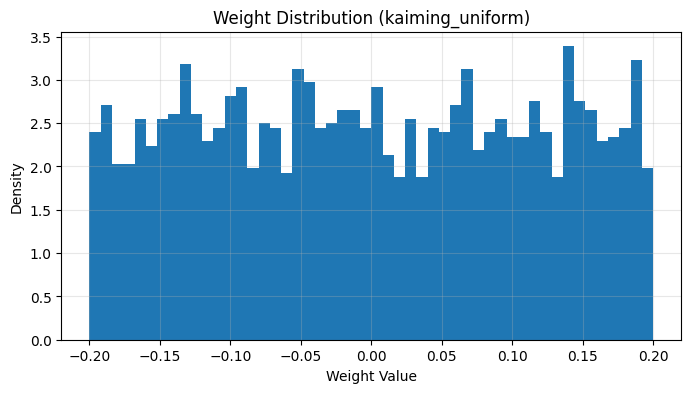

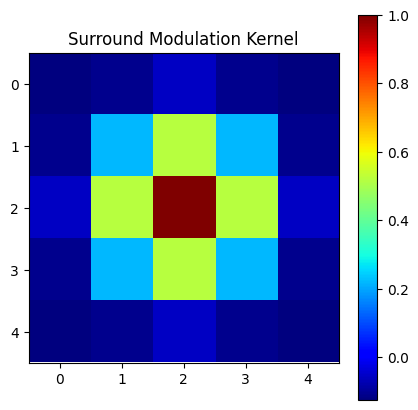

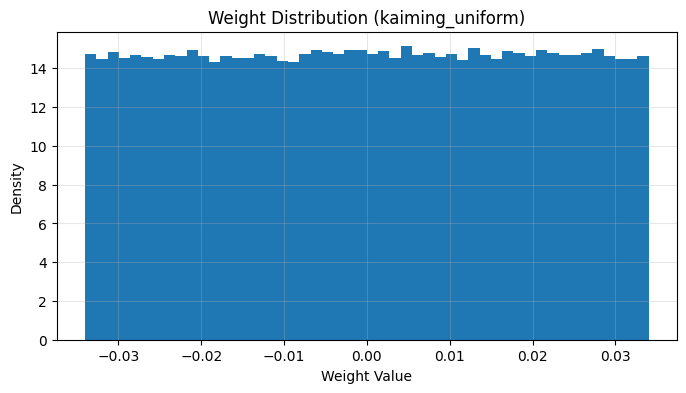

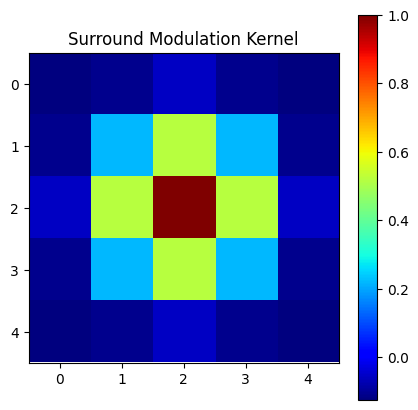

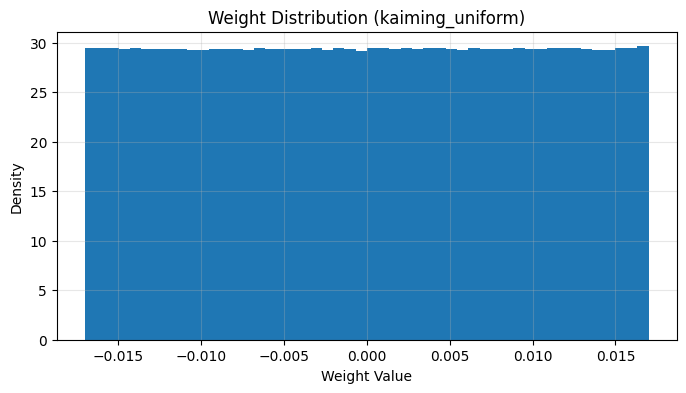

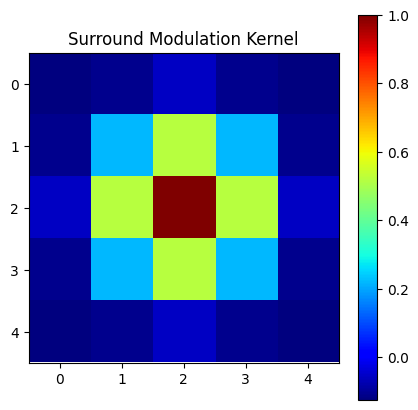

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
hebb_param = get_hebbian_config(version="optimal")

model = Net_Hebbian(
        hebb_params=hebb_param,
        version="mnist"
    ).to(device)

In [13]:
model

Net_Hebbian(
  (bn1): BatchNorm2d(1, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
  (conv1): HebbianConv2d(
    (act): Identity()
  )
  (pool1): MaxPool2d(kernel_size=4, stride=2, padding=1, dilation=1, ceil_mode=False)
  (activ1): Triangle()
  (bn2): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
  (conv2): HebbianConv2d(
    (act): Identity()
  )
  (pool2): MaxPool2d(kernel_size=4, stride=2, padding=1, dilation=1, ceil_mode=False)
  (activ2): Triangle()
  (bn3): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
  (conv3): HebbianConv2d(
    (act): Identity()
  )
  (pool3): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (activ3): Triangle()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=13824, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

In [34]:
hebb_param

{'mode': 'bcm',
 'w_nrm': False,
 'act': Identity(),
 'use_cosine_similarity': True,
 'use_lateral_inhibition': True,
 'top_k': 1,
 'init_method': 'kaiming_uniform',
 'patchwise': True,
 'contrast': 1.0,
 'uniformity': False,
 'use_presynaptic_competition': False,
 'presynaptic_competition_type': 'lp_norm',
 'competition_type': 'hard',
 'temporal_window': 500,
 'competition_k': 2,
 'dale': False,
 'use_homeostasis': False}

In [35]:
print("conv1 init:", model.conv1.init_method)
print("conv2 init:", model.conv2.init_method)
print("conv3 init:", model.conv3.init_method)

print("conv1 lr:", model.conv1.lr)
print("conv2 lr:", model.conv2.lr)
print("conv3 lr:", model.conv3.lr)

conv1 init: kaiming_uniform
conv2 init: kaiming_uniform
conv3 init: kaiming_uniform
conv1 lr: 0.1
conv2 lr: 0.1
conv3 lr: 0.1


In [33]:
for i, layer in enumerate([model.conv1, model.conv2, model.conv3], 1):
    print(
        f"Conv{i}: "
        f"sigma_e={layer.sigma_e}, "
        f"sigma_i={layer.sigma_i}, "
        f"lateral_kernel={layer.lateral_kernel}"
    )

Conv1: sigma_e=1.2, sigma_i=1.4, lateral_kernel=5
Conv2: sigma_e=1.2, sigma_i=1.4, lateral_kernel=5
Conv3: sigma_e=1.2, sigma_i=1.4, lateral_kernel=5


## Getting data

In [13]:
#proposed data preprocessing procedures from the researchers
from data_processing.data import get_data

In [14]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset

In [15]:

mnist_root = "../datasets/mnist"

base_transform = transforms.ToTensor()

mnist_train = datasets.MNIST(
    root=mnist_root,
    train=True,
    download=True,
    #transform=base_transform
)

mnist_test = datasets.MNIST(
    root=mnist_root,
    train=False,
    download=True,
    #transform=base_transform
)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.50MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.46MB/s]


### The researcher's data preprocessing script presents two options, either zca or no zca and instead normalisation. However both zca and this normalisation approach impede performance compared to using the raw data (with pixels in range [0,1] of course) (The paper claims that zca whitening was used for HardWTA methods)

# Running using no zca, instead using their normalisation

In [16]:
final_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Resize((28, 28)),
    transforms.Normalize(mean=[0.1307], std=[0.3081])
])

In [17]:
mnist_root = "../datasets/mnist"

mnist_train = datasets.MNIST(
    root=mnist_root,
    train=True,
    download=False,
    transform=final_transform
)

mnist_test = datasets.MNIST(
    root=mnist_root,
    train=False,
    download=False,
    transform=final_transform #oddly the researchers use random horizontal flipping on the test set (in addition to the train)
)

In [18]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    torch.use_deterministic_algorithms(True)

In [19]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32

    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [49]:
seeds = [0,1,2,3,4]
all_histories = {}

RUN 1/5 | SEED = 0
Building SoftHebb Greyscale model


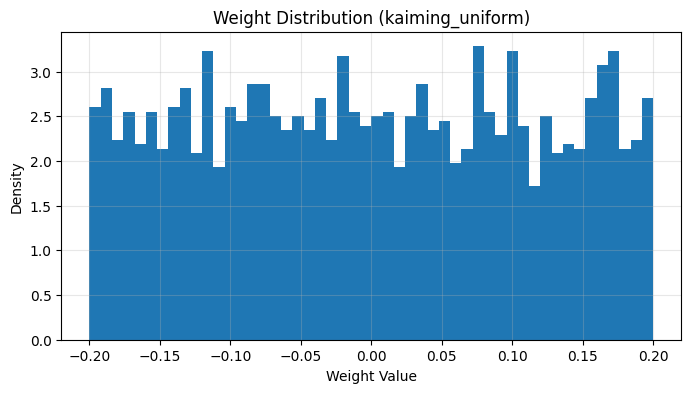

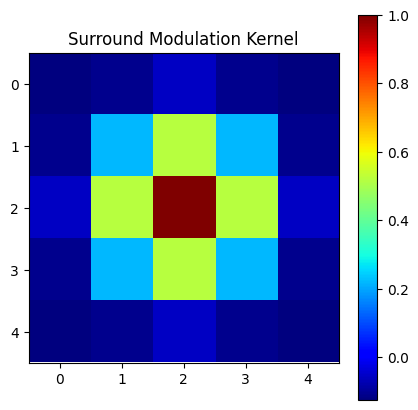

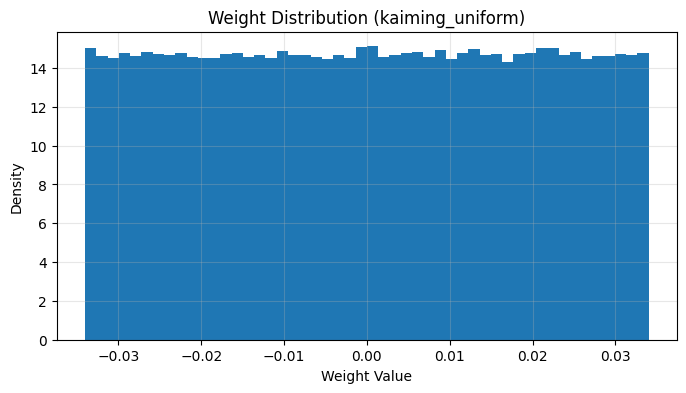

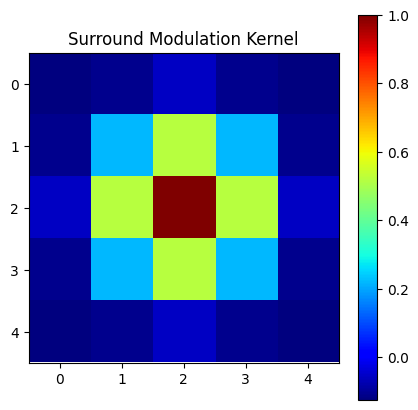

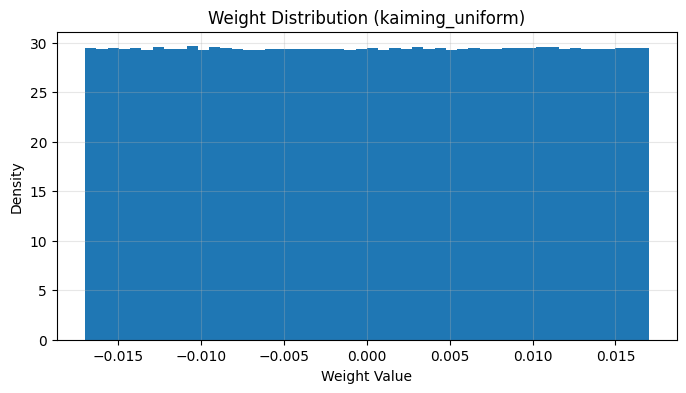

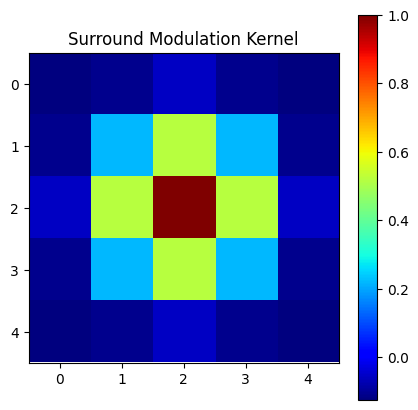

Hebbian epoch 1
Batch 0/938
Batch 100/938
Batch 200/938
Batch 300/938
Batch 400/938
Batch 500/938
Batch 600/938
Batch 700/938
Batch 800/938
Batch 900/938
Epoch [1/20] | Train Loss: 0.3466 | Train Acc: 89.23% | Test Loss: 0.1380 | Test Acc: 96.06% | LR: 0.001000
Epoch [2/20] | Train Loss: 0.1470 | Train Acc: 95.58% | Test Loss: 0.0978 | Test Acc: 97.08% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.1157 | Train Acc: 96.40% | Test Loss: 0.0833 | Test Acc: 97.44% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.1047 | Train Acc: 96.72% | Test Loss: 0.0797 | Test Acc: 97.49% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.0940 | Train Acc: 96.96% | Test Loss: 0.0683 | Test Acc: 97.63% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.0887 | Train Acc: 97.12% | Test Loss: 0.0689 | Test Acc: 97.81% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.0868 | Train Acc: 97.22% | Test Loss: 0.0610 | Test Acc: 97.94% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.0825 | Train Acc: 97.30% | Test Loss: 0.0575 | Test Acc: 98.1

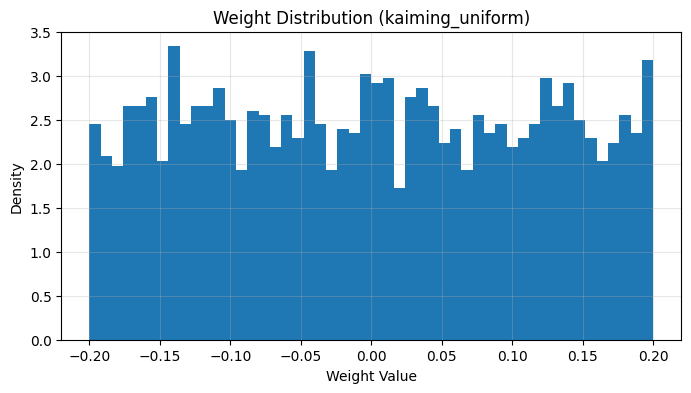

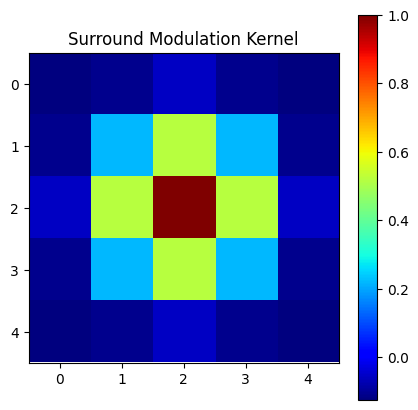

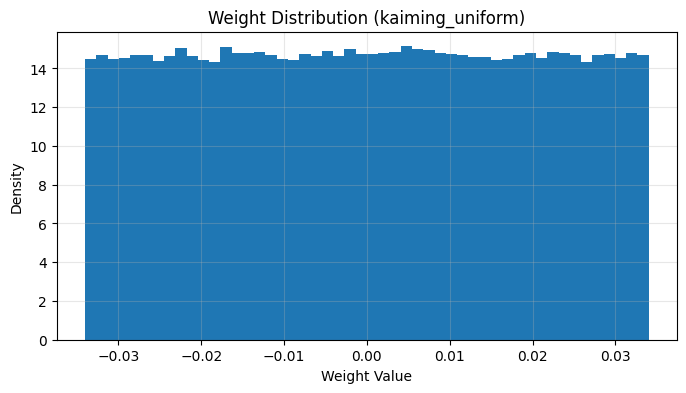

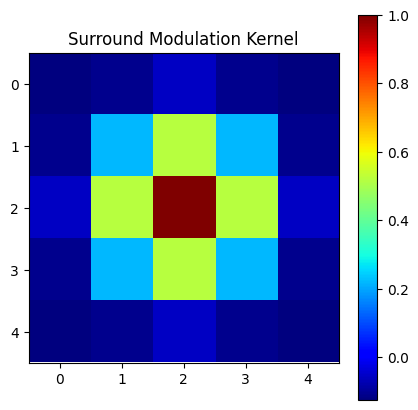

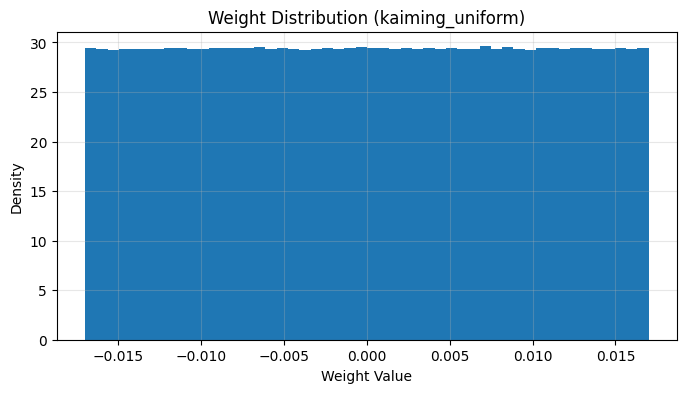

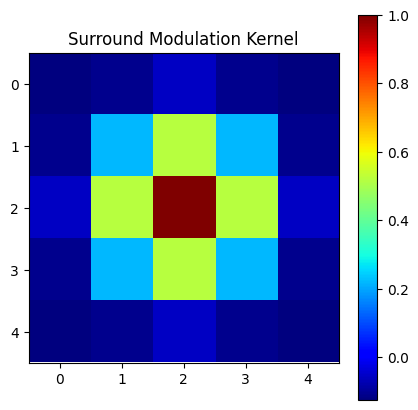

Hebbian epoch 1
Batch 0/938
Batch 100/938
Batch 200/938
Batch 300/938
Batch 400/938
Batch 500/938
Batch 600/938
Batch 700/938
Batch 800/938
Batch 900/938
Epoch [1/20] | Train Loss: 0.3602 | Train Acc: 88.73% | Test Loss: 0.1542 | Test Acc: 95.28% | LR: 0.001000
Epoch [2/20] | Train Loss: 0.1534 | Train Acc: 95.35% | Test Loss: 0.1068 | Test Acc: 96.79% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.1234 | Train Acc: 96.20% | Test Loss: 0.0971 | Test Acc: 97.01% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.1130 | Train Acc: 96.38% | Test Loss: 0.0888 | Test Acc: 97.14% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.1020 | Train Acc: 96.73% | Test Loss: 0.0791 | Test Acc: 97.40% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.0948 | Train Acc: 96.99% | Test Loss: 0.0675 | Test Acc: 97.78% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.0909 | Train Acc: 97.12% | Test Loss: 0.0691 | Test Acc: 97.64% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.0867 | Train Acc: 97.28% | Test Loss: 0.0612 | Test Acc: 97.9

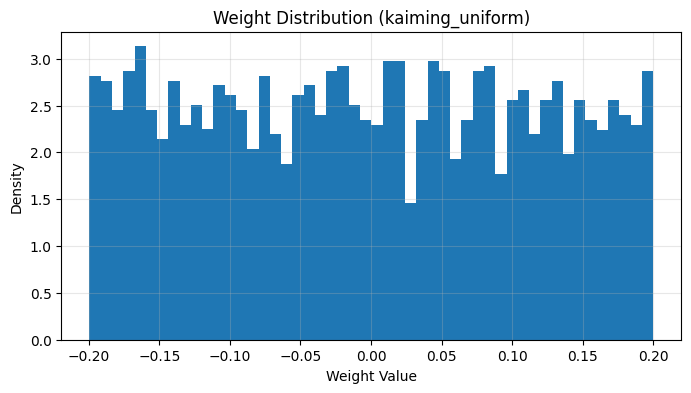

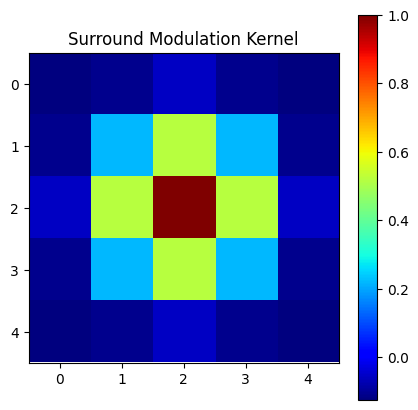

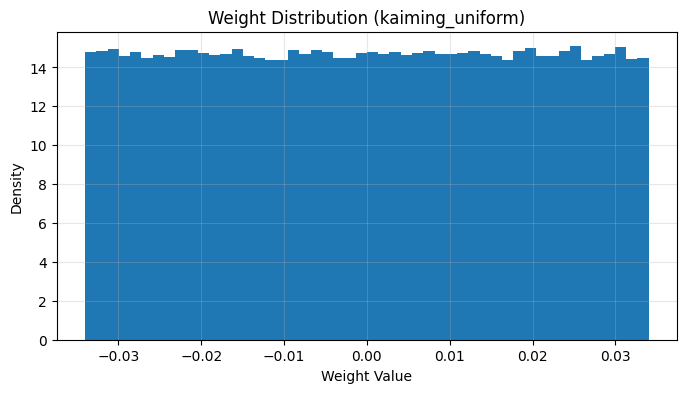

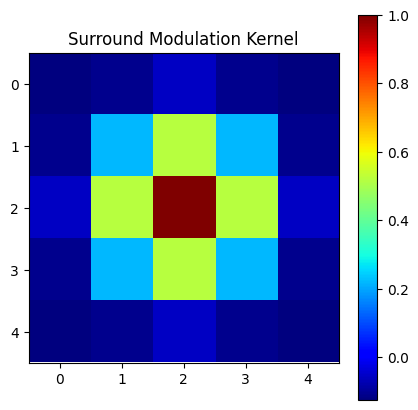

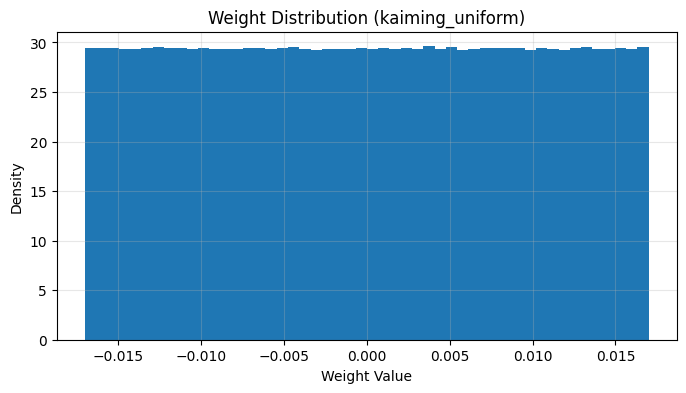

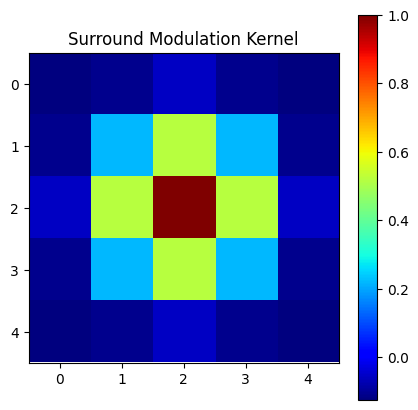

Hebbian epoch 1
Batch 0/938
Batch 100/938
Batch 200/938
Batch 300/938
Batch 400/938
Batch 500/938
Batch 600/938
Batch 700/938
Batch 800/938
Batch 900/938
Epoch [1/20] | Train Loss: 0.4621 | Train Acc: 85.27% | Test Loss: 0.2256 | Test Acc: 93.89% | LR: 0.001000
Epoch [2/20] | Train Loss: 0.2254 | Train Acc: 93.13% | Test Loss: 0.1755 | Test Acc: 94.58% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.1853 | Train Acc: 94.22% | Test Loss: 0.1406 | Test Acc: 95.63% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.1623 | Train Acc: 94.86% | Test Loss: 0.1242 | Test Acc: 96.23% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.1482 | Train Acc: 95.27% | Test Loss: 0.1059 | Test Acc: 96.83% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.1439 | Train Acc: 95.41% | Test Loss: 0.1068 | Test Acc: 96.64% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.1316 | Train Acc: 95.71% | Test Loss: 0.0979 | Test Acc: 96.97% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.1287 | Train Acc: 95.82% | Test Loss: 0.0943 | Test Acc: 97.1

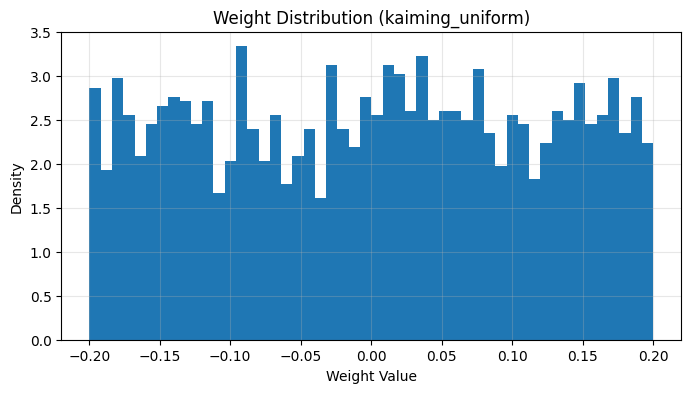

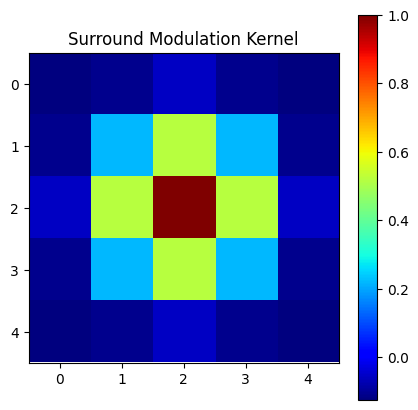

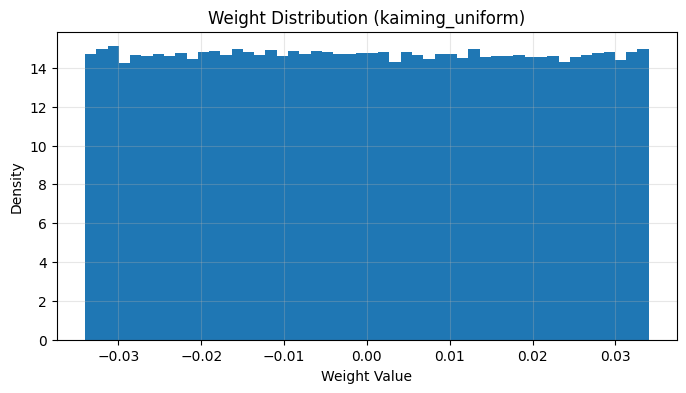

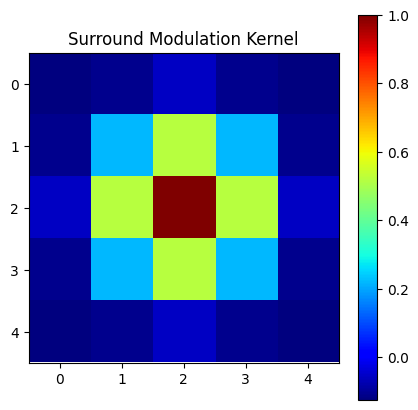

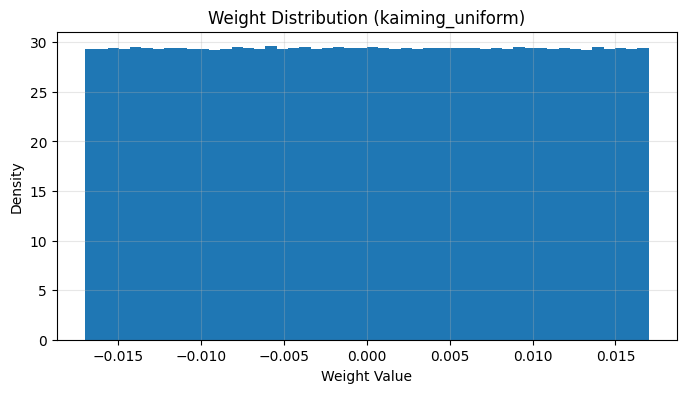

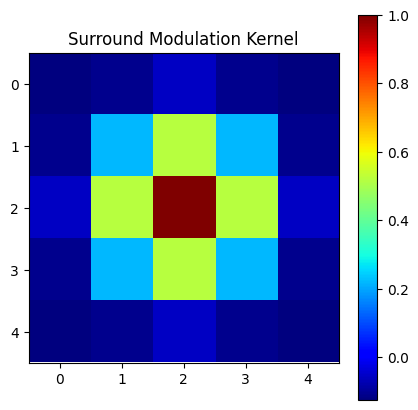

Hebbian epoch 1
Batch 0/938
Batch 100/938
Batch 200/938
Batch 300/938
Batch 400/938
Batch 500/938
Batch 600/938
Batch 700/938
Batch 800/938
Batch 900/938
Epoch [1/20] | Train Loss: 0.3448 | Train Acc: 89.34% | Test Loss: 0.1385 | Test Acc: 96.21% | LR: 0.001000
Epoch [2/20] | Train Loss: 0.1476 | Train Acc: 95.48% | Test Loss: 0.1060 | Test Acc: 96.75% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.1198 | Train Acc: 96.25% | Test Loss: 0.0912 | Test Acc: 97.09% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.1048 | Train Acc: 96.77% | Test Loss: 0.0719 | Test Acc: 97.79% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.0935 | Train Acc: 97.04% | Test Loss: 0.0673 | Test Acc: 97.87% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.0892 | Train Acc: 97.14% | Test Loss: 0.0682 | Test Acc: 97.79% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.0850 | Train Acc: 97.31% | Test Loss: 0.0696 | Test Acc: 97.69% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.0847 | Train Acc: 97.32% | Test Loss: 0.0576 | Test Acc: 98.1

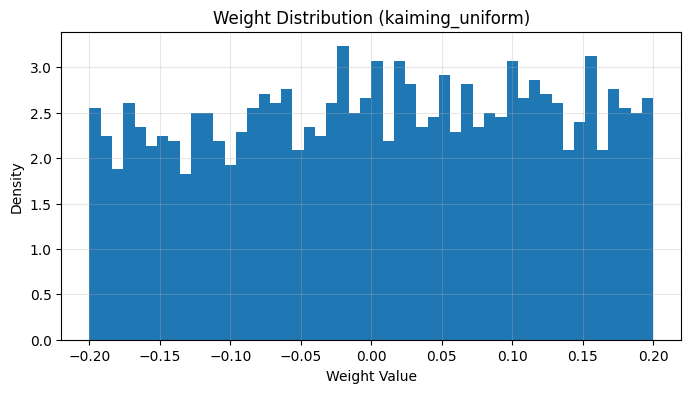

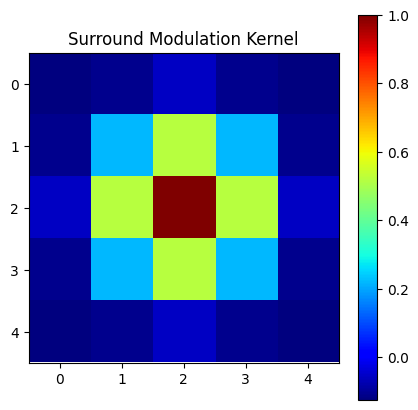

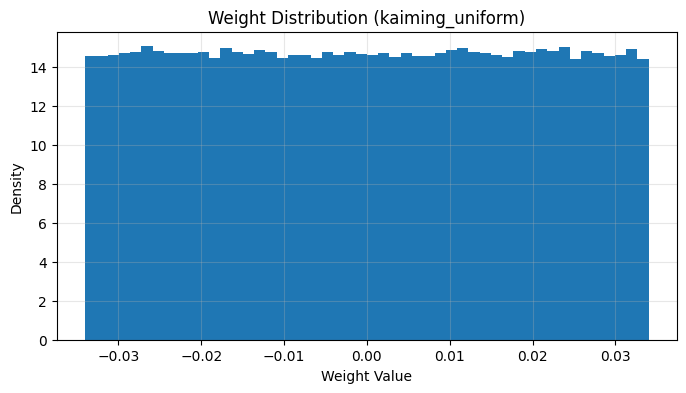

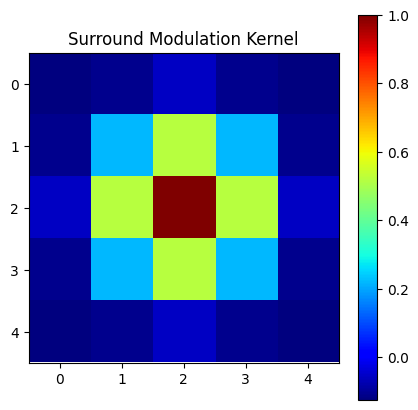

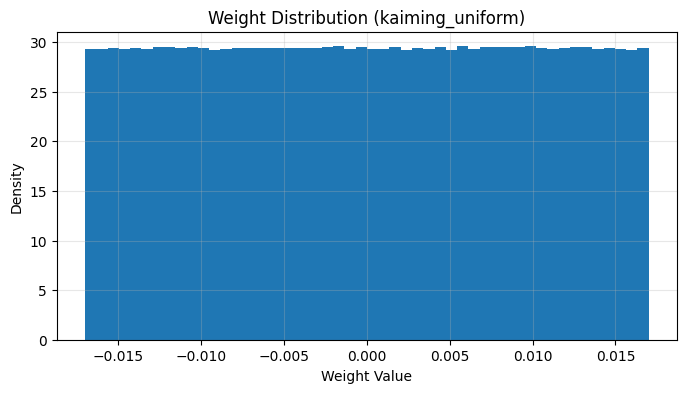

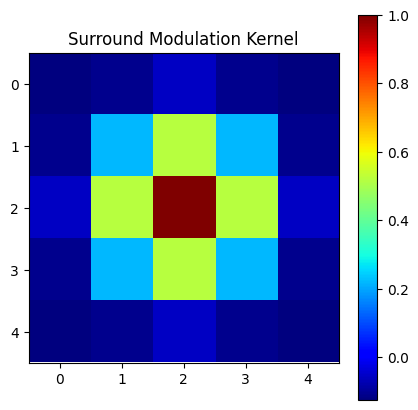

Hebbian epoch 1
Batch 0/938
Batch 100/938
Batch 200/938
Batch 300/938
Batch 400/938
Batch 500/938
Batch 600/938
Batch 700/938
Batch 800/938
Batch 900/938
Epoch [1/20] | Train Loss: 0.3975 | Train Acc: 87.08% | Test Loss: 0.1659 | Test Acc: 94.53% | LR: 0.001000
Epoch [2/20] | Train Loss: 0.1672 | Train Acc: 94.82% | Test Loss: 0.1251 | Test Acc: 96.17% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.1342 | Train Acc: 95.76% | Test Loss: 0.0959 | Test Acc: 96.97% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.1181 | Train Acc: 96.23% | Test Loss: 0.0900 | Test Acc: 97.11% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.1110 | Train Acc: 96.47% | Test Loss: 0.0787 | Test Acc: 97.48% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.1051 | Train Acc: 96.59% | Test Loss: 0.0630 | Test Acc: 97.90% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.1004 | Train Acc: 96.82% | Test Loss: 0.0696 | Test Acc: 97.73% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.0983 | Train Acc: 96.82% | Test Loss: 0.0707 | Test Acc: 97.6

In [50]:
for seed in seeds:

    print(f"RUN {seed + 1}/5 | SEED = {seed}")

   
    set_seed(seed)

      # Generator specifically for this run
    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        mnist_train,
        batch_size=64,
        shuffle=True,
        num_workers=2,
        worker_init_fn=seed_worker,
        generator=g
    )

    test_loader = DataLoader(
        mnist_test,
        batch_size=64,
        shuffle=False, #researchers have test data shuffled, but this is again unecessary, since no learning is occuring (eval only)
        num_workers=2,
        worker_init_fn=seed_worker,
        generator=g
    )

    #fresh model for every seed

    hebb_param = get_hebbian_config(version="optimal")

    model = Net_Hebbian(
        hebb_params=hebb_param,
        version="mnist"
    ).to(device)


    # hebbian feature learning ('Unsupervised Feature Learning Phase' trained for 1 epoch)
    model.train()

    for epoch in range(1):

        print(f"Hebbian epoch {epoch + 1}")

        for i, (inputs, _) in enumerate(train_loader):

            inputs = inputs.to(device)

            
            with torch.no_grad():
                model(inputs)

            for layer in [model.conv1, model.conv2, model.conv3]:
                layer.local_update()

            if i % 100 == 0:
                print(f"Batch {i}/{len(train_loader)}")
                

    # freeze the hebbian feature extractor as now to train classifier

    for module in [
        model.conv1,
        model.conv2,
        model.conv3,
        model.bn1,
        model.bn2,
        model.bn3
    ]:

        for param in module.parameters():
            param.requires_grad = False

        module.eval()

    #optimiser and schedular as defined in experiment_hebbian.py
    sup_optimizer = torch.optim.Adam(
        model.fc1.parameters(),
        lr=0.001
    )

    scheduler = torch.optim.lr_scheduler.LambdaLR(
        sup_optimizer,
        lr_lambda=lambda epoch:
            0.5 ** max(0, (epoch - 10) // 2)
    )

    criterion = nn.CrossEntropyLoss()

    classifier_history = {
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": []
    }

    #train classier for 20 epochs

    for epoch in range(20):
        model.conv1.eval()
        model.conv2.eval()
        model.conv3.eval()

        model.bn1.eval()
        model.bn2.eval()
        model.bn3.eval()

        model.fc1.train()
        model.dropout.train()

        running_loss = 0.0
        correct = 0
        total = 0


        for inputs, labels in train_loader:

            inputs = inputs.to(device)


            labels = labels.to(device)

            sup_optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            loss.backward()

            sup_optimizer.step()

            running_loss += loss.item() * labels.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_accuracy = 100 * correct / total

        #get the evaluation results on the test set

        model.eval()

        test_running_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():

            for inputs, labels in test_loader:

                inputs = inputs.to(device)
   

                labels = labels.to(device)

                outputs = model(inputs)

                loss = criterion(outputs, labels)

                test_running_loss += loss.item() * labels.size(0)

                _, predicted = torch.max(outputs, 1)

                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()

        test_loss = test_running_loss / test_total
        test_accuracy = 100 * test_correct / test_total


        classifier_history["train_loss"].append(train_loss)
        classifier_history["train_accuracy"].append(train_accuracy)

        classifier_history["test_loss"].append(test_loss)
        classifier_history["test_accuracy"].append(test_accuracy)

        #update the scheduler
        scheduler.step()

        current_lr = sup_optimizer.param_groups[0]["lr"]

        print(
            f"Epoch [{epoch + 1}/20] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_accuracy:.2f}% | "
            f"LR: {current_lr:.6f}"
        )

    # save each runs history
    all_histories[seed] = classifier_history

# save results and visualise

In [51]:
# Shape: (5 runs, 20 epochs)
train_acc = np.array([
    all_histories[seed]["train_accuracy"]
    for seed in seeds
])

test_acc = np.array([
    all_histories[seed]["test_accuracy"]
    for seed in seeds
])

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [52]:
train_acc_df=pd.DataFrame(train_acc)

In [53]:
test_acc_df=pd.DataFrame(test_acc)


In [54]:
train_acc_df.to_csv("/content/drive/MyDrive/research_jobs/hebbian_3_layer_MNIST_norm_train_acc_.csv",index=False)

In [55]:
test_acc_df.to_csv("/content/drive/MyDrive/research_jobs/hebbian_3_layer_MNIST_norm_test_acc_.csv",index=False)


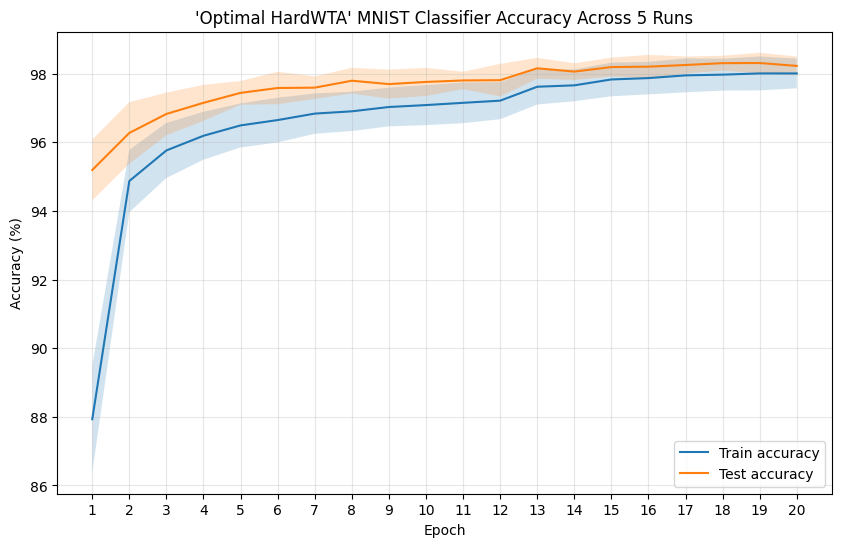

In [56]:
# Mean and standard deviation across the 5 runs
train_mean = train_acc.mean(axis=0)
train_std = train_acc.std(axis=0)

test_mean = test_acc.mean(axis=0)
test_std = test_acc.std(axis=0)

epochs = np.arange(1, 21)

plt.figure(figsize=(10, 6))

plt.plot(epochs, train_mean, label="Train accuracy")
plt.fill_between(
    epochs,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.plot(epochs, test_mean, label="Test accuracy")
plt.fill_between(
    epochs,
    test_mean - test_std,
    test_mean + test_std,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("'Optimal HardWTA' MNIST Classifier Accuracy Across 5 Runs")
plt.xticks(epochs)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [57]:
print(
    f"Final test accuracy: "
    f"{test_mean[-1]:.2f} ± {test_std[-1]:.2f}%"
)

Final test accuracy: 98.23 ± 0.27%


In [58]:
best_per_run = test_acc.max(axis=1)

print(
    f"Best average test accuracy: "
    f"{best_per_run.mean():.2f} ± {best_per_run.std():.2f}%"
)

Best average test accuracy: 98.36 ± 0.25%


In [59]:
#maximum raw test accuracy - aligns with researcher's 98.5
test_acc.max()

np.float64(98.57)

In [60]:
final10 = np.mean(test_acc[:, 10:20], axis=1)

print(
    f"Mean accuracy final 10 epochs: "
    f"{np.mean(final10):.2f} ± {np.std(final10):.2f}%"
)

Mean accuracy final 10 epochs: 98.13 ± 0.28%


# Now running with researcher's exact method for zca:

In [43]:
mnist_trn_loader, mnist_tst_loader, mnist_zca = get_data(dataset='mnist', batch_size=64, whiten_lvl=1e-3)

100%|██████████| 9.91M/9.91M [00:00<00:00, 21.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 506kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.67MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.63MB/s]


Data Batch whitening
Computing batch ZCA matrix for mnist
Processing Training batches: 1094
Batch: [0]
Batch: [1]
Batch: [2]
Batch: [3]
Batch: [4]
Batch: [5]
Batch: [6]
Batch: [7]
Batch: [8]
Batch: [9]
Batch: [10]
Batch: [11]
Batch: [12]
Batch: [13]
Batch: [14]
Batch: [15]
Batch: [16]
Batch: [17]
Batch: [18]
Batch: [19]
Batch: [20]
Batch: [21]
Batch: [22]
Batch: [23]
Batch: [24]
Batch: [25]
Batch: [26]
Batch: [27]
Batch: [28]
Batch: [29]
Batch: [30]
Batch: [31]
Batch: [32]
Batch: [33]
Batch: [34]
Batch: [35]
Batch: [36]
Batch: [37]
Batch: [38]
Batch: [39]
Batch: [40]
Batch: [41]
Batch: [42]
Batch: [43]
Batch: [44]
Batch: [45]
Batch: [46]
Batch: [47]
Batch: [48]
Batch: [49]
Batch: [50]
Batch: [51]
Batch: [52]
Batch: [53]
Batch: [54]
Batch: [55]
Batch: [56]
Batch: [57]
Batch: [58]
Batch: [59]
Batch: [60]
Batch: [61]
Batch: [62]
Batch: [63]
Batch: [64]
Batch: [65]
Batch: [66]
Batch: [67]
Batch: [68]
Batch: [69]
Batch: [70]
Batch: [71]
Batch: [72]
Batch: [73]
Batch: [74]
Batch: [75]
Batch:

Building SoftHebb Greyscale model


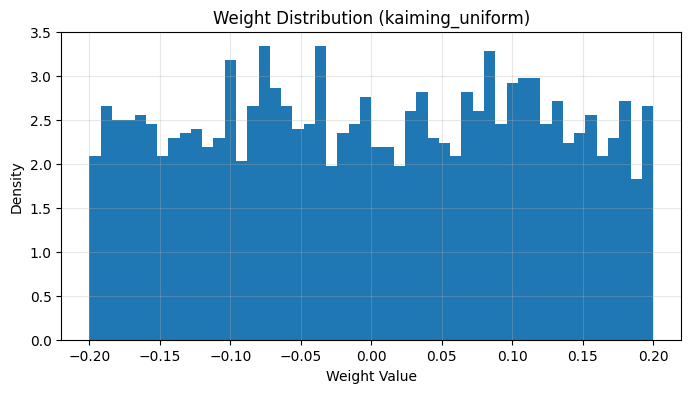

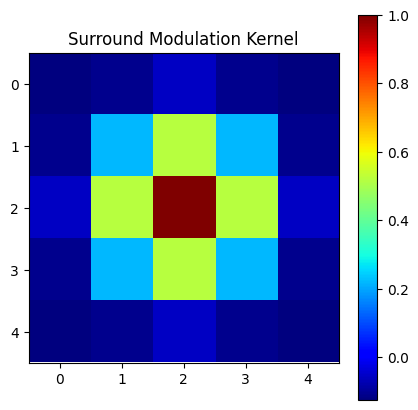

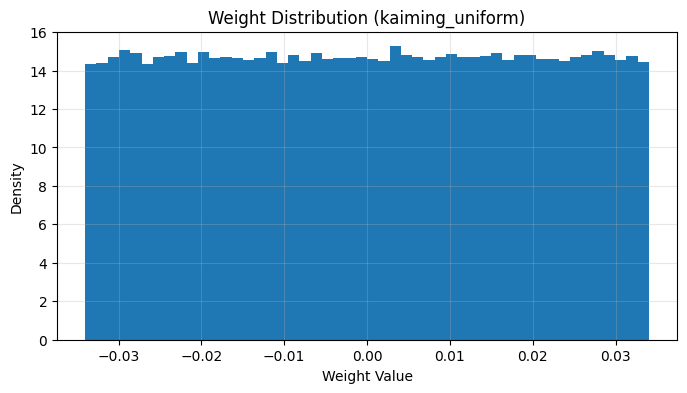

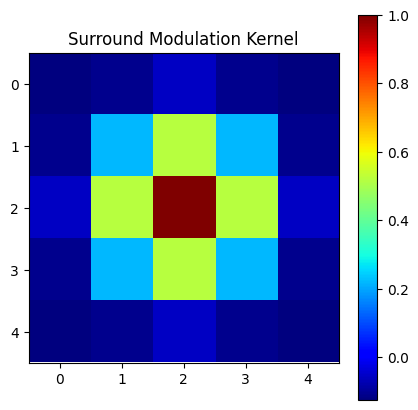

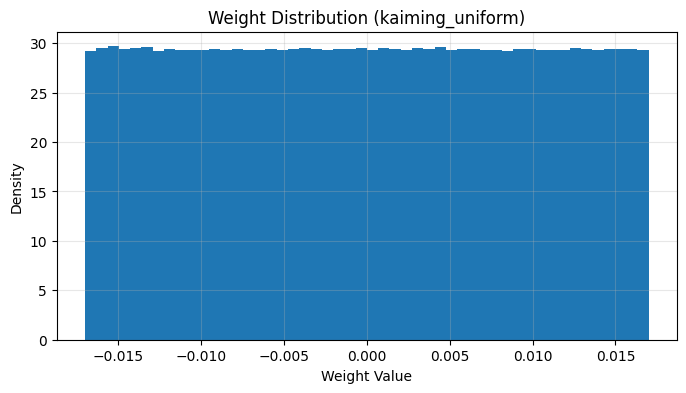

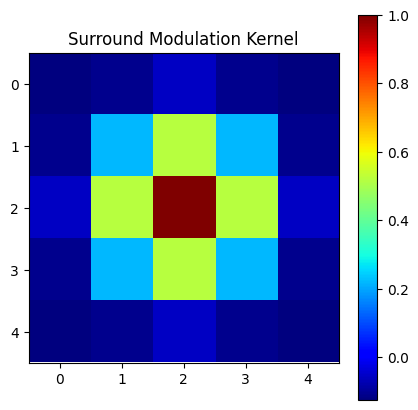

Hebbian epoch 1
Batch 0/938
Batch 100/938
Batch 200/938
Batch 300/938
Batch 400/938
Batch 500/938
Batch 600/938
Batch 700/938
Batch 800/938
Batch 900/938
Epoch [1/20] | Train Loss: 0.5262 | Train Acc: 82.97% | Test Loss: 0.2158 | Test Acc: 93.46% | LR: 0.001000
Epoch [2/20] | Train Loss: 0.2537 | Train Acc: 91.75% | Test Loss: 0.1677 | Test Acc: 94.37% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.2066 | Train Acc: 93.25% | Test Loss: 0.1393 | Test Acc: 95.45% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.1890 | Train Acc: 93.81% | Test Loss: 0.1399 | Test Acc: 95.28% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.1777 | Train Acc: 94.21% | Test Loss: 0.1336 | Test Acc: 95.62% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.1683 | Train Acc: 94.57% | Test Loss: 0.1274 | Test Acc: 95.59% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.1654 | Train Acc: 94.59% | Test Loss: 0.1351 | Test Acc: 95.42% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.1597 | Train Acc: 94.80% | Test Loss: 0.1105 | Test Acc: 96.2

In [ ]:

hebb_param = get_hebbian_config(version="optimal")

model = Net_Hebbian(
        hebb_params=hebb_param,
        version="mnist"
    ).to(device)


# hebbian feature learning ('Unsupervised Feature Learning Phase' trained for 1 epoch)
model.train()

for epoch in range(1):

    print(f"Hebbian epoch {epoch + 1}")

    for i, (inputs, _) in enumerate(mnist_trn_loader):

        inputs = inputs.to(device)



            
        with torch.no_grad():
            model(inputs)

        for layer in [model.conv1, model.conv2, model.conv3]:
            layer.local_update()

        if i % 100 == 0:
            print(f"Batch {i}/{len(mnist_trn_loader)}")
                

# freeze the hebbian feature extractor as now to train classifier

for module in [
        model.conv1,
        model.conv2,
        model.conv3,
        model.bn1,
        model.bn2,
        model.bn3
    ]:

    for param in module.parameters():
        param.requires_grad = False

    module.eval()

#optimiser and schedular as defined in experiment_hebbian.py
sup_optimizer = torch.optim.Adam(
        model.fc1.parameters(),
        lr=0.001
    )

scheduler = torch.optim.lr_scheduler.LambdaLR(
        sup_optimizer,
        lr_lambda=lambda epoch:
            0.5 ** max(0, (epoch - 10) // 2)
    )

criterion = nn.CrossEntropyLoss()

classifier_history = {
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": []
    }

#train classier for 20 epochs

for epoch in range(20):
    model.conv1.eval()
    model.conv2.eval()
    model.conv3.eval()

    model.bn1.eval()
    model.bn2.eval()
    model.bn3.eval()

    model.fc1.train()
    model.dropout.train()

    running_loss = 0.0
    correct = 0
    total = 0


    for inputs, labels in mnist_trn_loader:

        inputs = inputs.to(device)


        labels = labels.to(device)

        sup_optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, labels)

        loss.backward()

        sup_optimizer.step()

        running_loss += loss.item() * labels.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_accuracy = 100 * correct / total

    #get the evaluation results on the test set

    model.eval()

    test_running_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():

        for inputs, labels in mnist_tst_loader:

            inputs = inputs.to(device)
        

            labels = labels.to(device)

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            test_running_loss += loss.item() * labels.size(0)

            _, predicted = torch.max(outputs, 1)

            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    test_loss = test_running_loss / test_total
    test_accuracy = 100 * test_correct / test_total


    classifier_history["train_loss"].append(train_loss)
    classifier_history["train_accuracy"].append(train_accuracy)

    classifier_history["test_loss"].append(test_loss)
    classifier_history["test_accuracy"].append(test_accuracy)

    #update the scheduler
    scheduler.step()

    current_lr = sup_optimizer.param_groups[0]["lr"]

    print(
            f"Epoch [{epoch + 1}/20] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_accuracy:.2f}% | "
            f"LR: {current_lr:.6f}"
        )


### zca clearly impedes accuracy on the first seeded run (it's therefore not worth persuing further)

# Now running without normalisation or zca

In [17]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset

final_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Resize((28, 28))
])

In [18]:
mnist_root = "../datasets/mnist"

mnist_train = datasets.MNIST(
    root=mnist_root,
    train=True,
    download=False,
    transform=final_transform
)

mnist_test = datasets.MNIST(
    root=mnist_root,
    train=False,
    download=False,
    transform=final_transform
)

In [19]:
seeds = [0, 1, 2, 3, 4]
all_histories = {}

RUN 1/5 | SEED = 0
Building SoftHebb Greyscale model


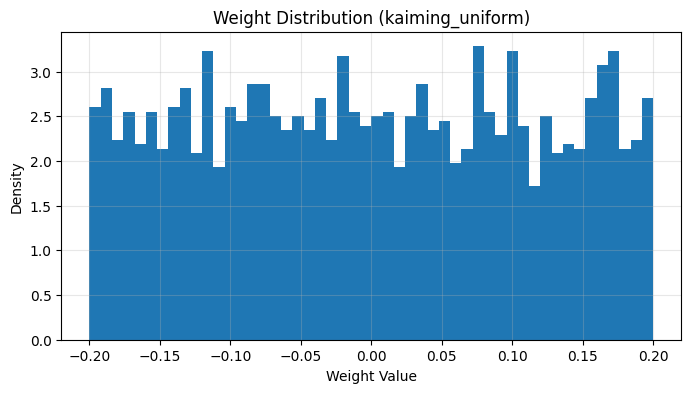

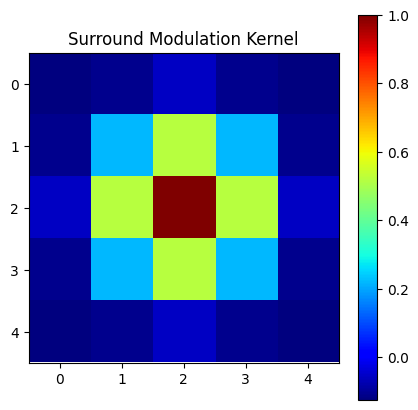

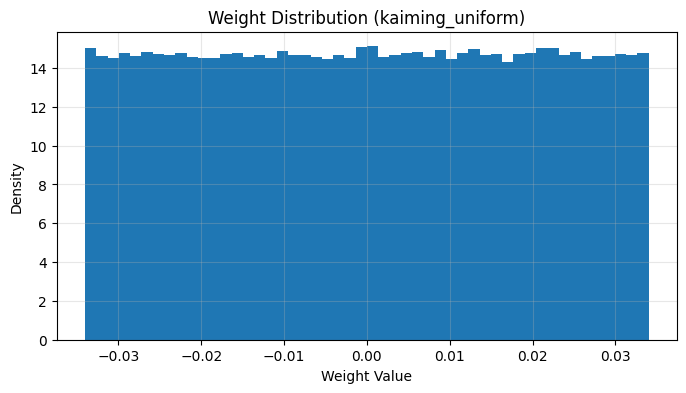

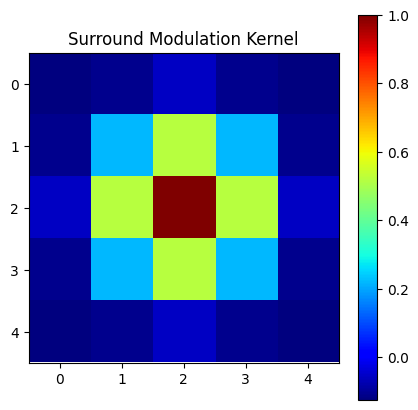

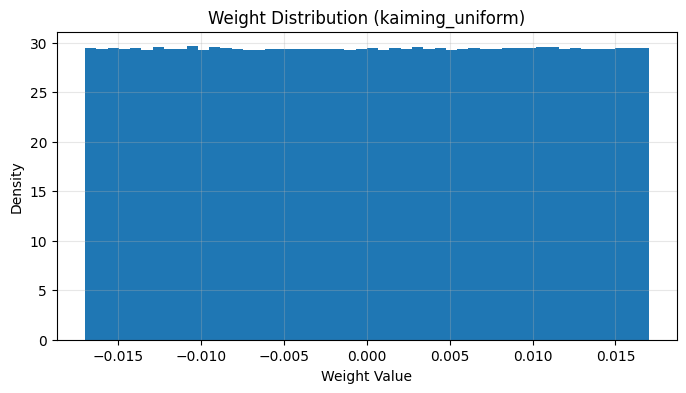

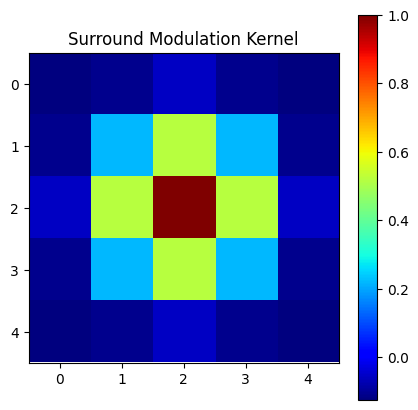

Hebbian epoch 1
Batch 0/938
Batch 100/938
Batch 200/938
Batch 300/938
Batch 400/938
Batch 500/938
Batch 600/938
Batch 700/938
Batch 800/938
Batch 900/938
Epoch [1/20] | Train Loss: 0.3560 | Train Acc: 88.81% | Test Loss: 0.1410 | Test Acc: 96.02% | LR: 0.001000
Epoch [2/20] | Train Loss: 0.1509 | Train Acc: 95.40% | Test Loss: 0.0989 | Test Acc: 96.99% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.1186 | Train Acc: 96.37% | Test Loss: 0.0849 | Test Acc: 97.38% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.1089 | Train Acc: 96.57% | Test Loss: 0.0815 | Test Acc: 97.43% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.0980 | Train Acc: 96.80% | Test Loss: 0.0712 | Test Acc: 97.64% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.0923 | Train Acc: 97.00% | Test Loss: 0.0686 | Test Acc: 97.90% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.0889 | Train Acc: 97.10% | Test Loss: 0.0601 | Test Acc: 97.97% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.0865 | Train Acc: 97.10% | Test Loss: 0.0588 | Test Acc: 97.9

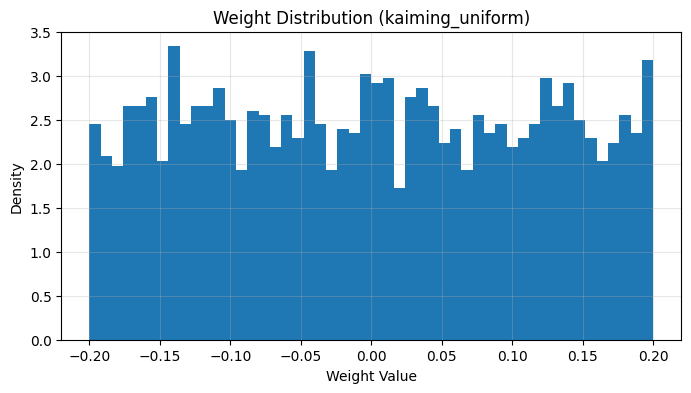

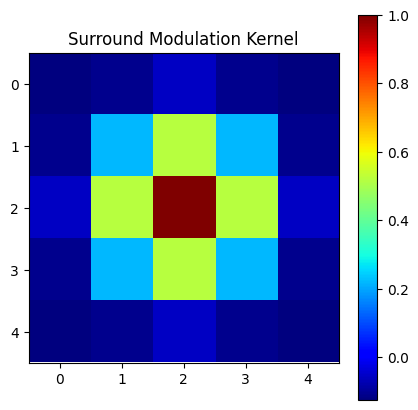

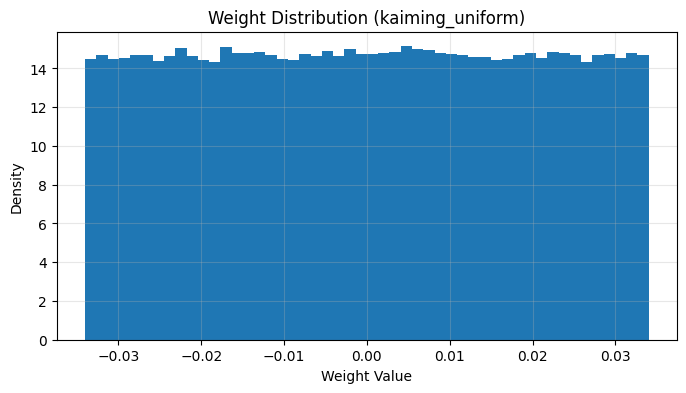

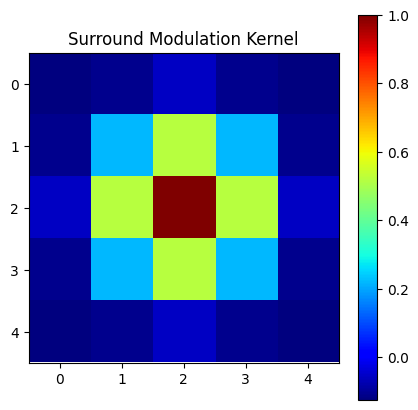

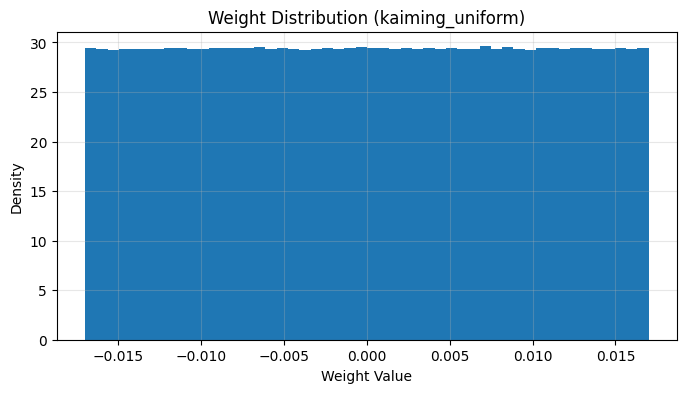

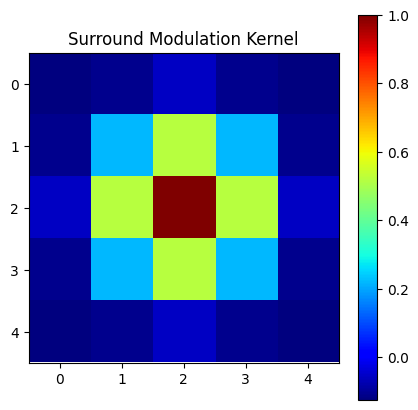

Hebbian epoch 1
Batch 0/938
Batch 100/938
Batch 200/938
Batch 300/938
Batch 400/938
Batch 500/938
Batch 600/938
Batch 700/938
Batch 800/938
Batch 900/938
Epoch [1/20] | Train Loss: 0.3669 | Train Acc: 88.53% | Test Loss: 0.1547 | Test Acc: 95.25% | LR: 0.001000
Epoch [2/20] | Train Loss: 0.1571 | Train Acc: 95.22% | Test Loss: 0.1089 | Test Acc: 96.52% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.1262 | Train Acc: 96.13% | Test Loss: 0.1002 | Test Acc: 96.83% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.1160 | Train Acc: 96.30% | Test Loss: 0.0918 | Test Acc: 97.12% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.1046 | Train Acc: 96.64% | Test Loss: 0.0783 | Test Acc: 97.43% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.0979 | Train Acc: 96.88% | Test Loss: 0.0688 | Test Acc: 97.74% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.0928 | Train Acc: 97.09% | Test Loss: 0.0743 | Test Acc: 97.44% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.0888 | Train Acc: 97.11% | Test Loss: 0.0590 | Test Acc: 98.1

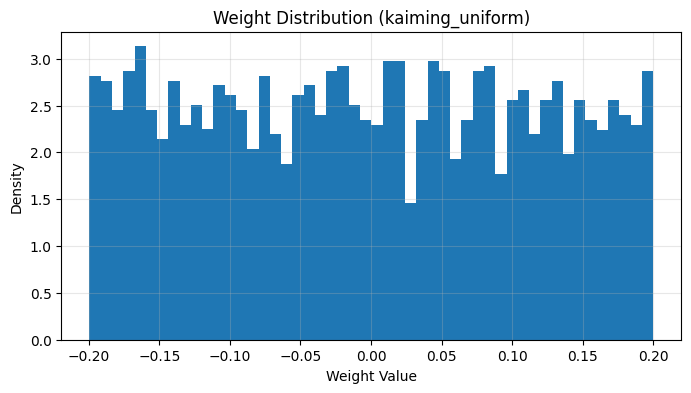

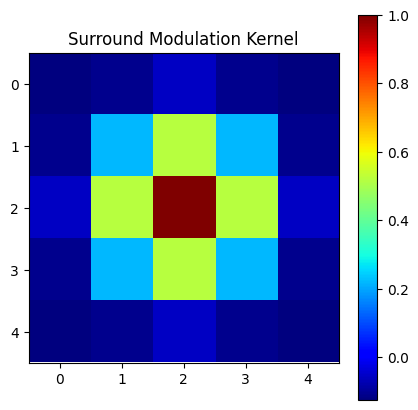

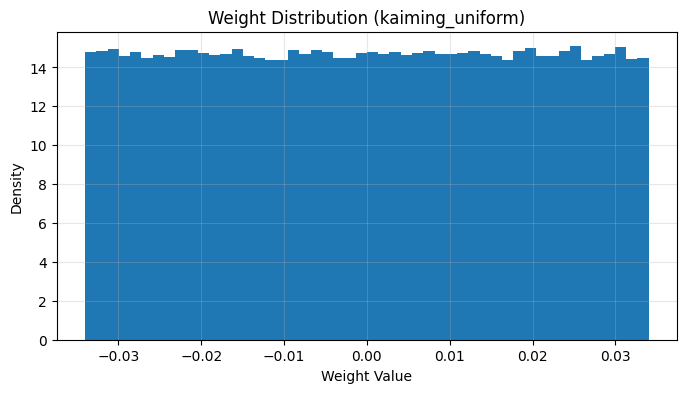

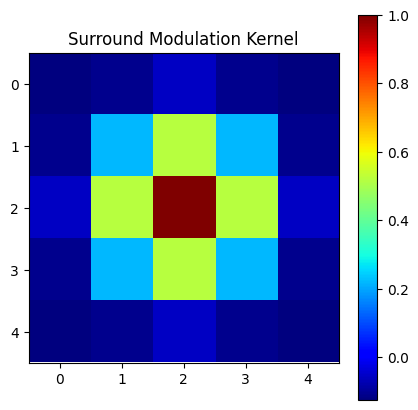

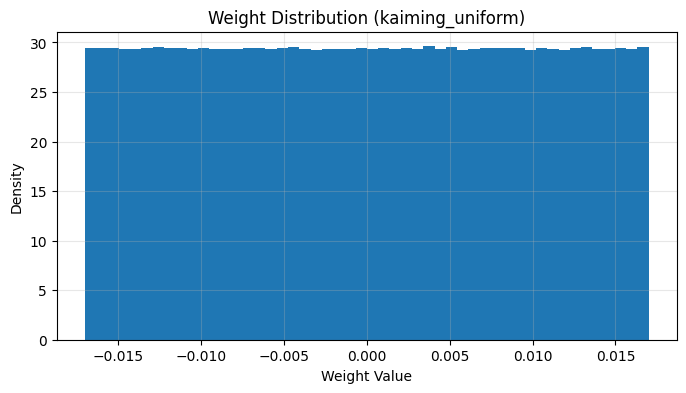

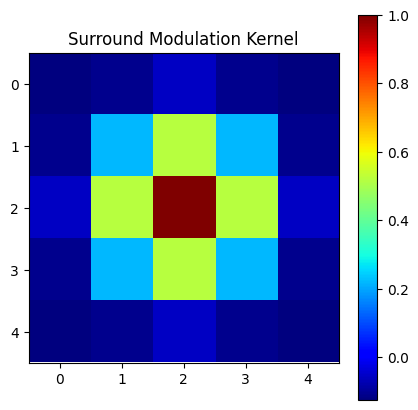

Hebbian epoch 1
Batch 0/938
Batch 100/938
Batch 200/938
Batch 300/938
Batch 400/938
Batch 500/938
Batch 600/938
Batch 700/938
Batch 800/938
Batch 900/938
Epoch [1/20] | Train Loss: 0.4694 | Train Acc: 85.03% | Test Loss: 0.2314 | Test Acc: 93.79% | LR: 0.001000
Epoch [2/20] | Train Loss: 0.2296 | Train Acc: 93.03% | Test Loss: 0.1820 | Test Acc: 94.29% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.1885 | Train Acc: 94.06% | Test Loss: 0.1431 | Test Acc: 95.51% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.1656 | Train Acc: 94.81% | Test Loss: 0.1310 | Test Acc: 95.98% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.1517 | Train Acc: 95.13% | Test Loss: 0.1091 | Test Acc: 96.68% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.1449 | Train Acc: 95.34% | Test Loss: 0.1092 | Test Acc: 96.50% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.1360 | Train Acc: 95.54% | Test Loss: 0.0997 | Test Acc: 96.93% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.1308 | Train Acc: 95.86% | Test Loss: 0.0967 | Test Acc: 97.1

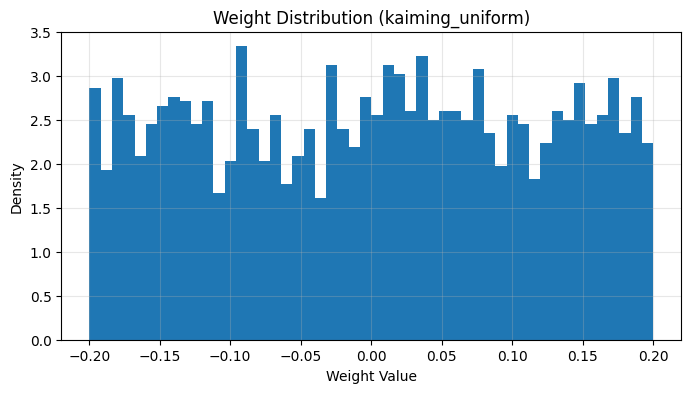

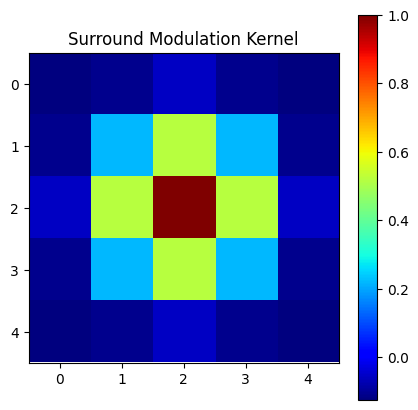

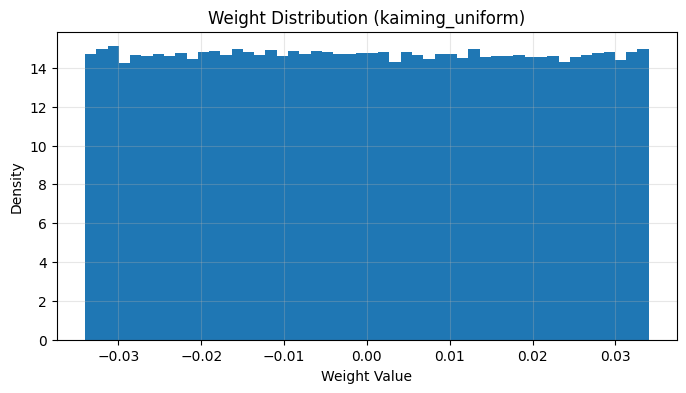

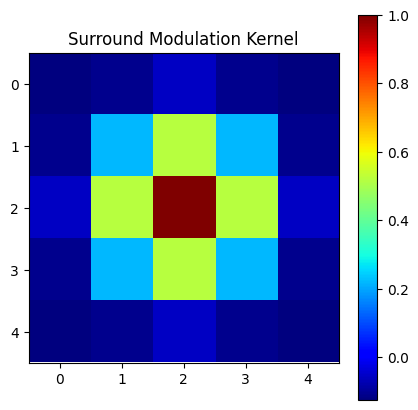

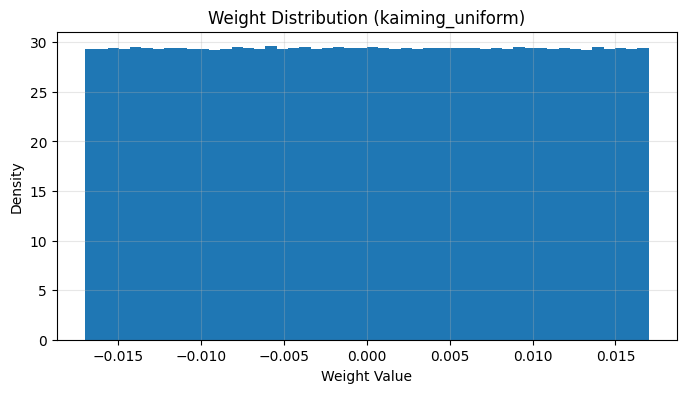

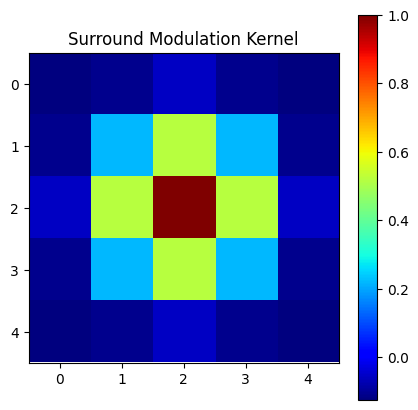

Hebbian epoch 1
Batch 0/938
Batch 100/938
Batch 200/938
Batch 300/938
Batch 400/938
Batch 500/938
Batch 600/938
Batch 700/938
Batch 800/938
Batch 900/938
Epoch [1/20] | Train Loss: 0.3570 | Train Acc: 88.94% | Test Loss: 0.1450 | Test Acc: 96.08% | LR: 0.001000
Epoch [2/20] | Train Loss: 0.1559 | Train Acc: 95.30% | Test Loss: 0.1134 | Test Acc: 96.60% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.1268 | Train Acc: 95.96% | Test Loss: 0.0960 | Test Acc: 96.93% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.1102 | Train Acc: 96.53% | Test Loss: 0.0769 | Test Acc: 97.50% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.0992 | Train Acc: 96.86% | Test Loss: 0.0704 | Test Acc: 97.75% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.0942 | Train Acc: 96.96% | Test Loss: 0.0706 | Test Acc: 97.74% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.0905 | Train Acc: 97.10% | Test Loss: 0.0683 | Test Acc: 97.87% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.0884 | Train Acc: 97.14% | Test Loss: 0.0588 | Test Acc: 98.1

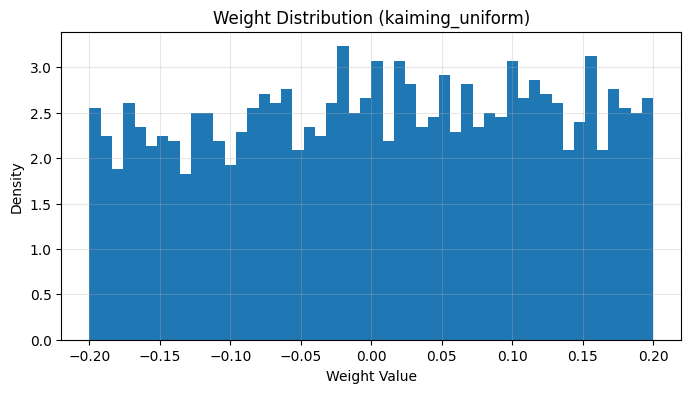

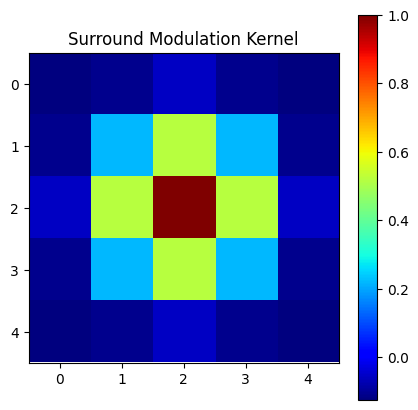

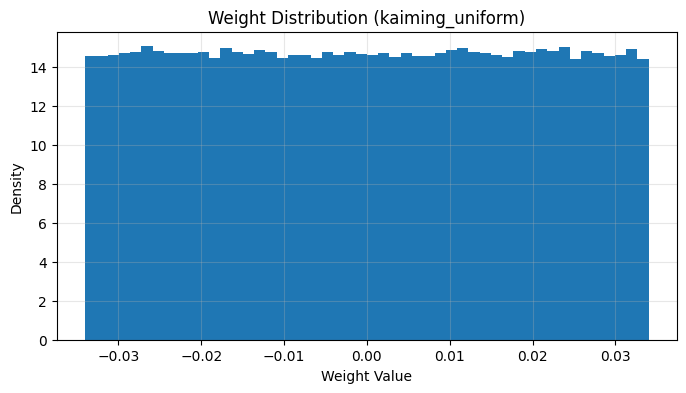

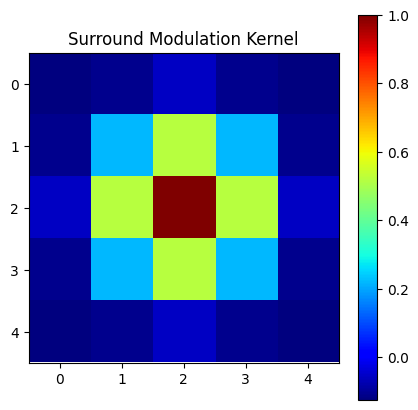

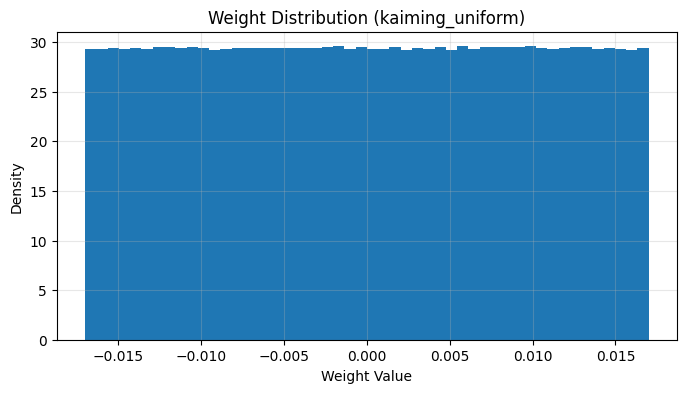

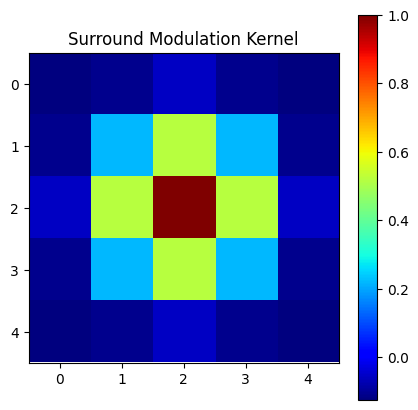

Hebbian epoch 1
Batch 0/938
Batch 100/938
Batch 200/938
Batch 300/938
Batch 400/938
Batch 500/938
Batch 600/938
Batch 700/938
Batch 800/938
Batch 900/938
Epoch [1/20] | Train Loss: 0.3961 | Train Acc: 87.01% | Test Loss: 0.1646 | Test Acc: 94.59% | LR: 0.001000
Epoch [2/20] | Train Loss: 0.1669 | Train Acc: 94.81% | Test Loss: 0.1259 | Test Acc: 96.12% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.1341 | Train Acc: 95.80% | Test Loss: 0.0951 | Test Acc: 97.04% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.1177 | Train Acc: 96.26% | Test Loss: 0.0892 | Test Acc: 97.11% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.1114 | Train Acc: 96.47% | Test Loss: 0.0800 | Test Acc: 97.48% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.1054 | Train Acc: 96.59% | Test Loss: 0.0624 | Test Acc: 97.92% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.1004 | Train Acc: 96.69% | Test Loss: 0.0728 | Test Acc: 97.68% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.0975 | Train Acc: 96.83% | Test Loss: 0.0664 | Test Acc: 97.7

In [ ]:

for seed in seeds:

    print(f"RUN {seed + 1}/5 | SEED = {seed}")

   
    set_seed(seed)

      # Generator specifically for this run
    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        mnist_train,
        batch_size=64,
        shuffle=True,
        num_workers=2,
        worker_init_fn=seed_worker,
        generator=g
    )

    test_loader = DataLoader(
        mnist_test,
        batch_size=64,
        shuffle=False, #researchers have test data shuffled, but this is again unecessary, since no learning is occuring (eval only)
        num_workers=2,
        worker_init_fn=seed_worker,
        generator=g
    )

    #fresh model for every seed

    hebb_param = get_hebbian_config(version="optimal")

    model = Net_Hebbian(
        hebb_params=hebb_param,
        version="mnist"
    ).to(device)


    # hebbian feature learning ('Unsupervised Feature Learning Phase' trained for 1 epoch)
    model.train()

    for epoch in range(1):

        print(f"Hebbian epoch {epoch + 1}")

        for i, (inputs, _) in enumerate(train_loader):

            inputs = inputs.to(device)

            
            with torch.no_grad():
                model(inputs)

            for layer in [model.conv1, model.conv2, model.conv3]:
                layer.local_update()

            if i % 100 == 0:
                print(f"Batch {i}/{len(train_loader)}")
                

    # freeze the hebbian feature extractor as now to train classifier

    for module in [
        model.conv1,
        model.conv2,
        model.conv3,
        model.bn1,
        model.bn2,
        model.bn3
    ]:

        for param in module.parameters():
            param.requires_grad = False

        module.eval()

    #optimiser and schedular as defined in experiment_hebbian.py
    sup_optimizer = torch.optim.Adam(
        model.fc1.parameters(),
        lr=0.001
    )

    scheduler = torch.optim.lr_scheduler.LambdaLR(
        sup_optimizer,
        lr_lambda=lambda epoch:
            0.5 ** max(0, (epoch - 10) // 2)
    )

    criterion = nn.CrossEntropyLoss()

    classifier_history = {
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": []
    }

    #train classier for 20 epochs

    for epoch in range(20):
        model.conv1.eval()
        model.conv2.eval()
        model.conv3.eval()

        model.bn1.eval()
        model.bn2.eval()
        model.bn3.eval()

        model.fc1.train()
        model.dropout.train()

        running_loss = 0.0
        correct = 0
        total = 0


        for inputs, labels in train_loader:

            inputs = inputs.to(device)


            labels = labels.to(device)

            sup_optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            loss.backward()

            sup_optimizer.step()

            running_loss += loss.item() * labels.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_accuracy = 100 * correct / total

        #get the evaluation results on the test set

        model.eval()

        test_running_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():

            for inputs, labels in test_loader:

                inputs = inputs.to(device)
   

                labels = labels.to(device)

                outputs = model(inputs)

                loss = criterion(outputs, labels)

                test_running_loss += loss.item() * labels.size(0)

                _, predicted = torch.max(outputs, 1)

                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()

        test_loss = test_running_loss / test_total
        test_accuracy = 100 * test_correct / test_total


        classifier_history["train_loss"].append(train_loss)
        classifier_history["train_accuracy"].append(train_accuracy)

        classifier_history["test_loss"].append(test_loss)
        classifier_history["test_accuracy"].append(test_accuracy)

        #update the scheduler
        scheduler.step()

        current_lr = sup_optimizer.param_groups[0]["lr"]

        print(
            f"Epoch [{epoch + 1}/20] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_accuracy:.2f}% | "
            f"LR: {current_lr:.6f}"
        )

    # save each runs history
    all_histories[seed] = classifier_history

# save results and visualise

In [21]:
# Shape: (5 runs, 20 epochs)
train_acc = np.array([
    all_histories[seed]["train_accuracy"]
    for seed in seeds
])

test_acc = np.array([
    all_histories[seed]["test_accuracy"]
    for seed in seeds
])

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [23]:
train_acc_df=pd.DataFrame(train_acc)

In [24]:
test_acc_df=pd.DataFrame(test_acc)


In [25]:
train_acc_df.to_csv("/content/drive/MyDrive/research_jobs/hebbian_3_layer_MNIST_train_acc_.csv",index=False)

In [26]:
test_acc_df.to_csv("/content/drive/MyDrive/research_jobs/hebbian_3_layer_MNIST_test_acc_.csv",index=False)


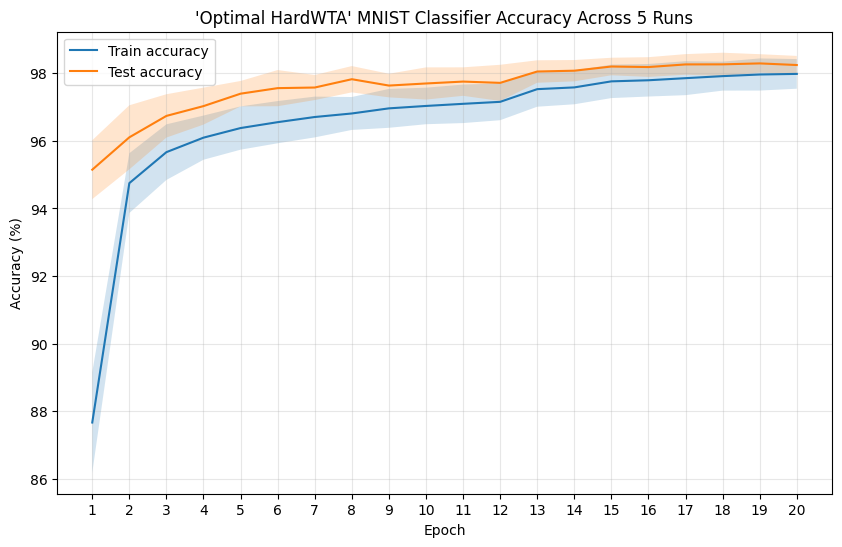

In [27]:
# Mean and standard deviation across the 5 runs
train_mean = train_acc.mean(axis=0)
train_std = train_acc.std(axis=0)

test_mean = test_acc.mean(axis=0)
test_std = test_acc.std(axis=0)

epochs = np.arange(1, 21)

plt.figure(figsize=(10, 6))

plt.plot(epochs, train_mean, label="Train accuracy")
plt.fill_between(
    epochs,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.plot(epochs, test_mean, label="Test accuracy")
plt.fill_between(
    epochs,
    test_mean - test_std,
    test_mean + test_std,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("'Optimal HardWTA' MNIST Classifier Accuracy Across 5 Runs")
plt.xticks(epochs)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [28]:
print(
    f"Final test accuracy: "
    f"{test_mean[-1]:.2f} ± {test_std[-1]:.2f}%"
)

Final test accuracy: 98.24 ± 0.27%


In [29]:
best_per_run = test_acc.max(axis=1)

print(
    f"Best average test accuracy: "
    f"{best_per_run.mean():.2f} ± {best_per_run.std():.2f}%"
)

Best average test accuracy: 98.32 ± 0.28%


In [30]:
#maximum raw test accuracy - aligns with researcher's 98.5
test_acc.max()

np.float64(98.5)

In [31]:
final10 = np.mean(test_acc[:, 10:20], axis=1)

print(
    f"Mean accuracy final 10 epochs: "
    f"{np.mean(final10):.2f} ± {np.std(final10):.2f}%"
)

Mean accuracy final 10 epochs: 98.10 ± 0.33%


# Re-running the normalised version with another seed pool 

In [21]:
final_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Resize((28, 28)),
    transforms.Normalize(mean=[0.1307], std=[0.3081])
])

In [22]:
mnist_root = "../datasets/mnist"

mnist_train = datasets.MNIST(
    root=mnist_root,
    train=True,
    download=False,
    transform=final_transform
)

mnist_test = datasets.MNIST(
    root=mnist_root,
    train=False,
    download=False,
    transform=final_transform #oddly the researchers use random horizontal flipping on the test set (in addition to the train)
)

In [20]:
seeds = [10,11,12,13,14]
all_histories = {}

RUN 11/5 | SEED = 10
Building SoftHebb Greyscale model


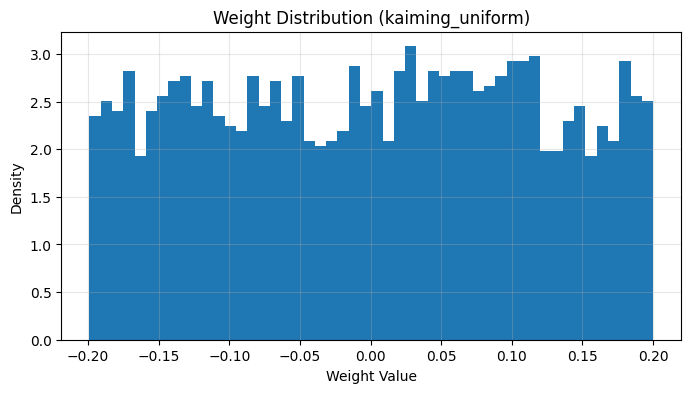

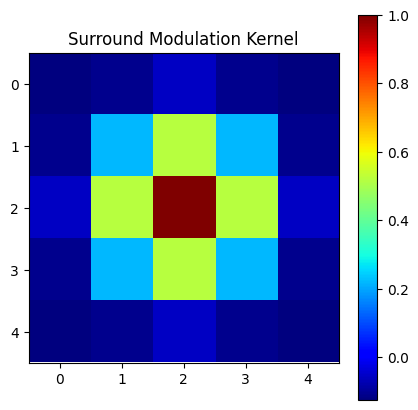

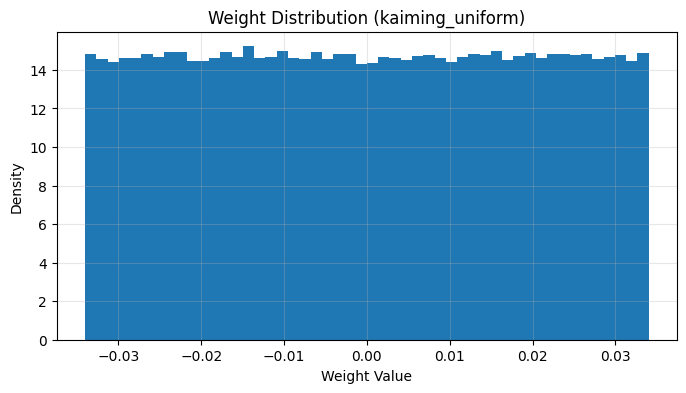

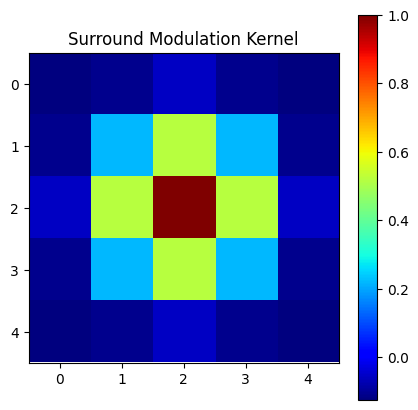

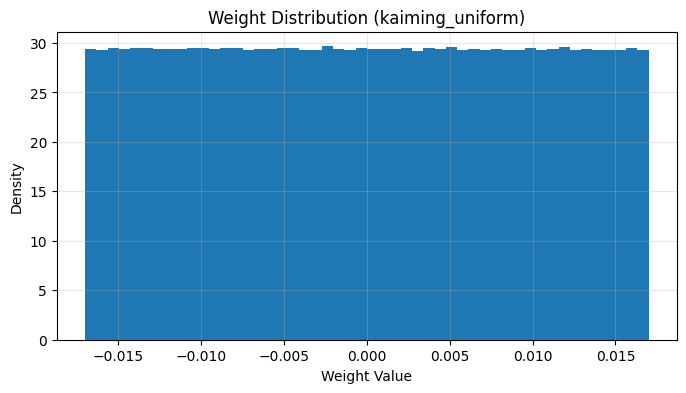

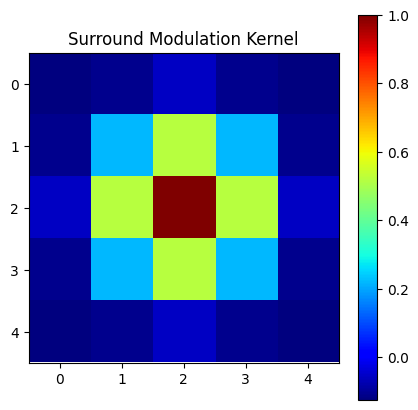

Hebbian epoch 1
Batch 0/938
Batch 100/938
Batch 200/938
Batch 300/938
Batch 400/938
Batch 500/938
Batch 600/938
Batch 700/938
Batch 800/938
Batch 900/938
Epoch [1/20] | Train Loss: 0.3547 | Train Acc: 88.86% | Test Loss: 0.1440 | Test Acc: 95.66% | LR: 0.001000
Epoch [2/20] | Train Loss: 0.1554 | Train Acc: 95.23% | Test Loss: 0.1013 | Test Acc: 96.67% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.1228 | Train Acc: 96.17% | Test Loss: 0.0850 | Test Acc: 97.41% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.1105 | Train Acc: 96.51% | Test Loss: 0.0824 | Test Acc: 97.12% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.1006 | Train Acc: 96.74% | Test Loss: 0.0685 | Test Acc: 97.64% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.0926 | Train Acc: 97.06% | Test Loss: 0.0817 | Test Acc: 97.39% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.0899 | Train Acc: 97.11% | Test Loss: 0.0644 | Test Acc: 97.73% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.0860 | Train Acc: 97.22% | Test Loss: 0.0787 | Test Acc: 97.3

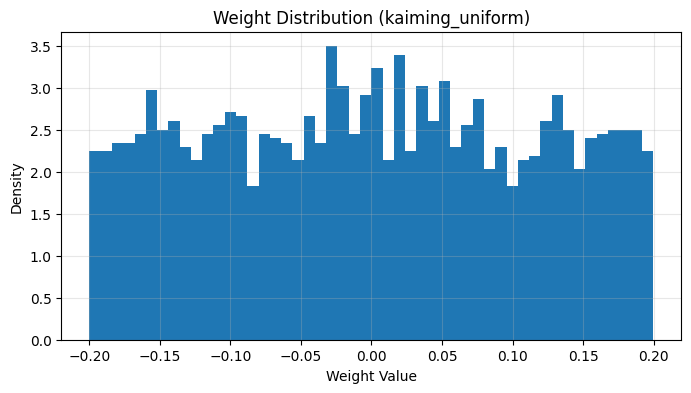

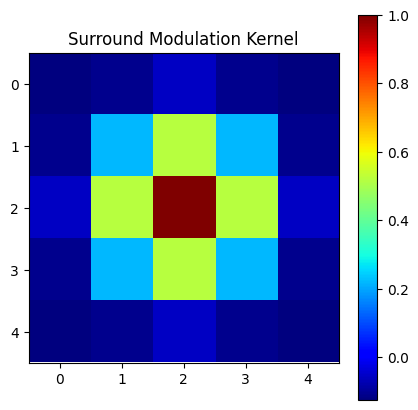

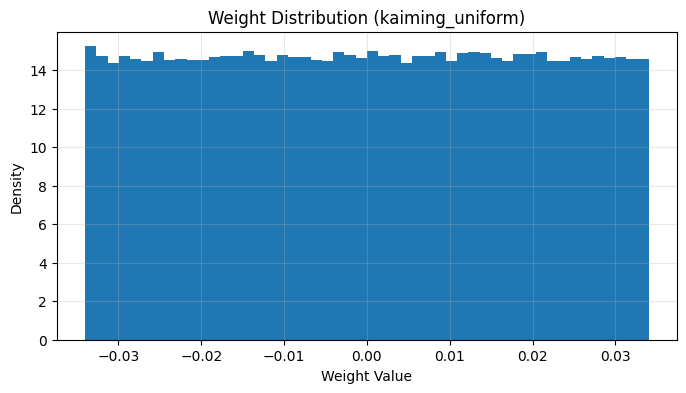

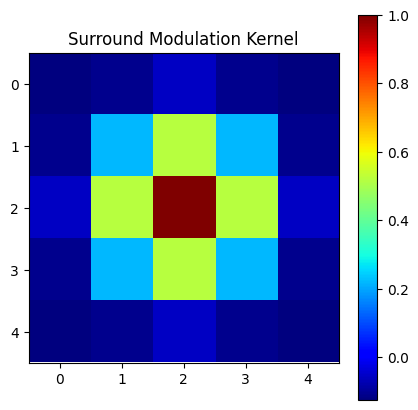

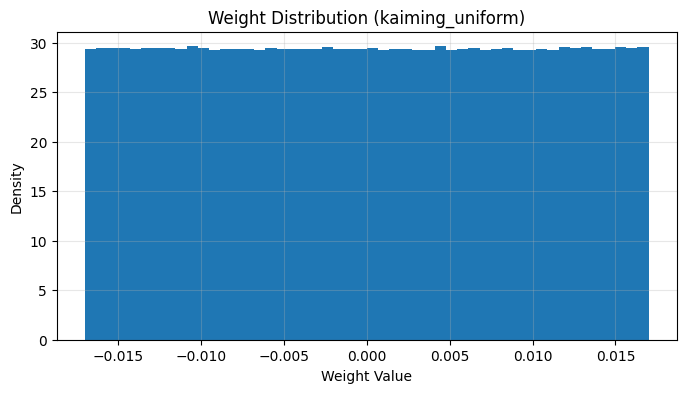

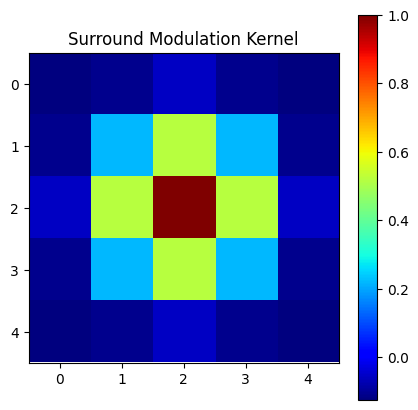

Hebbian epoch 1
Batch 0/938
Batch 100/938
Batch 200/938
Batch 300/938
Batch 400/938
Batch 500/938
Batch 600/938
Batch 700/938
Batch 800/938
Batch 900/938
Epoch [1/20] | Train Loss: 0.3612 | Train Acc: 88.70% | Test Loss: 0.1495 | Test Acc: 95.17% | LR: 0.001000
Epoch [2/20] | Train Loss: 0.1530 | Train Acc: 95.32% | Test Loss: 0.1093 | Test Acc: 96.69% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.1218 | Train Acc: 96.18% | Test Loss: 0.0805 | Test Acc: 97.49% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.1093 | Train Acc: 96.52% | Test Loss: 0.0729 | Test Acc: 97.53% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.1011 | Train Acc: 96.78% | Test Loss: 0.0701 | Test Acc: 97.77% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.0942 | Train Acc: 96.97% | Test Loss: 0.0704 | Test Acc: 97.67% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.0889 | Train Acc: 97.15% | Test Loss: 0.0658 | Test Acc: 97.91% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.0861 | Train Acc: 97.20% | Test Loss: 0.0689 | Test Acc: 97.6

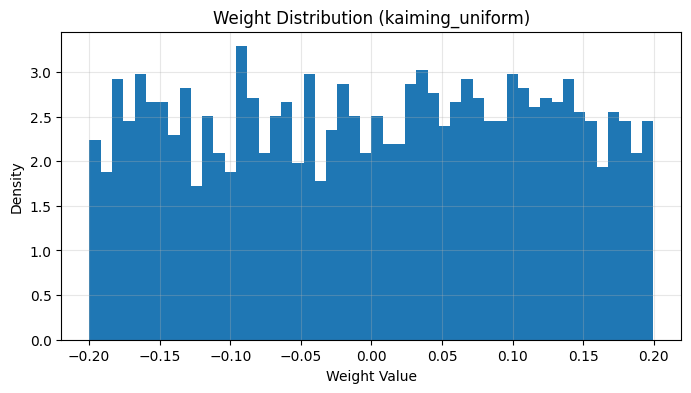

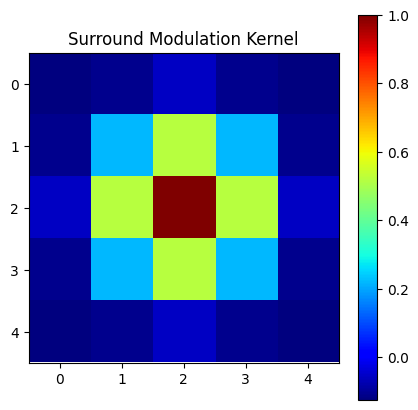

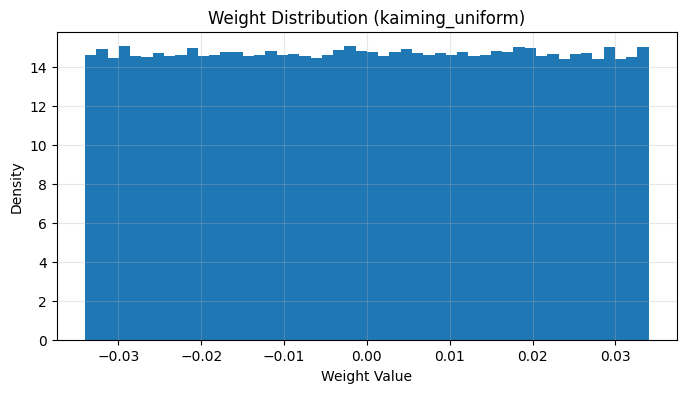

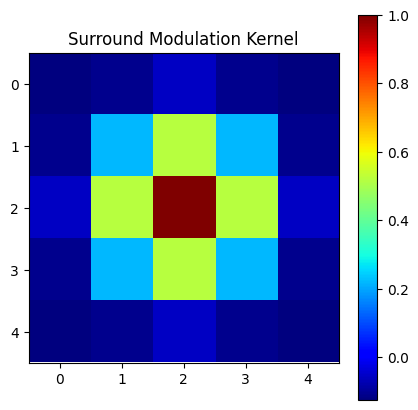

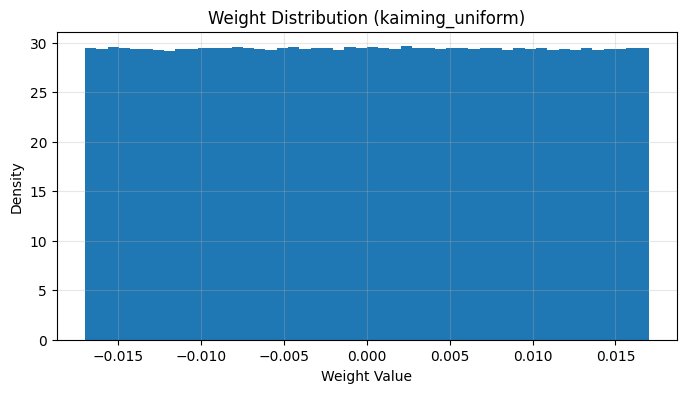

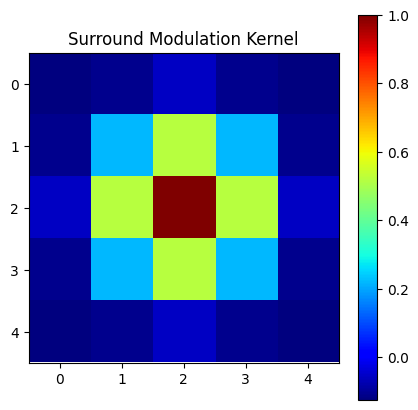

Hebbian epoch 1
Batch 0/938
Batch 100/938
Batch 200/938
Batch 300/938
Batch 400/938
Batch 500/938
Batch 600/938
Batch 700/938
Batch 800/938
Batch 900/938
Epoch [1/20] | Train Loss: 0.4007 | Train Acc: 87.27% | Test Loss: 0.1669 | Test Acc: 95.18% | LR: 0.001000
Epoch [2/20] | Train Loss: 0.1793 | Train Acc: 94.47% | Test Loss: 0.1369 | Test Acc: 95.71% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.1428 | Train Acc: 95.60% | Test Loss: 0.1101 | Test Acc: 96.63% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.1272 | Train Acc: 95.94% | Test Loss: 0.0914 | Test Acc: 96.97% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.1157 | Train Acc: 96.30% | Test Loss: 0.0914 | Test Acc: 97.06% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.1100 | Train Acc: 96.55% | Test Loss: 0.0722 | Test Acc: 97.66% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.1037 | Train Acc: 96.64% | Test Loss: 0.0718 | Test Acc: 97.63% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.1018 | Train Acc: 96.73% | Test Loss: 0.0657 | Test Acc: 97.8

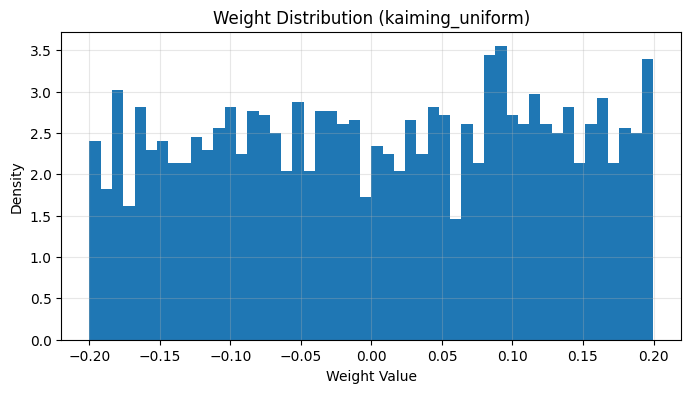

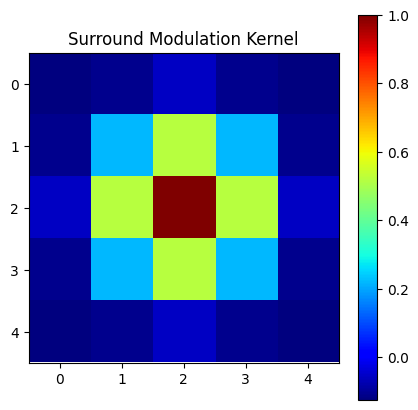

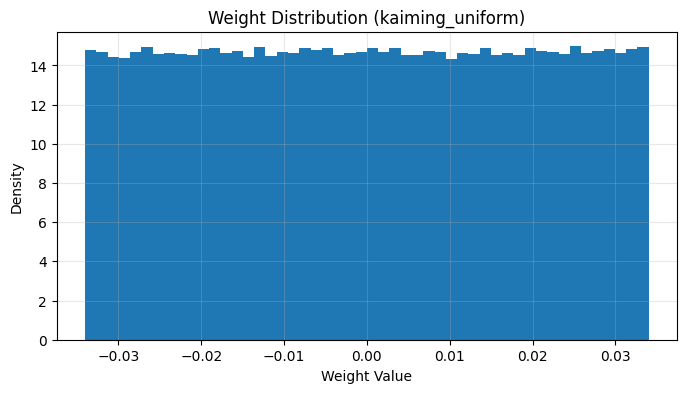

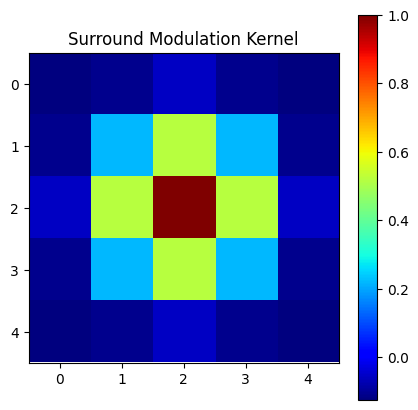

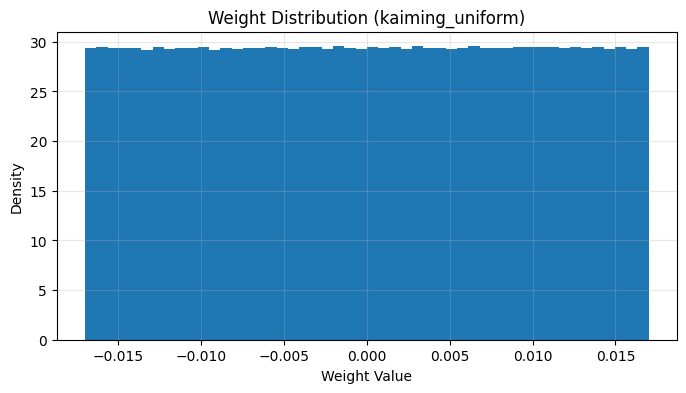

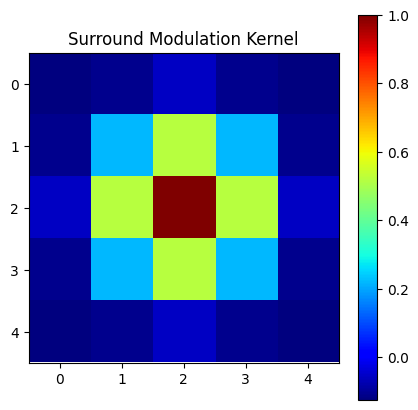

Hebbian epoch 1
Batch 0/938
Batch 100/938
Batch 200/938
Batch 300/938
Batch 400/938
Batch 500/938
Batch 600/938
Batch 700/938
Batch 800/938
Batch 900/938
Epoch [1/20] | Train Loss: 0.3702 | Train Acc: 88.09% | Test Loss: 0.1465 | Test Acc: 95.53% | LR: 0.001000
Epoch [2/20] | Train Loss: 0.1616 | Train Acc: 94.94% | Test Loss: 0.1073 | Test Acc: 96.64% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.1320 | Train Acc: 95.83% | Test Loss: 0.1067 | Test Acc: 96.58% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.1175 | Train Acc: 96.31% | Test Loss: 0.0911 | Test Acc: 97.13% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.1070 | Train Acc: 96.48% | Test Loss: 0.0845 | Test Acc: 97.17% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.1023 | Train Acc: 96.68% | Test Loss: 0.0779 | Test Acc: 97.39% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.1005 | Train Acc: 96.82% | Test Loss: 0.0692 | Test Acc: 97.62% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.0953 | Train Acc: 96.93% | Test Loss: 0.0701 | Test Acc: 97.6

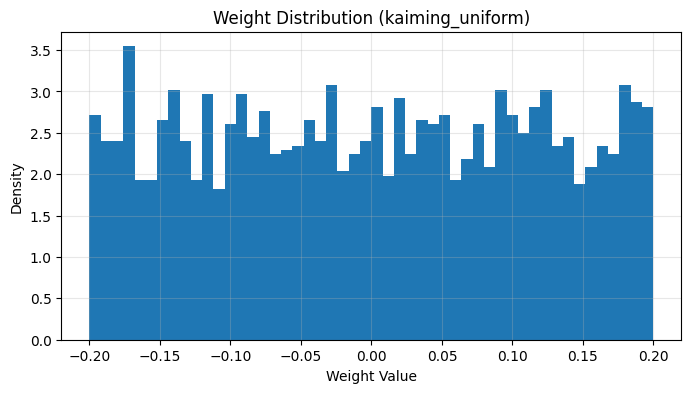

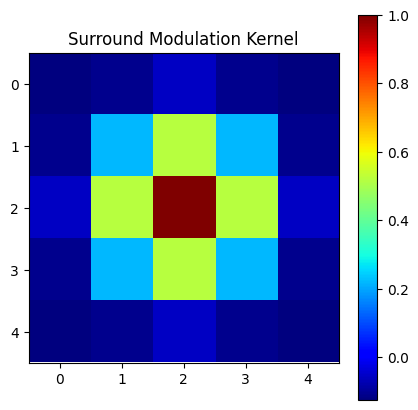

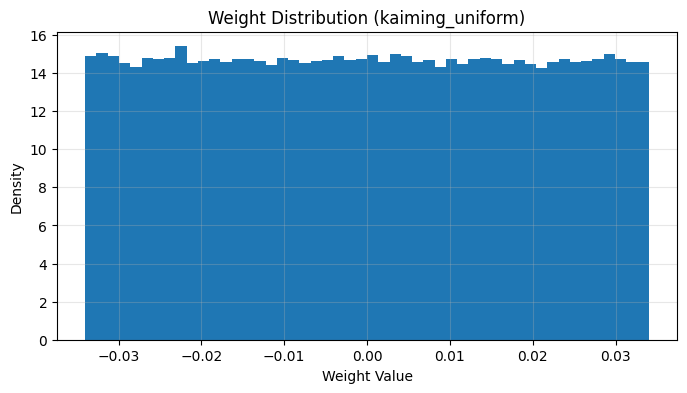

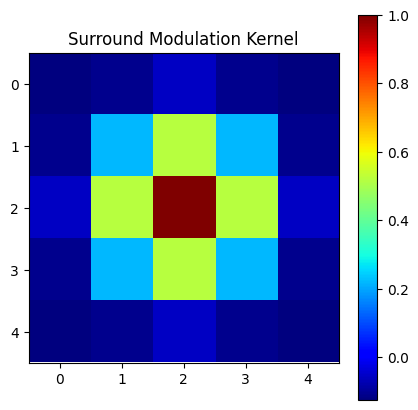

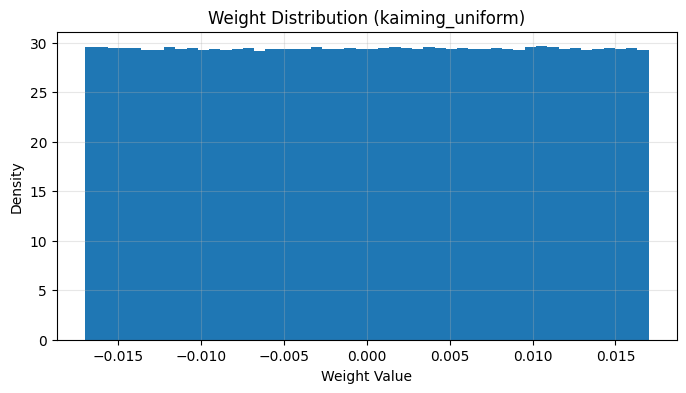

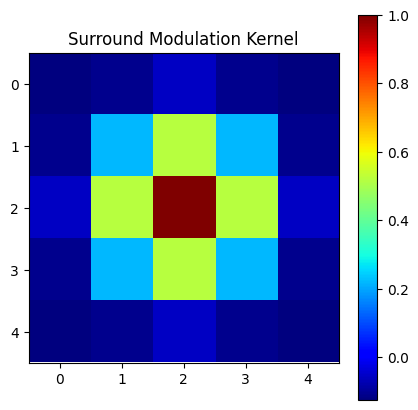

Hebbian epoch 1
Batch 0/938
Batch 100/938
Batch 200/938
Batch 300/938
Batch 400/938
Batch 500/938
Batch 600/938
Batch 700/938
Batch 800/938
Batch 900/938
Epoch [1/20] | Train Loss: 0.3539 | Train Acc: 88.80% | Test Loss: 0.1441 | Test Acc: 95.68% | LR: 0.001000
Epoch [2/20] | Train Loss: 0.1508 | Train Acc: 95.37% | Test Loss: 0.1144 | Test Acc: 96.30% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.1234 | Train Acc: 96.10% | Test Loss: 0.0861 | Test Acc: 97.28% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.1038 | Train Acc: 96.77% | Test Loss: 0.0824 | Test Acc: 97.29% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.0987 | Train Acc: 96.85% | Test Loss: 0.0740 | Test Acc: 97.52% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.0914 | Train Acc: 97.05% | Test Loss: 0.0621 | Test Acc: 97.96% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.0859 | Train Acc: 97.30% | Test Loss: 0.0620 | Test Acc: 97.79% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.0833 | Train Acc: 97.29% | Test Loss: 0.0577 | Test Acc: 98.1

In [21]:
for seed in seeds:

    print(f"RUN {seed + 1}/5 | SEED = {seed}")

   
    set_seed(seed)

      # Generator specifically for this run
    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        mnist_train,
        batch_size=64,
        shuffle=True,
        num_workers=2,
        worker_init_fn=seed_worker,
        generator=g
    )

    test_loader = DataLoader(
        mnist_test,
        batch_size=64,
        shuffle=False, #researchers have test data shuffled, but this is again unecessary, since no learning is occuring (eval only)
        num_workers=2,
        worker_init_fn=seed_worker,
        generator=g
    )

    #fresh model for every seed

    hebb_param = get_hebbian_config(version="optimal")

    model = Net_Hebbian(
        hebb_params=hebb_param,
        version="mnist"
    ).to(device)


    # hebbian feature learning ('Unsupervised Feature Learning Phase' trained for 1 epoch)
    model.train()

    for epoch in range(1):

        print(f"Hebbian epoch {epoch + 1}")

        for i, (inputs, _) in enumerate(train_loader):

            inputs = inputs.to(device)

            
            with torch.no_grad():
                model(inputs)

            for layer in [model.conv1, model.conv2, model.conv3]:
                layer.local_update()

            if i % 100 == 0:
                print(f"Batch {i}/{len(train_loader)}")
                

    # freeze the hebbian feature extractor as now to train classifier

    for module in [
        model.conv1,
        model.conv2,
        model.conv3,
        model.bn1,
        model.bn2,
        model.bn3
    ]:

        for param in module.parameters():
            param.requires_grad = False

        module.eval()

    #optimiser and schedular as defined in experiment_hebbian.py
    sup_optimizer = torch.optim.Adam(
        model.fc1.parameters(),
        lr=0.001
    )

    scheduler = torch.optim.lr_scheduler.LambdaLR(
        sup_optimizer,
        lr_lambda=lambda epoch:
            0.5 ** max(0, (epoch - 10) // 2)
    )

    criterion = nn.CrossEntropyLoss()

    classifier_history = {
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": []
    }

    #train classier for 20 epochs

    for epoch in range(20):
        model.conv1.eval()
        model.conv2.eval()
        model.conv3.eval()

        model.bn1.eval()
        model.bn2.eval()
        model.bn3.eval()

        model.fc1.train()
        model.dropout.train()

        running_loss = 0.0
        correct = 0
        total = 0


        for inputs, labels in train_loader:

            inputs = inputs.to(device)


            labels = labels.to(device)

            sup_optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            loss.backward()

            sup_optimizer.step()

            running_loss += loss.item() * labels.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_accuracy = 100 * correct / total

        #get the evaluation results on the test set

        model.eval()

        test_running_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():

            for inputs, labels in test_loader:

                inputs = inputs.to(device)
   

                labels = labels.to(device)

                outputs = model(inputs)

                loss = criterion(outputs, labels)

                test_running_loss += loss.item() * labels.size(0)

                _, predicted = torch.max(outputs, 1)

                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()

        test_loss = test_running_loss / test_total
        test_accuracy = 100 * test_correct / test_total


        classifier_history["train_loss"].append(train_loss)
        classifier_history["train_accuracy"].append(train_accuracy)

        classifier_history["test_loss"].append(test_loss)
        classifier_history["test_accuracy"].append(test_accuracy)

        #update the scheduler
        scheduler.step()

        current_lr = sup_optimizer.param_groups[0]["lr"]

        print(
            f"Epoch [{epoch + 1}/20] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_accuracy:.2f}% | "
            f"LR: {current_lr:.6f}"
        )

    # save each runs history
    all_histories[seed] = classifier_history

# save results and visualise

In [22]:
# Shape: (5 runs, 20 epochs)
train_acc = np.array([
    all_histories[seed]["train_accuracy"]
    for seed in seeds
])

test_acc = np.array([
    all_histories[seed]["test_accuracy"]
    for seed in seeds
])

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [24]:
train_acc_df=pd.DataFrame(train_acc)

In [25]:
test_acc_df=pd.DataFrame(test_acc)


In [26]:
train_acc_df.to_csv("/content/drive/MyDrive/research_jobs/hebbian_3_layer_MNIST_norm_second_seeds_train_acc_.csv",index=False)

In [27]:
test_acc_df.to_csv("/content/drive/MyDrive/research_jobs/hebbian_3_layer_MNIST_norm_second_seeds_test_acc_.csv",index=False)


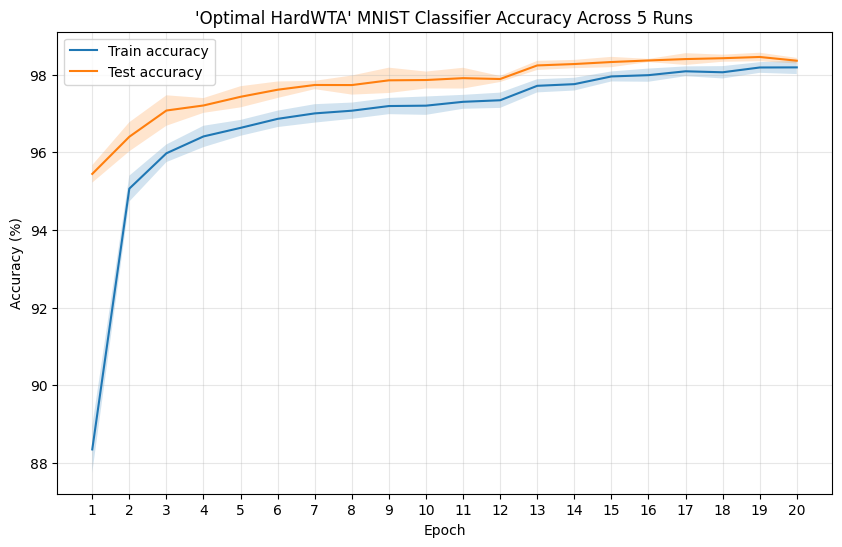

In [28]:
# Mean and standard deviation across the 5 runs
train_mean = train_acc.mean(axis=0)
train_std = train_acc.std(axis=0)

test_mean = test_acc.mean(axis=0)
test_std = test_acc.std(axis=0)

epochs = np.arange(1, 21)

plt.figure(figsize=(10, 6))

plt.plot(epochs, train_mean, label="Train accuracy")
plt.fill_between(
    epochs,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.plot(epochs, test_mean, label="Test accuracy")
plt.fill_between(
    epochs,
    test_mean - test_std,
    test_mean + test_std,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("'Optimal HardWTA' MNIST Classifier Accuracy Across 5 Runs")
plt.xticks(epochs)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [29]:
print(
    f"Final test accuracy: "
    f"{test_mean[-1]:.2f} ± {test_std[-1]:.2f}%"
)

Final test accuracy: 98.36 ± 0.07%


In [30]:
best_per_run = test_acc.max(axis=1)

print(
    f"Best average test accuracy: "
    f"{best_per_run.mean():.2f} ± {best_per_run.std():.2f}%"
)

Best average test accuracy: 98.47 ± 0.10%


In [31]:
#maximum raw test accuracy - aligns with researcher's 98.5
test_acc.max()

np.float64(98.61)

In [32]:
final10 = np.mean(test_acc[:, 10:20], axis=1)

print(
    f"Mean accuracy final 10 epochs: "
    f"{np.mean(final10):.2f} ± {np.std(final10):.2f}%"
)

Mean accuracy final 10 epochs: 98.27 ± 0.09%


# Validating on Cifar-10

## Inspecting optimal model used for cifar-10

Building SoftHebb model


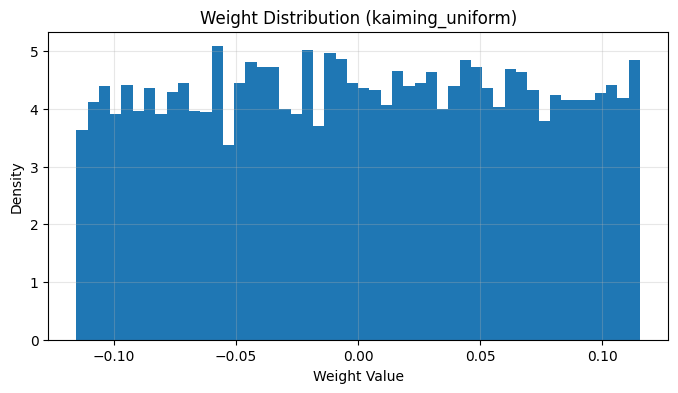

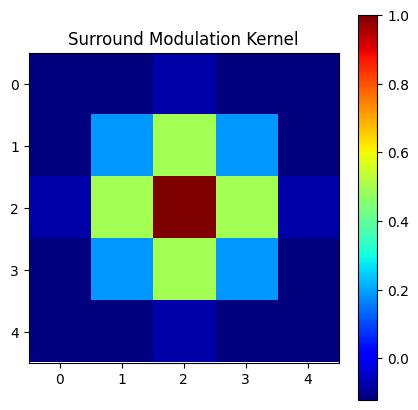

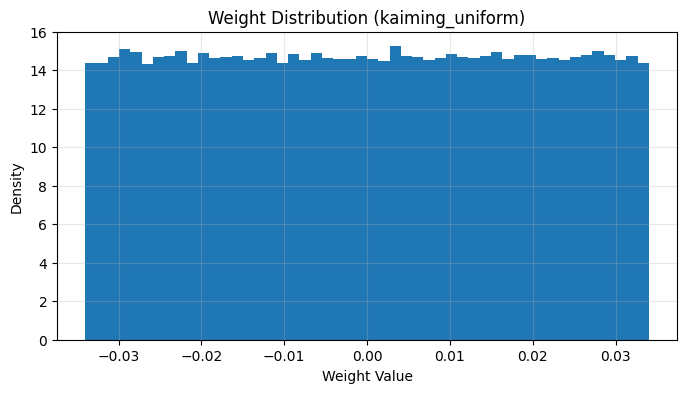

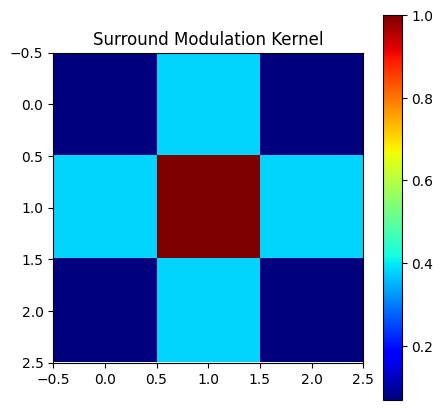

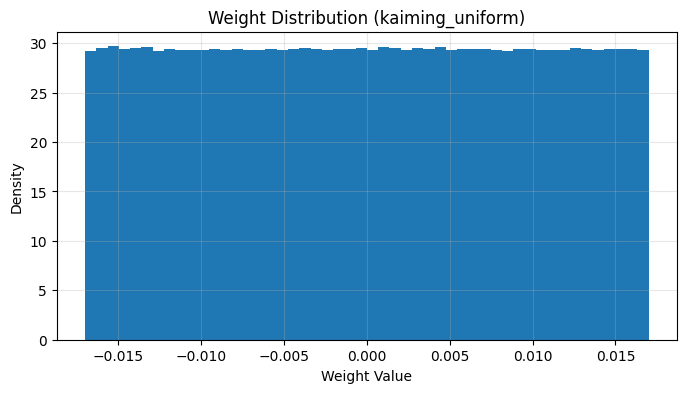

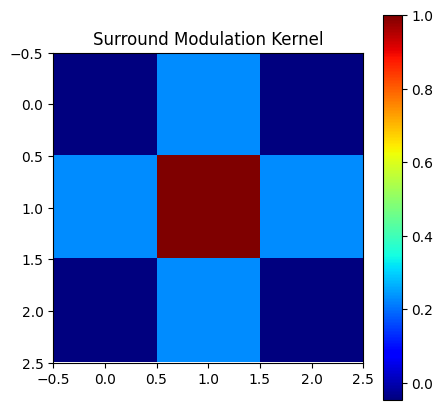

"\nConfusingly the researchers have given their 'optimal-HardWTA' described in the paper, a version name of 'softhebb'... we are not in fact selecting SoftHebb learning here, \nthey in fact use the BCM learning rule which preserves hard winner takes all competition mechanism. The name 'Softhebb' is simply a reference to the Journe architecture that they are building on,\nwhich out of the box used Softhebb mechanism.\n\nAn easier way to understand what their optimal version is, looks like this:\nJourne architecture (as cited in their work) + cosine similarity + lateral inhibition + BCM learning + hard WTA...\nThey describe this 'best performing learning mechanism' as: lateral inhibition and BCM Hebbian learning with Hard-WTA\n"

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

hebb_param = get_hebbian_config(version="optimal")

model = Net_Hebbian(
    hebb_params=hebb_param,
    version="softhebb"
).to(device)
"""
Confusingly the researchers have given their 'optimal-HardWTA' described in the paper, a version name of 'softhebb'... we are not in fact selecting SoftHebb learning here, 
they in fact use the BCM learning rule which preserves hard winner takes all competition mechanism. The name 'Softhebb' is simply a reference to the Journe architecture that they are building on,
which out of the box used Softhebb mechanism.

An easier way to understand what their optimal version is, looks like this:
Journe architecture (as cited in their work) + cosine similarity + lateral inhibition + BCM learning + hard WTA...
They describe this 'best performing learning mechanism' as: lateral inhibition and BCM Hebbian learning with Hard-WTA
"""

In [72]:
for i, layer in enumerate([model.conv1, model.conv2, model.conv3], 1):
    print(
        f"Conv{i}: "
        f"sigma_e={layer.sigma_e}, "
        f"sigma_i={layer.sigma_i}, "
        f"lateral_kernel={layer.lateral_kernel}"
    )

Conv1: sigma_e=1.2, sigma_i=1.3, lateral_kernel=5
Conv2: sigma_e=1.0, sigma_i=1.2, lateral_kernel=3
Conv3: sigma_e=0.8, sigma_i=1.1, lateral_kernel=3


In [73]:
hebb_param

{'mode': 'bcm',
 'w_nrm': False,
 'act': Identity(),
 'use_cosine_similarity': True,
 'use_lateral_inhibition': True,
 'top_k': 1,
 'init_method': 'kaiming_uniform',
 'patchwise': True,
 'contrast': 1.0,
 'uniformity': False,
 'use_presynaptic_competition': False,
 'presynaptic_competition_type': 'lp_norm',
 'competition_type': 'hard',
 'temporal_window': 500,
 'competition_k': 2,
 'dale': False,
 'use_homeostasis': False}

In [74]:
print("conv1 init:", model.conv1.init_method)
print("conv2 init:", model.conv2.init_method)
print("conv3 init:", model.conv3.init_method)

print("conv1 lr:", model.conv1.lr)
print("conv2 lr:", model.conv2.lr)
print("conv3 lr:", model.conv3.lr)

conv1 init: kaiming_uniform
conv2 init: kaiming_uniform
conv3 init: kaiming_uniform
conv1 lr: 0.1
conv2 lr: 0.08
conv3 lr: 0.05


In [75]:
for i, layer in enumerate(
    [model.conv1, model.conv2, model.conv3], 1
):
    print(f"\nConv {i}")
    print("mode:", layer.mode)
    print("w_nrm:", layer.w_nrm)
    print("k:", getattr(layer, "k", "not stored"))
    print("alpha:", layer.alpha)
    print("t_invert:", layer.t_invert.item())
    print("lr:", layer.lr)
    print("init:", layer.init_method)
    print("cosine:", layer.use_cosine_similarity)
    print("lateral inhibition:", layer.use_lateral_inhibition)


Conv 1
mode: bcm
w_nrm: False
k: not stored
alpha: 1.0
t_invert: 1
lr: 0.1
init: kaiming_uniform
cosine: True
lateral inhibition: True

Conv 2
mode: bcm
w_nrm: False
k: not stored
alpha: 1.0
t_invert: 0.6499999761581421
lr: 0.08
init: kaiming_uniform
cosine: True
lateral inhibition: True

Conv 3
mode: bcm
w_nrm: False
k: not stored
alpha: 1.0
t_invert: 0.25
lr: 0.05
init: kaiming_uniform
cosine: True
lateral inhibition: True


In [76]:
print(model)

Net_Hebbian(
  (bn1): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
  (conv1): HebbianConv2d(
    (act): Identity()
  )
  (pool1): MaxPool2d(kernel_size=4, stride=2, padding=1, dilation=1, ceil_mode=False)
  (activ1): Triangle()
  (bn2): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
  (conv2): HebbianConv2d(
    (act): Identity()
  )
  (pool2): MaxPool2d(kernel_size=4, stride=2, padding=1, dilation=1, ceil_mode=False)
  (activ2): Triangle()
  (bn3): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
  (conv3): HebbianConv2d(
    (act): Identity()
  )
  (pool3): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (activ3): Triangle()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=24576, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [77]:
num_parameters = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(f"Parameter count: {num_parameters:,}")

Parameter count: 5,893,162


# Get Cifar-10 paths 
### (since Toronto University servers have incredibly slow download time for cifar-10, again we use the mirror from kaggle and pass it to the get_data function)

In [14]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ayush1220/cifar10")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cifar10' dataset.
Path to dataset files: /kaggle/input/cifar10


In [15]:
print(os.listdir(path))

['cifar10']


In [16]:
cifar_path = os.path.join(path, "cifar10")

# Making use of their exact process for zca:
### Results are not on par with those reported, with test accuracy differing by between ~1% - ~2%
### Furthermore the process is incredibly slow, taking around an hour to complete one seed (hence is cut short after 7 epochs, after which I optimise their procedure)...

In [ ]:
# whitening
cifar_trn_loader, cifar_tst_loader, cifar_zca = get_data(
    dataset='cifar10',
    batch_size=64,
    whiten_lvl=1e-3,
    kaggle_cifar_path=cifar_path
)

Data Batch whitening
Loaded pre-computed batch ZCA matrix for cifar10
I removed the temp dataset


Building SoftHebb model


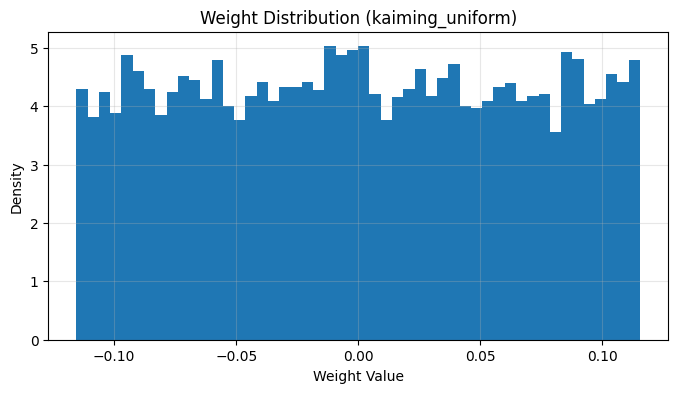

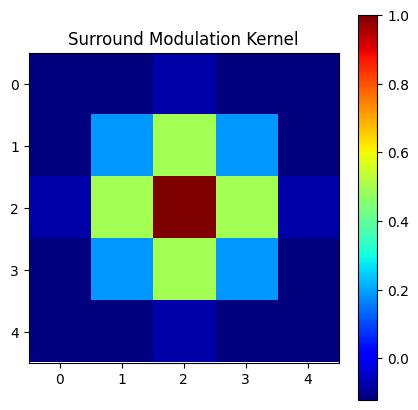

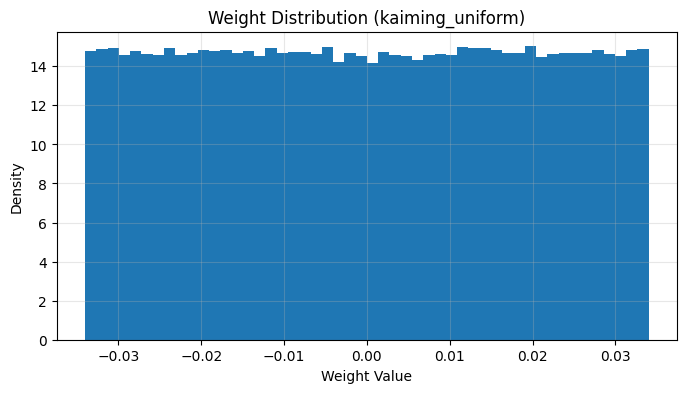

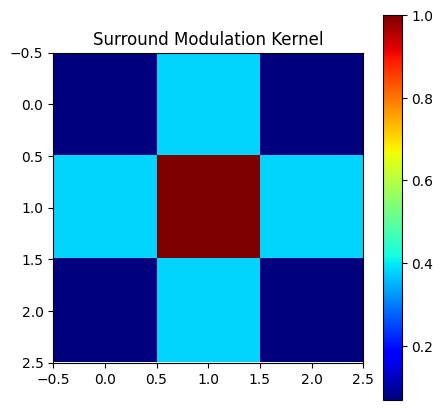

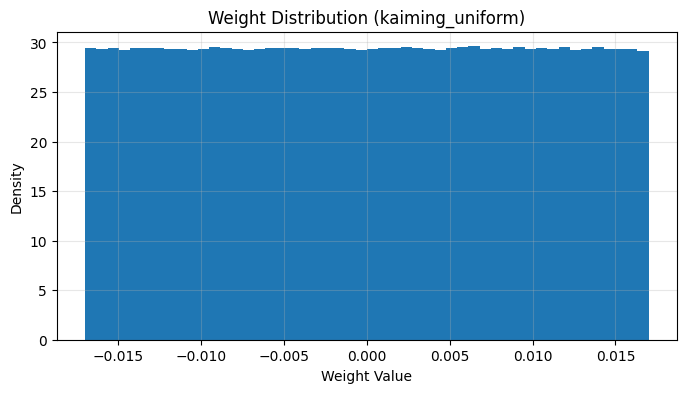

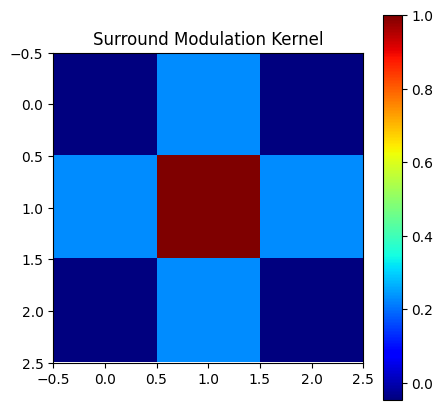

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 1.2845 | Train Acc: 55.09% | Test Loss: 1.0117 | Test Acc: 64.68% | LR: 0.001000
Epoch [2/20] | Train Loss: 1.0075 | Train Acc: 65.13% | Test Loss: 0.9463 | Test Acc: 67.08% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.9353 | Train Acc: 67.81% | Test Loss: 0.8785 | Test Acc: 69.69% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.8967 | Train Acc: 69.26% | Test Loss: 0.8562 | Test Acc: 69.95% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.8759 | Train Acc: 69.68% | Test Loss: 0.8471 | Test Acc: 70.50% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.8543 | Train Acc: 70.18% | Test Loss: 0.8085 | Test Acc: 71.56% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.8361 | Train Acc: 71.09% | Test Loss: 0.8344 | Test Acc: 70.72% | LR: 0.001000


KeyboardInterrupt: 

In [ ]:
hebb_param = get_hebbian_config(version="optimal")

model = Net_Hebbian(
        hebb_params=hebb_param,
        version="softhebb"
    ).to(device)


# hebbian feature learning ('Unsupervised Feature Learning Phase' trained for 1 epoch)
model.train()

for epoch in range(1):

    print(f"Hebbian epoch {epoch + 1}")

    for i, (inputs, _) in enumerate(cifar_trn_loader):

        inputs = inputs.to(device)

        with torch.no_grad():
            model(inputs)

        for layer in [model.conv1, model.conv2, model.conv3]:
            layer.local_update()

        if i % 100 == 0:
            print(f"Batch {i}/{len(cifar_trn_loader)}")
                

# freeze the hebbian feature extractor as now to train classifier

for module in [
        model.conv1,
        model.conv2,
        model.conv3,
        model.bn1,
        model.bn2,
        model.bn3
    ]:

    for param in module.parameters():
        param.requires_grad = False

    module.eval()

#optimiser and schedular as defined in experiment_hebbian.py
sup_optimizer = torch.optim.Adam(
        model.fc1.parameters(),
        lr=0.001
    )

scheduler = torch.optim.lr_scheduler.LambdaLR(
        sup_optimizer,
        lr_lambda=lambda epoch:
            0.5 ** max(0, (epoch - 10) // 2)
    )

criterion = nn.CrossEntropyLoss()

classifier_history = {
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": []
    }

#train classier for 20 epochs

for epoch in range(20):
    model.conv1.eval()
    model.conv2.eval()
    model.conv3.eval()

    model.bn1.eval()
    model.bn2.eval()
    model.bn3.eval()

    model.fc1.train()
    model.dropout.train()

    running_loss = 0.0
    correct = 0
    total = 0


    for inputs, labels in cifar_trn_loader:

        inputs = inputs.to(device)

        labels = labels.to(device)

        sup_optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, labels)

        loss.backward()

        sup_optimizer.step()

        running_loss += loss.item() * labels.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_accuracy = 100 * correct / total

    #get the evaluation results on the test set

    model.eval()

    test_running_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():

        for inputs, labels in cifar_tst_loader:

            inputs = inputs.to(device)
        

            labels = labels.to(device)

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            test_running_loss += loss.item() * labels.size(0)

            _, predicted = torch.max(outputs, 1)

            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    test_loss = test_running_loss / test_total
    test_accuracy = 100 * test_correct / test_total


    classifier_history["train_loss"].append(train_loss)
    classifier_history["train_accuracy"].append(train_accuracy)

    classifier_history["test_loss"].append(test_loss)
    classifier_history["test_accuracy"].append(test_accuracy)

    #update the scheduler
    scheduler.step()

    current_lr = sup_optimizer.param_groups[0]["lr"]

    print(
            f"Epoch [{epoch + 1}/20] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_accuracy:.2f}% | "
            f"LR: {current_lr:.6f}"
        )
# save each runs history
#all_histories[seed] = classifier_history

# Trying no whitening, instead using their normalisation 
### (again results are not comparable with those reported, without whitening we see a decrease in performance)

In [17]:
cifar_train_path = os.path.join(cifar_path,"train")

In [19]:
cifar_test_path = os.path.join(cifar_path,"test")

In [ ]:
final_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
])

In [ ]:
train_dataset = datasets.ImageFolder(
    root=cifar_train_path,
    transform=final_transform
)

test_dataset = datasets.ImageFolder(
    root=cifar_test_path,
    transform=final_transform
)

RUN 1/5 | SEED = 0
Building SoftHebb model


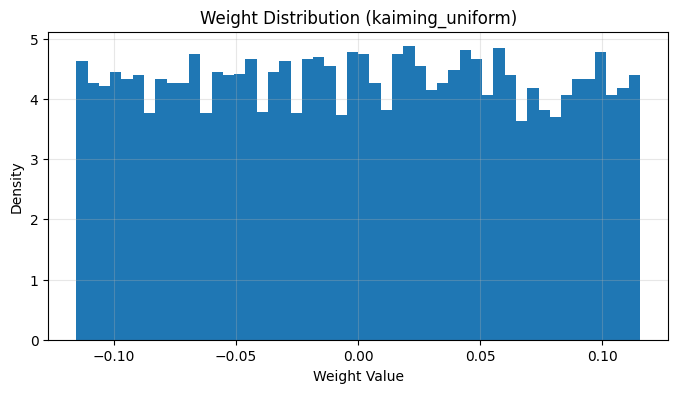

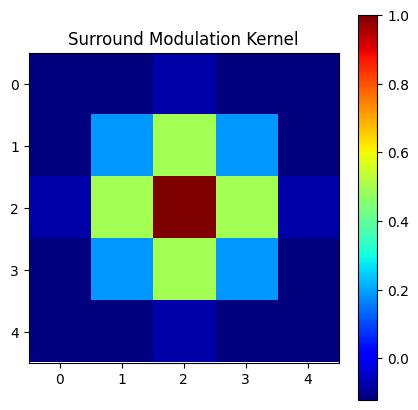

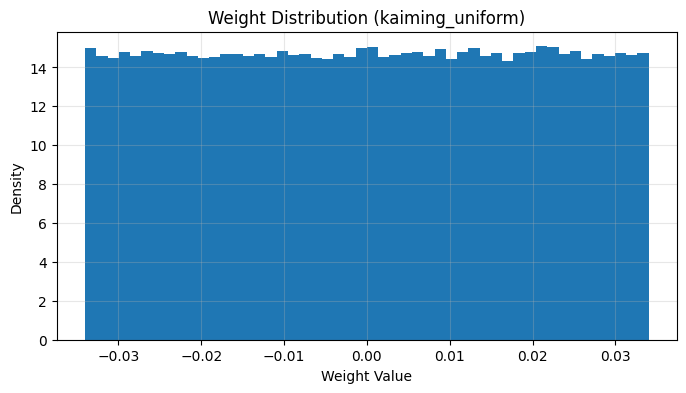

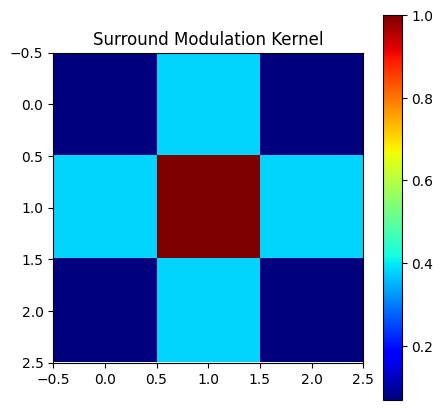

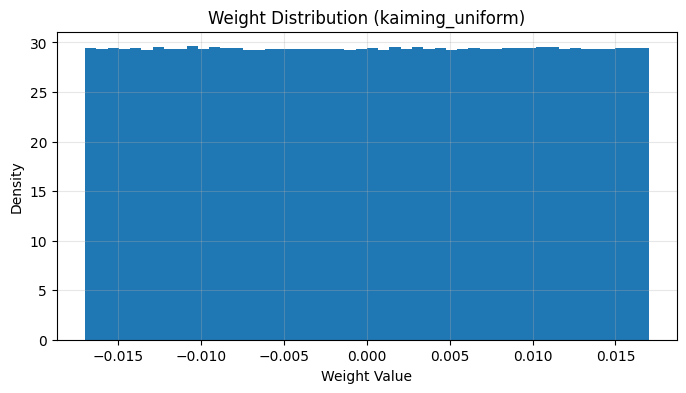

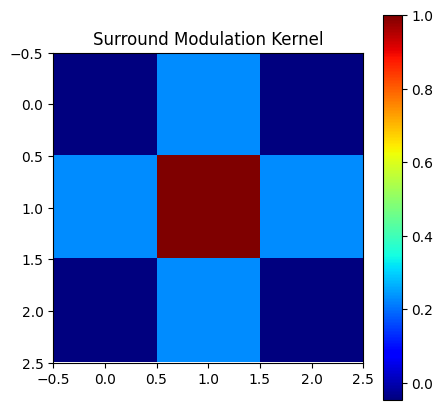

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 1.4436 | Train Acc: 48.69% | Test Loss: 1.1576 | Test Acc: 58.51% | LR: 0.001000
Epoch [2/20] | Train Loss: 1.1637 | Train Acc: 59.09% | Test Loss: 1.0481 | Test Acc: 63.55% | LR: 0.001000
Epoch [3/20] | Train Loss: 1.0825 | Train Acc: 62.16% | Test Loss: 1.0065 | Test Acc: 64.98% | LR: 0.001000
Epoch [4/20] | Train Loss: 1.0477 | Train Acc: 63.48% | Test Loss: 0.9800 | Test Acc: 65.70% | LR: 0.001000
Epoch [5/20] | Train Loss: 1.0126 | Train Acc: 64.64% | Test Loss: 0.9600 | Test Acc: 66.24% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.9985 | Train Acc: 65.23% | Test Loss: 0.9499 | Test Acc: 66.85% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.9830 | Train Acc: 65.54% | Test Loss: 0.9345 | Test Acc: 67.24% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.9733 | Train Acc: 66.07% | Test Loss: 0.8998 | Test Acc: 68.67% | LR: 0.001000
Epoch [9/2

In [28]:
seeds=[0]
all_histories={}

for seed in seeds:

    print(f"RUN {seed + 1}/5 | SEED = {seed}")

   
    set_seed(seed)

      # Generator specifically for this run
    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=64,
        shuffle=True,
        num_workers=2,
        worker_init_fn=seed_worker,
        generator=g
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=64,
        shuffle=False, #researchers have test data shuffled, but this is again unecessary, since no learning is occuring (eval only)
        num_workers=2,
        worker_init_fn=seed_worker,
        generator=g
    )

    #fresh model for every seed

    hebb_param = get_hebbian_config(version="optimal")

    model = Net_Hebbian(
        hebb_params=hebb_param,
        version="softhebb"
    ).to(device)


    # hebbian feature learning ('Unsupervised Feature Learning Phase' trained for 1 epoch)
    model.train()

    for epoch in range(1):

        print(f"Hebbian epoch {epoch + 1}")

        for i, (inputs, _) in enumerate(train_loader):

            inputs = inputs.to(device)

            
            with torch.no_grad():
                model(inputs)

            for layer in [model.conv1, model.conv2, model.conv3]:
                layer.local_update()

            if i % 100 == 0:
                print(f"Batch {i}/{len(train_loader)}")
                

    # freeze the hebbian feature extractor as now to train classifier

    for module in [
        model.conv1,
        model.conv2,
        model.conv3,
        model.bn1,
        model.bn2,
        model.bn3
    ]:

        for param in module.parameters():
            param.requires_grad = False

        module.eval()

    #optimiser and schedular as defined in experiment_hebbian.py
    sup_optimizer = torch.optim.Adam(
        model.fc1.parameters(),
        lr=0.001
    )

    scheduler = torch.optim.lr_scheduler.LambdaLR(
        sup_optimizer,
        lr_lambda=lambda epoch:
            0.5 ** max(0, (epoch - 10) // 2)
    )

    criterion = nn.CrossEntropyLoss()

    classifier_history = {
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": []
    }

    #train classier for 20 epochs

    for epoch in range(20):
        model.conv1.eval()
        model.conv2.eval()
        model.conv3.eval()

        model.bn1.eval()
        model.bn2.eval()
        model.bn3.eval()

        model.fc1.train()
        model.dropout.train()

        running_loss = 0.0
        correct = 0
        total = 0


        for inputs, labels in train_loader:

            inputs = inputs.to(device)

            labels = labels.to(device)

            sup_optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            loss.backward()

            sup_optimizer.step()

            running_loss += loss.item() * labels.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_accuracy = 100 * correct / total

        #get the evaluation results on the test set

        model.eval()

        test_running_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():

            for inputs, labels in test_loader:

                inputs = inputs.to(device)


                labels = labels.to(device)

                outputs = model(inputs)

                loss = criterion(outputs, labels)

                test_running_loss += loss.item() * labels.size(0)

                _, predicted = torch.max(outputs, 1)

                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()

        test_loss = test_running_loss / test_total
        test_accuracy = 100 * test_correct / test_total


        classifier_history["train_loss"].append(train_loss)
        classifier_history["train_accuracy"].append(train_accuracy)

        classifier_history["test_loss"].append(test_loss)
        classifier_history["test_accuracy"].append(test_accuracy)

        #update the scheduler
        scheduler.step()

        current_lr = sup_optimizer.param_groups[0]["lr"]

        print(
            f"Epoch [{epoch + 1}/20] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_accuracy:.2f}% | "
            f"LR: {current_lr:.6f}"
        )

    # save each runs history
    all_histories[seed] = classifier_history

# Trying no whitening, no normalisation: rerun

In [ ]:
# establish train sets

RUN 1/5 | SEED = 0
Building SoftHebb model


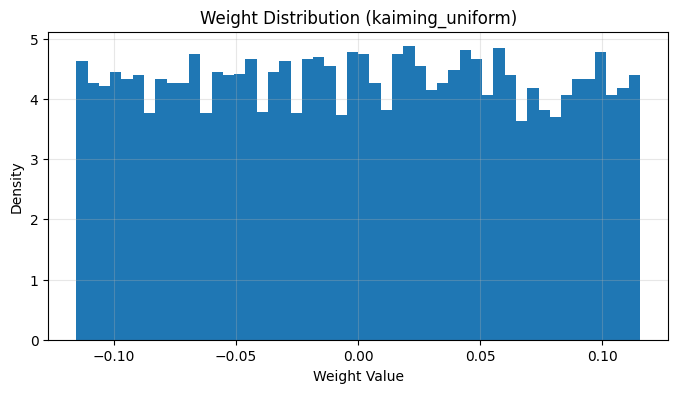

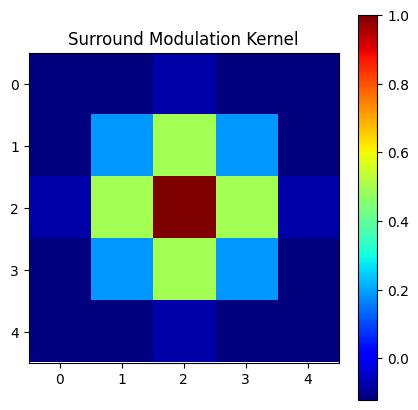

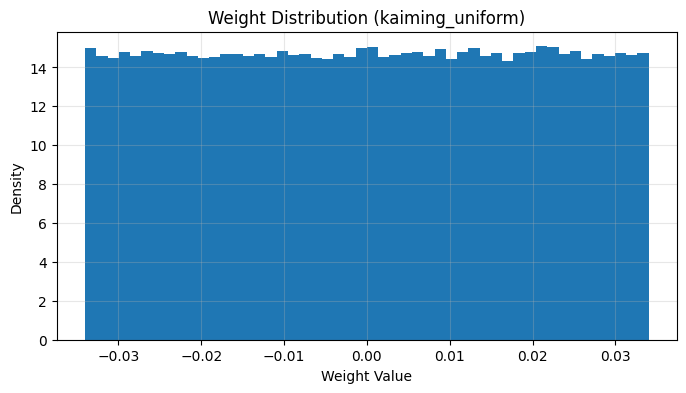

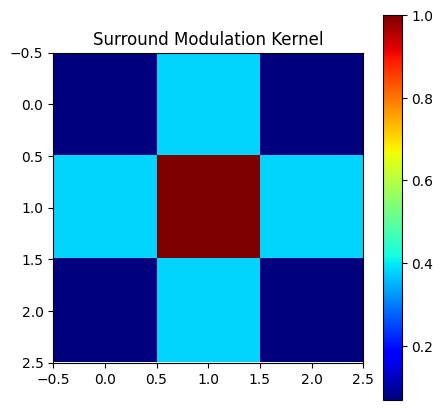

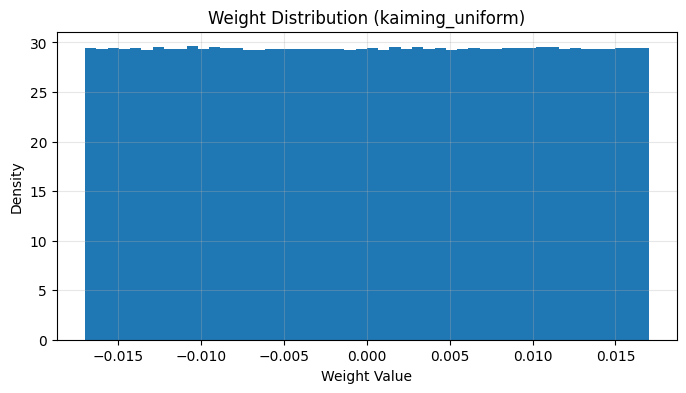

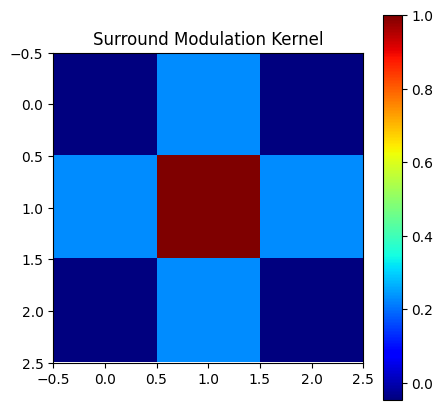

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 1.4469 | Train Acc: 48.61% | Test Loss: 1.1567 | Test Acc: 58.39% | LR: 0.001000
Epoch [2/20] | Train Loss: 1.1656 | Train Acc: 58.88% | Test Loss: 1.0486 | Test Acc: 63.57% | LR: 0.001000
Epoch [3/20] | Train Loss: 1.0849 | Train Acc: 62.03% | Test Loss: 1.0083 | Test Acc: 64.92% | LR: 0.001000
Epoch [4/20] | Train Loss: 1.0521 | Train Acc: 63.20% | Test Loss: 0.9836 | Test Acc: 65.14% | LR: 0.001000


KeyboardInterrupt: 

In [ ]:
seeds=[0]
all_histories={}

for seed in seeds:

    print(f"RUN {seed + 1}/5 | SEED = {seed}")

   
    set_seed(seed)

      # Generator specifically for this run
    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=64,
        shuffle=True,
        num_workers=2,
        worker_init_fn=seed_worker,
        generator=g
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=64,
        shuffle=False, #researchers have test data shuffled, but this is again unecessary, since no learning is occuring (eval only)
        num_workers=2,
        worker_init_fn=seed_worker,
        generator=g
    )

    #fresh model for every seed

    hebb_param = get_hebbian_config(version="optimal")

    model = Net_Hebbian(
        hebb_params=hebb_param,
        version="softhebb"
    ).to(device)


    # hebbian feature learning ('Unsupervised Feature Learning Phase' trained for 1 epoch)
    model.train()

    for epoch in range(1):

        print(f"Hebbian epoch {epoch + 1}")

        for i, (inputs, _) in enumerate(train_loader):

            inputs = inputs.to(device)

            
            with torch.no_grad():
                model(inputs)

            for layer in [model.conv1, model.conv2, model.conv3]:
                layer.local_update()

            if i % 100 == 0:
                print(f"Batch {i}/{len(train_loader)}")
                

    # freeze the hebbian feature extractor as now to train classifier

    for module in [
        model.conv1,
        model.conv2,
        model.conv3,
        model.bn1,
        model.bn2,
        model.bn3
    ]:

        for param in module.parameters():
            param.requires_grad = False

        module.eval()

    #optimiser and schedular as defined in experiment_hebbian.py
    sup_optimizer = torch.optim.Adam(
        model.fc1.parameters(),
        lr=0.001
    )

    scheduler = torch.optim.lr_scheduler.LambdaLR(
        sup_optimizer,
        lr_lambda=lambda epoch:
            0.5 ** max(0, (epoch - 10) // 2)
    )

    criterion = nn.CrossEntropyLoss()

    classifier_history = {
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": []
    }

    #train classier for 20 epochs

    for epoch in range(20):
        model.conv1.eval()
        model.conv2.eval()
        model.conv3.eval()

        model.bn1.eval()
        model.bn2.eval()
        model.bn3.eval()

        model.fc1.train()
        model.dropout.train()

        running_loss = 0.0
        correct = 0
        total = 0


        for inputs, labels in train_loader:

            inputs = inputs.to(device)

            labels = labels.to(device)

            sup_optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            loss.backward()

            sup_optimizer.step()

            running_loss += loss.item() * labels.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_accuracy = 100 * correct / total

        #get the evaluation results on the test set

        model.eval()

        test_running_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():

            for inputs, labels in test_loader:

                inputs = inputs.to(device)


                labels = labels.to(device)

                outputs = model(inputs)

                loss = criterion(outputs, labels)

                test_running_loss += loss.item() * labels.size(0)

                _, predicted = torch.max(outputs, 1)

                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()

        test_loss = test_running_loss / test_total
        test_accuracy = 100 * test_correct / test_total


        classifier_history["train_loss"].append(train_loss)
        classifier_history["train_accuracy"].append(train_accuracy)

        classifier_history["test_loss"].append(test_loss)
        classifier_history["test_accuracy"].append(test_accuracy)

        #update the scheduler
        scheduler.step()

        current_lr = sup_optimizer.param_groups[0]["lr"]

        print(
            f"Epoch [{epoch + 1}/20] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_accuracy:.2f}% | "
            f"LR: {current_lr:.6f}"
        )

    # save each runs history
    all_histories[seed] = classifier_history

# Optimising their zca procedure
### (zca is performed batchwise and stats are reused instead of being recomputed)
### Results however, are still ~1% - ~2% shy of those reported

## Whitening

In [19]:
class ZCAWhitening:
    def __init__(self, epsilon=1e-3):
        self.epsilon = epsilon
        self.zca_matrix = None
        self.mean = None
        self.std = None

    def fit(self, x):
        x = x.reshape(x.shape[0], -1)

        self.mean = x.mean(dim=0, keepdim=True)
        self.std = x.std(dim=0, keepdim=True)

        x = (x - self.mean) / (self.std + self.epsilon)

        cov = torch.mm(x.T, x) / (x.shape[0] - 1)

        eigenvalues, eigenvectors = torch.linalg.eigh(cov)

        inv_sqrt_eigenvalues = torch.diag(
            1.0 / torch.sqrt(eigenvalues + self.epsilon)
        )

        self.zca_matrix = (
            eigenvectors
            @ inv_sqrt_eigenvalues
            @ eigenvectors.T
        )

    def transform(self, x):
        original_shape = x.shape

        x = x.reshape(x.shape[0], -1)
        x = (x - self.mean) / (self.std + self.epsilon)

        x_whitened = torch.mm(x, self.zca_matrix)

        return x_whitened.reshape(original_shape)

### Getting train split

In [ ]:
from torchvision import datasets, transforms


base_transform = transforms.ToTensor()

train_dataset = datasets.ImageFolder(
    root=cifar_train_path,
    transform=base_transform
)

### Getting Test Split

In [ ]:
cifar_test_path = os.path.join(cifar_path,"test")

In [ ]:
test_dataset = datasets.ImageFolder(
    root=cifar_test_path,
    transform=base_transform
)

In [ ]:
combined_dataset = ConcatDataset([
    train_dataset,
    test_dataset
])

zca_loader = DataLoader(
    combined_dataset,
    batch_size=64,
    shuffle=False #no need to shuffle the zca loader (its not learning)
)

In [ ]:
all_data = []

for images, _ in zca_loader:
    all_data.append(images)

all_data = torch.cat(all_data, dim=0)

print(all_data.shape)

torch.Size([60000, 3, 32, 32])


In [ ]:
zca = ZCAWhitening(epsilon=1e-3)
#researchers perform zca whitening across the whole dataset (train and test), which would seem to leak statistics 
zca.fit(all_data)

In [ ]:
final_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    
])

In [ ]:
train_dataset = datasets.ImageFolder(
    root=cifar_train_path,
    transform=final_transform
)

#oddly the researchers use random horizontal flipping on the test set (in addition to the train)
test_dataset = datasets.ImageFolder(
    root=cifar_test_path,
    transform=final_transform
)

RUN 1/5 | SEED = 0
Building SoftHebb model


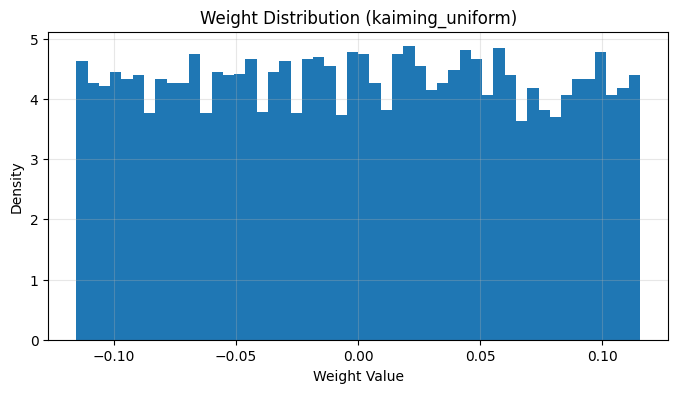

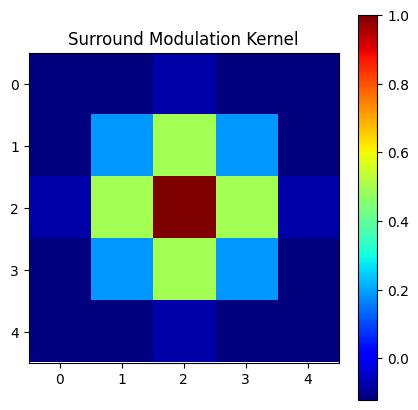

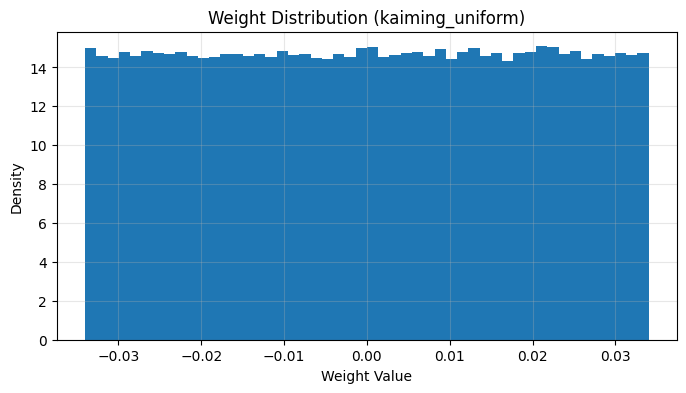

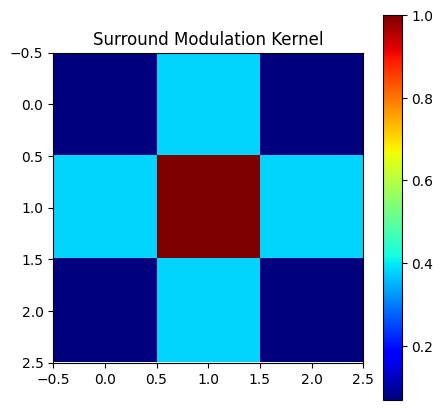

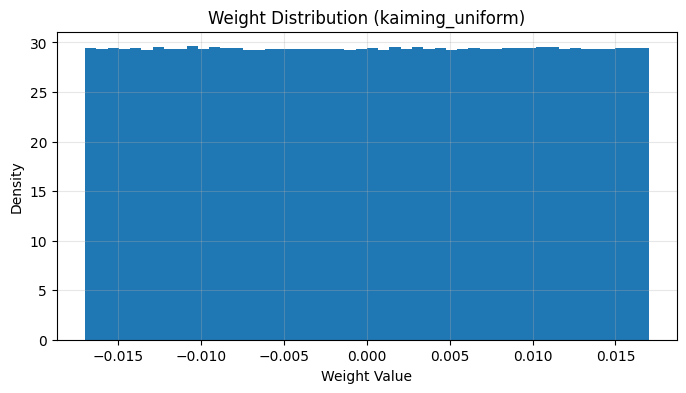

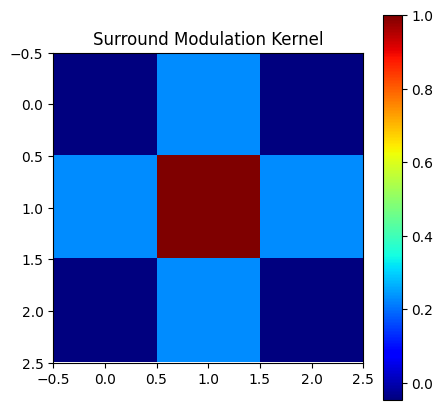

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 1.2929 | Train Acc: 54.75% | Test Loss: 1.0132 | Test Acc: 65.14% | LR: 0.001000
Epoch [2/20] | Train Loss: 1.0190 | Train Acc: 64.82% | Test Loss: 0.9239 | Test Acc: 67.88% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.9501 | Train Acc: 67.31% | Test Loss: 0.8867 | Test Acc: 69.70% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.9096 | Train Acc: 68.52% | Test Loss: 0.8701 | Test Acc: 69.54% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.8815 | Train Acc: 69.15% | Test Loss: 0.8699 | Test Acc: 69.73% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.8622 | Train Acc: 70.06% | Test Loss: 0.8375 | Test Acc: 71.32% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.8438 | Train Acc: 70.60% | Test Loss: 0.8710 | Test Acc: 69.49% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.8322 | Train Acc: 71.09% | Test Loss: 0.8163 | Test Acc: 71.90% | LR: 0.001000
Epoch [9/2

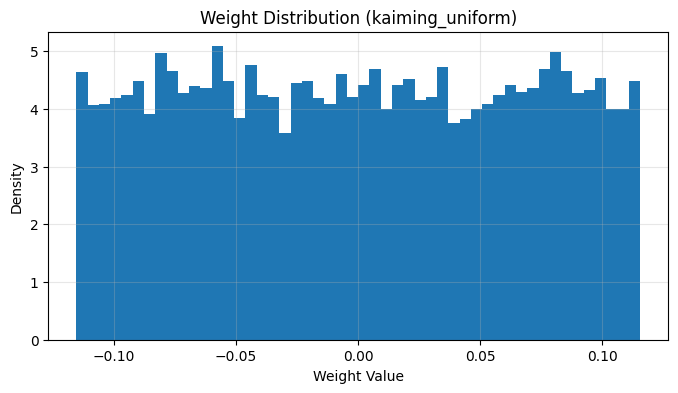

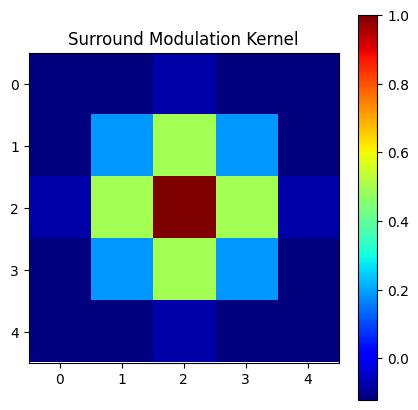

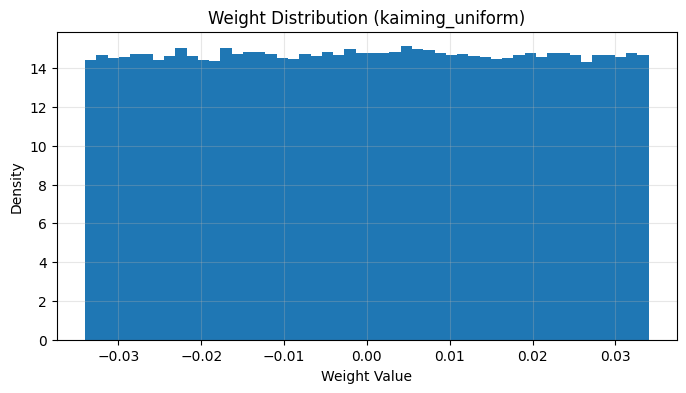

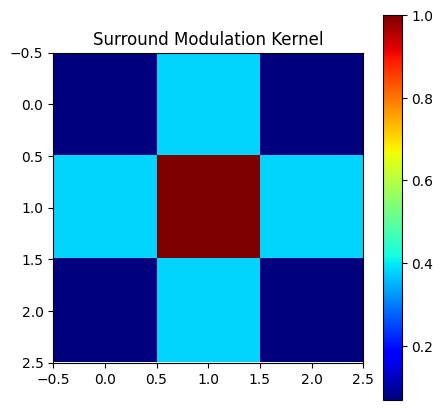

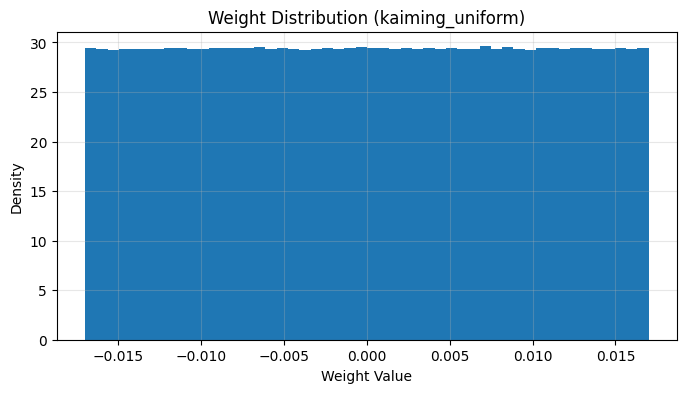

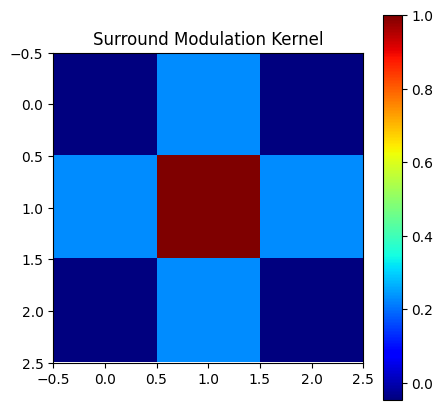

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 1.2615 | Train Acc: 56.27% | Test Loss: 1.0055 | Test Acc: 65.90% | LR: 0.001000
Epoch [2/20] | Train Loss: 0.9865 | Train Acc: 66.33% | Test Loss: 0.9296 | Test Acc: 67.49% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.9130 | Train Acc: 68.42% | Test Loss: 0.8790 | Test Acc: 69.80% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.8723 | Train Acc: 69.89% | Test Loss: 0.8392 | Test Acc: 70.81% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.8449 | Train Acc: 70.91% | Test Loss: 0.8374 | Test Acc: 71.03% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.8278 | Train Acc: 71.21% | Test Loss: 0.8333 | Test Acc: 71.16% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.8136 | Train Acc: 71.96% | Test Loss: 0.8227 | Test Acc: 71.13% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.8016 | Train Acc: 72.42% | Test Loss: 0.8093 | Test Acc: 71.80% | LR: 0.001000
Epoch [9/2

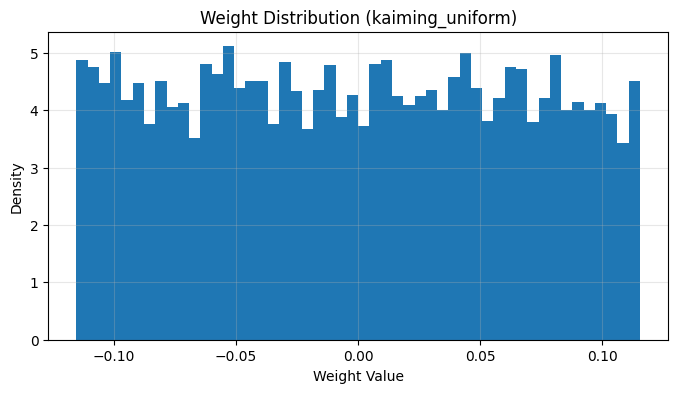

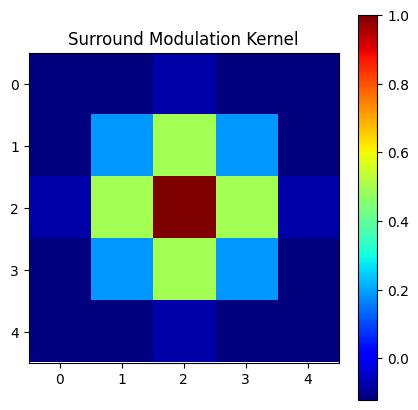

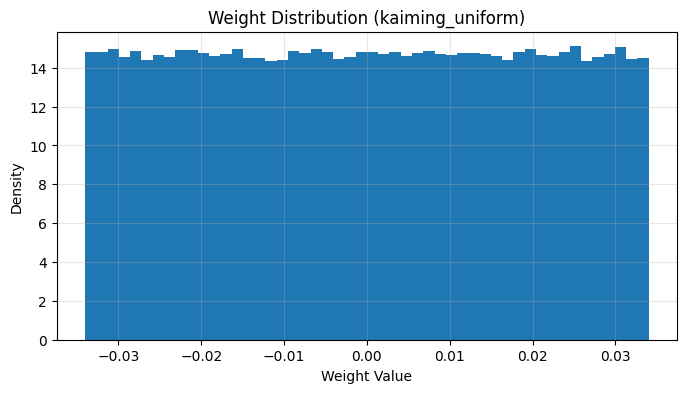

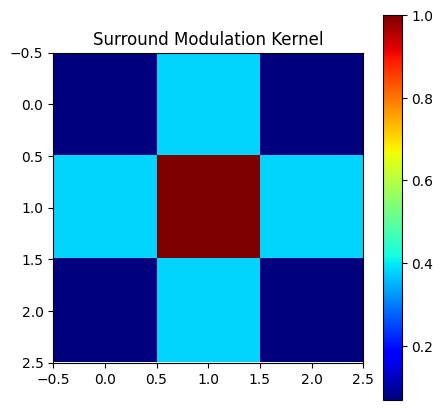

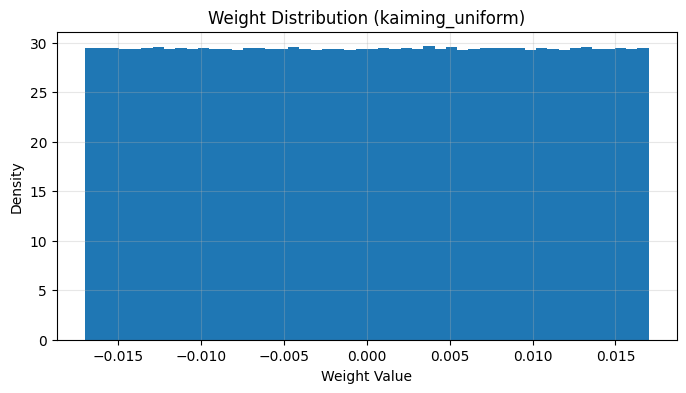

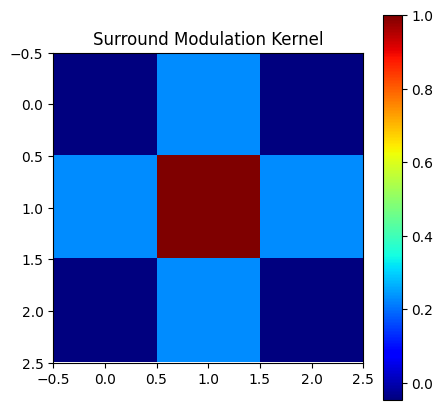

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 1.2593 | Train Acc: 56.18% | Test Loss: 1.0146 | Test Acc: 64.56% | LR: 0.001000
Epoch [2/20] | Train Loss: 0.9863 | Train Acc: 66.15% | Test Loss: 0.9340 | Test Acc: 67.39% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.9153 | Train Acc: 68.35% | Test Loss: 0.9079 | Test Acc: 67.95% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.8745 | Train Acc: 69.62% | Test Loss: 0.8547 | Test Acc: 69.90% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.8511 | Train Acc: 70.50% | Test Loss: 0.8298 | Test Acc: 71.21% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.8319 | Train Acc: 71.16% | Test Loss: 0.8103 | Test Acc: 71.77% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.8175 | Train Acc: 71.74% | Test Loss: 0.8180 | Test Acc: 71.43% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.8044 | Train Acc: 72.10% | Test Loss: 0.8168 | Test Acc: 71.64% | LR: 0.001000
Epoch [9/2

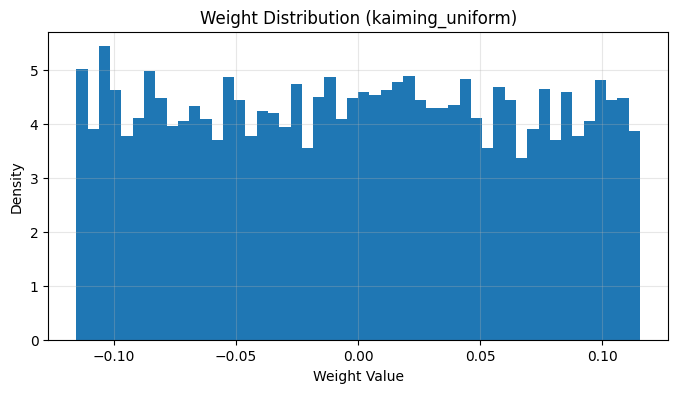

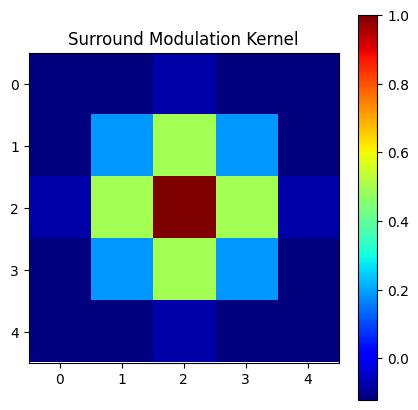

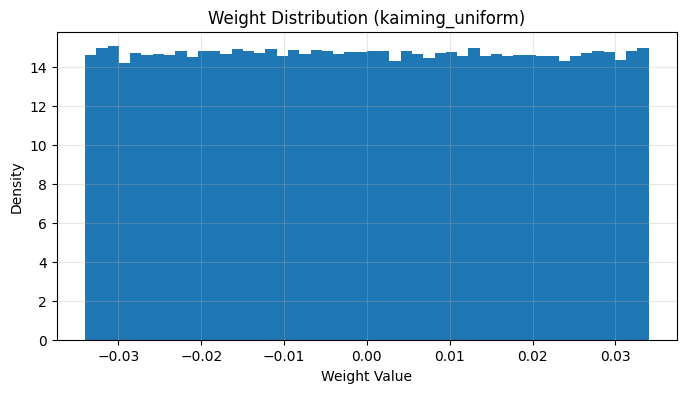

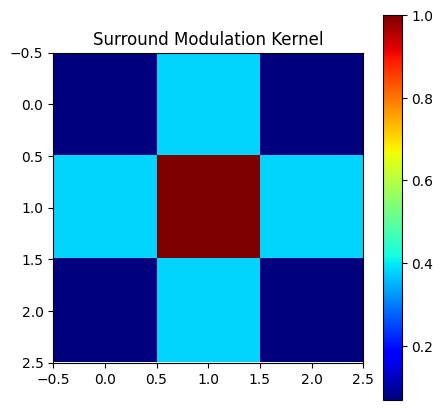

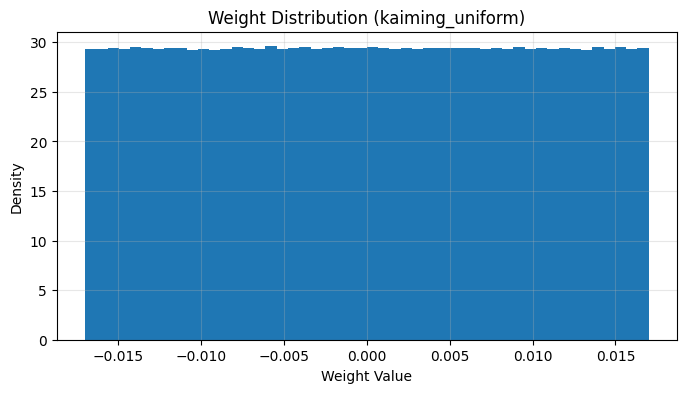

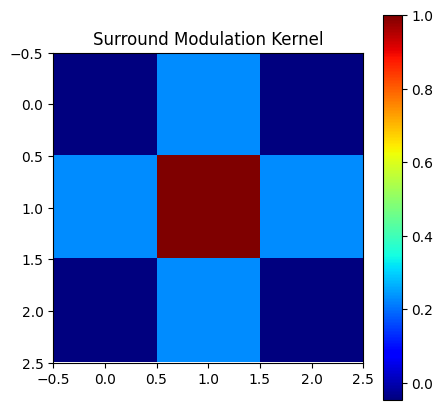

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 1.2655 | Train Acc: 55.94% | Test Loss: 1.0217 | Test Acc: 64.22% | LR: 0.001000
Epoch [2/20] | Train Loss: 0.9907 | Train Acc: 65.68% | Test Loss: 0.9402 | Test Acc: 67.97% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.9231 | Train Acc: 68.01% | Test Loss: 0.8698 | Test Acc: 69.87% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.8798 | Train Acc: 69.54% | Test Loss: 0.8841 | Test Acc: 68.98% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.8543 | Train Acc: 70.60% | Test Loss: 0.8539 | Test Acc: 70.10% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.8278 | Train Acc: 71.17% | Test Loss: 0.8218 | Test Acc: 71.47% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.8157 | Train Acc: 71.79% | Test Loss: 0.8127 | Test Acc: 71.37% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.8019 | Train Acc: 71.76% | Test Loss: 0.8219 | Test Acc: 71.63% | LR: 0.001000
Epoch [9/2

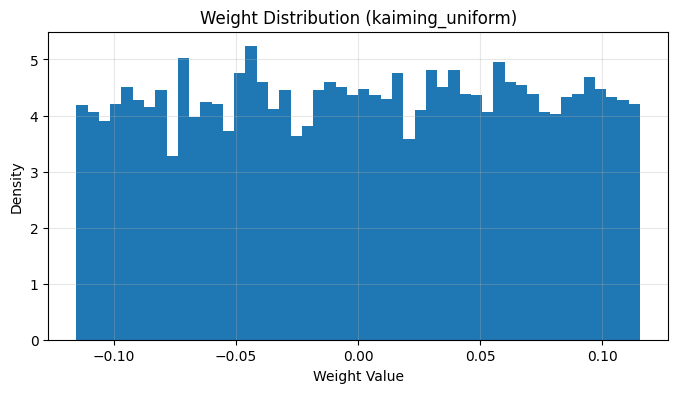

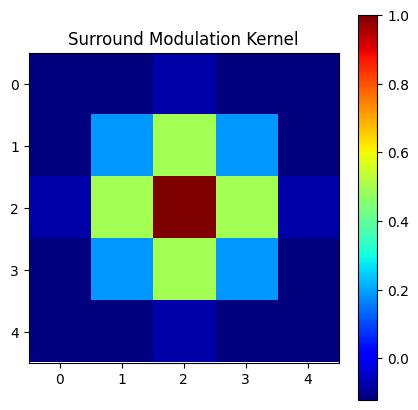

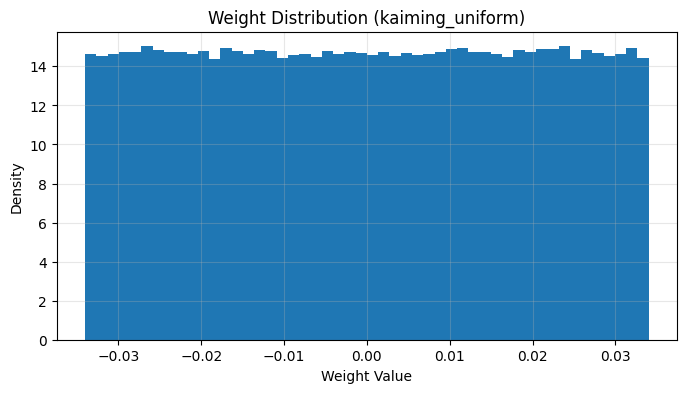

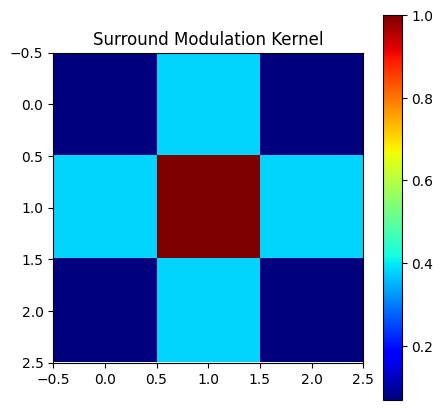

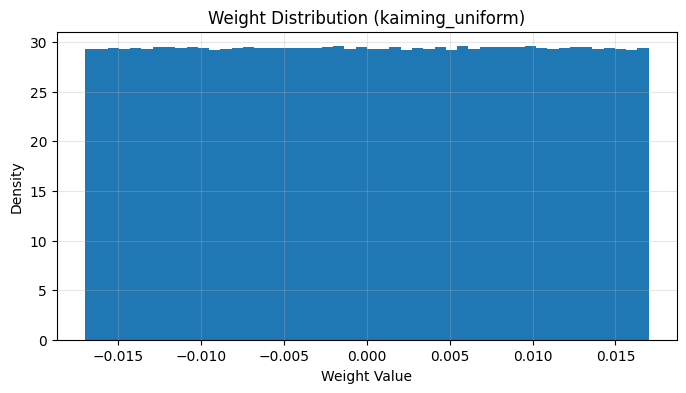

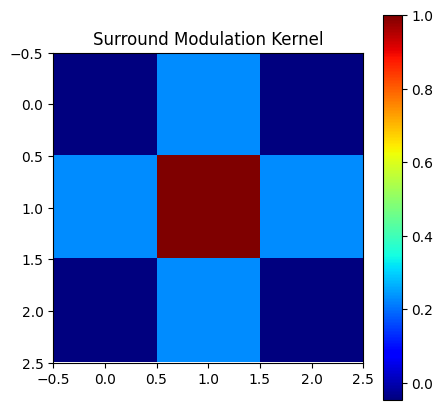

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 1.2645 | Train Acc: 56.19% | Test Loss: 1.0086 | Test Acc: 65.24% | LR: 0.001000
Epoch [2/20] | Train Loss: 0.9827 | Train Acc: 66.15% | Test Loss: 0.9132 | Test Acc: 68.01% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.9147 | Train Acc: 68.52% | Test Loss: 0.9028 | Test Acc: 68.60% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.8681 | Train Acc: 70.00% | Test Loss: 0.8334 | Test Acc: 71.06% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.8462 | Train Acc: 70.78% | Test Loss: 0.8348 | Test Acc: 70.56% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.8246 | Train Acc: 71.38% | Test Loss: 0.8211 | Test Acc: 71.52% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.8051 | Train Acc: 72.05% | Test Loss: 0.8042 | Test Acc: 72.24% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.7957 | Train Acc: 72.30% | Test Loss: 0.8133 | Test Acc: 72.16% | LR: 0.001000
Epoch [9/2

In [ ]:
#zca stats only need be computed once:
zca.mean = zca.mean.to(device)
zca.std = zca.std.to(device)
zca.zca_matrix = zca.zca_matrix.to(device)

for seed in seeds:

    print(f"RUN {seed + 1}/5 | SEED = {seed}")

   
    set_seed(seed)

      # Generator specifically for this run
    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=64,
        shuffle=True,
        num_workers=2,
        worker_init_fn=seed_worker,
        generator=g
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=64,
        shuffle=False, #researchers have test data shuffled, but this is again unecessary, since no learning is occuring (eval only)
        num_workers=2,
        worker_init_fn=seed_worker,
        generator=g
    )

    #fresh model for every seed

    hebb_param = get_hebbian_config(version="optimal")

    model = Net_Hebbian(
        hebb_params=hebb_param,
        version="softhebb"
    ).to(device)


    # hebbian feature learning ('Unsupervised Feature Learning Phase' trained for 1 epoch)
    model.train()

    for epoch in range(1):

        print(f"Hebbian epoch {epoch + 1}")

        for i, (inputs, _) in enumerate(train_loader):

            inputs = inputs.to(device)
            #do the zca transform per batch (equivalent to doing it for every image as the researchers do, but saves on runtime)
            inputs = zca.transform(inputs)

            
            with torch.no_grad():
                model(inputs)

            for layer in [model.conv1, model.conv2, model.conv3]:
                layer.local_update()

            if i % 100 == 0:
                print(f"Batch {i}/{len(train_loader)}")
                

    # freeze the hebbian feature extractor as now to train classifier

    for module in [
        model.conv1,
        model.conv2,
        model.conv3,
        model.bn1,
        model.bn2,
        model.bn3
    ]:

        for param in module.parameters():
            param.requires_grad = False

        module.eval()

    #optimiser and schedular as defined in experiment_hebbian.py
    sup_optimizer = torch.optim.Adam(
        model.fc1.parameters(),
        lr=0.001
    )

    scheduler = torch.optim.lr_scheduler.LambdaLR(
        sup_optimizer,
        lr_lambda=lambda epoch:
            0.5 ** max(0, (epoch - 10) // 2)
    )

    criterion = nn.CrossEntropyLoss()

    classifier_history = {
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": []
    }

    #train classier for 20 epochs

    for epoch in range(20):
        model.conv1.eval()
        model.conv2.eval()
        model.conv3.eval()

        model.bn1.eval()
        model.bn2.eval()
        model.bn3.eval()

        model.fc1.train()
        model.dropout.train()

        running_loss = 0.0
        correct = 0
        total = 0


        for inputs, labels in train_loader:

            inputs = inputs.to(device)
            
            inputs = zca.transform(inputs)

            labels = labels.to(device)

            sup_optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            loss.backward()

            sup_optimizer.step()

            running_loss += loss.item() * labels.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_accuracy = 100 * correct / total

        #get the evaluation results on the test set

        model.eval()

        test_running_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():

            for inputs, labels in test_loader:

                inputs = inputs.to(device)
                #again zca transform the batch
                inputs = zca.transform(inputs)

                labels = labels.to(device)

                outputs = model(inputs)

                loss = criterion(outputs, labels)

                test_running_loss += loss.item() * labels.size(0)

                _, predicted = torch.max(outputs, 1)

                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()

        test_loss = test_running_loss / test_total
        test_accuracy = 100 * test_correct / test_total


        classifier_history["train_loss"].append(train_loss)
        classifier_history["train_accuracy"].append(train_accuracy)

        classifier_history["test_loss"].append(test_loss)
        classifier_history["test_accuracy"].append(test_accuracy)

        #update the scheduler
        scheduler.step()

        current_lr = sup_optimizer.param_groups[0]["lr"]

        print(
            f"Epoch [{epoch + 1}/20] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_accuracy:.2f}% | "
            f"LR: {current_lr:.6f}"
        )

    # save each runs history
    all_histories[seed] = classifier_history

# save results and visualise

In [33]:
# Shape: (5 runs, 20 epochs)
train_acc = np.array([
    all_histories[seed]["train_accuracy"]
    for seed in seeds
])

test_acc = np.array([
    all_histories[seed]["test_accuracy"]
    for seed in seeds
])

In [34]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
train_acc_df=pd.DataFrame(train_acc)

In [36]:
test_acc_df=pd.DataFrame(test_acc)


In [37]:
train_acc_df.to_csv("/content/drive/MyDrive/research_jobs/hebbian_3_layer_train_acc_.csv",index=False)

In [38]:
test_acc_df.to_csv("/content/drive/MyDrive/research_jobs/hebbian_3_layer_test_acc_.csv",index=False)


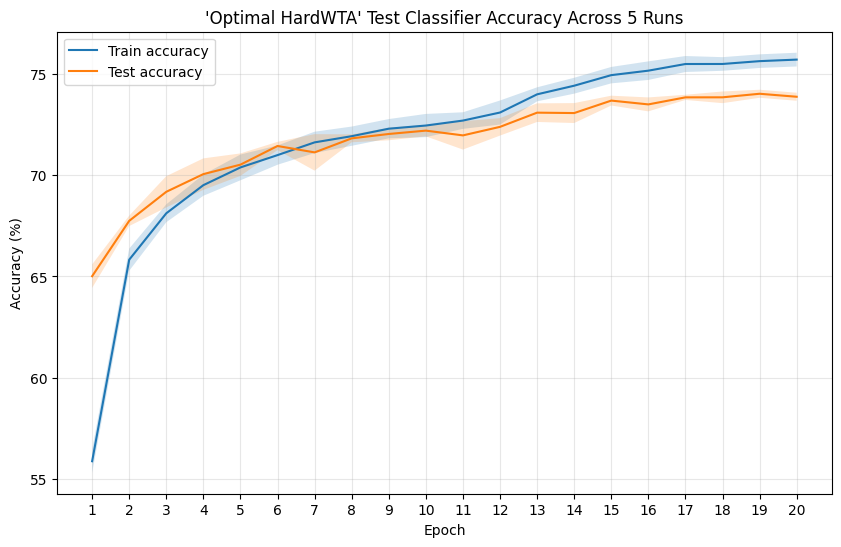

In [39]:
# Mean and standard deviation across the 5 runs
train_mean = train_acc.mean(axis=0)
train_std = train_acc.std(axis=0)

test_mean = test_acc.mean(axis=0)
test_std = test_acc.std(axis=0)

epochs = np.arange(1, 21)

plt.figure(figsize=(10, 6))

plt.plot(epochs, train_mean, label="Train accuracy")
plt.fill_between(
    epochs,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.plot(epochs, test_mean, label="Test accuracy")
plt.fill_between(
    epochs,
    test_mean - test_std,
    test_mean + test_std,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("'Optimal HardWTA' Test Classifier Accuracy Across 5 Runs")
plt.xticks(epochs)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [40]:
print(
    f"Final test accuracy: "
    f"{test_mean[-1]:.2f} ± {test_std[-1]:.2f}%"
)

Final test accuracy: 73.88 ± 0.20%


In [41]:
best_per_run = test_acc.max(axis=1)

print(
    f"Best test accuracy: "
    f"{best_per_run.mean():.2f} ± {best_per_run.std():.2f}%"
)

Best test accuracy: 74.16 ± 0.17%


# Removing the data leakage:

In [28]:
zca_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=False
)

all_train_data = []

for images, _ in zca_loader:
    all_train_data.append(images)

all_train_data = torch.cat(all_train_data, dim=0)

print(all_train_data.shape)
# [50000, 3, 32, 32]

zca = ZCAWhitening(epsilon=1e-3)
zca.fit(all_train_data)

torch.Size([50000, 3, 32, 32])


In [30]:
# just inspecting the effect on the first seed:
seeds = [0]
all_histories = {}

RUN 1/ 1 | SEED = 0
Building SoftHebb model


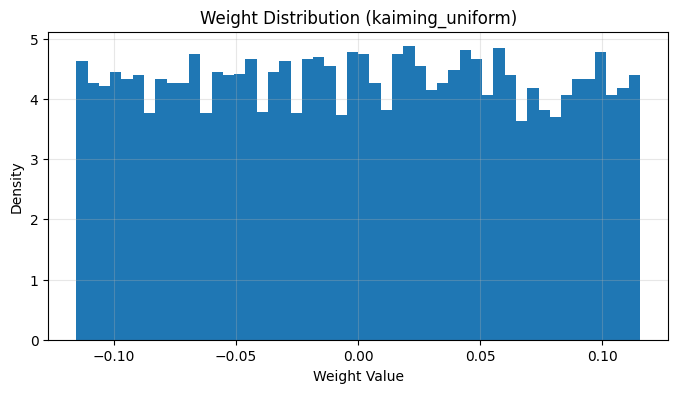

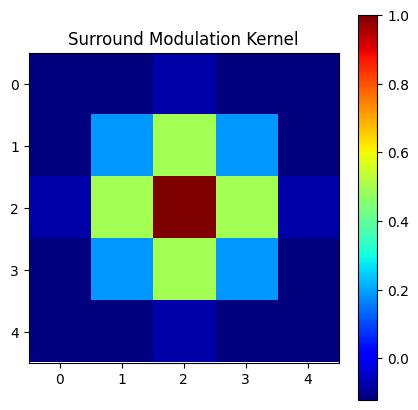

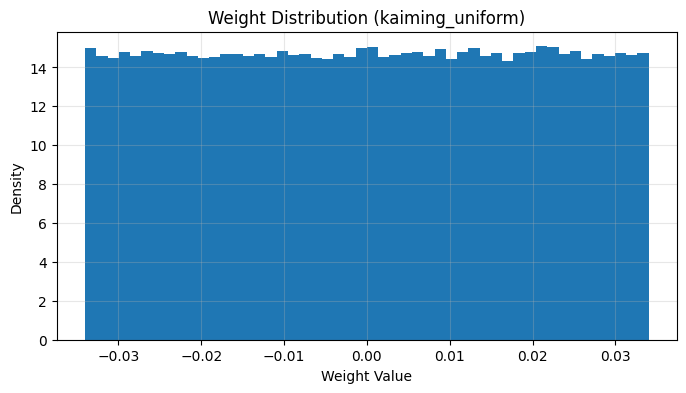

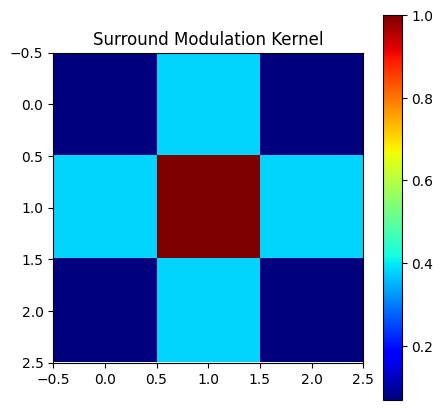

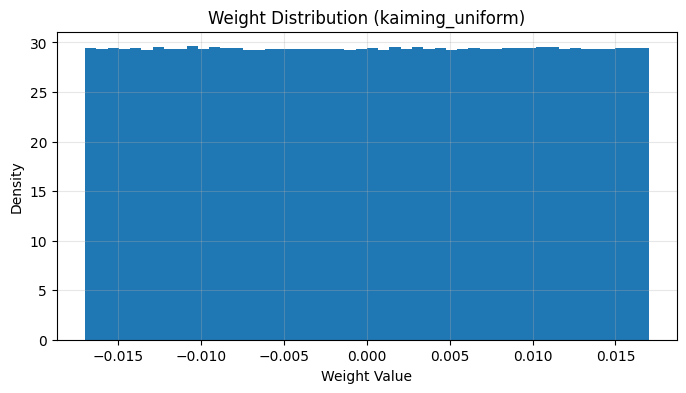

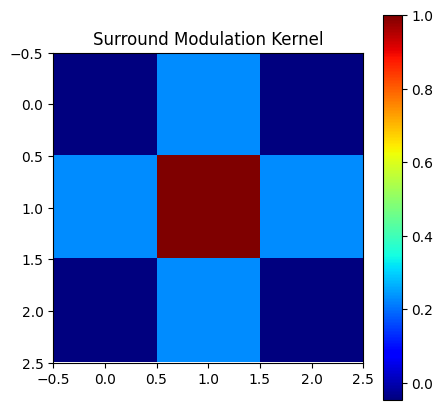

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 1.2953 | Train Acc: 54.58% | Test Loss: 1.0203 | Test Acc: 65.07% | LR: 0.001000
Epoch [2/20] | Train Loss: 1.0215 | Train Acc: 64.52% | Test Loss: 0.9335 | Test Acc: 67.71% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.9486 | Train Acc: 67.26% | Test Loss: 0.8981 | Test Acc: 69.09% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.9122 | Train Acc: 68.60% | Test Loss: 0.8743 | Test Acc: 69.62% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.8853 | Train Acc: 69.35% | Test Loss: 0.8674 | Test Acc: 69.95% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.8662 | Train Acc: 70.11% | Test Loss: 0.8381 | Test Acc: 71.16% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.8448 | Train Acc: 70.70% | Test Loss: 0.8499 | Test Acc: 70.58% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.8353 | Train Acc: 71.03% | Test Loss: 0.8161 | Test Acc: 71.85% | LR: 0.001000
Epoch [9/2

In [31]:
zca.mean = zca.mean.to(device)
zca.std = zca.std.to(device)
zca.zca_matrix = zca.zca_matrix.to(device)

for seed in seeds:

    print(f"RUN {seed + 1}/ {len(seeds)} | SEED = {seed}")


    set_seed(seed)

    # Generator specifically for this run
    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=64,
        shuffle=True,
        num_workers=2,
        worker_init_fn=seed_worker,
        generator=g
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=64,
        shuffle=False,
        num_workers=2,
        worker_init_fn=seed_worker,
        generator=g
    )


    #fresh model

    hebb_param = get_hebbian_config(version="optimal")

    model = Net_Hebbian(
        hebb_params=hebb_param,
        version="softhebb"
    ).to(device)


    # hebbian feature learning ('Unsupervised Feature Learning Phase' trained for 1 epoch)
    model.train()

    for epoch in range(1):

        print(f"Hebbian epoch {epoch + 1}")

        for i, (inputs, _) in enumerate(train_loader):

            inputs = inputs.to(device)

            inputs = zca.transform(inputs)

            

            with torch.no_grad():
                model(inputs)

            for layer in [model.conv1, model.conv2, model.conv3]:
                layer.local_update()

            if i % 100 == 0:
                print(f"Batch {i}/{len(train_loader)}")
                

    # freeze the hebbian feature extractor as now to train classifier

    for module in [
        model.conv1,
        model.conv2,
        model.conv3,
        model.bn1,
        model.bn2,
        model.bn3
    ]:

        for param in module.parameters():
            param.requires_grad = False

        module.eval()

    #optimiser and schedular as defined in experiment_hebbian.py
    sup_optimizer = torch.optim.Adam(
        model.fc1.parameters(),
        lr=0.001
    )

    scheduler = torch.optim.lr_scheduler.LambdaLR(
        sup_optimizer,
        lr_lambda=lambda epoch:
            0.5 ** max(0, (epoch - 10) // 2)
    )

    criterion = nn.CrossEntropyLoss()


    classifier_history = {
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": []
    }

    #train classier for 20 epochs

    for epoch in range(20):
        model.conv1.eval()
        model.conv2.eval()
        model.conv3.eval()

        model.bn1.eval()
        model.bn2.eval()
        model.bn3.eval()

        model.fc1.train()
        model.dropout.train()

        running_loss = 0.0
        correct = 0
        total = 0


        for inputs, labels in train_loader:

            inputs = inputs.to(device)

            inputs = zca.transform(inputs)

            labels = labels.to(device)

            sup_optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            loss.backward()

            sup_optimizer.step()

            running_loss += loss.item() * labels.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_accuracy = 100 * correct / total

        #get the evaluation results on the test set

        model.eval()

        test_running_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():

            for inputs, labels in test_loader:

                inputs = inputs.to(device)
                
                inputs = zca.transform(inputs)

                labels = labels.to(device)

                outputs = model(inputs)

                loss = criterion(outputs, labels)

                test_running_loss += loss.item() * labels.size(0)

                _, predicted = torch.max(outputs, 1)

                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()

        test_loss = test_running_loss / test_total
        test_accuracy = 100 * test_correct / test_total


        classifier_history["train_loss"].append(train_loss)
        classifier_history["train_accuracy"].append(train_accuracy)

        classifier_history["test_loss"].append(test_loss)
        classifier_history["test_accuracy"].append(test_accuracy)

        #update the scheduler
        scheduler.step()

        current_lr = sup_optimizer.param_groups[0]["lr"]

        print(
            f"Epoch [{epoch + 1}/20] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_accuracy:.2f}% | "
            f"LR: {current_lr:.6f}"
        )

    # Save this run's history
    all_histories[seed] = classifier_history

In [32]:
all_histories

{0: {'train_loss': [1.295346150970459,
   1.021535618095398,
   0.9485963706207275,
   0.9122336657142639,
   0.8852500408554077,
   0.8661914782714843,
   0.8447626199340821,
   0.8352894958114624,
   0.8278489255332947,
   0.823760574874878,
   0.8141914854621887,
   0.8071561779785156,
   0.7701420356178283,
   0.7588342690658569,
   0.7449487367630004,
   0.7405431058883667,
   0.7323358463668823,
   0.7264479720306396,
   0.7157032457351684,
   0.7154963030433655],
  'train_accuracy': [54.58,
   64.524,
   67.256,
   68.598,
   69.35,
   70.106,
   70.698,
   71.032,
   71.322,
   71.578,
   71.954,
   72.016,
   73.032,
   73.756,
   74.104,
   74.254,
   74.788,
   74.802,
   75.244,
   75.124],
  'test_loss': [1.0203493383407594,
   0.933549963760376,
   0.8980988960266113,
   0.8743055601119996,
   0.8674361255645752,
   0.8380974815368653,
   0.8498932996749878,
   0.81608668384552,
   0.8292970556259155,
   0.8401519945144653,
   0.8479013257980347,
   0.8294114013671875,
  

In [33]:
all_histories[0]['test_accuracy']

[65.07,
 67.71,
 69.09,
 69.62,
 69.95,
 71.16,
 70.58,
 71.85,
 71.1,
 71.39,
 70.87,
 71.74,
 72.7,
 72.23,
 73.05,
 73.33,
 73.91,
 73.66,
 74.03,
 73.52]

In [ ]:
print(np.mean(all_histories[0]['test_accuracy']))

71.328


In [ ]:
# the previous test accuracy for seed=0 (where test set stats are leaked) (as saved to google drive and available in results folder)
previous = [65.14,	67.88,	69.7,	69.54,	69.73,	71.32,	69.49,	71.9,	71.74,	72.15,	71.13,	72.33,	72.81,	72.44,	73.58,	73.17,	73.79,	73.53]
print(np.mean(previous))

71.18722222222222


### Test performance for the first seed is marginally worse off (not significantly changed, but it is better practise for statistics used in data-preprocessing to omit information from the test set), 

# Removing the random flipping at test time (using the zca computed on the train set only)
### To me it doesn't make sense to evaluate the test set with random horizontal flips (and perhaps the researchers didn't do so for the results printed in their paper, yet as far as their code repository is concerned, they appear to include random flips at test time)

In [29]:
valid_test_transform = transforms.Compose([
    transforms.ToTensor(),
])

valid_test_dataset = datasets.ImageFolder(
    root=cifar_test_path,
    transform=valid_test_transform
)

# retesting our non test flipping runs

In [32]:
seeds = [0,1,2,3,4]
all_histories = {}

RUN 1/ 5 | SEED = 0
Building SoftHebb model


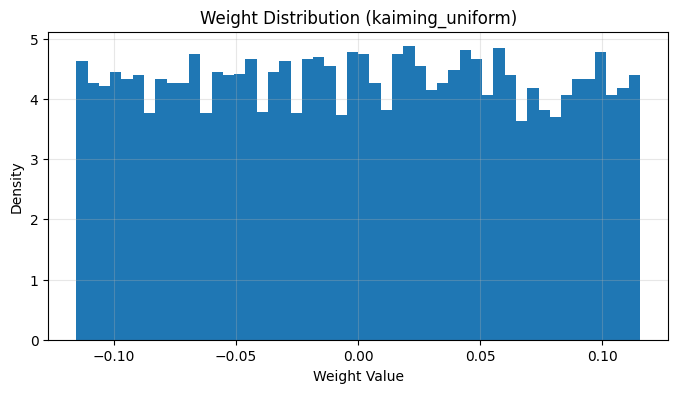

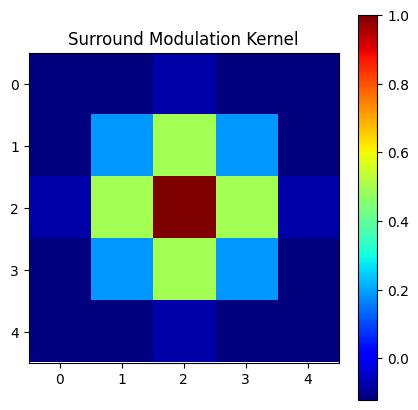

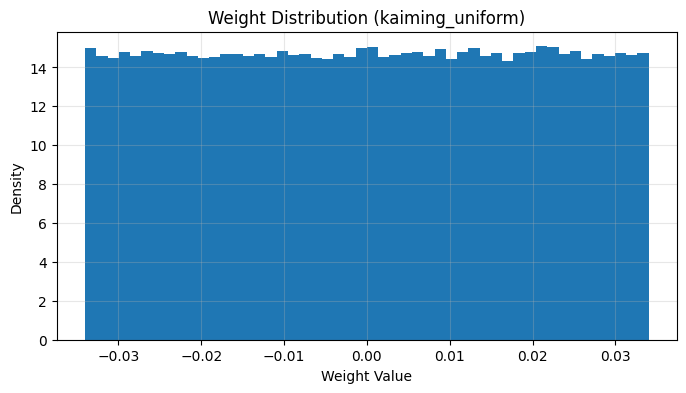

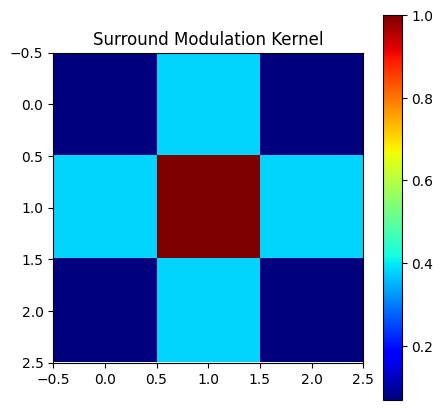

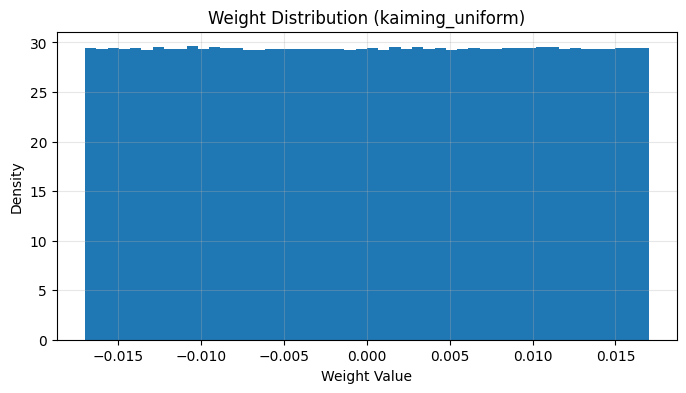

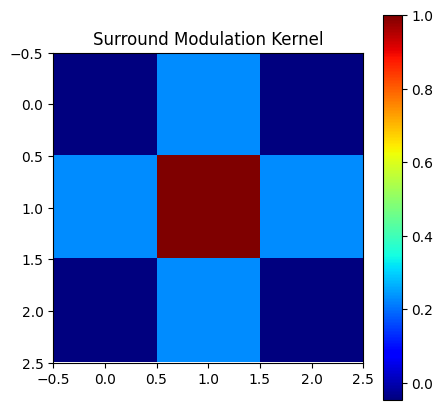

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 1.3011 | Train Acc: 54.38% | Test Loss: 1.0177 | Test Acc: 64.81% | LR: 0.001000
Epoch [2/20] | Train Loss: 1.0271 | Train Acc: 64.46% | Test Loss: 0.9238 | Test Acc: 68.14% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.9582 | Train Acc: 66.83% | Test Loss: 0.8958 | Test Acc: 69.23% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.9188 | Train Acc: 68.36% | Test Loss: 0.8710 | Test Acc: 70.00% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.8878 | Train Acc: 69.20% | Test Loss: 0.8624 | Test Acc: 70.34% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.8701 | Train Acc: 69.93% | Test Loss: 0.8425 | Test Acc: 71.22% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.8531 | Train Acc: 70.38% | Test Loss: 0.8650 | Test Acc: 69.73% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.8409 | Train Acc: 70.70% | Test Loss: 0.8208 | Test Acc: 71.40% | LR: 0.001000
Epoch [9/2

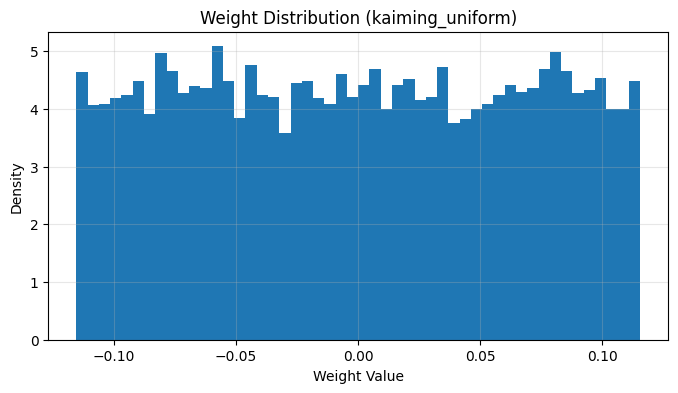

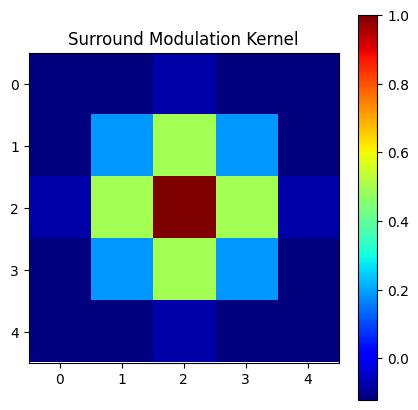

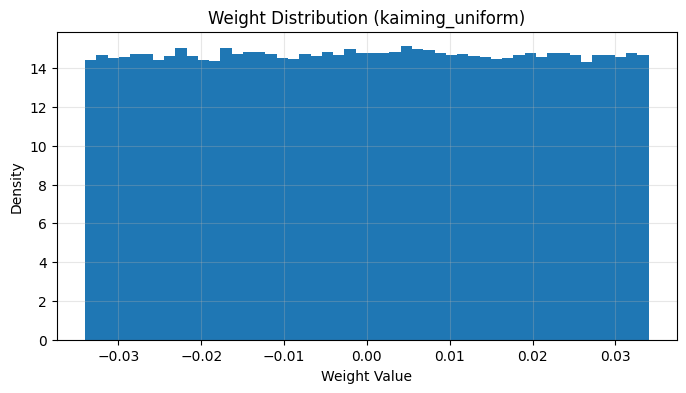

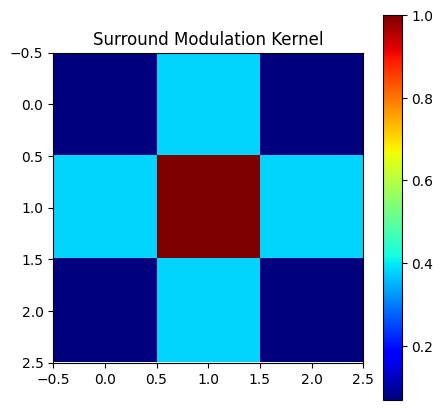

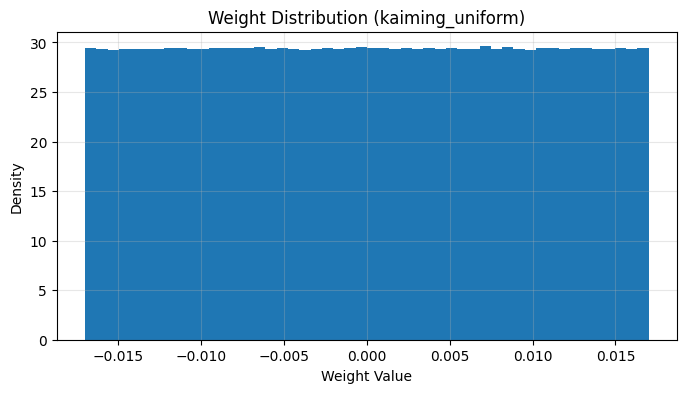

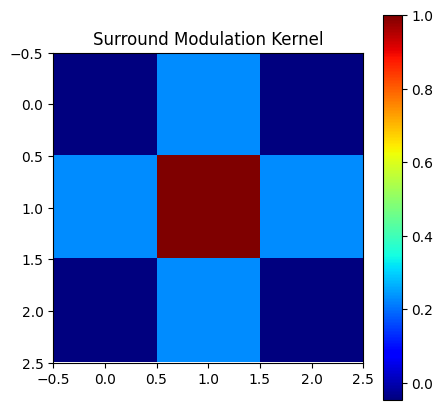

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 1.2588 | Train Acc: 56.39% | Test Loss: 1.0061 | Test Acc: 65.70% | LR: 0.001000
Epoch [2/20] | Train Loss: 0.9861 | Train Acc: 66.18% | Test Loss: 0.9331 | Test Acc: 67.66% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.9138 | Train Acc: 68.38% | Test Loss: 0.8776 | Test Acc: 69.94% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.8719 | Train Acc: 69.85% | Test Loss: 0.8402 | Test Acc: 70.81% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.8447 | Train Acc: 70.98% | Test Loss: 0.8384 | Test Acc: 70.76% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.8293 | Train Acc: 71.24% | Test Loss: 0.8240 | Test Acc: 71.43% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.8151 | Train Acc: 71.71% | Test Loss: 0.8282 | Test Acc: 70.86% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.8016 | Train Acc: 72.27% | Test Loss: 0.8069 | Test Acc: 72.08% | LR: 0.001000
Epoch [9/2

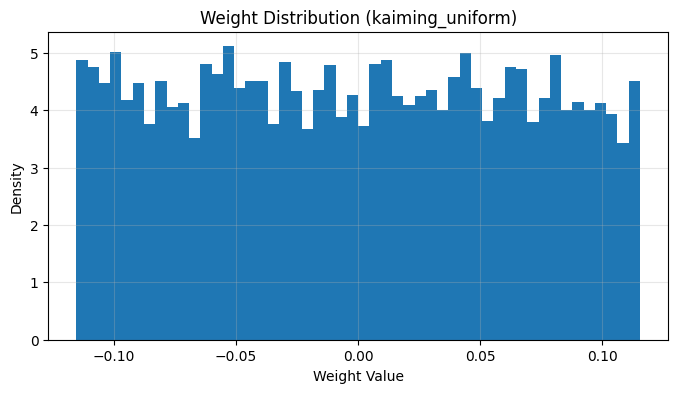

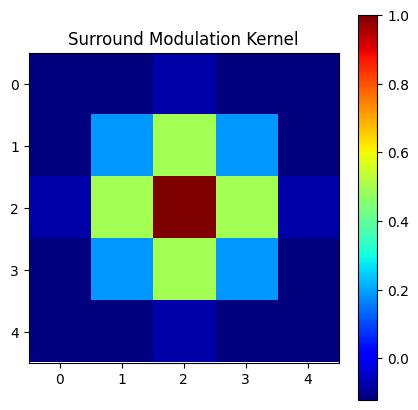

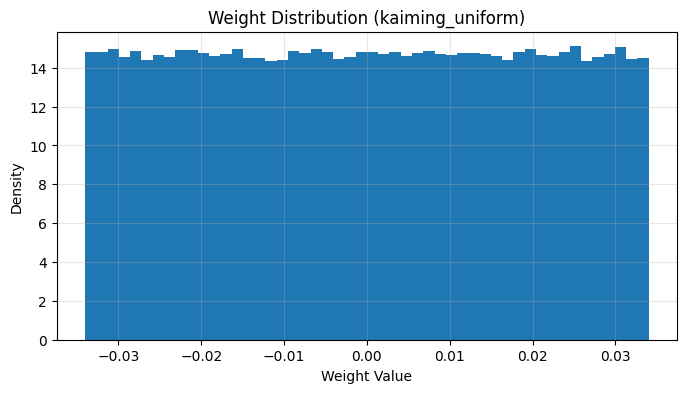

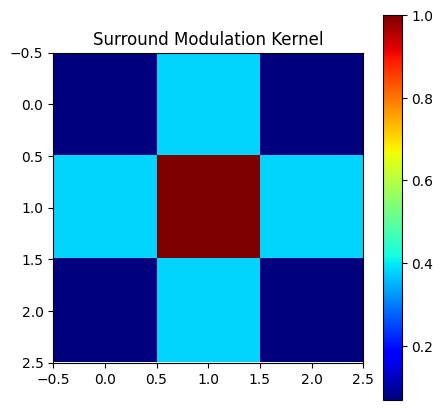

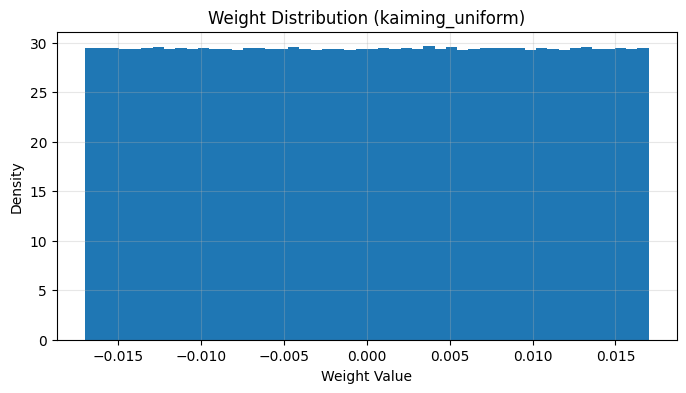

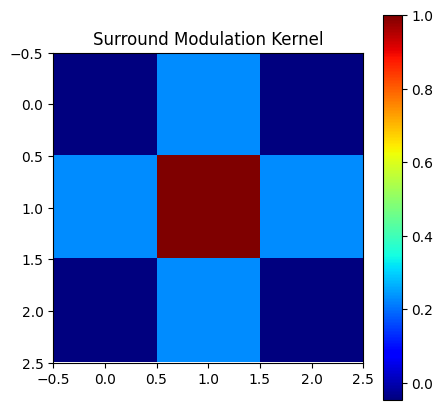

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 1.2621 | Train Acc: 56.12% | Test Loss: 1.0139 | Test Acc: 64.30% | LR: 0.001000
Epoch [2/20] | Train Loss: 0.9901 | Train Acc: 65.99% | Test Loss: 0.9366 | Test Acc: 67.29% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.9173 | Train Acc: 68.28% | Test Loss: 0.9138 | Test Acc: 67.74% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.8775 | Train Acc: 69.52% | Test Loss: 0.8676 | Test Acc: 69.50% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.8544 | Train Acc: 70.47% | Test Loss: 0.8308 | Test Acc: 70.80% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.8347 | Train Acc: 71.03% | Test Loss: 0.8196 | Test Acc: 71.16% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.8203 | Train Acc: 71.59% | Test Loss: 0.8243 | Test Acc: 71.41% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.8075 | Train Acc: 71.93% | Test Loss: 0.8244 | Test Acc: 71.25% | LR: 0.001000
Epoch [9/2

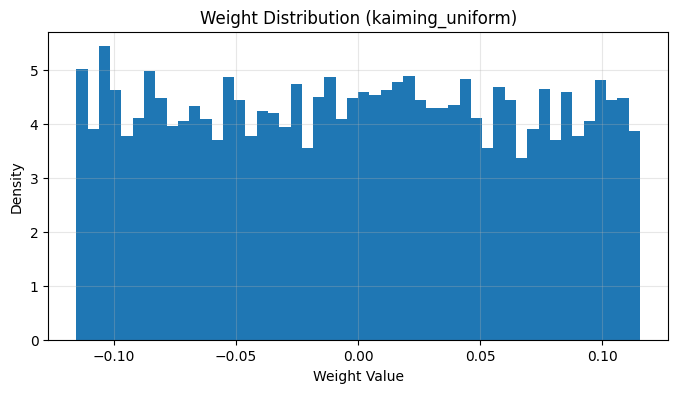

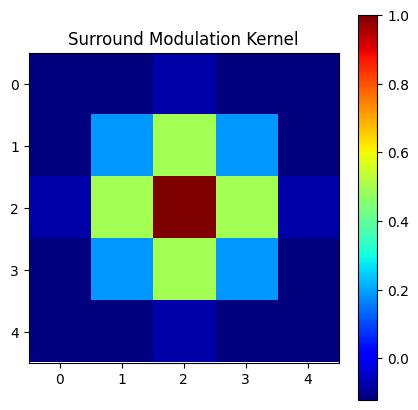

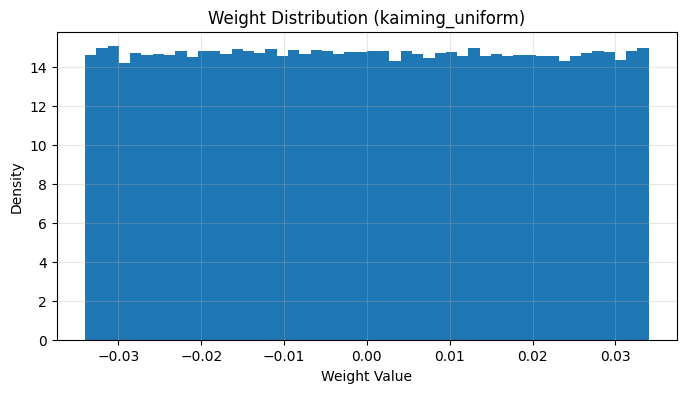

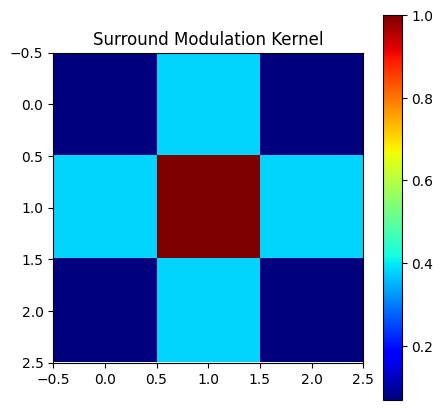

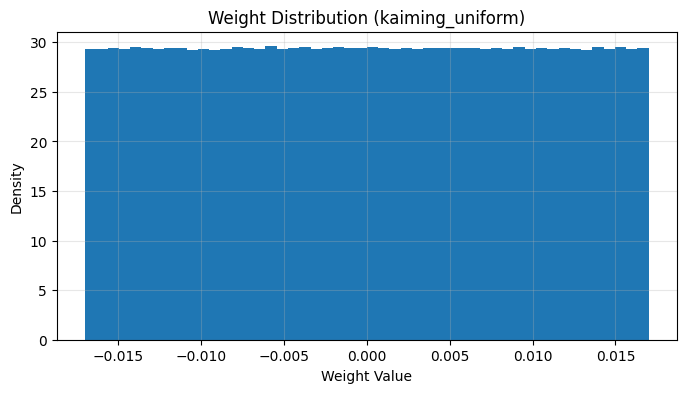

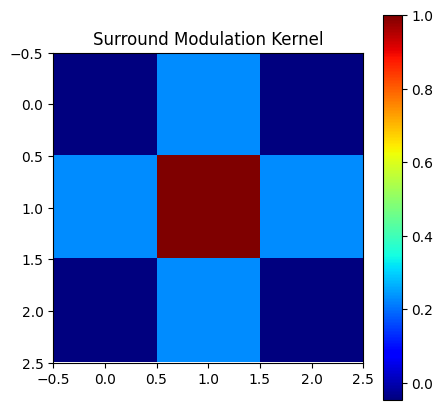

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 1.2714 | Train Acc: 55.71% | Test Loss: 1.0333 | Test Acc: 63.79% | LR: 0.001000
Epoch [2/20] | Train Loss: 0.9972 | Train Acc: 65.37% | Test Loss: 0.9460 | Test Acc: 67.69% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.9317 | Train Acc: 67.80% | Test Loss: 0.8700 | Test Acc: 69.96% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.8846 | Train Acc: 69.38% | Test Loss: 0.8852 | Test Acc: 69.29% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.8593 | Train Acc: 70.46% | Test Loss: 0.8502 | Test Acc: 70.39% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.8334 | Train Acc: 71.09% | Test Loss: 0.8309 | Test Acc: 70.90% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.8210 | Train Acc: 71.43% | Test Loss: 0.8208 | Test Acc: 71.41% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.8085 | Train Acc: 71.80% | Test Loss: 0.8344 | Test Acc: 70.85% | LR: 0.001000
Epoch [9/2

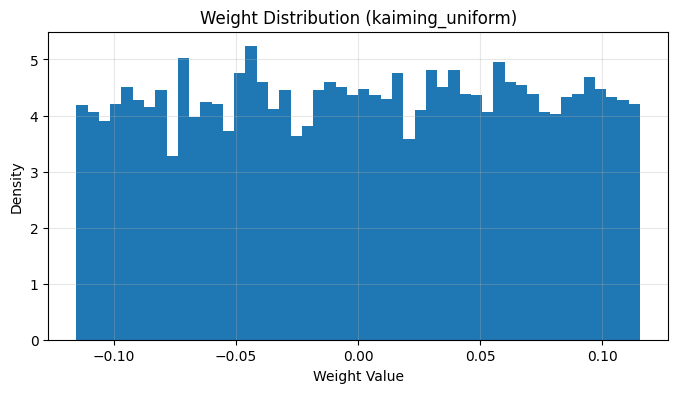

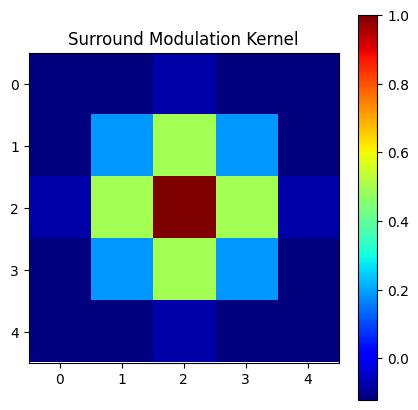

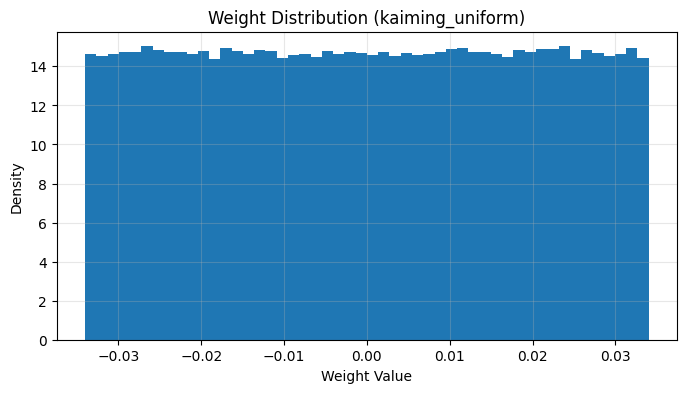

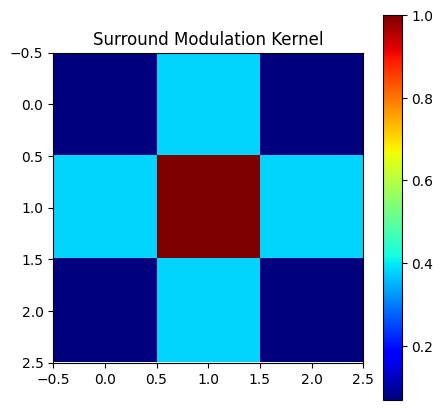

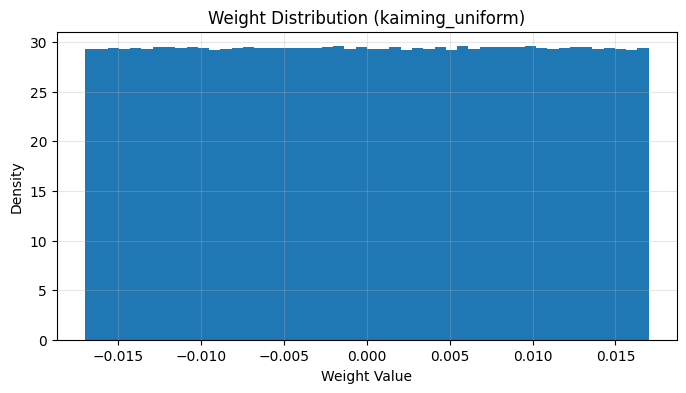

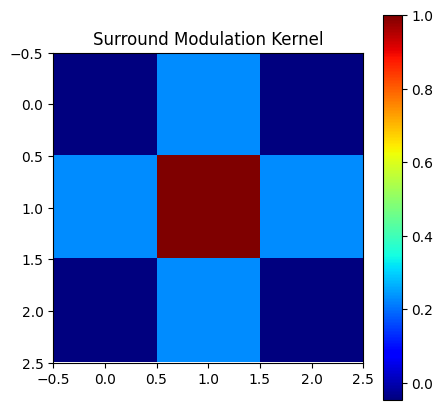

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 1.2777 | Train Acc: 55.55% | Test Loss: 1.0182 | Test Acc: 64.79% | LR: 0.001000
Epoch [2/20] | Train Loss: 0.9952 | Train Acc: 65.69% | Test Loss: 0.9300 | Test Acc: 67.71% | LR: 0.001000
Epoch [3/20] | Train Loss: 0.9264 | Train Acc: 67.88% | Test Loss: 0.9267 | Test Acc: 67.63% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.8791 | Train Acc: 69.70% | Test Loss: 0.8443 | Test Acc: 71.17% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.8589 | Train Acc: 70.23% | Test Loss: 0.8474 | Test Acc: 70.59% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.8379 | Train Acc: 71.06% | Test Loss: 0.8259 | Test Acc: 71.46% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.8187 | Train Acc: 71.43% | Test Loss: 0.8107 | Test Acc: 71.94% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.8100 | Train Acc: 71.73% | Test Loss: 0.8128 | Test Acc: 71.41% | LR: 0.001000
Epoch [9/2

In [31]:
zca.mean = zca.mean.to(device)
zca.std = zca.std.to(device)
zca.zca_matrix = zca.zca_matrix.to(device)

for seed in seeds:

    print(f"RUN {seed + 1}/ {len(seeds)} | SEED = {seed}")

    set_seed(seed)


    # Generator specifically for this run
    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=64,
        shuffle=True,
        num_workers=2,
        worker_init_fn=seed_worker,
        generator=g
    )

    #use the valid test dataset (no augmentation other than scaling using zca stats from training data)
    test_loader = DataLoader(
    valid_test_dataset,
    batch_size=64,
    shuffle=False, 
    num_workers=2,
    worker_init_fn=seed_worker,
    generator=g
)


    #fresh model

    hebb_param = get_hebbian_config(version="optimal")

    model = Net_Hebbian(
        hebb_params=hebb_param,
        version="softhebb"
    ).to(device)


    # hebbian feature learning ('Unsupervised Feature Learning Phase' trained for 1 epoch)
    model.train()

    for epoch in range(1):

        print(f"Hebbian epoch {epoch + 1}")

        for i, (inputs, _) in enumerate(train_loader):

            inputs = inputs.to(device)

            inputs = zca.transform(inputs)

            

            with torch.no_grad():
                model(inputs)

            for layer in [model.conv1, model.conv2, model.conv3]:
                layer.local_update()

            if i % 100 == 0:
                print(f"Batch {i}/{len(train_loader)}")
                

    # freeze the hebbian feature extractor as now to train classifier

    for module in [
        model.conv1,
        model.conv2,
        model.conv3,
        model.bn1,
        model.bn2,
        model.bn3
    ]:

        for param in module.parameters():
            param.requires_grad = False

        module.eval()

    #optimiser and schedular as defined in experiment_hebbian.py
    sup_optimizer = torch.optim.Adam(
        model.fc1.parameters(),
        lr=0.001
    )

    scheduler = torch.optim.lr_scheduler.LambdaLR(
        sup_optimizer,
        lr_lambda=lambda epoch:
            0.5 ** max(0, (epoch - 10) // 2)
    )

    criterion = nn.CrossEntropyLoss()


    classifier_history = {
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": []
    }

    #train classier for 20 epochs

    for epoch in range(20):
        model.conv1.eval()
        model.conv2.eval()
        model.conv3.eval()

        model.bn1.eval()
        model.bn2.eval()
        model.bn3.eval()

        model.fc1.train()
        model.dropout.train()

        running_loss = 0.0
        correct = 0
        total = 0


        for inputs, labels in train_loader:

            inputs = inputs.to(device)

            inputs = zca.transform(inputs)

            labels = labels.to(device)

            sup_optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            loss.backward()

            sup_optimizer.step()

            running_loss += loss.item() * labels.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_accuracy = 100 * correct / total

        #get the evaluation results on the test set

        model.eval()

        test_running_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():

            for inputs, labels in test_loader:

                inputs = inputs.to(device)
                
                inputs = zca.transform(inputs)

                labels = labels.to(device)

                outputs = model(inputs)

                loss = criterion(outputs, labels)

                test_running_loss += loss.item() * labels.size(0)

                _, predicted = torch.max(outputs, 1)

                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()

        test_loss = test_running_loss / test_total
        test_accuracy = 100 * test_correct / test_total


        classifier_history["train_loss"].append(train_loss)
        classifier_history["train_accuracy"].append(train_accuracy)

        classifier_history["test_loss"].append(test_loss)
        classifier_history["test_accuracy"].append(test_accuracy)

        #update the scheduler
        scheduler.step()

        current_lr = sup_optimizer.param_groups[0]["lr"]

        print(
            f"Epoch [{epoch + 1}/20] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_accuracy:.2f}% | "
            f"LR: {current_lr:.6f}"
        )

    # Save this run's history
    all_histories[seed] = classifier_history

In [32]:

train_acc = np.array([
    all_histories[seed]["train_accuracy"]
    for seed in seeds
])

test_acc = np.array([
    all_histories[seed]["test_accuracy"]
    for seed in seeds
])

In [33]:
train_acc_df=pd.DataFrame(train_acc)

In [34]:
test_acc_df=pd.DataFrame(test_acc)


In [35]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [36]:
train_acc_df.to_csv("/content/drive/MyDrive/research_jobs/fixed_stats_no_test_flips_hebbian_3_layer_train_acc_.csv",index=False)

In [37]:
test_acc_df.to_csv("/content/drive/MyDrive/research_jobs/fixed_stats_no_test_flips_hebbian_3_layer_test_acc_.csv",index=False)


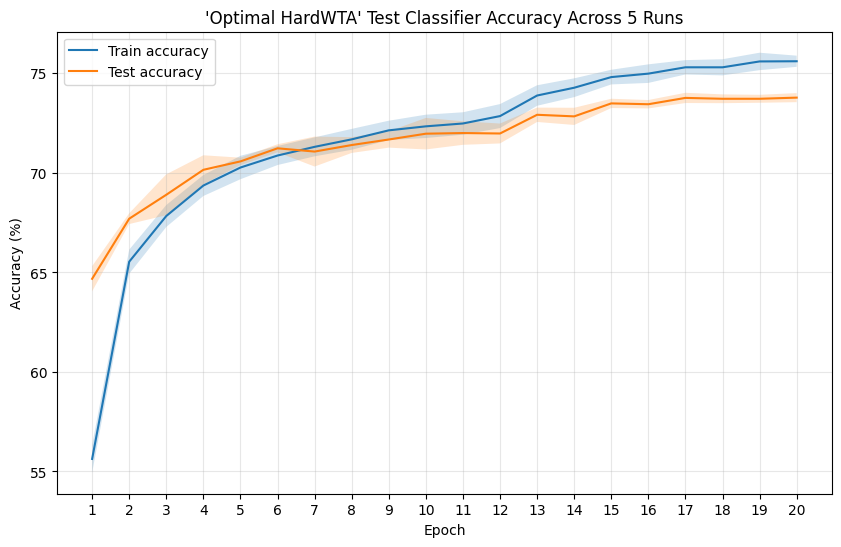

In [38]:
# Mean and standard deviation across the 5 runs
train_mean = train_acc.mean(axis=0)
train_std = train_acc.std(axis=0)

test_mean = test_acc.mean(axis=0)
test_std = test_acc.std(axis=0)

epochs = np.arange(1, 21)

plt.figure(figsize=(10, 6))

plt.plot(epochs, train_mean, label="Train accuracy")
plt.fill_between(
    epochs,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.plot(epochs, test_mean, label="Test accuracy")
plt.fill_between(
    epochs,
    test_mean - test_std,
    test_mean + test_std,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("'Optimal HardWTA' Test Classifier Accuracy Across 5 Runs")
plt.xticks(epochs)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [39]:
print(
    f"Final test accuracy: "
    f"{test_mean[-1]:.2f} ± {test_std[-1]:.2f}%"
)

Final test accuracy: 73.78 ± 0.23%


In [40]:
best_per_run = test_acc.max(axis=1)

print(
    f"Best test accuracy: "
    f"{best_per_run.mean():.2f} ± {best_per_run.std():.2f}%"
)

Best test accuracy: 73.87 ± 0.21%


# Reproducing results from STL-10 Dataset
## Running this larger (96x96 pixels) dataset on Colab's T4 GPU is incredibly slow; A100 is instead used

In [16]:
!nvidia-smi

Thu Aug 20 12:39:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             43W /  400W |       6MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

# Firstly try raw values:

In [17]:

stl10_root = "../datasets/STL10"

base_transform = transforms.ToTensor()

stl10_train = datasets.STL10(
    root=stl10_root,
    split="train",
    download=True,
    transform=base_transform
)

stl10_test = datasets.STL10(
    root=stl10_root,
    split="test",
    download=True,
    transform=base_transform
)

100%|██████████| 2.64G/2.64G [07:02<00:00, 6.24MB/s]  


In [17]:
final_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Resize((96, 96)),
])

In [18]:
# apply transforms

stl10_train = datasets.STL10(
    root=stl10_root,
    split="train",
    download=False,
    transform=final_transform
)

stl10_test = datasets.STL10(
    root=stl10_root,
    split="test",
    download=False,
    transform=final_transform
)

In [19]:
seeds=[0]
all_histories={}

# Inspecting model (softhebb/Journe architecture, however this version has 4 layers)

Building STL SoftHebb model


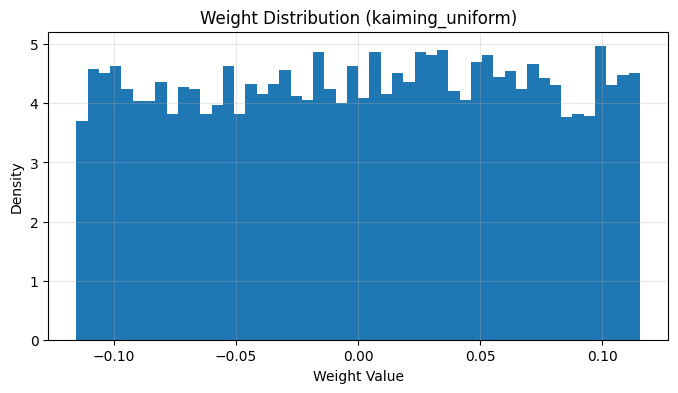

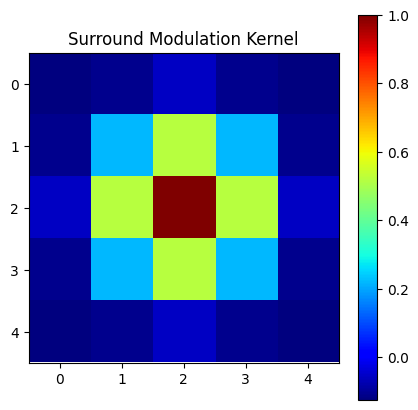

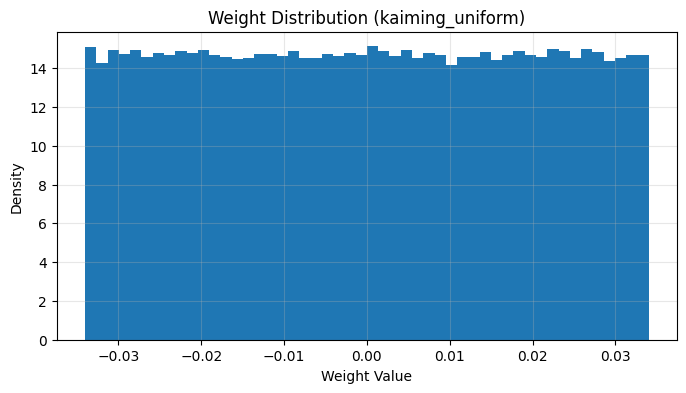

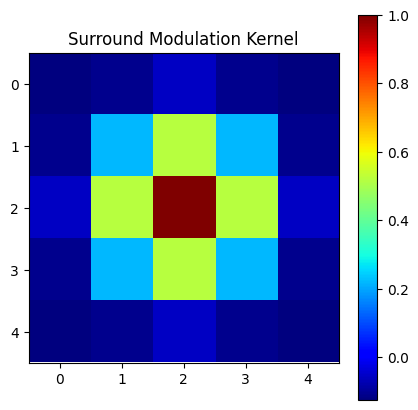

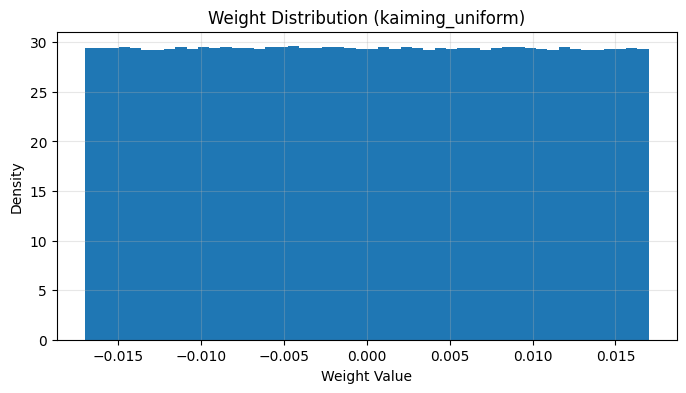

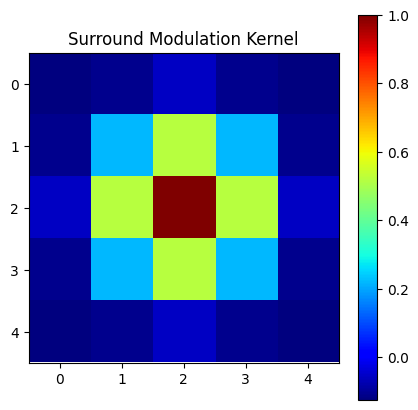

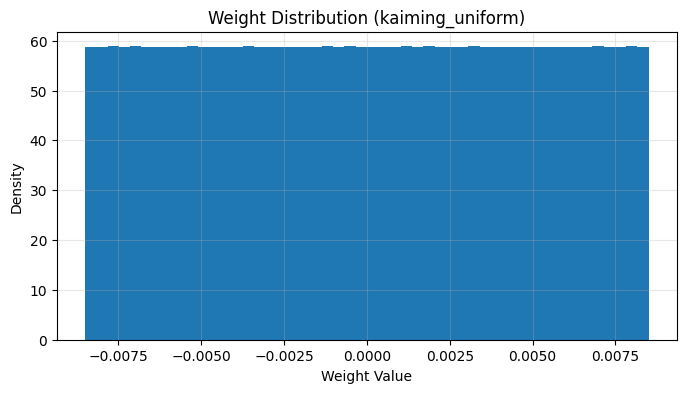

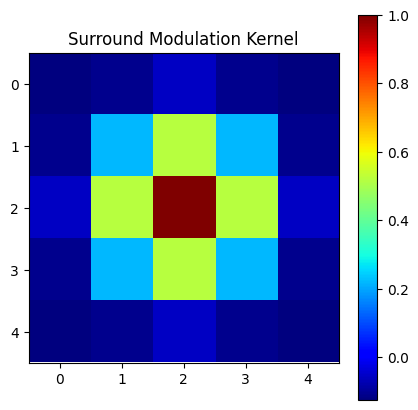

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
hebb_param = get_hebbian_config(version="optimal")

model = Net_Hebbian(
        hebb_params=hebb_param,
        version="stl_net"
    ).to(device)


In [21]:
print(model)

Net_Hebbian(
  (bn1): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
  (conv1): HebbianConv2d(
    (act): Identity()
  )
  (pool1): MaxPool2d(kernel_size=4, stride=2, padding=1, dilation=1, ceil_mode=False)
  (activ1): Triangle()
  (bn2): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
  (conv2): HebbianConv2d(
    (act): Identity()
  )
  (pool2): MaxPool2d(kernel_size=4, stride=2, padding=1, dilation=1, ceil_mode=False)
  (activ2): Triangle()
  (bn3): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
  (conv3): HebbianConv2d(
    (act): Identity()
  )
  (pool3): MaxPool2d(kernel_size=4, stride=2, padding=1, dilation=1, ceil_mode=False)
  (activ3): Triangle()
  (bn4): BatchNorm2d(1536, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
  (conv4): HebbianConv2d(
    (act): Identity()
  )
  (pool4): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (activ4): Triangle()
  (flatten

In [22]:
hebb_param

{'mode': 'bcm',
 'w_nrm': False,
 'act': Identity(),
 'use_cosine_similarity': True,
 'use_lateral_inhibition': True,
 'top_k': 1,
 'init_method': 'kaiming_uniform',
 'patchwise': True,
 'contrast': 1.0,
 'uniformity': False,
 'use_presynaptic_competition': False,
 'presynaptic_competition_type': 'lp_norm',
 'competition_type': 'hard',
 'temporal_window': 500,
 'competition_k': 2,
 'dale': False,
 'use_homeostasis': False}

In [23]:
print("conv1 init:", model.conv1.init_method)
print("conv2 init:", model.conv2.init_method)
print("conv3 init:", model.conv3.init_method)

print("conv1 lr:", model.conv1.lr)
print("conv2 lr:", model.conv2.lr)
print("conv3 lr:", model.conv3.lr)
print("conv4 lr:", model.conv4.lr)


conv1 init: kaiming_uniform
conv2 init: kaiming_uniform
conv3 init: kaiming_uniform
conv1 lr: 0.1
conv2 lr: 0.1
conv3 lr: 0.1
conv4 lr: 0.1


RUN 1/5 | SEED = 0
Building STL SoftHebb model


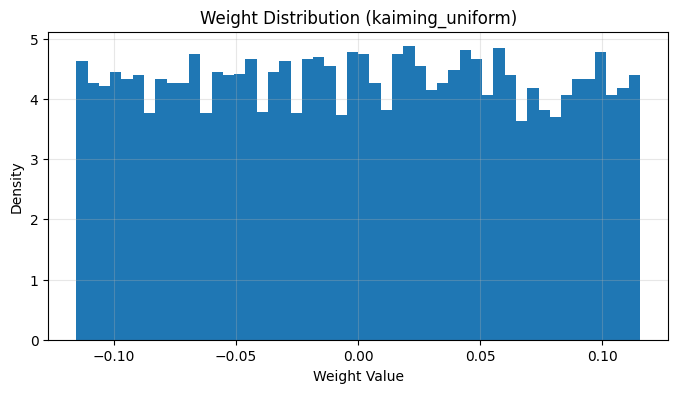

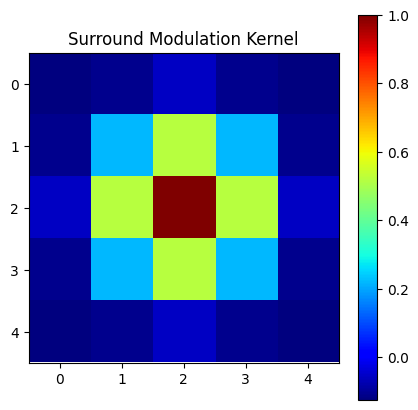

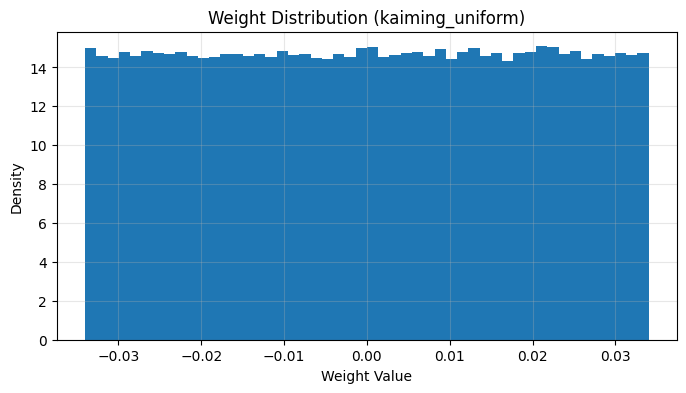

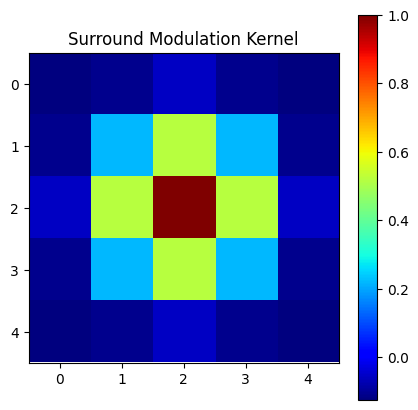

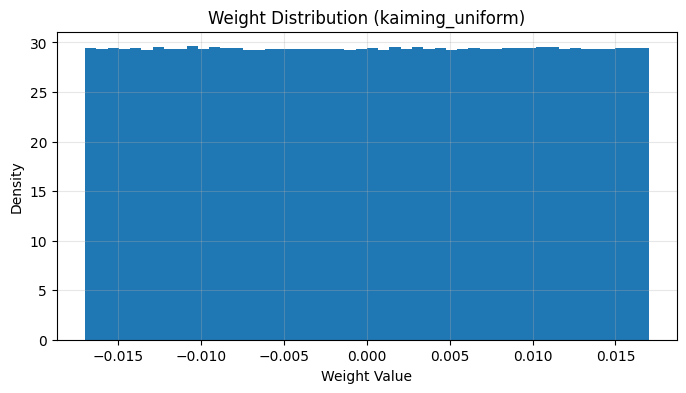

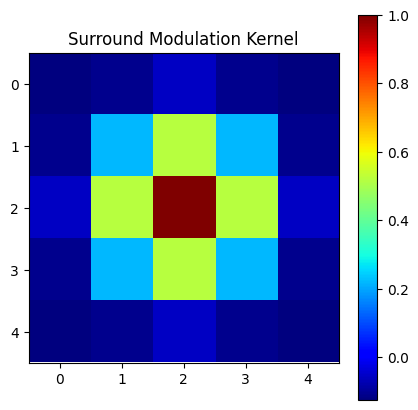

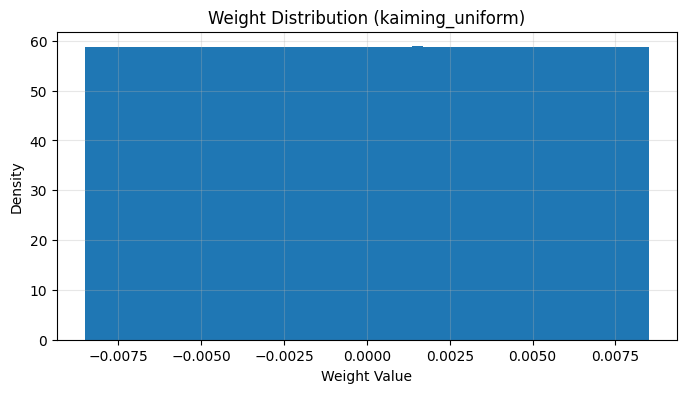

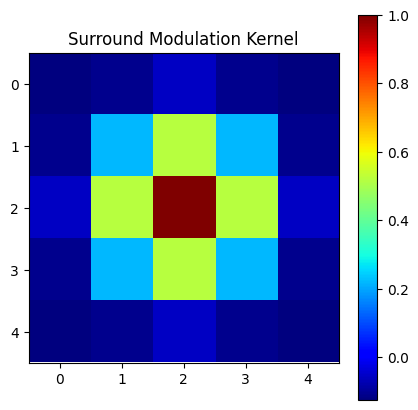

Hebbian epoch 1
Batch 0/79
Epoch [1/20] | Train Loss: 2.8059 | Train Acc: 36.06% | Test Loss: 1.6012 | Test Acc: 50.25% | LR: 0.001000
Epoch [2/20] | Train Loss: 1.7865 | Train Acc: 49.50% | Test Loss: 1.4826 | Test Acc: 53.35% | LR: 0.001000
Epoch [3/20] | Train Loss: 1.4780 | Train Acc: 56.86% | Test Loss: 1.6024 | Test Acc: 53.61% | LR: 0.001000
Epoch [4/20] | Train Loss: 1.3122 | Train Acc: 61.92% | Test Loss: 1.6560 | Test Acc: 52.92% | LR: 0.001000
Epoch [5/20] | Train Loss: 1.0167 | Train Acc: 67.20% | Test Loss: 1.3467 | Test Acc: 59.60% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.9100 | Train Acc: 70.20% | Test Loss: 1.3859 | Test Acc: 59.88% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.8135 | Train Acc: 73.38% | Test Loss: 1.1769 | Test Acc: 63.29% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.6532 | Train Acc: 78.54% | Test Loss: 1.3774 | Test Acc: 60.49% | LR: 0.001000
Epoch [9/20] | Train Loss: 0.6564 | Train Acc: 77.72% | Test Loss: 1.4360 | Test Acc: 59.67% | LR: 0.001000
E

In [24]:

for seed in seeds:

    print(f"RUN {seed + 1}/5 | SEED = {seed}")

   
    set_seed(seed)

      # Generator specifically for this run
    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        stl10_train,
        batch_size=64,
        shuffle=True,
        num_workers=2,
        worker_init_fn=seed_worker,
        generator=g
    )

    test_loader = DataLoader(
        stl10_test,
        batch_size=64,
        shuffle=False, #researchers have test data shuffled, but this is again unecessary, since no learning is occuring (eval only)
        num_workers=2,
        worker_init_fn=seed_worker,
        generator=g
    )

    #fresh model for every seed

    hebb_param = get_hebbian_config(version="optimal")

    model = Net_Hebbian(
        hebb_params=hebb_param,
        version="stl_net"
    ).to(device)


    # hebbian feature learning ('Unsupervised Feature Learning Phase' trained for 1 epoch)
    model.train()

    for epoch in range(1):

        print(f"Hebbian epoch {epoch + 1}")

        for i, (inputs, _) in enumerate(train_loader):

            inputs = inputs.to(device)


            
            with torch.no_grad():
                model(inputs)

            for layer in [model.conv1, model.conv2, model.conv3, model.conv4]:
                layer.local_update()

            if i % 100 == 0:
                print(f"Batch {i}/{len(train_loader)}")
                

    # freeze the hebbian feature extractor as now to train classifier

    for module in [
        model.conv1,
        model.conv2,
        model.conv3,
        model.conv4,

        model.bn1,
        model.bn2,
        model.bn3,
        model.bn4

    ]:

        for param in module.parameters():
            param.requires_grad = False

        module.eval()

    #optimiser and schedular as defined in experiment_hebbian.py
    sup_optimizer = torch.optim.Adam(
        model.fc1.parameters(),
        lr=0.001
    )

    scheduler = torch.optim.lr_scheduler.LambdaLR(
        sup_optimizer,
        lr_lambda=lambda epoch:
            0.5 ** max(0, (epoch - 10) // 2)
    )

    criterion = nn.CrossEntropyLoss()

    classifier_history = {
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": []
    }

    #train classier for 20 epochs

    for epoch in range(20):
        model.conv1.eval()
        model.conv2.eval()
        model.conv3.eval()
        model.conv4.eval()


        model.bn1.eval()
        model.bn2.eval()
        model.bn3.eval()
        model.bn4.eval()


        model.fc1.train()
        model.dropout.train()

        running_loss = 0.0
        correct = 0
        total = 0


        for inputs, labels in train_loader:

            inputs = inputs.to(device)
            

            labels = labels.to(device)

            sup_optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            loss.backward()

            sup_optimizer.step()

            running_loss += loss.item() * labels.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_accuracy = 100 * correct / total

        #get the evaluation results on the test set

        model.eval()

        test_running_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():

            for inputs, labels in test_loader:

                inputs = inputs.to(device)

                labels = labels.to(device)

                outputs = model(inputs)

                loss = criterion(outputs, labels)

                test_running_loss += loss.item() * labels.size(0)

                _, predicted = torch.max(outputs, 1)

                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()

        test_loss = test_running_loss / test_total
        test_accuracy = 100 * test_correct / test_total


        classifier_history["train_loss"].append(train_loss)
        classifier_history["train_accuracy"].append(train_accuracy)

        classifier_history["test_loss"].append(test_loss)
        classifier_history["test_accuracy"].append(test_accuracy)

        #update the scheduler
        scheduler.step()

        current_lr = sup_optimizer.param_groups[0]["lr"]

        print(
            f"Epoch [{epoch + 1}/20] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_accuracy:.2f}% | "
            f"LR: {current_lr:.6f}"
        )

    # save each runs history
    all_histories[seed] = classifier_history

# Normalising inputs

In [41]:
final_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Resize((96, 96)),
    transforms.Normalize(mean=[0.4467, 0.4398, 0.4066], std=[0.2603, 0.2566, 0.2713])
])

In [42]:
# apply transforms

stl10_train = datasets.STL10(
    root=stl10_root,
    split="train",
    download=False,
    transform=final_transform
)

stl10_test = datasets.STL10(
    root=stl10_root,
    split="test",
    download=False,
    transform=final_transform
)

In [43]:
seeds=[0]
all_histories={}

RUN 1/5 | SEED = 0
Building STL SoftHebb model


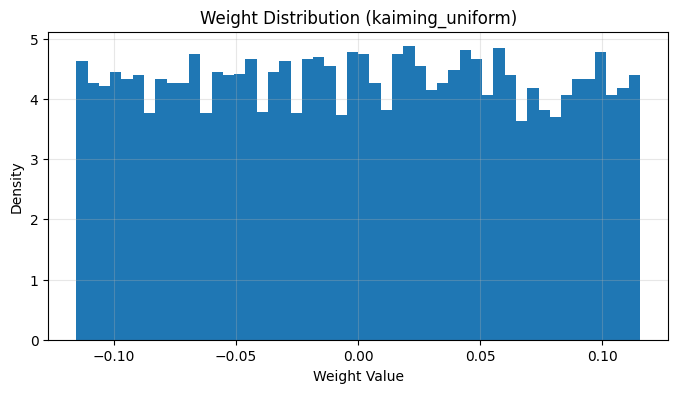

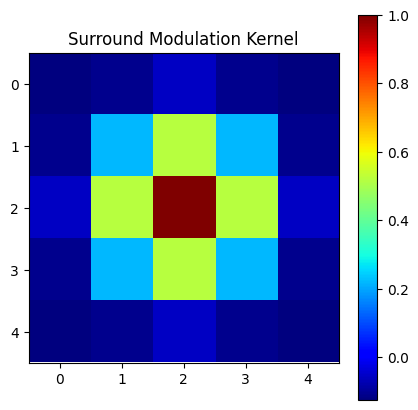

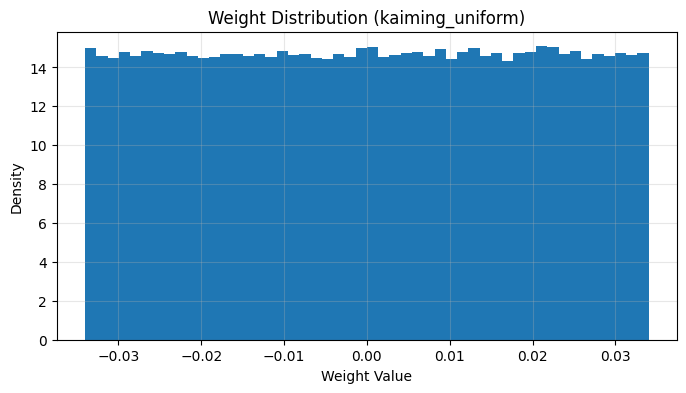

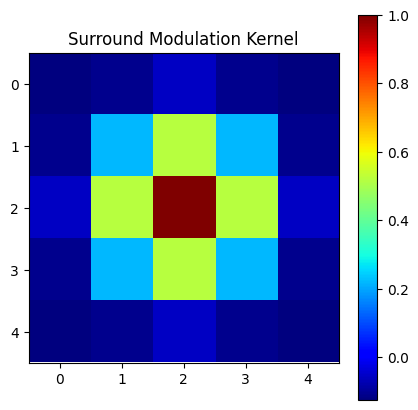

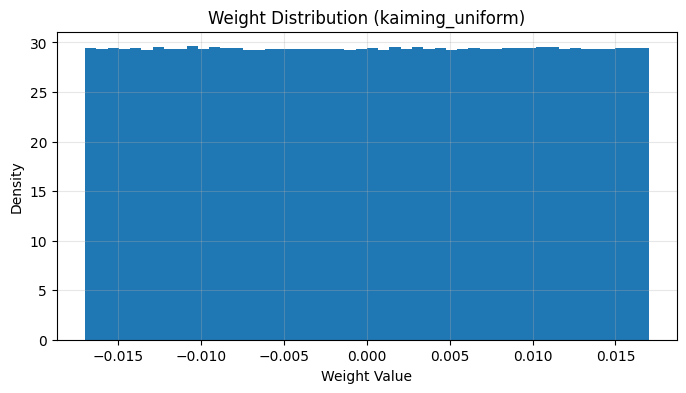

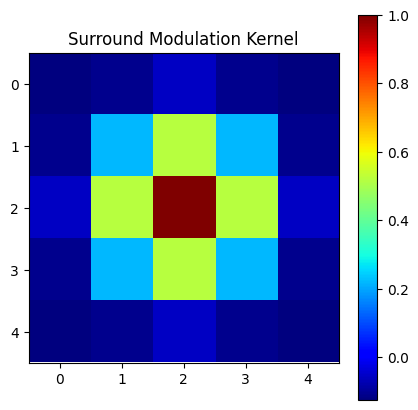

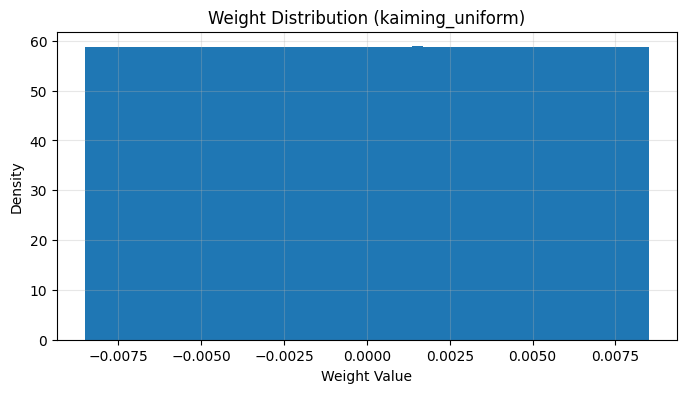

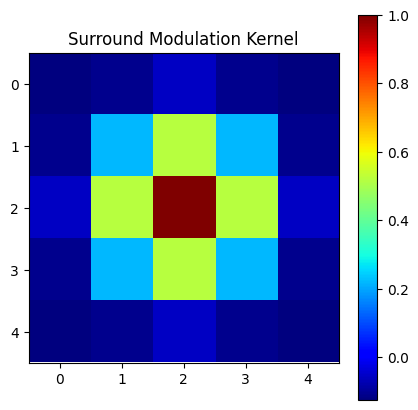

Hebbian epoch 1
Batch 0/79
Epoch [1/20] | Train Loss: 2.7640 | Train Acc: 36.26% | Test Loss: 1.5783 | Test Acc: 50.88% | LR: 0.001000
Epoch [2/20] | Train Loss: 1.7869 | Train Acc: 49.72% | Test Loss: 1.4790 | Test Acc: 53.86% | LR: 0.001000
Epoch [3/20] | Train Loss: 1.4723 | Train Acc: 56.90% | Test Loss: 1.6091 | Test Acc: 53.76% | LR: 0.001000
Epoch [4/20] | Train Loss: 1.2929 | Train Acc: 62.12% | Test Loss: 1.6670 | Test Acc: 53.25% | LR: 0.001000
Epoch [5/20] | Train Loss: 1.0150 | Train Acc: 68.20% | Test Loss: 1.3253 | Test Acc: 60.30% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.9234 | Train Acc: 70.18% | Test Loss: 1.4087 | Test Acc: 59.52% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.8125 | Train Acc: 73.68% | Test Loss: 1.1858 | Test Acc: 63.35% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.6639 | Train Acc: 77.76% | Test Loss: 1.3848 | Test Acc: 60.27% | LR: 0.001000
Epoch [9/20] | Train Loss: 0.6682 | Train Acc: 77.76% | Test Loss: 1.4270 | Test Acc: 60.40% | LR: 0.001000
E

In [44]:

for seed in seeds:

    print(f"RUN {seed + 1}/5 | SEED = {seed}")

   
    set_seed(seed)

      # Generator specifically for this run
    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        stl10_train,
        batch_size=64,
        shuffle=True,
        num_workers=2,
        worker_init_fn=seed_worker,
        generator=g
    )

    test_loader = DataLoader(
        stl10_test,
        batch_size=64,
        shuffle=False, #researchers have test data shuffled, but this is again unecessary, since no learning is occuring (eval only)
        num_workers=2,
        worker_init_fn=seed_worker,
        generator=g
    )

    #fresh model for every seed

    hebb_param = get_hebbian_config(version="optimal")

    model = Net_Hebbian(
        hebb_params=hebb_param,
        version="stl_net"
    ).to(device)


    # hebbian feature learning ('Unsupervised Feature Learning Phase' trained for 1 epoch)
    model.train()

    for epoch in range(1):

        print(f"Hebbian epoch {epoch + 1}")

        for i, (inputs, _) in enumerate(train_loader):

            inputs = inputs.to(device)


            
            with torch.no_grad():
                model(inputs)

            for layer in [model.conv1, model.conv2, model.conv3, model.conv4]:
                layer.local_update()

            if i % 100 == 0:
                print(f"Batch {i}/{len(train_loader)}")
                

    # freeze the hebbian feature extractor as now to train classifier

    for module in [
        model.conv1,
        model.conv2,
        model.conv3,
        model.conv4,

        model.bn1,
        model.bn2,
        model.bn3,
        model.bn4

    ]:

        for param in module.parameters():
            param.requires_grad = False

        module.eval()

    #optimiser and schedular as defined in experiment_hebbian.py
    sup_optimizer = torch.optim.Adam(
        model.fc1.parameters(),
        lr=0.001
    )

    scheduler = torch.optim.lr_scheduler.LambdaLR(
        sup_optimizer,
        lr_lambda=lambda epoch:
            0.5 ** max(0, (epoch - 10) // 2)
    )

    criterion = nn.CrossEntropyLoss()

    classifier_history = {
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": []
    }

    #train classier for 20 epochs

    for epoch in range(20):
        model.conv1.eval()
        model.conv2.eval()
        model.conv3.eval()
        model.conv4.eval()


        model.bn1.eval()
        model.bn2.eval()
        model.bn3.eval()
        model.bn4.eval()


        model.fc1.train()
        model.dropout.train()

        running_loss = 0.0
        correct = 0
        total = 0


        for inputs, labels in train_loader:

            inputs = inputs.to(device)
            

            labels = labels.to(device)

            sup_optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            loss.backward()

            sup_optimizer.step()

            running_loss += loss.item() * labels.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_accuracy = 100 * correct / total

        #get the evaluation results on the test set

        model.eval()

        test_running_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():

            for inputs, labels in test_loader:

                inputs = inputs.to(device)

                labels = labels.to(device)

                outputs = model(inputs)

                loss = criterion(outputs, labels)

                test_running_loss += loss.item() * labels.size(0)

                _, predicted = torch.max(outputs, 1)

                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()

        test_loss = test_running_loss / test_total
        test_accuracy = 100 * test_correct / test_total


        classifier_history["train_loss"].append(train_loss)
        classifier_history["train_accuracy"].append(train_accuracy)

        classifier_history["test_loss"].append(test_loss)
        classifier_history["test_accuracy"].append(test_accuracy)

        #update the scheduler
        scheduler.step()

        current_lr = sup_optimizer.param_groups[0]["lr"]

        print(
            f"Epoch [{epoch + 1}/20] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_accuracy:.2f}% | "
            f"LR: {current_lr:.6f}"
        )

    # save each runs history
    all_histories[seed] = classifier_history

# Attempting whitening...
### The authors' direct, full-covariance zca is impractical for STL-10 using the available hardware/software configuration, and a more specialised formulation would be required to make the preprocessing tractable... it is likely that applying zca here improves the performance such that we saw with cifar-10, however the below shows that Colab's A100 cannot perform the eigendecomposition of the large [27648, 27648] input space (if instead this task was put to cpu, this would take an incredibly long time)

In [29]:
combined_dataset = ConcatDataset([
    stl10_train,
    stl10_test
])

zca_loader = DataLoader(
    combined_dataset,
    batch_size=64,
    shuffle=False #no need to shuffle the zca loader (its not learning)
)

In [30]:
all_data = []

for images, _ in zca_loader:
    all_data.append(images)

all_data = torch.cat(all_data, dim=0)

print(all_data.shape)

torch.Size([13000, 3, 96, 96])


In [31]:
device

device(type='cuda')

In [32]:
all_data = all_data.to(device)

In [33]:
print(all_data.device)

cuda:0


In [34]:
print(all_data.shape)
print(all_data.dtype)
print(all_data.device)

x = all_data.reshape(all_data.shape[0], -1)

print("x:", x.shape)

mean = x.mean(dim=0, keepdim=True)
std = x.std(dim=0, keepdim=True)

x = (x - mean) / (std + 1e-3)

print("x finite:", torch.isfinite(x).all().item())

cov = torch.mm(x.T, x) / (x.shape[0] - 1)

print("cov:", cov.shape)
print("cov dtype:", cov.dtype)
print("cov finite:", torch.isfinite(cov).all().item())
print("cov max:", cov.abs().max().item())

torch.Size([13000, 3, 96, 96])
torch.float32
cuda:0
x: torch.Size([13000, 27648])
x finite: True
cov: torch.Size([27648, 27648])
cov dtype: torch.float32
cov finite: True
cov max: 0.9983218312263489


In [ ]:
torch.cuda.synchronize()

print("trying eigendecomposition...")
eigenvalues, eigenvectors = torch.linalg.eigh(cov)

torch.cuda.synchronize()

print("SUCCESS")

Trying eigendecomposition...


_LinAlgError: cusolver error: CUSOLVER_STATUS_INVALID_VALUE, when calling `cusolverDnXsyevd_bufferSize( handle, params, jobz, uplo, n, CUDA_R_32F, reinterpret_cast<const void*>(A), lda, CUDA_R_32F, reinterpret_cast<const void*>(W), CUDA_R_32F, workspaceInBytesOnDevice, workspaceInBytesOnHost)`. This error may appear if the input matrix contains NaN. If you keep seeing this error, you may use `torch.backends.cuda.preferred_linalg_library()` to try linear algebra operators with other supported backends. See https://pytorch.org/docs/stable/backends.html#torch.backends.cuda.preferred_linalg_library

In [ ]:
zca = ZCAWhitening(epsilon=1e-3)

zca.fit(all_data)

_LinAlgError: cusolver error: CUSOLVER_STATUS_INVALID_VALUE, when calling `cusolverDnXsyevd_bufferSize( handle, params, jobz, uplo, n, CUDA_R_32F, reinterpret_cast<const void*>(A), lda, CUDA_R_32F, reinterpret_cast<const void*>(W), CUDA_R_32F, workspaceInBytesOnDevice, workspaceInBytesOnHost)`. This error may appear if the input matrix contains NaN. If you keep seeing this error, you may use `torch.backends.cuda.preferred_linalg_library()` to try linear algebra operators with other supported backends. See https://pytorch.org/docs/stable/backends.html#torch.backends.cuda.preferred_linalg_library

# Running 5 runs for the normalised version

In [18]:
final_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Resize((96, 96)),
    transforms.Normalize(mean=[0.4467, 0.4398, 0.4066], std=[0.2603, 0.2566, 0.2713])
])

In [19]:
# apply transforms

stl10_train = datasets.STL10(
    root=stl10_root,
    split="train",
    download=False,
    transform=final_transform
)

stl10_test = datasets.STL10(
    root=stl10_root,
    split="test",
    download=False,
    transform=final_transform
)

In [20]:
seeds=[0,1,2,3,4]
all_histories={}

RUN 1/5 | SEED = 0
Building STL SoftHebb model


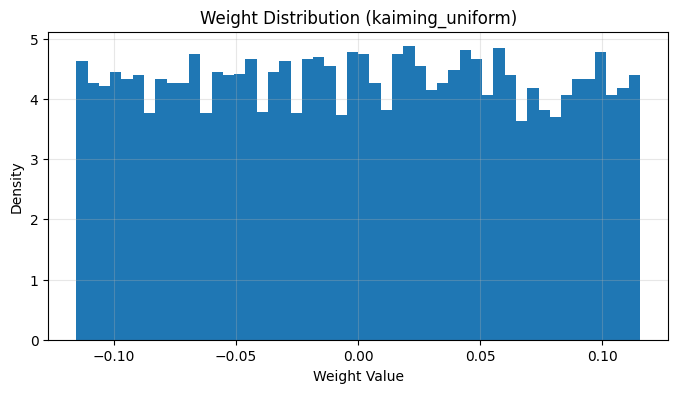

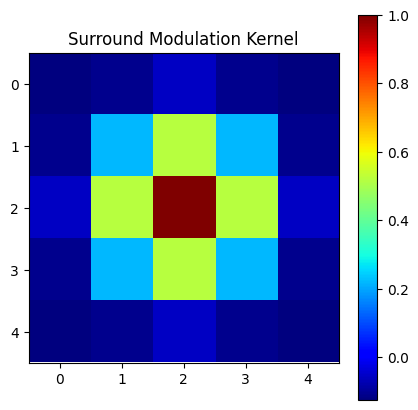

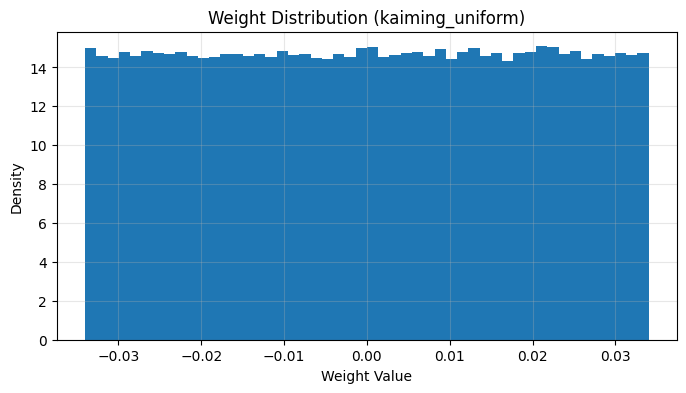

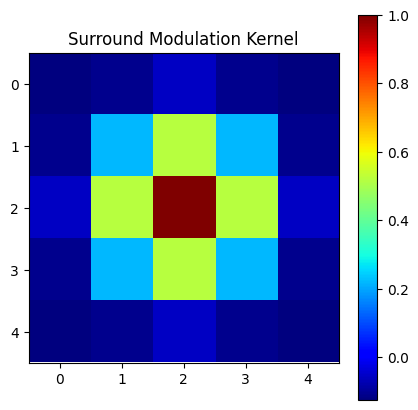

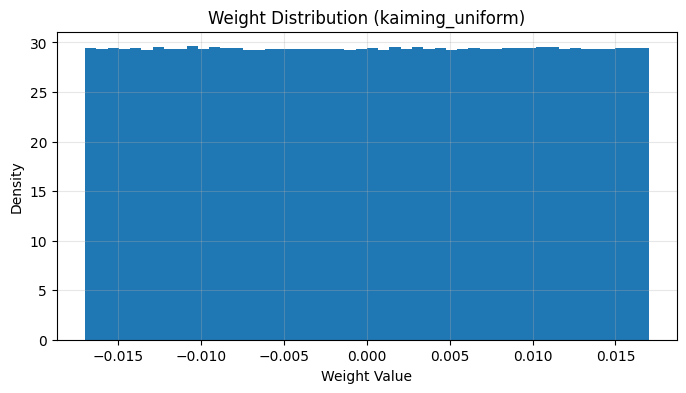

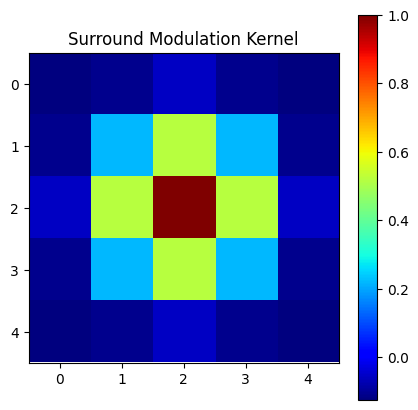

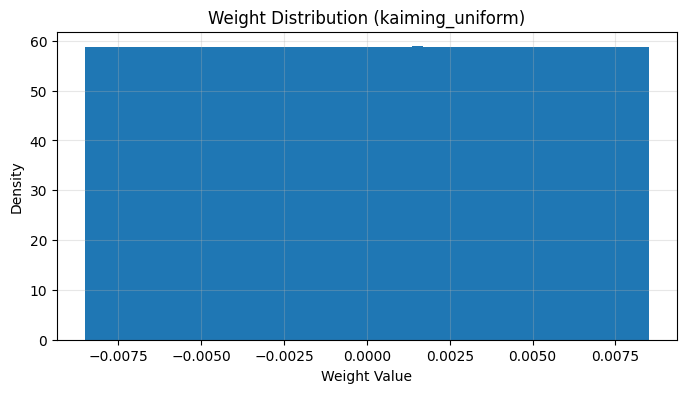

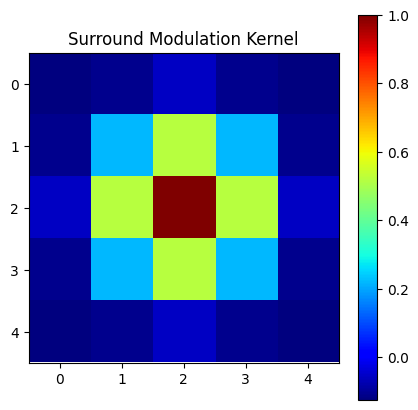

Hebbian epoch 1
Batch 0/79
Epoch [1/20] | Train Loss: 2.7640 | Train Acc: 36.26% | Test Loss: 1.5783 | Test Acc: 50.88% | LR: 0.001000
Epoch [2/20] | Train Loss: 1.7869 | Train Acc: 49.72% | Test Loss: 1.4790 | Test Acc: 53.86% | LR: 0.001000
Epoch [3/20] | Train Loss: 1.4723 | Train Acc: 56.90% | Test Loss: 1.6091 | Test Acc: 53.76% | LR: 0.001000
Epoch [4/20] | Train Loss: 1.2929 | Train Acc: 62.12% | Test Loss: 1.6670 | Test Acc: 53.25% | LR: 0.001000
Epoch [5/20] | Train Loss: 1.0150 | Train Acc: 68.20% | Test Loss: 1.3253 | Test Acc: 60.30% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.9234 | Train Acc: 70.18% | Test Loss: 1.4087 | Test Acc: 59.52% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.8125 | Train Acc: 73.68% | Test Loss: 1.1858 | Test Acc: 63.35% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.6639 | Train Acc: 77.76% | Test Loss: 1.3848 | Test Acc: 60.27% | LR: 0.001000
Epoch [9/20] | Train Loss: 0.6682 | Train Acc: 77.76% | Test Loss: 1.4270 | Test Acc: 60.40% | LR: 0.001000
E

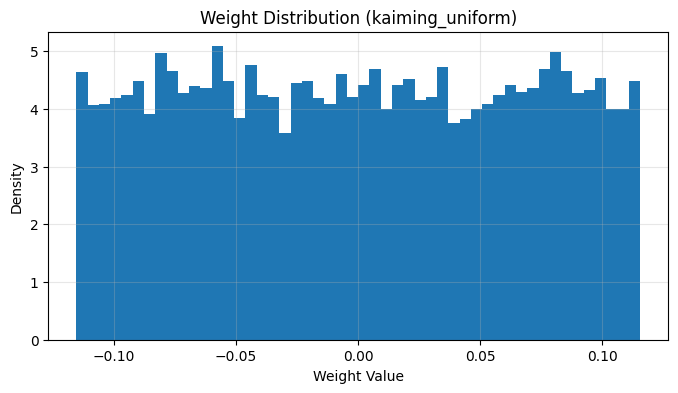

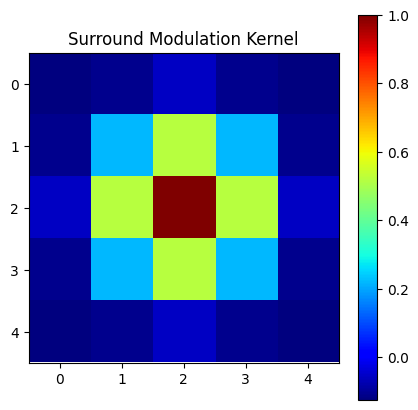

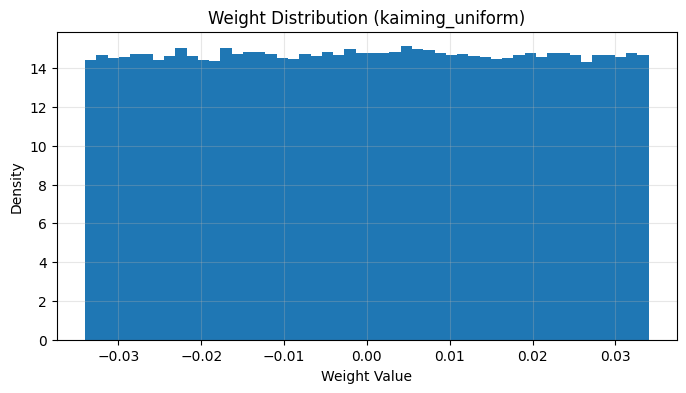

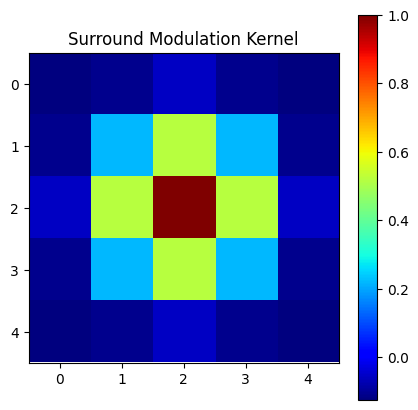

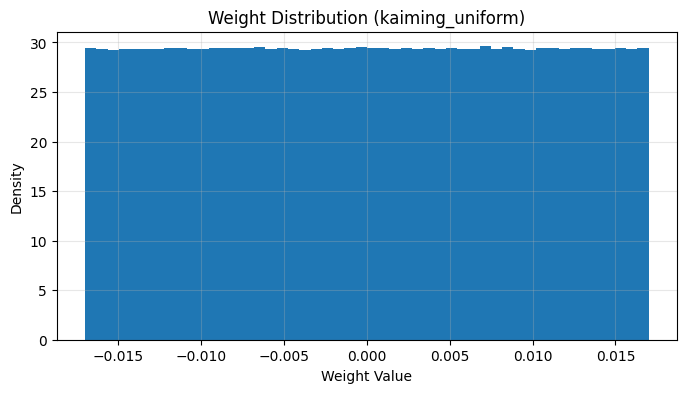

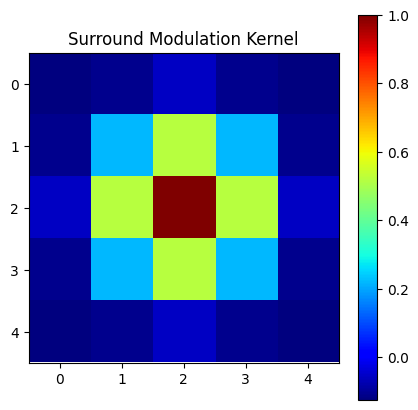

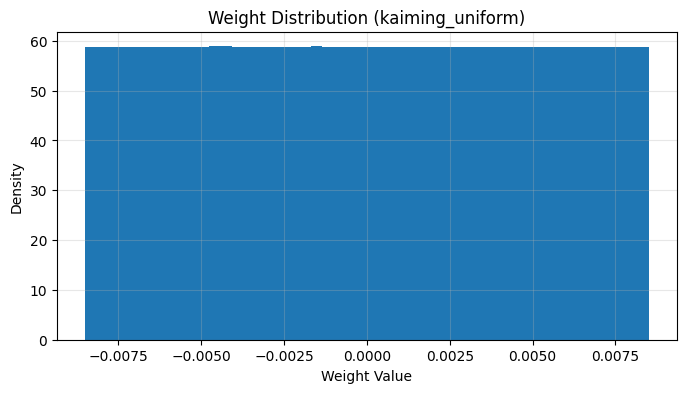

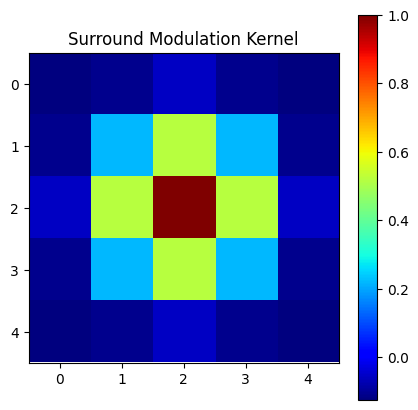

Hebbian epoch 1
Batch 0/79
Epoch [1/20] | Train Loss: 2.8849 | Train Acc: 35.70% | Test Loss: 1.8338 | Test Acc: 47.76% | LR: 0.001000
Epoch [2/20] | Train Loss: 1.8427 | Train Acc: 50.02% | Test Loss: 1.6077 | Test Acc: 54.51% | LR: 0.001000
Epoch [3/20] | Train Loss: 1.6115 | Train Acc: 56.12% | Test Loss: 1.5939 | Test Acc: 54.02% | LR: 0.001000
Epoch [4/20] | Train Loss: 1.2768 | Train Acc: 62.14% | Test Loss: 1.6018 | Test Acc: 57.36% | LR: 0.001000
Epoch [5/20] | Train Loss: 1.1335 | Train Acc: 67.00% | Test Loss: 1.6108 | Test Acc: 56.02% | LR: 0.001000
Epoch [6/20] | Train Loss: 1.0513 | Train Acc: 68.68% | Test Loss: 1.6375 | Test Acc: 55.73% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.8872 | Train Acc: 71.80% | Test Loss: 1.5959 | Test Acc: 56.66% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.8700 | Train Acc: 72.56% | Test Loss: 1.4560 | Test Acc: 60.44% | LR: 0.001000
Epoch [9/20] | Train Loss: 0.7776 | Train Acc: 75.38% | Test Loss: 1.4848 | Test Acc: 59.98% | LR: 0.001000
E

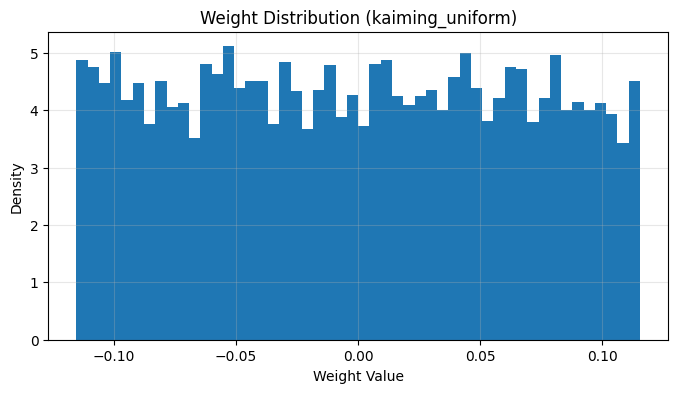

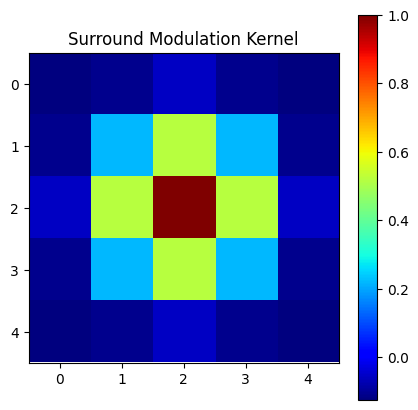

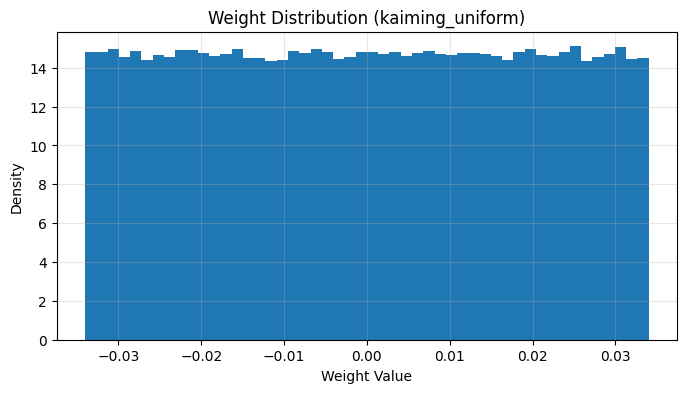

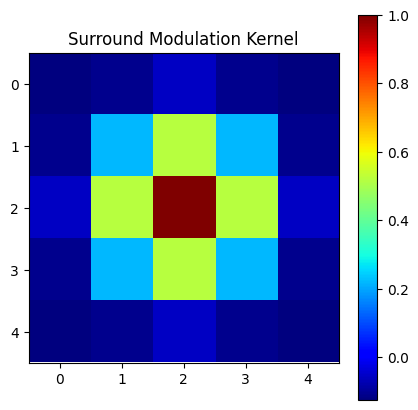

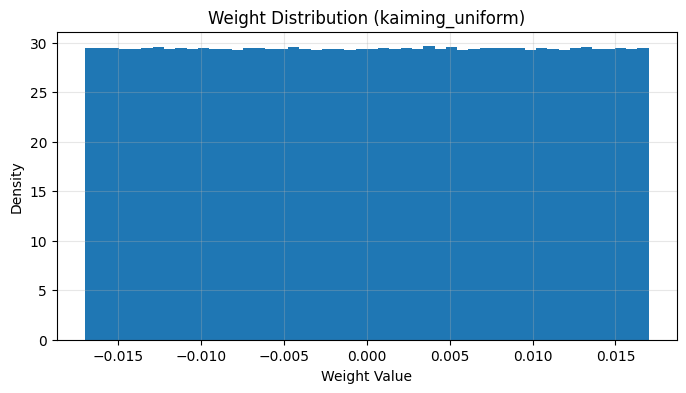

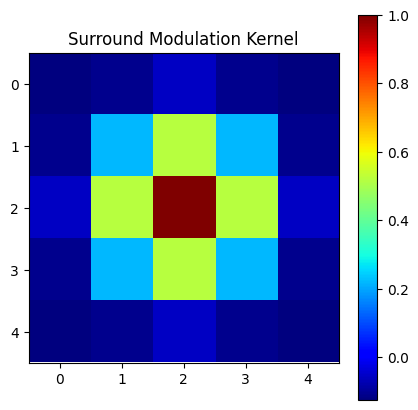

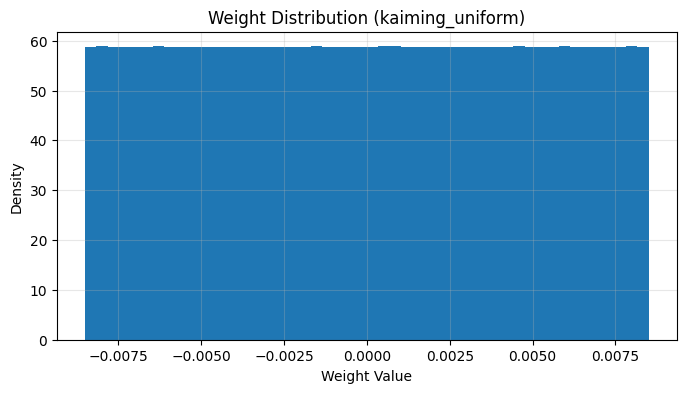

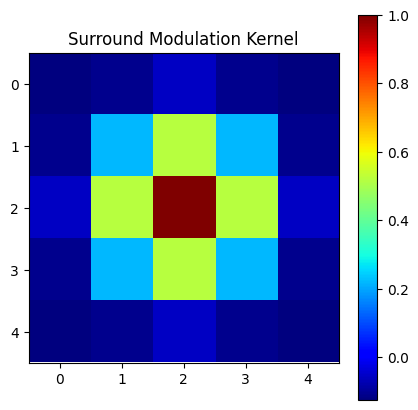

Hebbian epoch 1
Batch 0/79
Epoch [1/20] | Train Loss: 2.8668 | Train Acc: 35.38% | Test Loss: 2.0314 | Test Acc: 43.90% | LR: 0.001000
Epoch [2/20] | Train Loss: 1.9403 | Train Acc: 49.88% | Test Loss: 1.9287 | Test Acc: 49.21% | LR: 0.001000
Epoch [3/20] | Train Loss: 1.5658 | Train Acc: 56.30% | Test Loss: 1.3100 | Test Acc: 59.31% | LR: 0.001000
Epoch [4/20] | Train Loss: 1.2546 | Train Acc: 62.72% | Test Loss: 1.6398 | Test Acc: 55.69% | LR: 0.001000
Epoch [5/20] | Train Loss: 1.1024 | Train Acc: 66.34% | Test Loss: 1.4553 | Test Acc: 58.29% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.9925 | Train Acc: 69.72% | Test Loss: 1.3492 | Test Acc: 60.89% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.9348 | Train Acc: 71.00% | Test Loss: 1.5179 | Test Acc: 59.06% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.7480 | Train Acc: 76.62% | Test Loss: 1.3571 | Test Acc: 61.94% | LR: 0.001000
Epoch [9/20] | Train Loss: 0.7516 | Train Acc: 75.70% | Test Loss: 1.6861 | Test Acc: 57.27% | LR: 0.001000
E

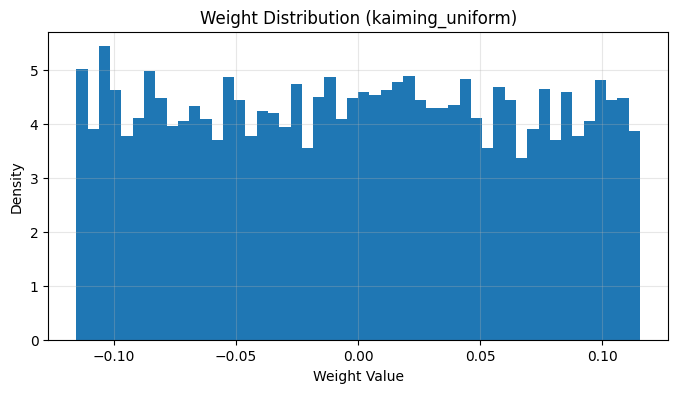

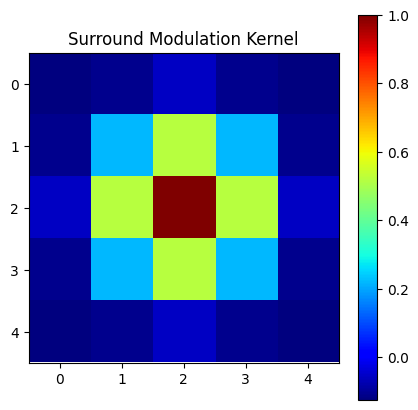

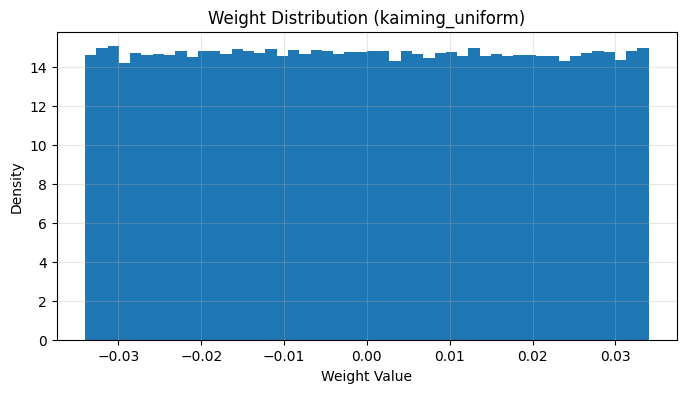

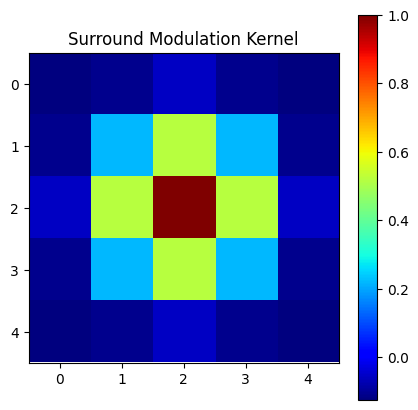

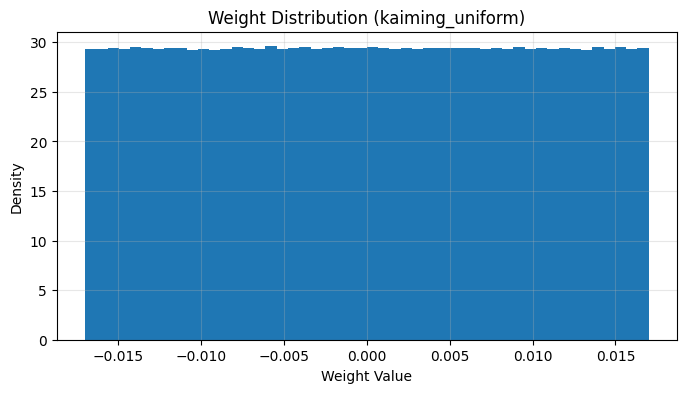

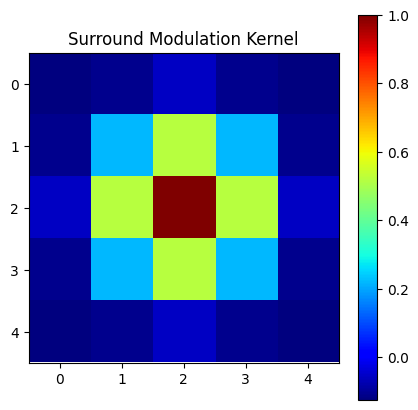

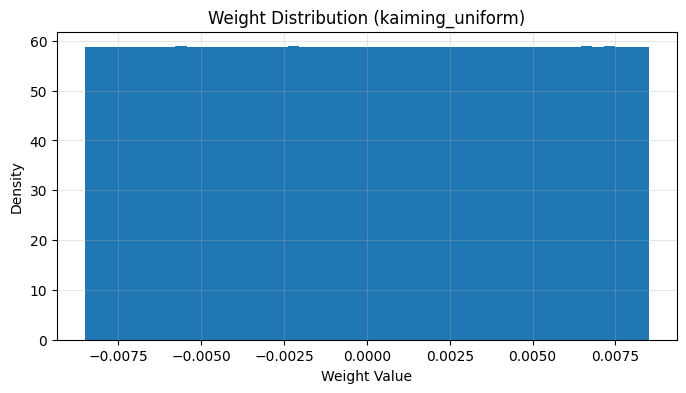

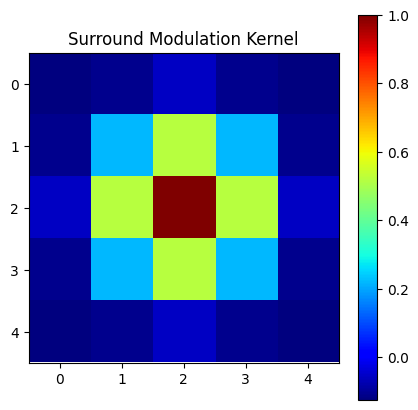

Hebbian epoch 1
Batch 0/79
Epoch [1/20] | Train Loss: 2.5109 | Train Acc: 36.90% | Test Loss: 1.8185 | Test Acc: 46.31% | LR: 0.001000
Epoch [2/20] | Train Loss: 1.7354 | Train Acc: 50.52% | Test Loss: 1.4877 | Test Acc: 53.29% | LR: 0.001000
Epoch [3/20] | Train Loss: 1.3685 | Train Acc: 58.12% | Test Loss: 1.4130 | Test Acc: 56.61% | LR: 0.001000
Epoch [4/20] | Train Loss: 1.0610 | Train Acc: 65.90% | Test Loss: 1.3686 | Test Acc: 56.83% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.9630 | Train Acc: 68.08% | Test Loss: 1.3232 | Test Acc: 59.08% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.8698 | Train Acc: 70.88% | Test Loss: 1.3136 | Test Acc: 60.81% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.7468 | Train Acc: 74.50% | Test Loss: 1.2494 | Test Acc: 62.75% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.5906 | Train Acc: 79.94% | Test Loss: 1.5393 | Test Acc: 58.25% | LR: 0.001000
Epoch [9/20] | Train Loss: 0.6365 | Train Acc: 78.22% | Test Loss: 1.3852 | Test Acc: 61.58% | LR: 0.001000
E

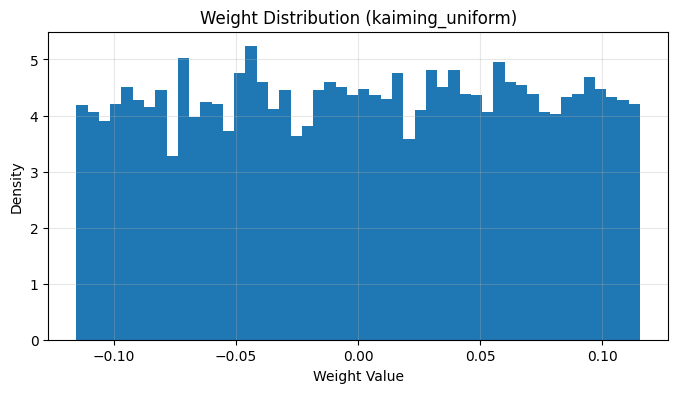

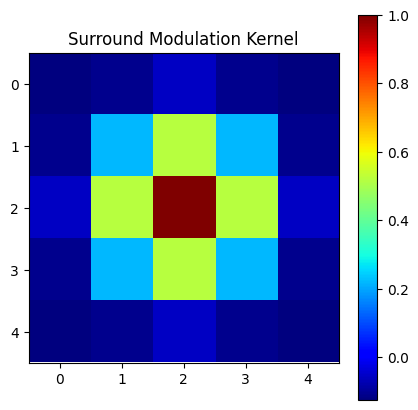

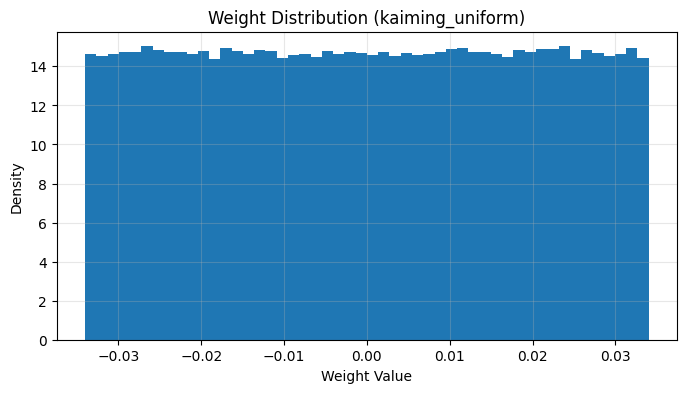

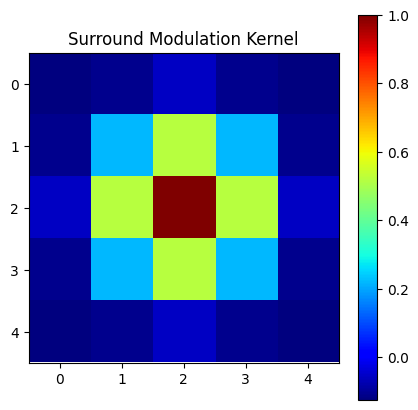

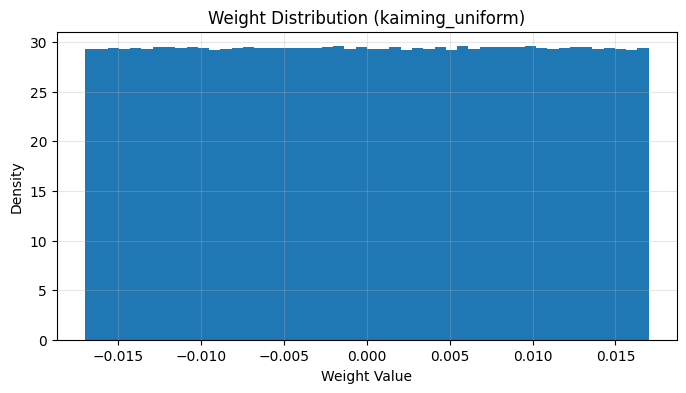

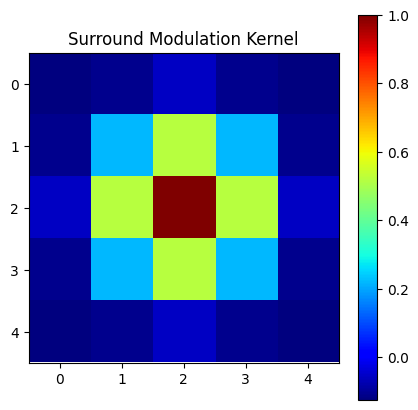

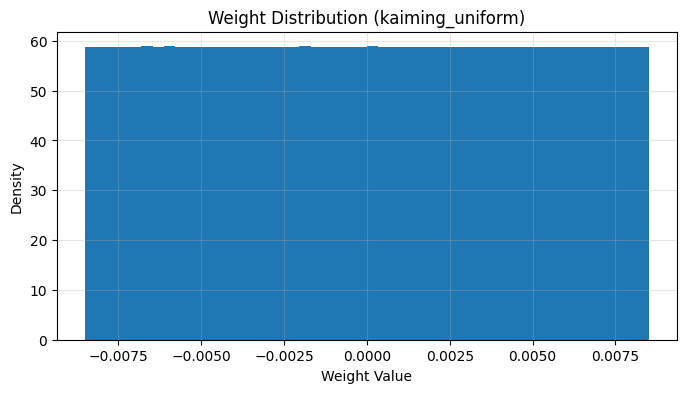

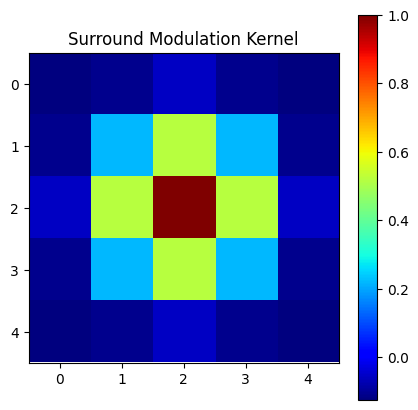

Hebbian epoch 1
Batch 0/79
Epoch [1/20] | Train Loss: 2.7188 | Train Acc: 36.84% | Test Loss: 1.8585 | Test Acc: 45.23% | LR: 0.001000
Epoch [2/20] | Train Loss: 1.7680 | Train Acc: 51.96% | Test Loss: 1.5937 | Test Acc: 53.14% | LR: 0.001000
Epoch [3/20] | Train Loss: 1.4565 | Train Acc: 58.12% | Test Loss: 1.6277 | Test Acc: 53.76% | LR: 0.001000
Epoch [4/20] | Train Loss: 1.3043 | Train Acc: 62.18% | Test Loss: 1.4887 | Test Acc: 57.48% | LR: 0.001000
Epoch [5/20] | Train Loss: 1.0541 | Train Acc: 67.86% | Test Loss: 1.4332 | Test Acc: 58.49% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.9765 | Train Acc: 69.90% | Test Loss: 1.3525 | Test Acc: 60.77% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.8075 | Train Acc: 74.06% | Test Loss: 1.6102 | Test Acc: 58.49% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.7727 | Train Acc: 75.82% | Test Loss: 1.4531 | Test Acc: 60.16% | LR: 0.001000
Epoch [9/20] | Train Loss: 0.6932 | Train Acc: 77.64% | Test Loss: 1.2736 | Test Acc: 63.81% | LR: 0.001000
E

In [23]:

for seed in seeds:

    print(f"RUN {seed + 1}/5 | SEED = {seed}")

   
    set_seed(seed)

      # Generator specifically for this run
    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        stl10_train,
        batch_size=64,
        shuffle=True,
        num_workers=2,
        worker_init_fn=seed_worker,
        generator=g
    )

    test_loader = DataLoader(
        stl10_test,
        batch_size=64,
        shuffle=False, #researchers have test data shuffled, but this is again unecessary, since no learning is occuring (eval only)
        num_workers=2,
        worker_init_fn=seed_worker,
        generator=g
    )

    #fresh model for every seed

    hebb_param = get_hebbian_config(version="optimal")

    model = Net_Hebbian(
        hebb_params=hebb_param,
        version="stl_net"
    ).to(device)


    # hebbian feature learning ('Unsupervised Feature Learning Phase' trained for 1 epoch)
    model.train()

    for epoch in range(1):

        print(f"Hebbian epoch {epoch + 1}")

        for i, (inputs, _) in enumerate(train_loader):

            inputs = inputs.to(device)


            
            with torch.no_grad():
                model(inputs)

            for layer in [model.conv1, model.conv2, model.conv3, model.conv4]:
                layer.local_update()

            if i % 100 == 0:
                print(f"Batch {i}/{len(train_loader)}")
                

    # freeze the hebbian feature extractor as now to train classifier

    for module in [
        model.conv1,
        model.conv2,
        model.conv3,
        model.conv4,

        model.bn1,
        model.bn2,
        model.bn3,
        model.bn4

    ]:

        for param in module.parameters():
            param.requires_grad = False

        module.eval()

    #optimiser and schedular as defined in experiment_hebbian.py
    sup_optimizer = torch.optim.Adam(
        model.fc1.parameters(),
        lr=0.001
    )

    scheduler = torch.optim.lr_scheduler.LambdaLR(
        sup_optimizer,
        lr_lambda=lambda epoch:
            0.5 ** max(0, (epoch - 10) // 2)
    )

    criterion = nn.CrossEntropyLoss()

    classifier_history = {
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": []
    }

    #train classier for 20 epochs

    for epoch in range(20):
        model.conv1.eval()
        model.conv2.eval()
        model.conv3.eval()
        model.conv4.eval()


        model.bn1.eval()
        model.bn2.eval()
        model.bn3.eval()
        model.bn4.eval()


        model.fc1.train()
        model.dropout.train()

        running_loss = 0.0
        correct = 0
        total = 0


        for inputs, labels in train_loader:

            inputs = inputs.to(device)
            

            labels = labels.to(device)

            sup_optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            loss.backward()

            sup_optimizer.step()

            running_loss += loss.item() * labels.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_accuracy = 100 * correct / total

        #get the evaluation results on the test set

        model.eval()

        test_running_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():

            for inputs, labels in test_loader:

                inputs = inputs.to(device)

                labels = labels.to(device)

                outputs = model(inputs)

                loss = criterion(outputs, labels)

                test_running_loss += loss.item() * labels.size(0)

                _, predicted = torch.max(outputs, 1)

                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()

        test_loss = test_running_loss / test_total
        test_accuracy = 100 * test_correct / test_total


        classifier_history["train_loss"].append(train_loss)
        classifier_history["train_accuracy"].append(train_accuracy)

        classifier_history["test_loss"].append(test_loss)
        classifier_history["test_accuracy"].append(test_accuracy)

        #update the scheduler
        scheduler.step()

        current_lr = sup_optimizer.param_groups[0]["lr"]

        print(
            f"Epoch [{epoch + 1}/20] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_accuracy:.2f}% | "
            f"LR: {current_lr:.6f}"
        )

    # save each runs history
    all_histories[seed] = classifier_history

# save results and visualise

In [24]:
# Shape: (5 runs, 20 epochs)
train_acc = np.array([
    all_histories[seed]["train_accuracy"]
    for seed in seeds
])

test_acc = np.array([
    all_histories[seed]["test_accuracy"]
    for seed in seeds
])

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [26]:
train_acc_df=pd.DataFrame(train_acc)

In [27]:
test_acc_df=pd.DataFrame(test_acc)


In [28]:
train_acc_df.to_csv("/content/drive/MyDrive/research_jobs/hebbian_3_layer_stl10_train_acc_.csv",index=False)

In [29]:
test_acc_df.to_csv("/content/drive/MyDrive/research_jobs/hebbian_3_layer_stl10_test_acc_.csv",index=False)


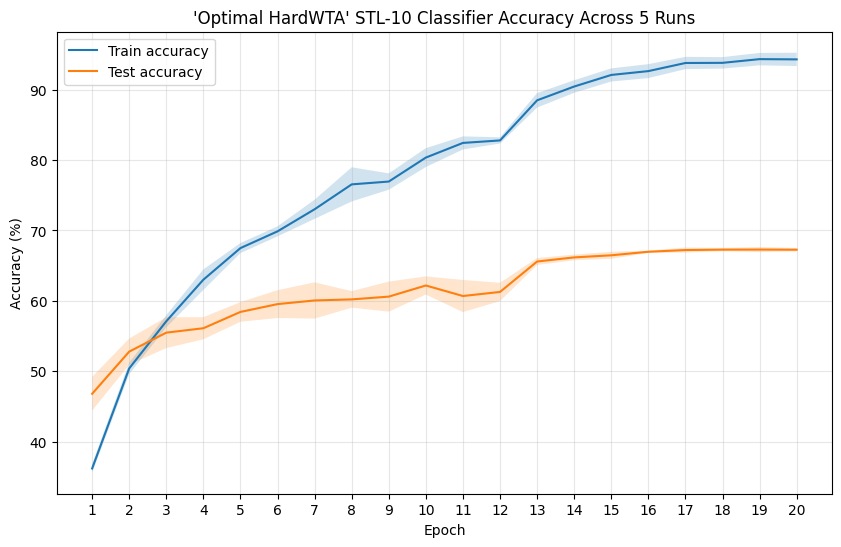

In [31]:
# Mean and standard deviation across the 5 runs
train_mean = train_acc.mean(axis=0)
train_std = train_acc.std(axis=0)

test_mean = test_acc.mean(axis=0)
test_std = test_acc.std(axis=0)

epochs = np.arange(1, 21)

plt.figure(figsize=(10, 6))

plt.plot(epochs, train_mean, label="Train accuracy")
plt.fill_between(
    epochs,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.plot(epochs, test_mean, label="Test accuracy")
plt.fill_between(
    epochs,
    test_mean - test_std,
    test_mean + test_std,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("'Optimal HardWTA' STL-10 Classifier Accuracy Across 5 Runs")
plt.xticks(epochs)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [32]:
print(
    f"Final test accuracy: "
    f"{test_mean[-1]:.2f} ± {test_std[-1]:.2f}%"
)

Final test accuracy: 67.27 ± 0.24%


In [33]:
best_per_run = test_acc.max(axis=1)

print(
    f"Best average test accuracy: "
    f"{best_per_run.mean():.2f} ± {best_per_run.std():.2f}%"
)

Best average test accuracy: 67.47 ± 0.24%


In [34]:
#maximum raw test accuracy - aligns with researcher's 98.5
test_acc.max()

np.float64(67.9)

In [35]:
final10 = np.mean(test_acc[:, 10:20], axis=1)

print(
    f"Mean accuracy final 10 epochs: "
    f"{np.mean(final10):.2f} ± {np.std(final10):.2f}%"
)

Mean accuracy final 10 epochs: 65.62 ± 0.24%


# Back to Cifar-10, Removing random flips entirely along with zca whitening such that model is more comparable to the Filters as Autoencoders using Gradient Descent training procedures...

In [24]:
final_transform = transforms.Compose([
    transforms.ToTensor(),
])

In [ ]:
train_dataset = datasets.ImageFolder(
    root=cifar_train_path,
    transform=final_transform
)


test_dataset = datasets.ImageFolder(
    root=cifar_test_path,
    transform=final_transform
)

In [26]:
seeds = [0, 1, 2, 3, 4]
all_histories = {}

In [27]:
import time

RUN 1/5 | SEED = 0
Building SoftHebb model


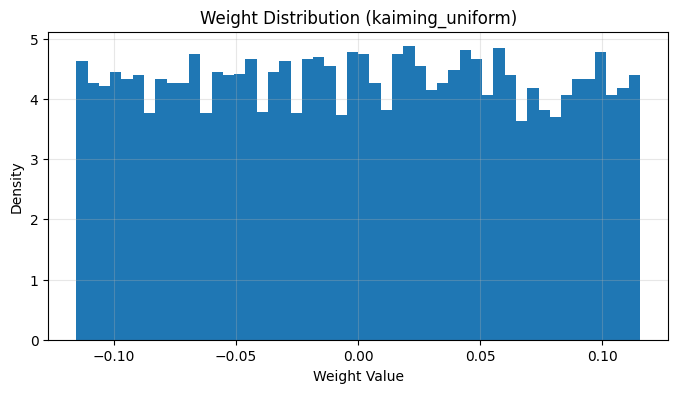

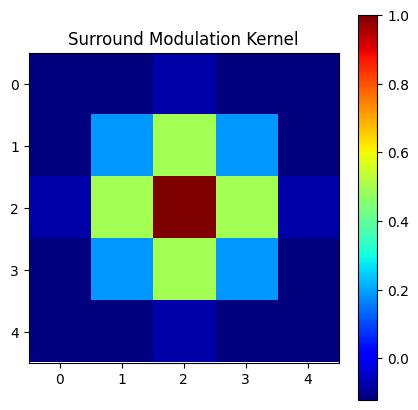

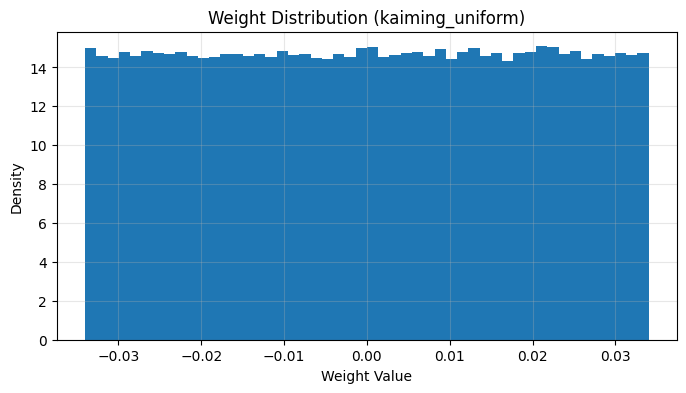

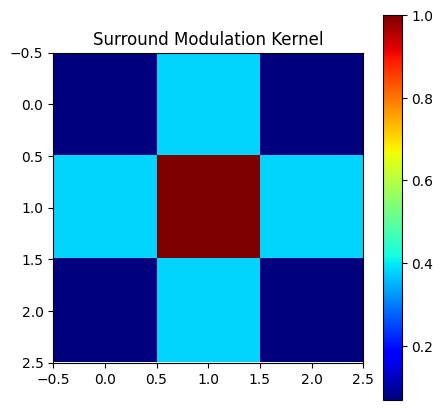

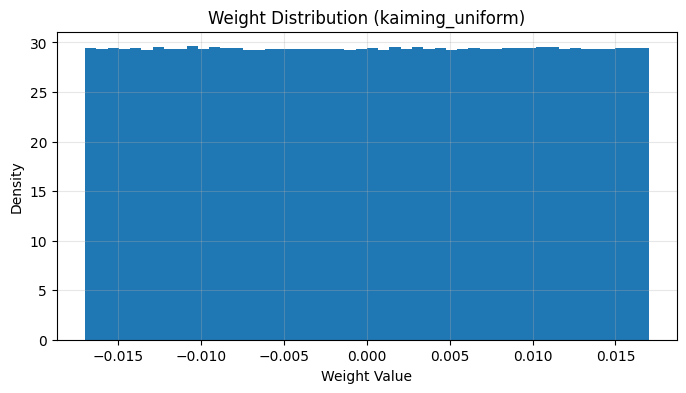

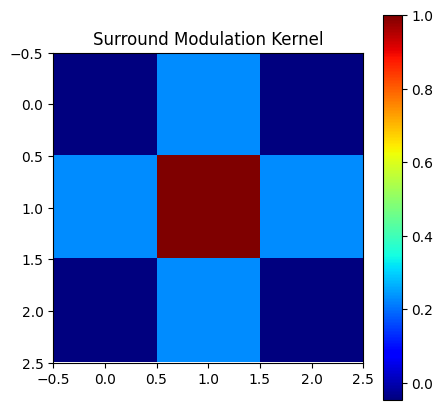

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 1.4457 | Train Acc: 48.81% | Test Loss: 1.1414 | Test Acc: 59.44% | LR: 0.001000
Epoch [2/20] | Train Loss: 1.1447 | Train Acc: 59.79% | Test Loss: 1.0482 | Test Acc: 63.68% | LR: 0.001000
Epoch [3/20] | Train Loss: 1.0551 | Train Acc: 63.25% | Test Loss: 0.9983 | Test Acc: 65.22% | LR: 0.001000
Epoch [4/20] | Train Loss: 1.0140 | Train Acc: 64.62% | Test Loss: 0.9914 | Test Acc: 65.06% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.9739 | Train Acc: 66.15% | Test Loss: 0.9571 | Test Acc: 66.36% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.9508 | Train Acc: 66.86% | Test Loss: 0.9341 | Test Acc: 67.70% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.9364 | Train Acc: 67.49% | Test Loss: 0.9423 | Test Acc: 66.95% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.9204 | Train Acc: 67.89% | Test Loss: 0.8961 | Test Acc: 69.07% | LR: 0.001000
Epoch [9/2

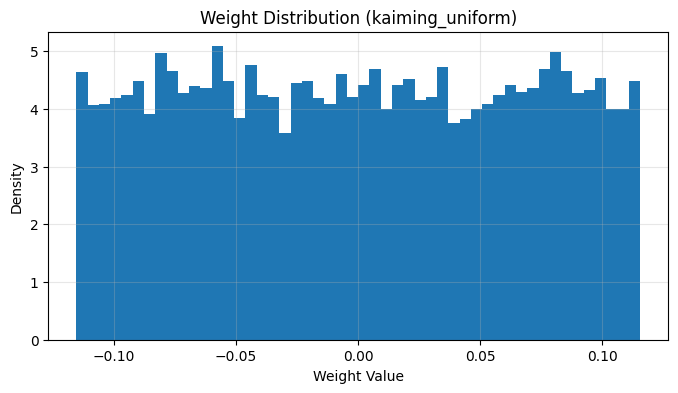

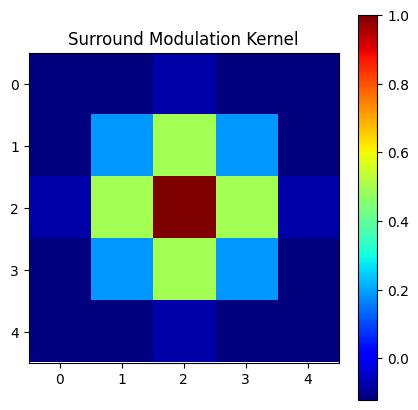

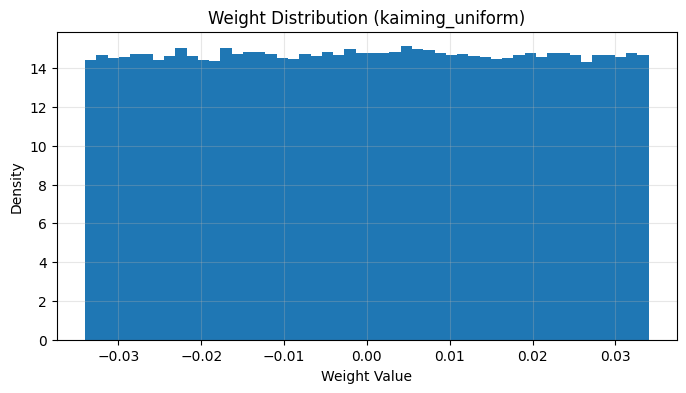

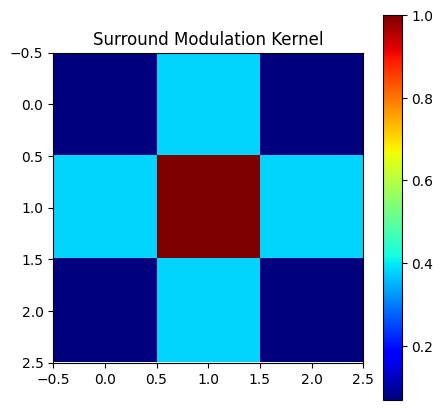

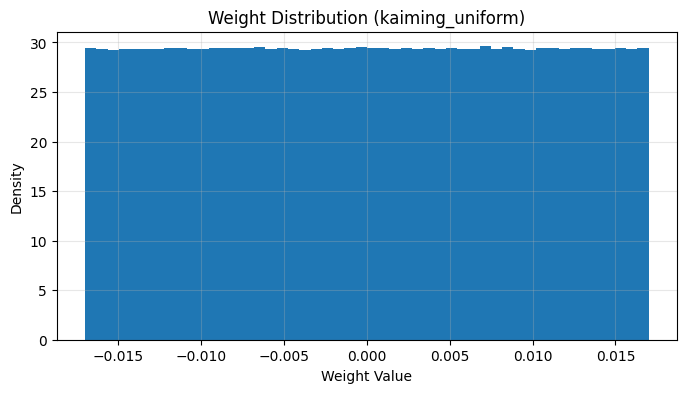

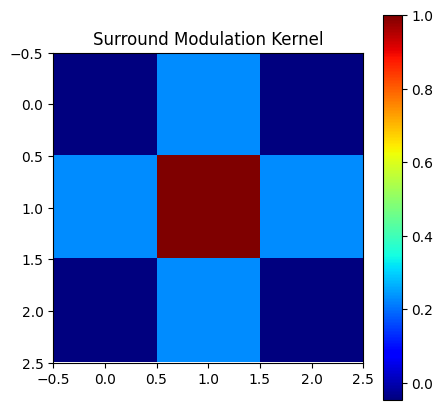

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 1.3970 | Train Acc: 50.26% | Test Loss: 1.1402 | Test Acc: 60.63% | LR: 0.001000
Epoch [2/20] | Train Loss: 1.1245 | Train Acc: 60.58% | Test Loss: 1.0903 | Test Acc: 61.41% | LR: 0.001000
Epoch [3/20] | Train Loss: 1.0475 | Train Acc: 63.34% | Test Loss: 1.0154 | Test Acc: 64.58% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.9946 | Train Acc: 65.37% | Test Loss: 0.9645 | Test Acc: 66.89% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.9610 | Train Acc: 66.28% | Test Loss: 0.9443 | Test Acc: 67.70% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.9361 | Train Acc: 67.36% | Test Loss: 0.9603 | Test Acc: 66.75% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.9154 | Train Acc: 68.01% | Test Loss: 0.9428 | Test Acc: 66.62% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.9016 | Train Acc: 68.43% | Test Loss: 0.9113 | Test Acc: 68.16% | LR: 0.001000
Epoch [9/2

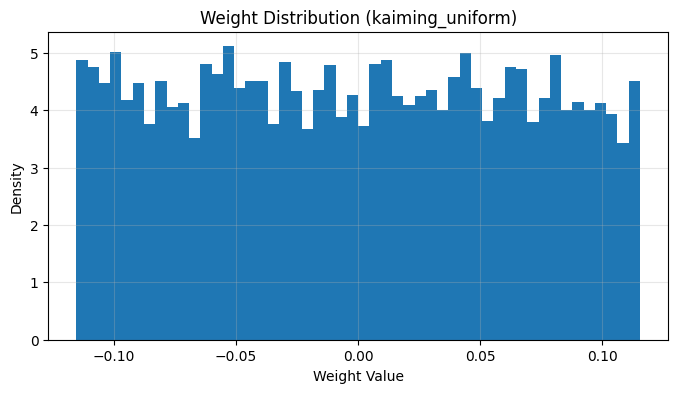

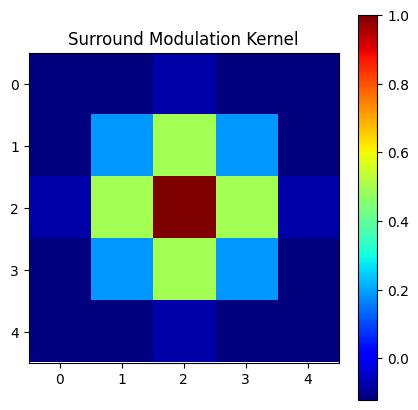

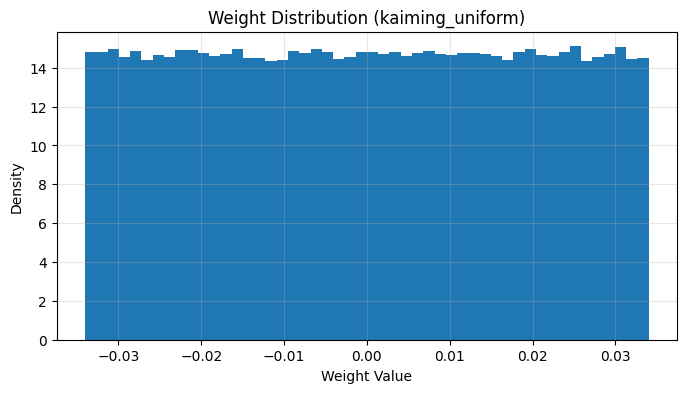

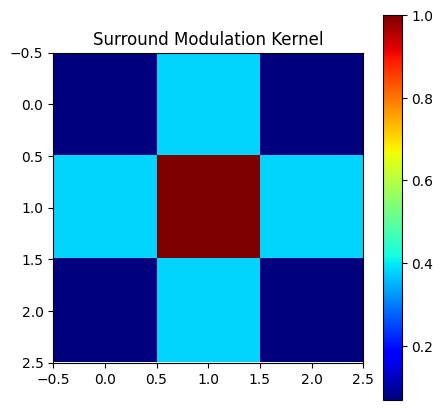

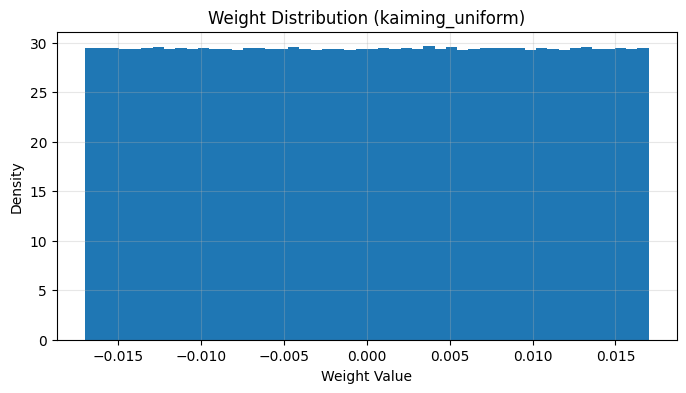

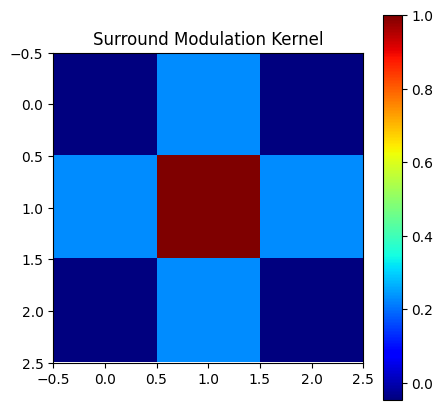

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 1.4208 | Train Acc: 49.57% | Test Loss: 1.1591 | Test Acc: 58.83% | LR: 0.001000
Epoch [2/20] | Train Loss: 1.1285 | Train Acc: 60.58% | Test Loss: 1.0693 | Test Acc: 62.57% | LR: 0.001000
Epoch [3/20] | Train Loss: 1.0459 | Train Acc: 63.41% | Test Loss: 1.0217 | Test Acc: 63.74% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.9971 | Train Acc: 65.34% | Test Loss: 0.9691 | Test Acc: 66.25% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.9650 | Train Acc: 66.26% | Test Loss: 0.9461 | Test Acc: 67.12% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.9389 | Train Acc: 67.52% | Test Loss: 0.9587 | Test Acc: 66.20% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.9217 | Train Acc: 67.93% | Test Loss: 0.9257 | Test Acc: 67.83% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.9014 | Train Acc: 68.58% | Test Loss: 0.9082 | Test Acc: 68.80% | LR: 0.001000
Epoch [9/2

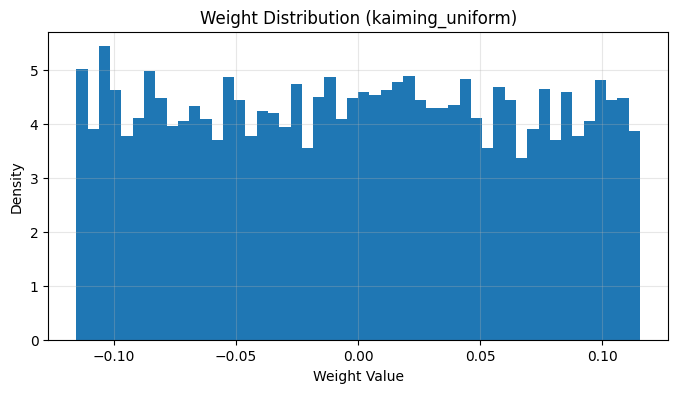

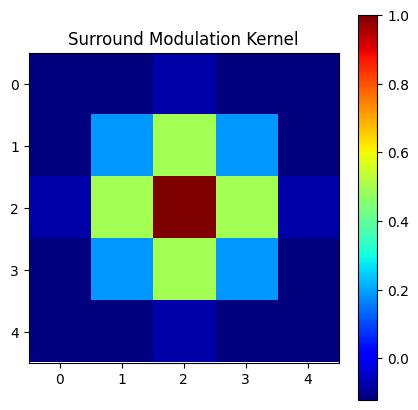

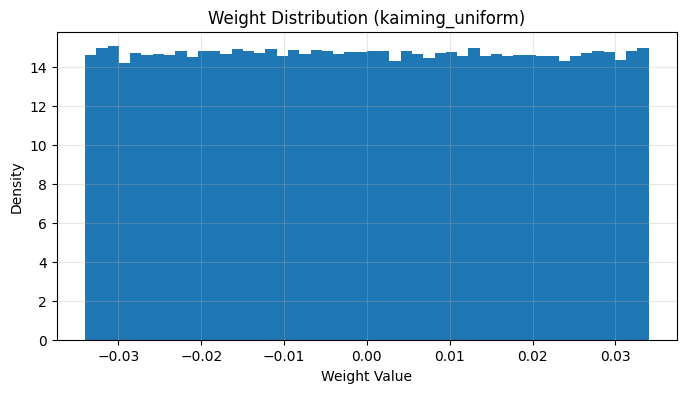

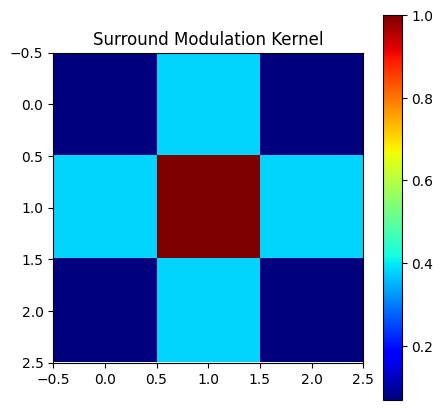

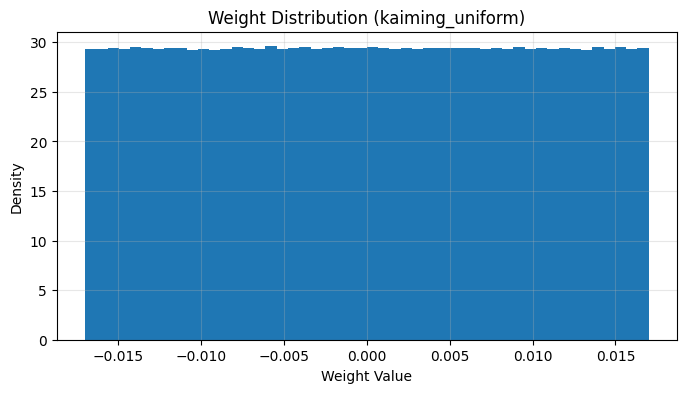

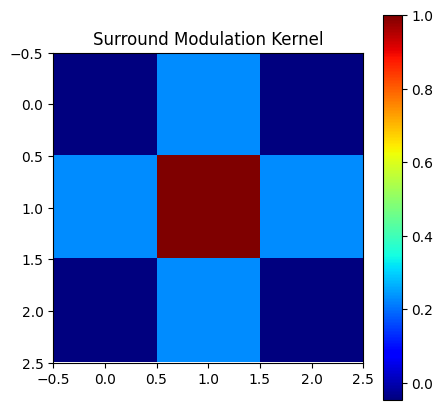

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 1.3898 | Train Acc: 50.70% | Test Loss: 1.1472 | Test Acc: 59.89% | LR: 0.001000
Epoch [2/20] | Train Loss: 1.1070 | Train Acc: 61.10% | Test Loss: 1.0669 | Test Acc: 62.49% | LR: 0.001000
Epoch [3/20] | Train Loss: 1.0251 | Train Acc: 64.01% | Test Loss: 0.9750 | Test Acc: 66.16% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.9820 | Train Acc: 65.75% | Test Loss: 0.9619 | Test Acc: 66.96% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.9444 | Train Acc: 67.09% | Test Loss: 0.9368 | Test Acc: 66.79% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.9230 | Train Acc: 67.83% | Test Loss: 0.9181 | Test Acc: 67.75% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.9006 | Train Acc: 68.63% | Test Loss: 0.8975 | Test Acc: 68.68% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.8852 | Train Acc: 68.93% | Test Loss: 0.9298 | Test Acc: 67.97% | LR: 0.001000
Epoch [9/2

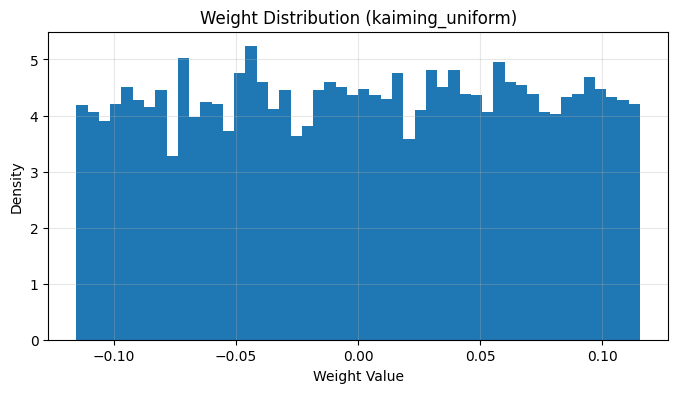

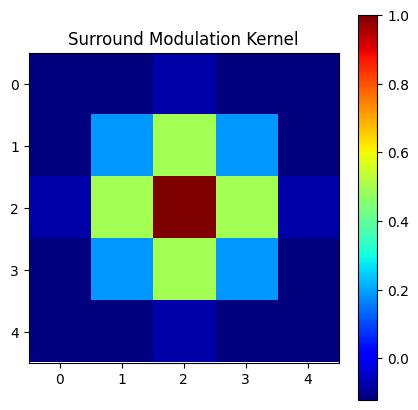

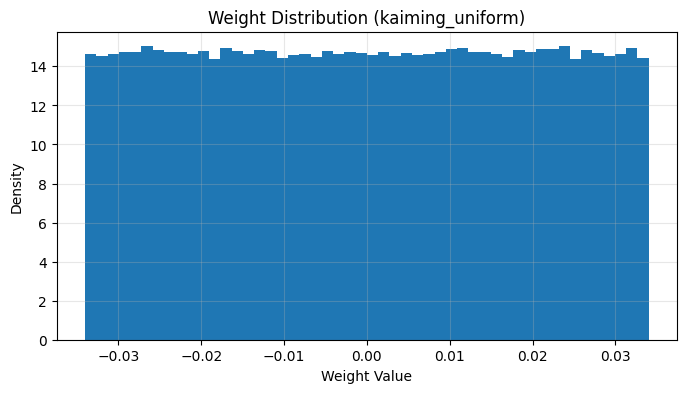

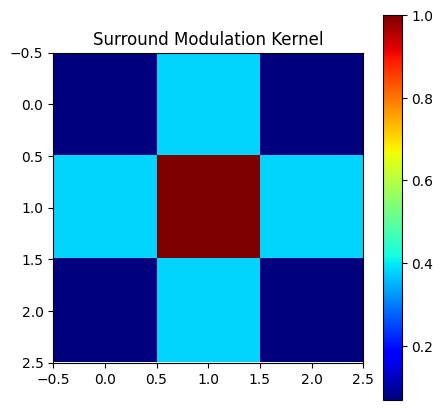

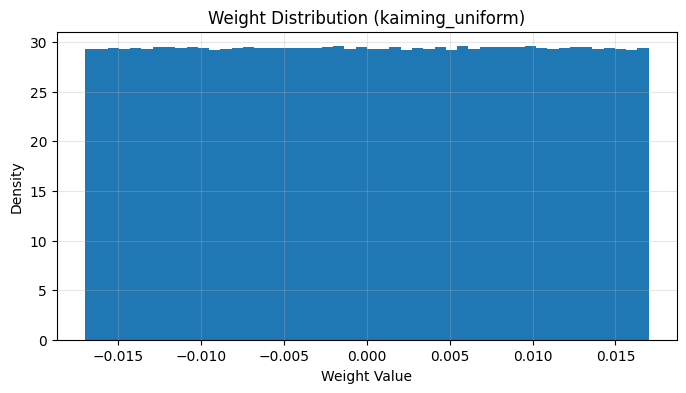

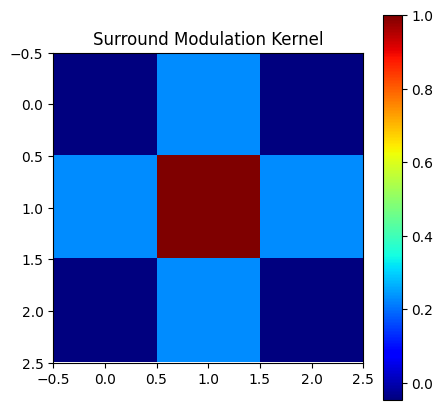

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 1.4107 | Train Acc: 49.97% | Test Loss: 1.1602 | Test Acc: 59.39% | LR: 0.001000
Epoch [2/20] | Train Loss: 1.1254 | Train Acc: 60.34% | Test Loss: 1.0566 | Test Acc: 63.12% | LR: 0.001000
Epoch [3/20] | Train Loss: 1.0441 | Train Acc: 63.36% | Test Loss: 1.0219 | Test Acc: 64.28% | LR: 0.001000
Epoch [4/20] | Train Loss: 0.9901 | Train Acc: 65.39% | Test Loss: 0.9637 | Test Acc: 66.55% | LR: 0.001000
Epoch [5/20] | Train Loss: 0.9643 | Train Acc: 66.25% | Test Loss: 0.9393 | Test Acc: 66.73% | LR: 0.001000
Epoch [6/20] | Train Loss: 0.9354 | Train Acc: 67.35% | Test Loss: 0.9390 | Test Acc: 67.84% | LR: 0.001000
Epoch [7/20] | Train Loss: 0.9126 | Train Acc: 68.14% | Test Loss: 0.9331 | Test Acc: 67.56% | LR: 0.001000
Epoch [8/20] | Train Loss: 0.9013 | Train Acc: 68.56% | Test Loss: 0.9216 | Test Acc: 68.40% | LR: 0.001000
Epoch [9/2

In [30]:
peak_memory =[]
run_times= []

for seed in seeds:

    print(f"RUN {seed + 1}/5 | SEED = {seed}")
   
    set_seed(seed)

    # Generator specifically for this run
    g = torch.Generator()
    g.manual_seed(seed)

    #starting time from data loading
    start = time.perf_counter()

    train_loader = DataLoader(
        train_dataset,
        batch_size=64,
        shuffle=True,
        num_workers=2,
        worker_init_fn=seed_worker,
        generator=g
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=64,
        shuffle=False, #researchers have test data shuffled, but this is again unecessary, since no learning is occuring (eval only)
        num_workers=2,
        worker_init_fn=seed_worker,
        generator=g
    )

    #fresh model for every seed

    hebb_param = get_hebbian_config(version="optimal")

    model = Net_Hebbian(
        hebb_params=hebb_param,
        version="softhebb"
    ).to(device)


    # hebbian feature learning ('Unsupervised Feature Learning Phase' trained for 1 epoch)
    model.train()

    for epoch in range(1):

        print(f"Hebbian epoch {epoch + 1}")

        for i, (inputs, _) in enumerate(train_loader):

            inputs = inputs.to(device)

            with torch.no_grad():
                model(inputs)

            for layer in [model.conv1, model.conv2, model.conv3]:
                layer.local_update()

            if i % 100 == 0:
                print(f"Batch {i}/{len(train_loader)}")
                

    # freeze the hebbian feature extractor as now to train classifier

    for module in [
        model.conv1,
        model.conv2,
        model.conv3,
        model.bn1,
        model.bn2,
        model.bn3
    ]:

        for param in module.parameters():
            param.requires_grad = False

        module.eval()

    #optimiser and schedular as defined in experiment_hebbian.py
    sup_optimizer = torch.optim.Adam(
        model.fc1.parameters(),
        lr=0.001
    )

    scheduler = torch.optim.lr_scheduler.LambdaLR(
        sup_optimizer,
        lr_lambda=lambda epoch:
            0.5 ** max(0, (epoch - 10) // 2)
    )

    criterion = nn.CrossEntropyLoss()

    classifier_history = {
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": []
    }

    #train classier for 100 epochs

    for epoch in range(20):
        model.conv1.eval()
        model.conv2.eval()
        model.conv3.eval()

        model.bn1.eval()
        model.bn2.eval()
        model.bn3.eval()

        model.fc1.train()
        model.dropout.train()

        running_loss = 0.0
        correct = 0
        total = 0


        for inputs, labels in train_loader:

            inputs = inputs.to(device)

            labels = labels.to(device)

            sup_optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            loss.backward()

            sup_optimizer.step()

            running_loss += loss.item() * labels.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_accuracy = 100 * correct / total

        #get the evaluation results on the test set

        model.eval()

        test_running_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():

            for inputs, labels in test_loader:

                inputs = inputs.to(device)
  

                labels = labels.to(device)

                outputs = model(inputs)

                loss = criterion(outputs, labels)

                test_running_loss += loss.item() * labels.size(0)

                _, predicted = torch.max(outputs, 1)

                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()

        test_loss = test_running_loss / test_total
        test_accuracy = 100 * test_correct / test_total


        classifier_history["train_loss"].append(train_loss)
        classifier_history["train_accuracy"].append(train_accuracy)

        classifier_history["test_loss"].append(test_loss)
        classifier_history["test_accuracy"].append(test_accuracy)

        #update the scheduler
        scheduler.step()

        current_lr = sup_optimizer.param_groups[0]["lr"]

        print(
            f"Epoch [{epoch + 1}/20] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_accuracy:.2f}% | "
            f"LR: {current_lr:.6f}"
        )


    peak = torch.cuda.max_memory_allocated()
    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)

    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")


    elapsed = time.perf_counter() - start
    print(f"train time: {elapsed}")

    run_times.append(elapsed)

    # save each runs history
    all_histories[seed] = classifier_history

# save results and visualise

In [31]:
# Shape: (5 runs, 20 epochs)
train_acc = np.array([
    all_histories[seed]["train_accuracy"]
    for seed in seeds
])

test_acc = np.array([
    all_histories[seed]["test_accuracy"]
    for seed in seeds
])

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [33]:
train_acc_df=pd.DataFrame(train_acc)

In [34]:
test_acc_df=pd.DataFrame(test_acc)


In [35]:
train_acc_df.to_csv("/content/drive/MyDrive/research_jobs/hebbian_3_layer_compare_train_acc_.csv",index=False)

In [36]:
test_acc_df.to_csv("/content/drive/MyDrive/research_jobs/hebbian_3_layer_compare_test_acc_.csv",index=False)


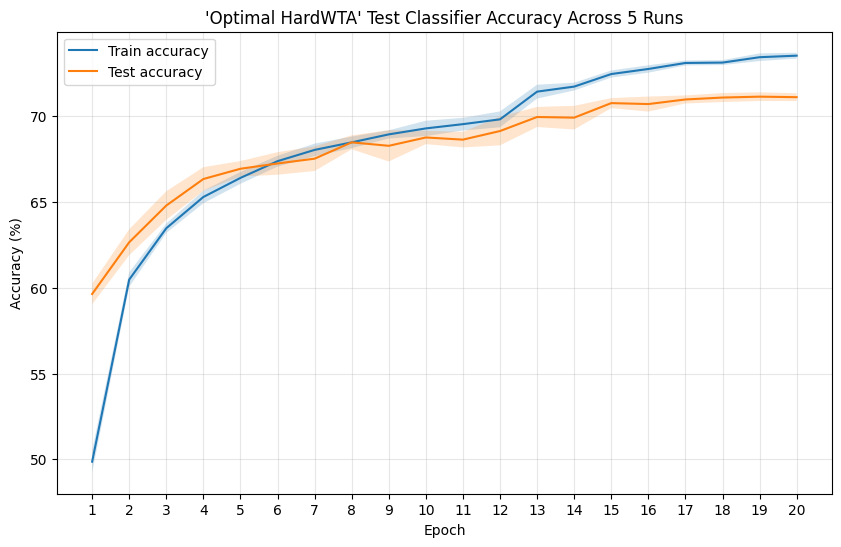

In [37]:
# Mean and standard deviation across the 5 runs
train_mean = train_acc.mean(axis=0)
train_std = train_acc.std(axis=0)

test_mean = test_acc.mean(axis=0)
test_std = test_acc.std(axis=0)

epochs = np.arange(1, 21)

plt.figure(figsize=(10, 6))

plt.plot(epochs, train_mean, label="Train accuracy")
plt.fill_between(
    epochs,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.plot(epochs, test_mean, label="Test accuracy")
plt.fill_between(
    epochs,
    test_mean - test_std,
    test_mean + test_std,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("'Optimal HardWTA' Test Classifier Accuracy Across 5 Runs")
plt.xticks(epochs)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [38]:
print(
    f"Final test accuracy: "
    f"{test_mean[-1]:.2f} ± {test_std[-1]:.2f}%"
)

Final test accuracy: 71.11 ± 0.23%


In [39]:
best_per_run = test_acc.max(axis=1)

print(
    f"Best test accuracy: "
    f"{best_per_run.mean():.2f} ± {best_per_run.std():.2f}%"
)

Best test accuracy: 71.21 ± 0.21%


In [43]:
times = np.array(run_times[1:])
mean_runtime = times.mean()

relevant_peak_mems = np.array(peak_memory[1:]) # exclude the first run as a warm up
mean_peak_memory = relevant_peak_mems.mean()

In [44]:
print(f"Mean max memory allocated: {mean_peak_memory}")
print("All peak memories (including the warm up run):")
peak_memory

Mean max memory allocated: 1646.029296875
All peak memories (including the warm up run):


[1675.13134765625,
 1646.029296875,
 1646.029296875,
 1646.029296875,
 1646.029296875]

In [45]:
print(f"Mean training time for 100 epochs over the 10 runs: {mean_runtime} ")
print(f"All training times for the 100 epochs over the 10 runs:")
times

Mean training time for 100 epochs over the 10 runs: 513.1971224294999 
All training times for the 100 epochs over the 10 runs:


array([512.00005785, 514.39322602, 513.12470096, 513.27050488])

# Slimming down the model to 1-layer (zca is used yet data pre-processing stats are computed from train, and no random flipping present at test time)

Building 1-layer Hebbian model


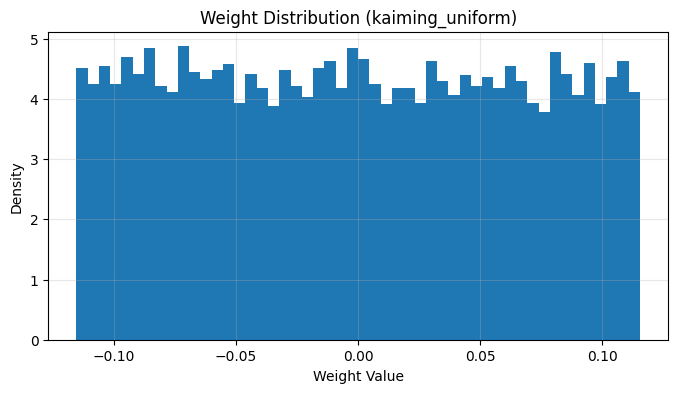

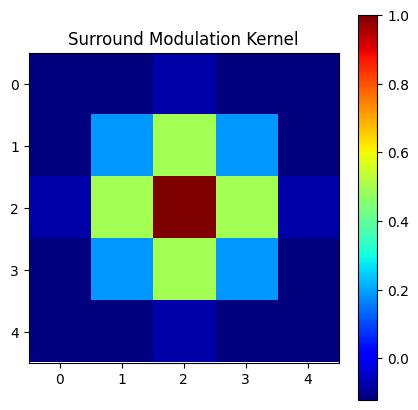

In [11]:
#inspecting model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

hebb_param = get_hebbian_config(version="optimal")

model = Net_Hebbian(
    hebb_params=hebb_param,
    version="one_layer"
).to(device)

In [13]:
for i, layer in enumerate(
    [model.conv1], 1
):
    print(f"\nConv {i}")
    print("mode:", layer.mode)
    print("w_nrm:", layer.w_nrm)
    print("k:", getattr(layer, "k", "not stored"))
    print("alpha:", layer.alpha)
    print("t_invert:", layer.t_invert.item())
    print("lr:", layer.lr)
    print("init:", layer.init_method)
    print("cosine:", layer.use_cosine_similarity)
    print("lateral inhibition:", layer.use_lateral_inhibition)


Conv 1
mode: bcm
w_nrm: False
k: not stored
alpha: 1.0
t_invert: 1
lr: 0.1
init: kaiming_uniform
cosine: True
lateral inhibition: True


In [12]:
for i, layer in enumerate([model.conv1], 1):
    print(
        f"Conv{i}: "
        f"sigma_e={layer.sigma_e}, "
        f"sigma_i={layer.sigma_i}, "
        f"lateral_kernel={layer.lateral_kernel}"
    )

Conv1: sigma_e=1.2, sigma_i=1.3, lateral_kernel=5


In [32]:
print(model)

Net_Hebbian(
  (bn1): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
  (conv1): HebbianConv2d(
    (act): Identity()
  )
  (pool1): MaxPool2d(kernel_size=4, stride=2, padding=1, dilation=1, ceil_mode=False)
  (activ1): Triangle()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=24576, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [33]:

num_parameters = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(f"Parameter count: {num_parameters:,}")

Parameter count: 252,970


# 5 Runs...

RUN 1/ 5 | SEED = 0
Building 1-layer Hebbian model


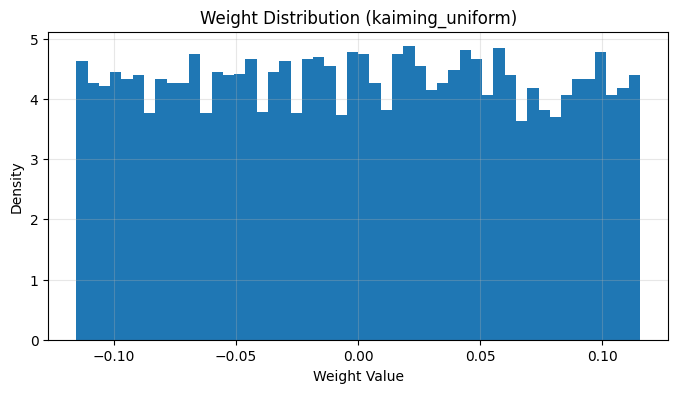

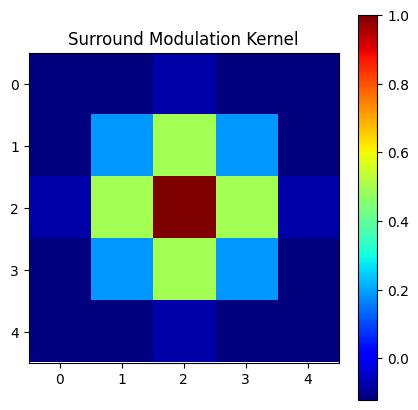

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 10.6826 | Train Acc: 33.28% | Test Loss: 5.7033 | Test Acc: 48.45% | LR: 0.001000
Epoch [2/20] | Train Loss: 8.4840 | Train Acc: 44.00% | Test Loss: 5.6881 | Test Acc: 48.96% | LR: 0.001000
Epoch [3/20] | Train Loss: 7.9210 | Train Acc: 47.12% | Test Loss: 5.2051 | Test Acc: 53.33% | LR: 0.001000
Epoch [4/20] | Train Loss: 7.6733 | Train Acc: 48.65% | Test Loss: 6.4421 | Test Acc: 51.01% | LR: 0.001000
Epoch [5/20] | Train Loss: 7.6724 | Train Acc: 49.74% | Test Loss: 5.8969 | Test Acc: 53.69% | LR: 0.001000
Epoch [6/20] | Train Loss: 7.5330 | Train Acc: 50.62% | Test Loss: 4.9241 | Test Acc: 58.55% | LR: 0.001000
Epoch [7/20] | Train Loss: 7.5613 | Train Acc: 50.77% | Test Loss: 6.1528 | Test Acc: 54.66% | LR: 0.001000
Epoch [8/20] | Train Loss: 7.7298 | Train Acc: 50.87% | Test Loss: 6.6762 | Test Acc: 53.41% | LR: 0.001000
Epoch [9/

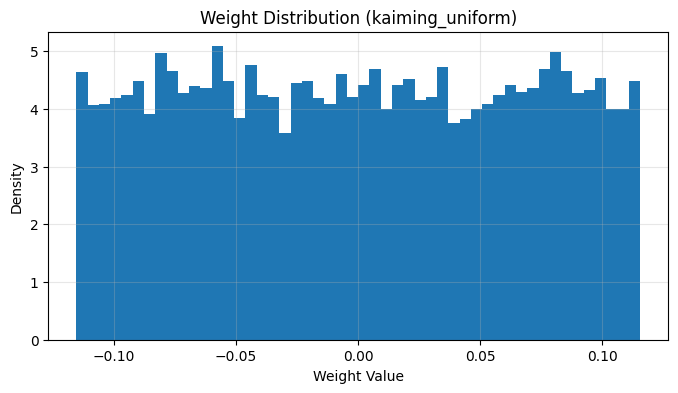

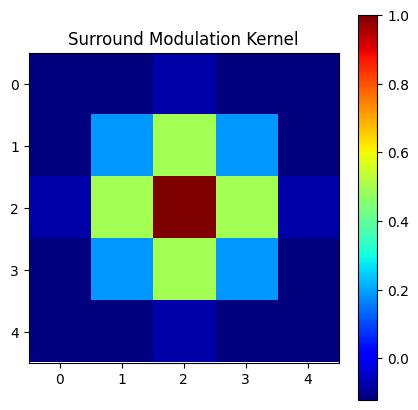

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 10.6415 | Train Acc: 33.58% | Test Loss: 4.9180 | Test Acc: 52.44% | LR: 0.001000
Epoch [2/20] | Train Loss: 8.4361 | Train Acc: 43.89% | Test Loss: 7.7167 | Test Acc: 46.38% | LR: 0.001000
Epoch [3/20] | Train Loss: 7.7162 | Train Acc: 47.50% | Test Loss: 5.2096 | Test Acc: 54.29% | LR: 0.001000
Epoch [4/20] | Train Loss: 7.7601 | Train Acc: 48.61% | Test Loss: 8.9288 | Test Acc: 43.98% | LR: 0.001000
Epoch [5/20] | Train Loss: 7.6566 | Train Acc: 49.72% | Test Loss: 6.2256 | Test Acc: 52.74% | LR: 0.001000
Epoch [6/20] | Train Loss: 7.5302 | Train Acc: 50.52% | Test Loss: 7.1458 | Test Acc: 51.24% | LR: 0.001000
Epoch [7/20] | Train Loss: 7.5908 | Train Acc: 51.23% | Test Loss: 6.1801 | Test Acc: 54.39% | LR: 0.001000
Epoch [8/20] | Train Loss: 7.5595 | Train Acc: 51.56% | Test Loss: 5.7669 | Test Acc: 55.72% | LR: 0.001000
Epoch [9/

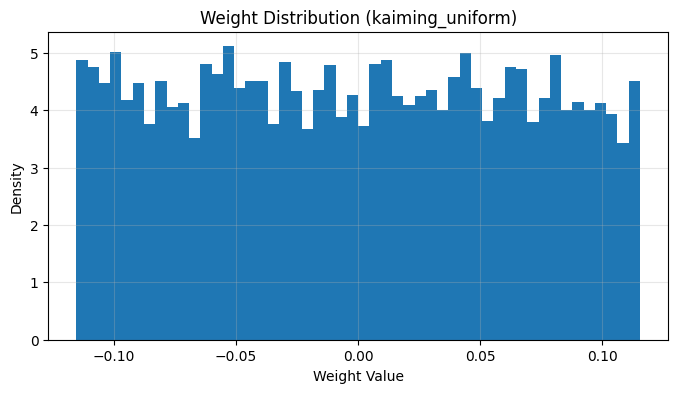

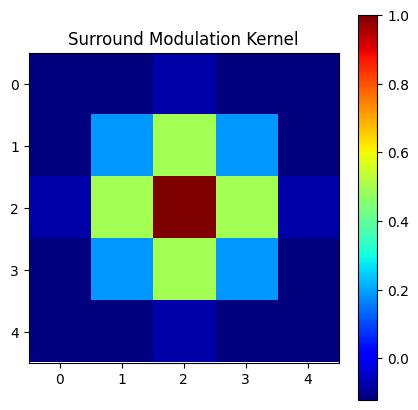

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 10.4615 | Train Acc: 34.22% | Test Loss: 7.4898 | Test Acc: 44.58% | LR: 0.001000
Epoch [2/20] | Train Loss: 8.2769 | Train Acc: 44.87% | Test Loss: 6.7452 | Test Acc: 46.47% | LR: 0.001000
Epoch [3/20] | Train Loss: 7.8874 | Train Acc: 47.38% | Test Loss: 7.5062 | Test Acc: 48.47% | LR: 0.001000
Epoch [4/20] | Train Loss: 7.7324 | Train Acc: 49.21% | Test Loss: 7.1651 | Test Acc: 50.85% | LR: 0.001000
Epoch [5/20] | Train Loss: 7.8904 | Train Acc: 50.18% | Test Loss: 6.1705 | Test Acc: 54.45% | LR: 0.001000
Epoch [6/20] | Train Loss: 7.8030 | Train Acc: 50.66% | Test Loss: 4.8074 | Test Acc: 58.06% | LR: 0.001000
Epoch [7/20] | Train Loss: 7.6966 | Train Acc: 51.36% | Test Loss: 7.0035 | Test Acc: 51.43% | LR: 0.001000
Epoch [8/20] | Train Loss: 7.8735 | Train Acc: 51.64% | Test Loss: 5.6497 | Test Acc: 57.24% | LR: 0.001000
Epoch [9/

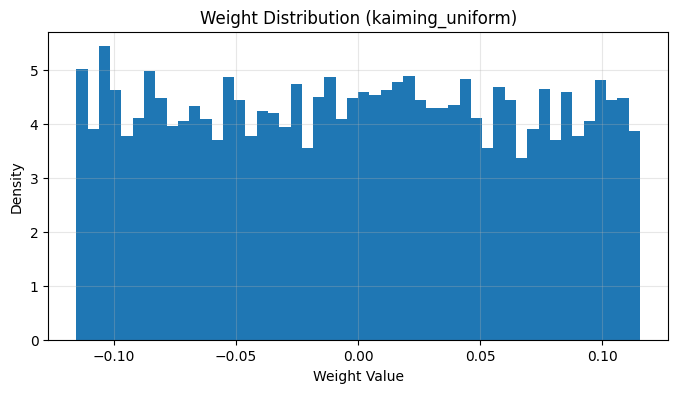

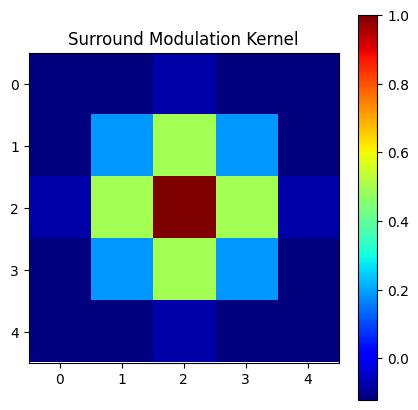

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 10.6011 | Train Acc: 33.91% | Test Loss: 4.4395 | Test Acc: 55.25% | LR: 0.001000
Epoch [2/20] | Train Loss: 8.2917 | Train Acc: 44.59% | Test Loss: 5.5364 | Test Acc: 51.41% | LR: 0.001000
Epoch [3/20] | Train Loss: 8.0123 | Train Acc: 47.53% | Test Loss: 7.2320 | Test Acc: 47.42% | LR: 0.001000
Epoch [4/20] | Train Loss: 7.8909 | Train Acc: 48.76% | Test Loss: 7.2346 | Test Acc: 50.89% | LR: 0.001000
Epoch [5/20] | Train Loss: 7.7940 | Train Acc: 49.56% | Test Loss: 7.5133 | Test Acc: 52.20% | LR: 0.001000
Epoch [6/20] | Train Loss: 7.5346 | Train Acc: 51.04% | Test Loss: 8.5050 | Test Acc: 45.65% | LR: 0.001000
Epoch [7/20] | Train Loss: 8.0230 | Train Acc: 50.67% | Test Loss: 5.1912 | Test Acc: 57.17% | LR: 0.001000
Epoch [8/20] | Train Loss: 7.3651 | Train Acc: 52.31% | Test Loss: 7.6257 | Test Acc: 49.44% | LR: 0.001000
Epoch [9/

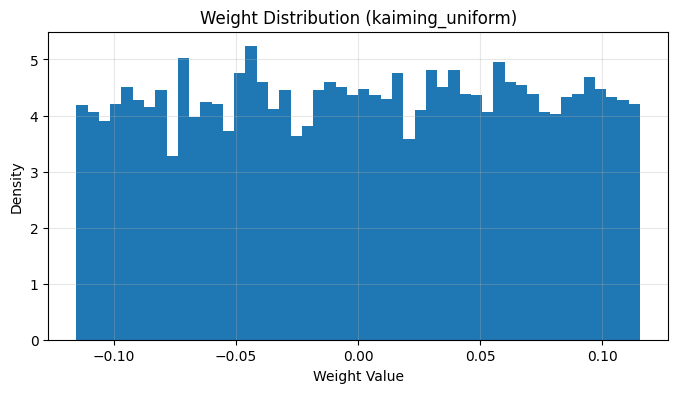

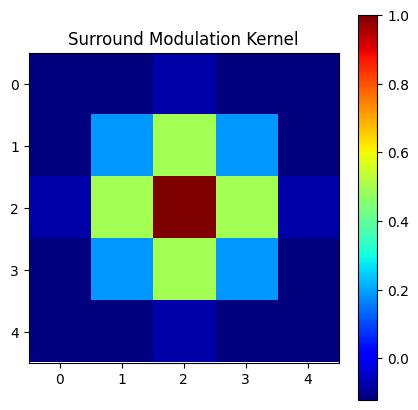

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 10.6609 | Train Acc: 33.55% | Test Loss: 7.3850 | Test Acc: 41.66% | LR: 0.001000
Epoch [2/20] | Train Loss: 8.5067 | Train Acc: 43.86% | Test Loss: 4.6846 | Test Acc: 55.18% | LR: 0.001000
Epoch [3/20] | Train Loss: 7.9428 | Train Acc: 47.46% | Test Loss: 5.3909 | Test Acc: 53.87% | LR: 0.001000
Epoch [4/20] | Train Loss: 8.0114 | Train Acc: 48.33% | Test Loss: 10.2202 | Test Acc: 46.19% | LR: 0.001000
Epoch [5/20] | Train Loss: 7.8888 | Train Acc: 49.63% | Test Loss: 8.4452 | Test Acc: 46.31% | LR: 0.001000
Epoch [6/20] | Train Loss: 7.7676 | Train Acc: 50.44% | Test Loss: 4.6414 | Test Acc: 57.80% | LR: 0.001000
Epoch [7/20] | Train Loss: 7.4735 | Train Acc: 51.68% | Test Loss: 6.8048 | Test Acc: 49.79% | LR: 0.001000
Epoch [8/20] | Train Loss: 7.5084 | Train Acc: 51.75% | Test Loss: 5.2478 | Test Acc: 56.33% | LR: 0.001000
Epoch [9

In [ ]:
zca.mean = zca.mean.to(device)
zca.std = zca.std.to(device)
zca.zca_matrix = zca.zca_matrix.to(device)

for seed in seeds:

    print(f"RUN {seed + 1}/ {len(seeds)} | SEED = {seed}")

    set_seed(seed)
    
    # Generator specifically for this run
    g = torch.Generator()
    g.manual_seed(seed)


    train_loader = DataLoader(
        train_dataset,
        batch_size=64,
        shuffle=True,
        num_workers=2,
        worker_init_fn=seed_worker,
        generator=g
    )

    #use the valid test dataset (no augmentation other than scaling using zca stats from training data)
    test_loader = DataLoader(
    valid_test_dataset,
    batch_size=64,
    shuffle=False, 
    num_workers=2,
    worker_init_fn=seed_worker,
    generator=g
)


    #fresh model

    hebb_param = get_hebbian_config(version="optimal")

    model = Net_Hebbian(
        hebb_params=hebb_param,
        version="one_layer"
    ).to(device)


    # hebbian feature learning ('Unsupervised Feature Learning Phase' trained for 1 epoch)
    model.train()

    for epoch in range(1):

        print(f"Hebbian epoch {epoch + 1}")

        for i, (inputs, _) in enumerate(train_loader):

            inputs = inputs.to(device)

            inputs = zca.transform(inputs)

            
            with torch.no_grad():
                model(inputs)

            #for layer in [model.conv1]:
                #layer.local_update()
            model.conv1.local_update()

            if i % 100 == 0:
                print(f"Batch {i}/{len(train_loader)}")
                

    # freeze the hebbian feature extractor as now to train classifier

    for module in [
        model.conv1,
        model.bn1,
      
    ]:

        for param in module.parameters():
            param.requires_grad = False

        module.eval()

    #optimiser and schedular as defined in experiment_hebbian.py
    sup_optimizer = torch.optim.Adam(
        model.fc1.parameters(),
        lr=0.001
    )

    scheduler = torch.optim.lr_scheduler.LambdaLR(
        sup_optimizer,
        lr_lambda=lambda epoch:
            0.5 ** max(0, (epoch - 10) // 2)
    )

    criterion = nn.CrossEntropyLoss()


    classifier_history = {
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": []
    }

    #train classier for 20 epochs

    for epoch in range(20):
        model.conv1.eval()

        model.bn1.eval()


        model.fc1.train()
        model.dropout.train()

        running_loss = 0.0
        correct = 0
        total = 0


        for inputs, labels in train_loader:

            inputs = inputs.to(device)

            inputs = zca.transform(inputs)

            labels = labels.to(device)

            sup_optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            loss.backward()

            sup_optimizer.step()

            running_loss += loss.item() * labels.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_accuracy = 100 * correct / total

        #get the evaluation results on the test set

        model.eval()

        test_running_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():

            for inputs, labels in test_loader:

                inputs = inputs.to(device)
                
                inputs = zca.transform(inputs)

                labels = labels.to(device)

                outputs = model(inputs)

                loss = criterion(outputs, labels)

                test_running_loss += loss.item() * labels.size(0)

                _, predicted = torch.max(outputs, 1)

                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()

        test_loss = test_running_loss / test_total
        test_accuracy = 100 * test_correct / test_total


        classifier_history["train_loss"].append(train_loss)
        classifier_history["train_accuracy"].append(train_accuracy)

        classifier_history["test_loss"].append(test_loss)
        classifier_history["test_accuracy"].append(test_accuracy)

        #update the scheduler
        scheduler.step()

        current_lr = sup_optimizer.param_groups[0]["lr"]

        print(
            f"Epoch [{epoch + 1}/20] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_accuracy:.2f}% | "
            f"LR: {current_lr:.6f}"
        )

    # Save this run's history
    all_histories[seed] = classifier_history

In [40]:
train_acc = np.array([
    all_histories[seed]["train_accuracy"]
    for seed in seeds
])

test_acc = np.array([
    all_histories[seed]["test_accuracy"]
    for seed in seeds
])

In [41]:
train_acc_df=pd.DataFrame(train_acc)

In [42]:
test_acc_df=pd.DataFrame(test_acc)


In [43]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [44]:
train_acc_df.to_csv("/content/drive/MyDrive/research_jobs/fixed_stats_no_test_flips_hebbian_1_layer_train_acc_.csv",index=False)

In [45]:
test_acc_df.to_csv("/content/drive/MyDrive/research_jobs/fixed_stats_no_test_flips_hebbian_1_layer_test_acc_.csv",index=False)


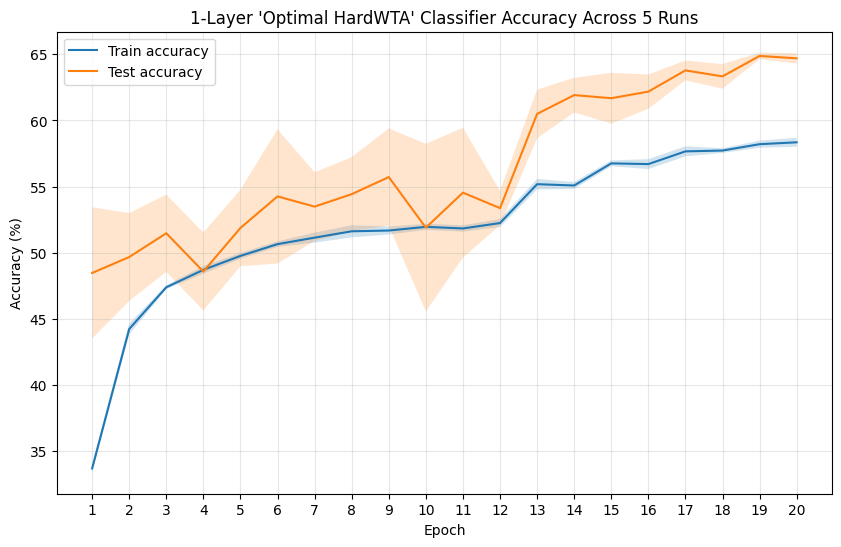

In [46]:
# Mean and standard deviation across the 5 runs
train_mean = train_acc.mean(axis=0)
train_std = train_acc.std(axis=0)

test_mean = test_acc.mean(axis=0)
test_std = test_acc.std(axis=0)

epochs = np.arange(1, 21)

plt.figure(figsize=(10, 6))

plt.plot(epochs, train_mean, label="Train accuracy")
plt.fill_between(
    epochs,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.plot(epochs, test_mean, label="Test accuracy")
plt.fill_between(
    epochs,
    test_mean - test_std,
    test_mean + test_std,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("1-Layer 'Optimal HardWTA' Classifier Accuracy Across 5 Runs")
plt.xticks(epochs)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [47]:
print(
    f"Final test accuracy: "
    f"{test_mean[-1]:.2f} ± {test_std[-1]:.2f}%"
)

Final test accuracy: 64.69 ± 0.39%


In [ ]:
best_per_run = test_acc.max(axis=1)

print(
    f"Best test accuracy: "
    f"{best_per_run.mean():.2f} ± {best_per_run.std():.2f}%"
)

Best test accuracy: 64.93 ± 0.32%


 # Removing the whitening and random flipping such that we may compare to our previous GD models

In [22]:
final_transform = transforms.Compose([
    transforms.ToTensor(),
])

In [23]:
train_dataset = datasets.ImageFolder(
    root=cifar_train_path,
    transform=final_transform
)

#oddly the researchers use random horizontal flipping on the test set (in addition to the train)
test_dataset = datasets.ImageFolder(
    root=cifar_test_path,
    transform=final_transform
)

In [28]:
seeds = [0, 1, 2, 3, 4]
all_histories = {}

In [24]:
import time

RUN 1/5 | SEED = 0
Building 1-layer Hebbian model


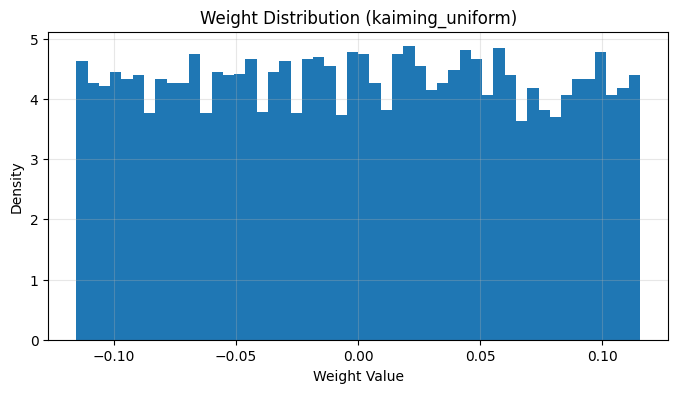

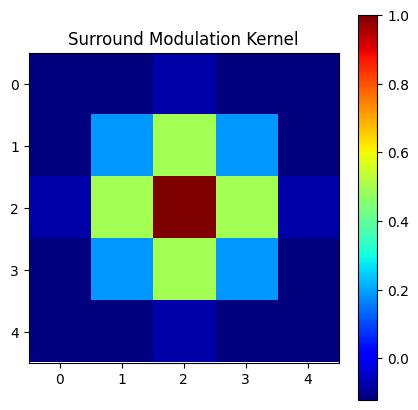

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 10.5518 | Train Acc: 33.09% | Test Loss: 4.8063 | Test Acc: 49.86% | LR: 0.001000
Epoch [2/20] | Train Loss: 8.6458 | Train Acc: 40.24% | Test Loss: 6.1307 | Test Acc: 45.07% | LR: 0.001000
Epoch [3/20] | Train Loss: 7.9181 | Train Acc: 42.96% | Test Loss: 5.0092 | Test Acc: 49.32% | LR: 0.001000
Epoch [4/20] | Train Loss: 8.0507 | Train Acc: 44.18% | Test Loss: 4.7261 | Test Acc: 53.15% | LR: 0.001000
Epoch [5/20] | Train Loss: 7.6624 | Train Acc: 45.56% | Test Loss: 4.8553 | Test Acc: 54.32% | LR: 0.001000
Epoch [6/20] | Train Loss: 7.7114 | Train Acc: 45.67% | Test Loss: 6.9471 | Test Acc: 46.09% | LR: 0.001000
Epoch [7/20] | Train Loss: 7.5482 | Train Acc: 46.77% | Test Loss: 4.9161 | Test Acc: 54.24% | LR: 0.001000
Epoch [8/20] | Train Loss: 7.6500 | Train Acc: 46.53% | Test Loss: 6.7080 | Test Acc: 50.37% | LR: 0.001000
Epoch [9/

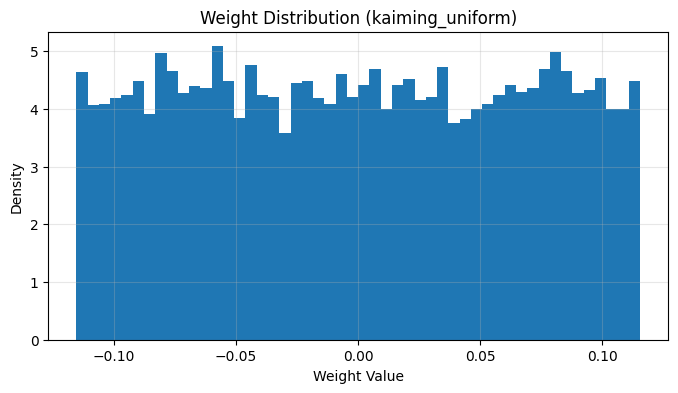

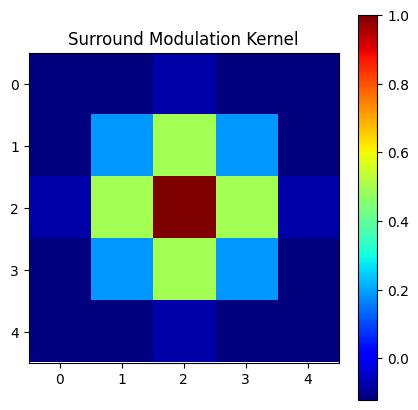

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 10.7518 | Train Acc: 32.54% | Test Loss: 6.2492 | Test Acc: 45.33% | LR: 0.001000
Epoch [2/20] | Train Loss: 8.7861 | Train Acc: 40.09% | Test Loss: 6.2716 | Test Acc: 47.05% | LR: 0.001000
Epoch [3/20] | Train Loss: 8.1867 | Train Acc: 42.72% | Test Loss: 5.7961 | Test Acc: 46.60% | LR: 0.001000
Epoch [4/20] | Train Loss: 8.1640 | Train Acc: 43.62% | Test Loss: 6.0471 | Test Acc: 47.81% | LR: 0.001000
Epoch [5/20] | Train Loss: 7.9406 | Train Acc: 45.26% | Test Loss: 5.0298 | Test Acc: 51.62% | LR: 0.001000
Epoch [6/20] | Train Loss: 7.9446 | Train Acc: 45.29% | Test Loss: 6.0862 | Test Acc: 49.15% | LR: 0.001000
Epoch [7/20] | Train Loss: 7.8516 | Train Acc: 45.72% | Test Loss: 6.7822 | Test Acc: 46.81% | LR: 0.001000
Epoch [8/20] | Train Loss: 7.8723 | Train Acc: 46.39% | Test Loss: 6.1747 | Test Acc: 49.17% | LR: 0.001000
Epoch [9/

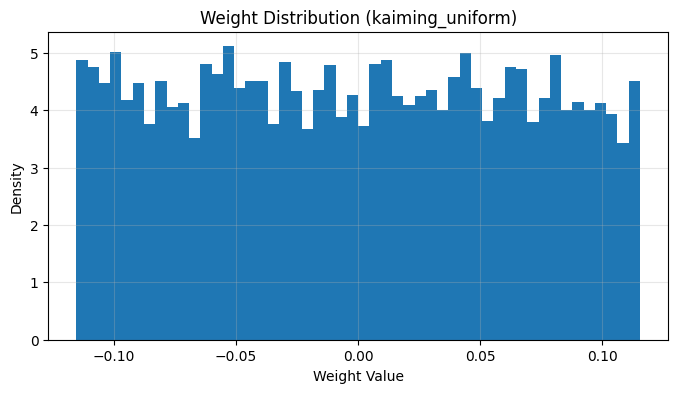

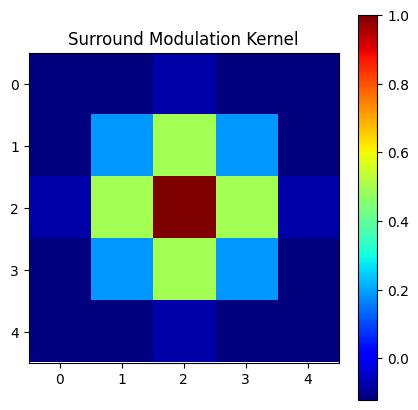

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 11.3014 | Train Acc: 32.77% | Test Loss: 7.7096 | Test Acc: 41.72% | LR: 0.001000
Epoch [2/20] | Train Loss: 9.2131 | Train Acc: 40.21% | Test Loss: 6.1801 | Test Acc: 46.77% | LR: 0.001000
Epoch [3/20] | Train Loss: 8.6354 | Train Acc: 42.50% | Test Loss: 6.2589 | Test Acc: 47.65% | LR: 0.001000
Epoch [4/20] | Train Loss: 8.3332 | Train Acc: 44.11% | Test Loss: 6.9093 | Test Acc: 46.53% | LR: 0.001000
Epoch [5/20] | Train Loss: 8.2930 | Train Acc: 44.65% | Test Loss: 4.9718 | Test Acc: 53.82% | LR: 0.001000
Epoch [6/20] | Train Loss: 8.1371 | Train Acc: 45.82% | Test Loss: 6.1325 | Test Acc: 49.29% | LR: 0.001000
Epoch [7/20] | Train Loss: 8.2074 | Train Acc: 45.92% | Test Loss: 4.8673 | Test Acc: 54.29% | LR: 0.001000
Epoch [8/20] | Train Loss: 8.0836 | Train Acc: 46.40% | Test Loss: 6.4834 | Test Acc: 49.11% | LR: 0.001000
Epoch [9/

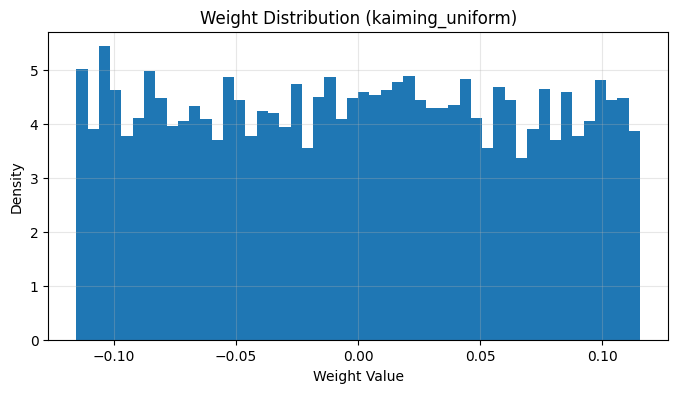

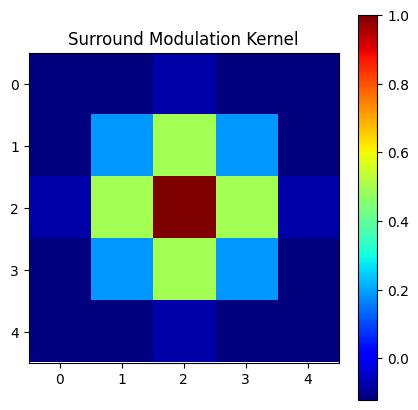

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 11.0583 | Train Acc: 32.64% | Test Loss: 6.7821 | Test Acc: 45.54% | LR: 0.001000
Epoch [2/20] | Train Loss: 8.9751 | Train Acc: 40.20% | Test Loss: 5.4875 | Test Acc: 50.59% | LR: 0.001000
Epoch [3/20] | Train Loss: 8.4321 | Train Acc: 42.66% | Test Loss: 8.1838 | Test Acc: 43.03% | LR: 0.001000
Epoch [4/20] | Train Loss: 8.3767 | Train Acc: 43.80% | Test Loss: 7.6557 | Test Acc: 46.83% | LR: 0.001000
Epoch [5/20] | Train Loss: 8.1870 | Train Acc: 45.14% | Test Loss: 6.3677 | Test Acc: 48.13% | LR: 0.001000
Epoch [6/20] | Train Loss: 8.1976 | Train Acc: 45.26% | Test Loss: 8.3807 | Test Acc: 44.14% | LR: 0.001000
Epoch [7/20] | Train Loss: 8.0919 | Train Acc: 45.91% | Test Loss: 4.9013 | Test Acc: 53.82% | LR: 0.001000
Epoch [8/20] | Train Loss: 8.0397 | Train Acc: 46.81% | Test Loss: 5.1516 | Test Acc: 53.83% | LR: 0.001000
Epoch [9/

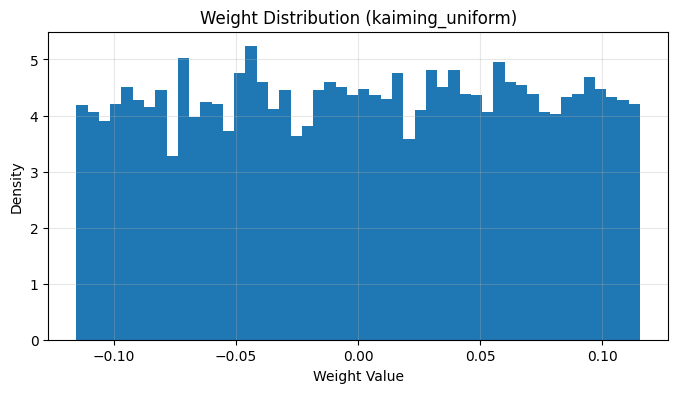

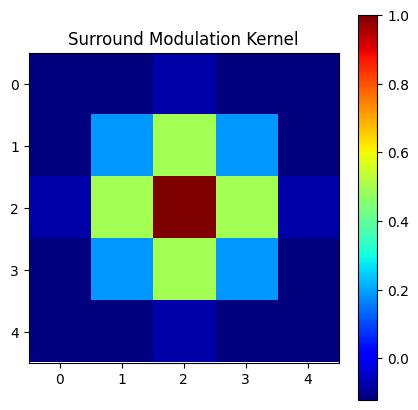

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 11.3740 | Train Acc: 32.34% | Test Loss: 7.1938 | Test Acc: 42.27% | LR: 0.001000
Epoch [2/20] | Train Loss: 9.3890 | Train Acc: 39.28% | Test Loss: 6.6447 | Test Acc: 46.87% | LR: 0.001000
Epoch [3/20] | Train Loss: 8.6450 | Train Acc: 42.03% | Test Loss: 4.8527 | Test Acc: 52.76% | LR: 0.001000
Epoch [4/20] | Train Loss: 8.4790 | Train Acc: 43.59% | Test Loss: 7.9154 | Test Acc: 44.94% | LR: 0.001000
Epoch [5/20] | Train Loss: 8.4561 | Train Acc: 44.13% | Test Loss: 5.3245 | Test Acc: 50.32% | LR: 0.001000
Epoch [6/20] | Train Loss: 8.5273 | Train Acc: 44.72% | Test Loss: 5.6861 | Test Acc: 51.06% | LR: 0.001000
Epoch [7/20] | Train Loss: 8.2496 | Train Acc: 45.49% | Test Loss: 6.6144 | Test Acc: 51.17% | LR: 0.001000
Epoch [8/20] | Train Loss: 8.3089 | Train Acc: 45.78% | Test Loss: 4.7092 | Test Acc: 53.97% | LR: 0.001000
Epoch [9/

In [33]:
peak_memory =[]
run_times= []

for seed in seeds:

    print(f"RUN {seed + 1}/5 | SEED = {seed}")
   
    set_seed(seed)

    # Generator specifically for this run
    g = torch.Generator()
    g.manual_seed(seed)

    #starting time from data loading
    start = time.perf_counter()

    train_loader = DataLoader(
        train_dataset,
        batch_size=64,
        shuffle=True,
        num_workers=2,
        worker_init_fn=seed_worker,
        generator=g
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=64,
        shuffle=False, #researchers have test data shuffled, but this is again unecessary, since no learning is occuring (eval only)
        num_workers=2,
        worker_init_fn=seed_worker,
        generator=g
    )

    #fresh model for every seed

    hebb_param = get_hebbian_config(version="optimal")

    model = Net_Hebbian(
        hebb_params=hebb_param,
        version="one_layer"
    ).to(device)


    # hebbian feature learning ('Unsupervised Feature Learning Phase' trained for 1 epoch)
    model.train()

    for epoch in range(1):

        print(f"Hebbian epoch {epoch + 1}")

        for i, (inputs, _) in enumerate(train_loader):

            inputs = inputs.to(device)

            with torch.no_grad():
                model(inputs)

            model.conv1.local_update()

            if i % 100 == 0:
                print(f"Batch {i}/{len(train_loader)}")
                

    # freeze the hebbian feature extractor as now to train classifier

    for module in [
        model.conv1,
        model.bn1,
    ]:

        for param in module.parameters():
            param.requires_grad = False

        module.eval()

    #optimiser and schedular as defined in experiment_hebbian.py
    sup_optimizer = torch.optim.Adam(
        model.fc1.parameters(),
        lr=0.001
    )

    scheduler = torch.optim.lr_scheduler.LambdaLR(
        sup_optimizer,
        lr_lambda=lambda epoch:
            0.5 ** max(0, (epoch - 10) // 2)
    )

    criterion = nn.CrossEntropyLoss()

    classifier_history = {
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": []
    }

    #train classier for 20 epochs

    for epoch in range(20):
        model.conv1.eval()
        model.bn1.eval()


        model.fc1.train()
        model.dropout.train()

        running_loss = 0.0
        correct = 0
        total = 0


        for inputs, labels in train_loader:

            inputs = inputs.to(device)

            labels = labels.to(device)

            sup_optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            loss.backward()

            sup_optimizer.step()

            running_loss += loss.item() * labels.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_accuracy = 100 * correct / total

        #get the evaluation results on the test set

        model.eval()

        test_running_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():

            for inputs, labels in test_loader:

                inputs = inputs.to(device)
  

                labels = labels.to(device)

                outputs = model(inputs)

                loss = criterion(outputs, labels)

                test_running_loss += loss.item() * labels.size(0)

                _, predicted = torch.max(outputs, 1)

                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()

        test_loss = test_running_loss / test_total
        test_accuracy = 100 * test_correct / test_total


        classifier_history["train_loss"].append(train_loss)
        classifier_history["train_accuracy"].append(train_accuracy)

        classifier_history["test_loss"].append(test_loss)
        classifier_history["test_accuracy"].append(test_accuracy)

        #update the scheduler
        scheduler.step()

        current_lr = sup_optimizer.param_groups[0]["lr"]

        print(
            f"Epoch [{epoch + 1}/20] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_accuracy:.2f}% | "
            f"LR: {current_lr:.6f}"
        )


    peak = torch.cuda.max_memory_allocated()
    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)

    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")


    elapsed = time.perf_counter() - start
    print(f"train time: {elapsed}")

    run_times.append(elapsed)

    # save each runs history
    all_histories[seed] = classifier_history

# save results and visualise

In [34]:
# Shape: (5 runs, 20 epochs)
train_acc = np.array([
    all_histories[seed]["train_accuracy"]
    for seed in seeds
])

test_acc = np.array([
    all_histories[seed]["test_accuracy"]
    for seed in seeds
])

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [36]:
train_acc_df=pd.DataFrame(train_acc)

In [37]:
test_acc_df=pd.DataFrame(test_acc)


In [38]:
train_acc_df.to_csv("/content/drive/MyDrive/research_jobs/hebbian_1_layer_minimal_transforms_train_acc_.csv",index=False)

In [39]:
test_acc_df.to_csv("/content/drive/MyDrive/research_jobs/hebbian_1_layer_minimal_transforms_test_acc_.csv",index=False)


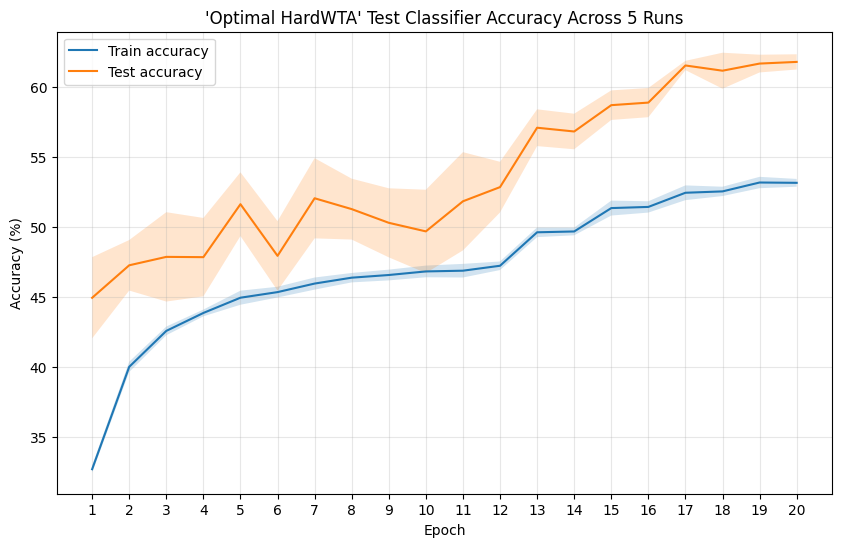

In [40]:
# Mean and standard deviation across the 5 runs
train_mean = train_acc.mean(axis=0)
train_std = train_acc.std(axis=0)

test_mean = test_acc.mean(axis=0)
test_std = test_acc.std(axis=0)

epochs = np.arange(1, 21)

plt.figure(figsize=(10, 6))

plt.plot(epochs, train_mean, label="Train accuracy")
plt.fill_between(
    epochs,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.plot(epochs, test_mean, label="Test accuracy")
plt.fill_between(
    epochs,
    test_mean - test_std,
    test_mean + test_std,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("'Optimal HardWTA' Test Classifier Accuracy Across 5 Runs")
plt.xticks(epochs)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [41]:
print(
    f"Final test accuracy: "
    f"{test_mean[-1]:.2f} ± {test_std[-1]:.2f}%"
)

Final test accuracy: 61.82 ± 0.54%


In [42]:
best_per_run = test_acc.max(axis=1)

print(
    f"Best test accuracy: "
    f"{best_per_run.mean():.2f} ± {best_per_run.std():.2f}%"
)

Best test accuracy: 62.10 ± 0.39%


In [43]:
times = np.array(run_times[1:])
mean_runtime = times.mean()

relevant_peak_mems = np.array(peak_memory[1:]) # exclude the first run as a warm up
mean_peak_memory = relevant_peak_mems.mean()

In [44]:
print(f"Mean max memory allocated: {mean_peak_memory}")
print("All peak memories (including the warm up run):")
peak_memory

Mean max memory allocated: 224.68310546875
All peak memories (including the warm up run):


[224.6845703125,
 224.68310546875,
 224.68310546875,
 224.68310546875,
 224.68310546875]

In [45]:
print(f"Mean training time for 100 epochs over the 10 runs: {mean_runtime} ")
print(f"All training times for the 100 epochs over the 10 runs:")
times

Mean training time for 100 epochs over the 10 runs: 381.799701658 
All training times for the 100 epochs over the 10 runs:


array([381.33360755, 380.69937955, 384.45016429, 380.71565524])

# Running the model with 16 filters without dropout (the same as our GD models) (optimal bcm parameters for the first layer for Cifar-10 are kept as specified within the paper)

Building 1-layer Hebbian model


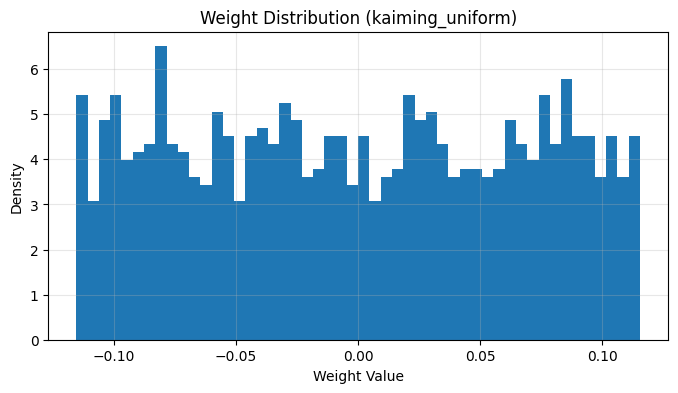

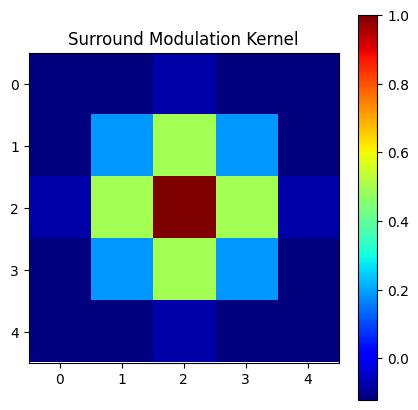

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

hebb_param = get_hebbian_config(version="optimal")

model = Net_Hebbian(
    hebb_params=hebb_param,
    version="one_layer_reduced"
).to(device)

In [22]:
model

Net_Hebbian(
  (bn1): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
  (conv1): HebbianConv2d(
    (act): Identity()
  )
  (pool1): MaxPool2d(kernel_size=4, stride=2, padding=1, dilation=1, ceil_mode=False)
  (activ1): Triangle()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=4096, out_features=10, bias=True)
)

In [26]:
num_parameters = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(f"Parameter count: {num_parameters:,}")

Parameter count: 42,170


In [27]:
seeds = [0, 1, 2, 3, 4]
all_histories = {}

RUN 1/5 | SEED = 0
Building 1-layer Hebbian model


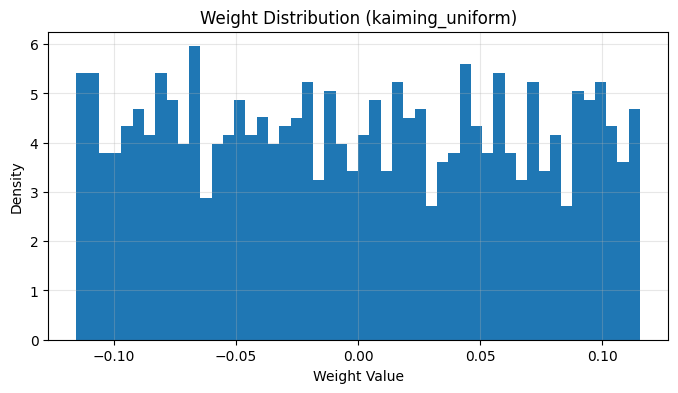

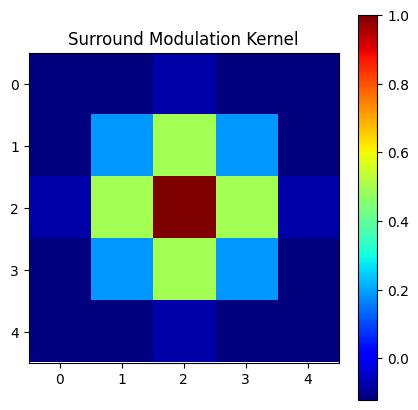

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/30] | Train Loss: 2.6403 | Train Acc: 33.49% | Test Loss: 2.4494 | Test Acc: 37.03% | LR: 0.001000
Epoch [2/30] | Train Loss: 2.2369 | Train Acc: 40.06% | Test Loss: 2.5740 | Test Acc: 35.51% | LR: 0.001000
Epoch [3/30] | Train Loss: 2.1232 | Train Acc: 42.35% | Test Loss: 1.9534 | Test Acc: 45.21% | LR: 0.001000
Epoch [4/30] | Train Loss: 2.1023 | Train Acc: 43.45% | Test Loss: 2.2400 | Test Acc: 41.15% | LR: 0.001000
Epoch [5/30] | Train Loss: 2.0431 | Train Acc: 44.43% | Test Loss: 2.1101 | Test Acc: 44.14% | LR: 0.001000
Epoch [6/30] | Train Loss: 2.0689 | Train Acc: 44.58% | Test Loss: 2.3875 | Test Acc: 40.36% | LR: 0.001000
Epoch [7/30] | Train Loss: 2.0053 | Train Acc: 45.31% | Test Loss: 2.1310 | Test Acc: 43.20% | LR: 0.001000
Epoch [8/30] | Train Loss: 1.9906 | Train Acc: 46.19% | Test Loss: 1.9722 | Test Acc: 44.90% | LR: 0.001000
Epoch [9/3

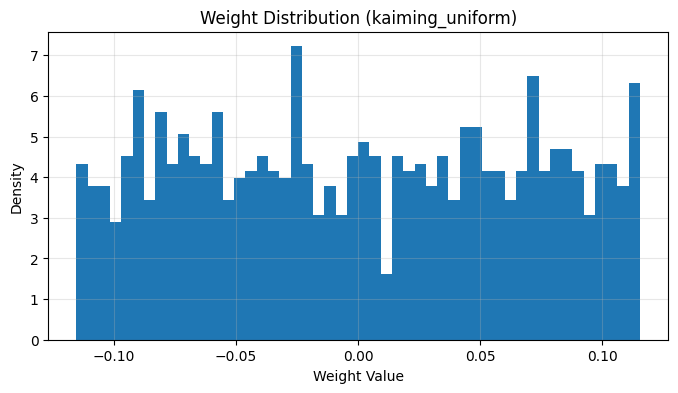

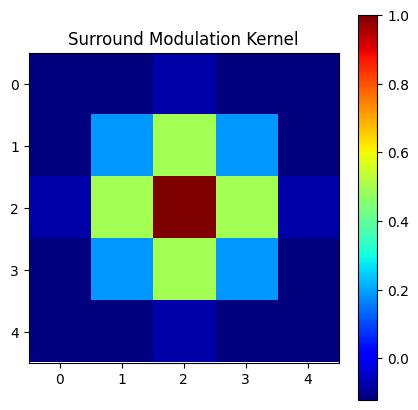

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/30] | Train Loss: 2.5559 | Train Acc: 36.13% | Test Loss: 2.3577 | Test Acc: 38.56% | LR: 0.001000
Epoch [2/30] | Train Loss: 2.1213 | Train Acc: 42.57% | Test Loss: 1.9925 | Test Acc: 43.09% | LR: 0.001000
Epoch [3/30] | Train Loss: 2.0254 | Train Acc: 44.63% | Test Loss: 2.1491 | Test Acc: 41.66% | LR: 0.001000
Epoch [4/30] | Train Loss: 1.9599 | Train Acc: 45.83% | Test Loss: 2.0012 | Test Acc: 44.34% | LR: 0.001000
Epoch [5/30] | Train Loss: 1.9878 | Train Acc: 46.28% | Test Loss: 2.1959 | Test Acc: 41.81% | LR: 0.001000
Epoch [6/30] | Train Loss: 1.9094 | Train Acc: 47.33% | Test Loss: 2.3677 | Test Acc: 41.46% | LR: 0.001000
Epoch [7/30] | Train Loss: 1.8644 | Train Acc: 48.01% | Test Loss: 2.3570 | Test Acc: 41.94% | LR: 0.001000
Epoch [8/30] | Train Loss: 1.8993 | Train Acc: 47.98% | Test Loss: 2.5520 | Test Acc: 41.73% | LR: 0.001000
Epoch [9/3

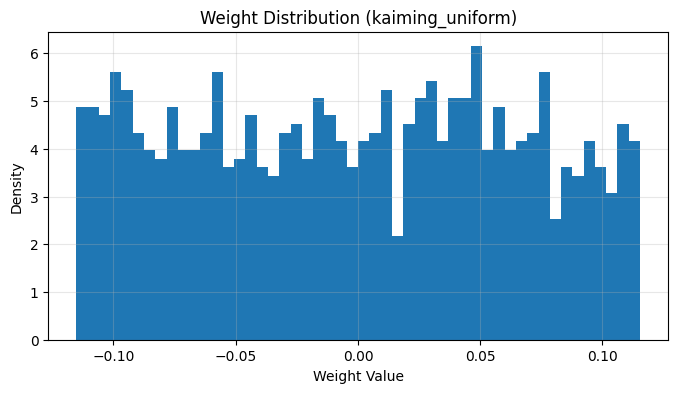

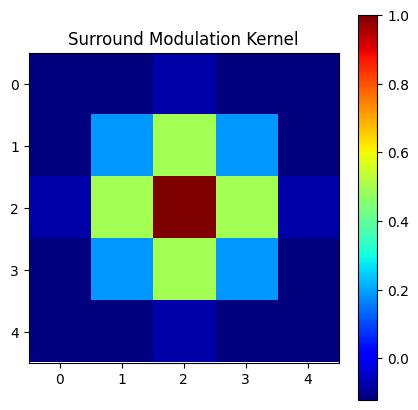

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/30] | Train Loss: 2.5313 | Train Acc: 35.60% | Test Loss: 2.4475 | Test Acc: 39.03% | LR: 0.001000
Epoch [2/30] | Train Loss: 2.0086 | Train Acc: 42.62% | Test Loss: 2.9328 | Test Acc: 34.43% | LR: 0.001000
Epoch [3/30] | Train Loss: 1.9922 | Train Acc: 44.24% | Test Loss: 2.1881 | Test Acc: 41.33% | LR: 0.001000
Epoch [4/30] | Train Loss: 1.9236 | Train Acc: 45.55% | Test Loss: 2.0298 | Test Acc: 43.94% | LR: 0.001000
Epoch [5/30] | Train Loss: 1.8549 | Train Acc: 46.58% | Test Loss: 2.2760 | Test Acc: 42.98% | LR: 0.001000
Epoch [6/30] | Train Loss: 1.8556 | Train Acc: 47.35% | Test Loss: 2.1064 | Test Acc: 44.18% | LR: 0.001000
Epoch [7/30] | Train Loss: 1.8291 | Train Acc: 47.83% | Test Loss: 1.9390 | Test Acc: 46.68% | LR: 0.001000
Epoch [8/30] | Train Loss: 1.8144 | Train Acc: 48.27% | Test Loss: 1.8095 | Test Acc: 47.51% | LR: 0.001000
Epoch [9/3

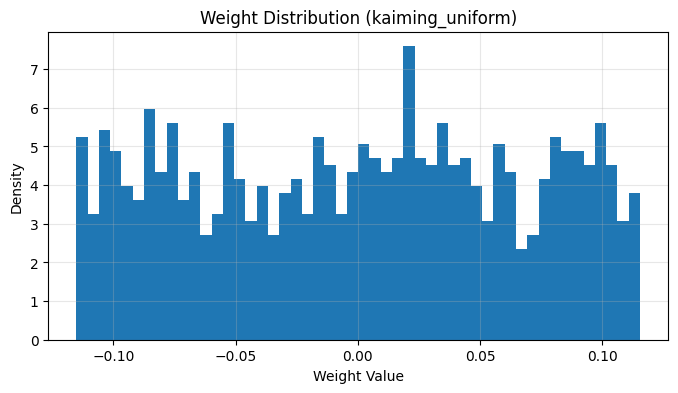

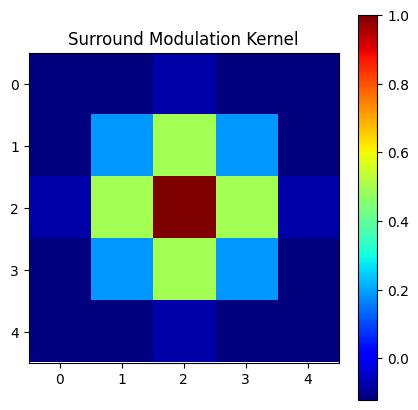

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/30] | Train Loss: 2.5574 | Train Acc: 35.33% | Test Loss: 2.3448 | Test Acc: 38.59% | LR: 0.001000
Epoch [2/30] | Train Loss: 2.1264 | Train Acc: 41.50% | Test Loss: 2.3379 | Test Acc: 39.29% | LR: 0.001000
Epoch [3/30] | Train Loss: 2.0599 | Train Acc: 43.66% | Test Loss: 2.4125 | Test Acc: 37.59% | LR: 0.001000
Epoch [4/30] | Train Loss: 1.9877 | Train Acc: 45.07% | Test Loss: 2.1874 | Test Acc: 42.80% | LR: 0.001000
Epoch [5/30] | Train Loss: 1.9103 | Train Acc: 46.50% | Test Loss: 1.9336 | Test Acc: 44.96% | LR: 0.001000
Epoch [6/30] | Train Loss: 1.9309 | Train Acc: 46.57% | Test Loss: 2.0938 | Test Acc: 45.12% | LR: 0.001000
Epoch [7/30] | Train Loss: 1.8864 | Train Acc: 47.52% | Test Loss: 2.1626 | Test Acc: 44.44% | LR: 0.001000
Epoch [8/30] | Train Loss: 1.9062 | Train Acc: 47.32% | Test Loss: 2.0673 | Test Acc: 44.03% | LR: 0.001000
Epoch [9/3

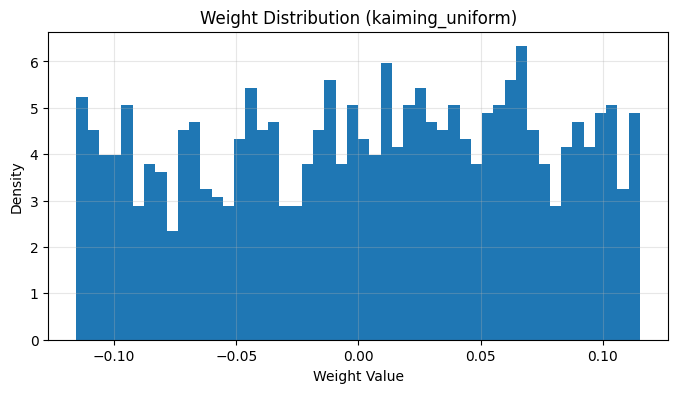

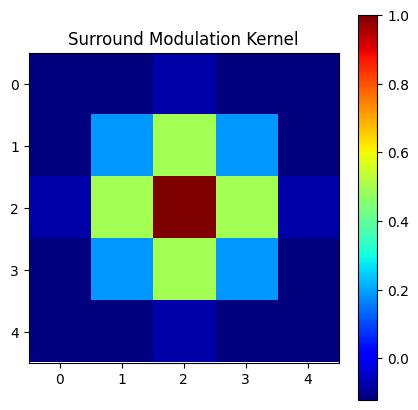

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/30] | Train Loss: 2.5601 | Train Acc: 35.33% | Test Loss: 2.4109 | Test Acc: 40.57% | LR: 0.001000
Epoch [2/30] | Train Loss: 2.1368 | Train Acc: 40.93% | Test Loss: 2.1721 | Test Acc: 41.82% | LR: 0.001000
Epoch [3/30] | Train Loss: 2.0981 | Train Acc: 42.56% | Test Loss: 1.9859 | Test Acc: 44.37% | LR: 0.001000
Epoch [4/30] | Train Loss: 1.9933 | Train Acc: 44.10% | Test Loss: 2.2120 | Test Acc: 41.47% | LR: 0.001000
Epoch [5/30] | Train Loss: 2.0072 | Train Acc: 44.71% | Test Loss: 2.2630 | Test Acc: 39.21% | LR: 0.001000
Epoch [6/30] | Train Loss: 1.9614 | Train Acc: 45.44% | Test Loss: 2.0865 | Test Acc: 43.31% | LR: 0.001000
Epoch [7/30] | Train Loss: 1.8794 | Train Acc: 46.21% | Test Loss: 2.0026 | Test Acc: 43.92% | LR: 0.001000
Epoch [8/30] | Train Loss: 1.8932 | Train Acc: 46.40% | Test Loss: 2.0101 | Test Acc: 44.58% | LR: 0.001000
Epoch [9/3

In [30]:
peak_memory =[]
run_times= []

for seed in seeds:

    print(f"RUN {seed + 1}/5 | SEED = {seed}")
   
    set_seed(seed)

    # Generator specifically for this run
    g = torch.Generator()
    g.manual_seed(seed)

    #starting time from data loading
    start = time.perf_counter()

    train_loader = DataLoader(
        train_dataset,
        batch_size=64,
        shuffle=True,
        num_workers=2,
        worker_init_fn=seed_worker,
        generator=g
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=64,
        shuffle=False, #researchers have test data shuffled, but this is again unecessary, since no learning is occuring (eval only)
        num_workers=2,
        worker_init_fn=seed_worker,
        generator=g
    )

    #fresh model for every seed

    hebb_param = get_hebbian_config(version="optimal")

    model = Net_Hebbian(
        hebb_params=hebb_param,
        version="one_layer_reduced"
    ).to(device)


    # hebbian feature learning ('Unsupervised Feature Learning Phase' trained for 1 epoch)
    model.train()

    for epoch in range(1):

        print(f"Hebbian epoch {epoch + 1}")

        for i, (inputs, _) in enumerate(train_loader):

            inputs = inputs.to(device)

            with torch.no_grad():
                model(inputs)

            model.conv1.local_update()

            if i % 100 == 0:
                print(f"Batch {i}/{len(train_loader)}")
                

    # freeze the hebbian feature extractor as now to train classifier

    for module in [
        model.conv1,
        model.bn1,
    ]:

        for param in module.parameters():
            param.requires_grad = False

        module.eval()

    #optimiser and schedular as defined in experiment_hebbian.py
    sup_optimizer = torch.optim.Adam(
        model.fc1.parameters(),
        lr=0.001
    )

    scheduler = torch.optim.lr_scheduler.LambdaLR(
        sup_optimizer,
        lr_lambda=lambda epoch:
            0.5 ** max(0, (epoch - 10) // 2)
    )

    criterion = nn.CrossEntropyLoss()

    classifier_history = {
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": []
    }

    #train classier for 30 epochs (using their scheduling for the lr, training past 30 epochs is redundant)

    for epoch in range(30):
        model.conv1.eval()
        model.bn1.eval()


        model.fc1.train()

        #removing dropout 
        #model.dropout.train()

        running_loss = 0.0
        correct = 0
        total = 0


        for inputs, labels in train_loader:

            inputs = inputs.to(device)

            labels = labels.to(device)

            sup_optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            loss.backward()

            sup_optimizer.step()

            running_loss += loss.item() * labels.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_accuracy = 100 * correct / total

        #get the evaluation results on the test set

        model.eval()

        test_running_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():

            for inputs, labels in test_loader:

                inputs = inputs.to(device)
  

                labels = labels.to(device)

                outputs = model(inputs)

                loss = criterion(outputs, labels)

                test_running_loss += loss.item() * labels.size(0)

                _, predicted = torch.max(outputs, 1)

                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()

        test_loss = test_running_loss / test_total
        test_accuracy = 100 * test_correct / test_total


        classifier_history["train_loss"].append(train_loss)
        classifier_history["train_accuracy"].append(train_accuracy)

        classifier_history["test_loss"].append(test_loss)
        classifier_history["test_accuracy"].append(test_accuracy)

        #update the scheduler
        scheduler.step()

        current_lr = sup_optimizer.param_groups[0]["lr"]

        print(
            f"Epoch [{epoch + 1}/30] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_accuracy:.2f}% | "
            f"LR: {current_lr:.6f}"
        )


    peak = torch.cuda.max_memory_allocated()
    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)

    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")


    elapsed = time.perf_counter() - start
    print(f"train time: {elapsed}")

    run_times.append(elapsed)

    # save each runs history
    all_histories[seed] = classifier_history

In [31]:

train_acc = np.array([
    all_histories[seed]["train_accuracy"]
    for seed in seeds
])

test_acc = np.array([
    all_histories[seed]["test_accuracy"]
    for seed in seeds
])

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [33]:
train_acc_df=pd.DataFrame(train_acc)

In [34]:
test_acc_df=pd.DataFrame(test_acc)


In [35]:
train_acc_df.to_csv("/content/drive/MyDrive/research_jobs/hebbian_1_layer_minimal_transforms_compare_train_acc_.csv",index=False)

In [36]:
test_acc_df.to_csv("/content/drive/MyDrive/research_jobs/hebbian_1_layer_minimal_transforms_compare_test_acc_.csv",index=False)


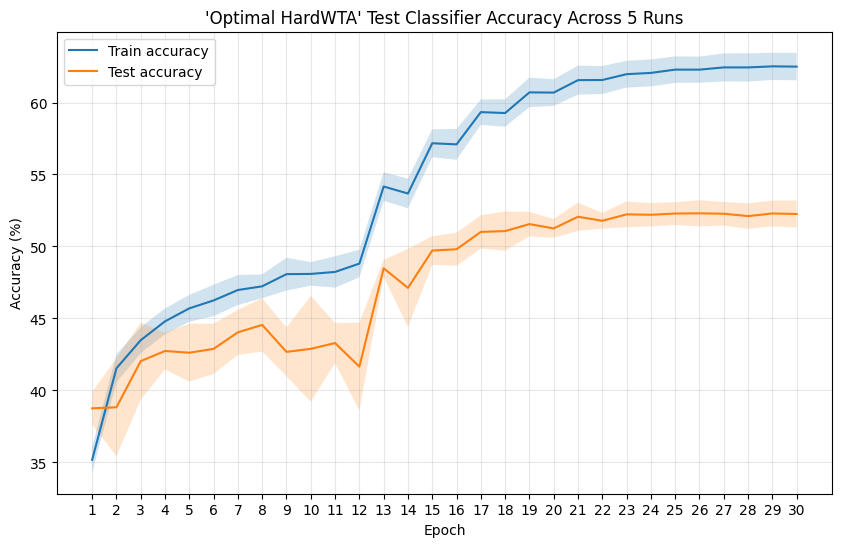

In [38]:
# Mean and standard deviation across the 5 runs
train_mean = train_acc.mean(axis=0)
train_std = train_acc.std(axis=0)

test_mean = test_acc.mean(axis=0)
test_std = test_acc.std(axis=0)

epochs = np.arange(1, 31)

plt.figure(figsize=(10, 6))

plt.plot(epochs, train_mean, label="Train accuracy")
plt.fill_between(
    epochs,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.plot(epochs, test_mean, label="Test accuracy")
plt.fill_between(
    epochs,
    test_mean - test_std,
    test_mean + test_std,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("'Optimal HardWTA' Test Classifier Accuracy Across 5 Runs")
plt.xticks(epochs)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [39]:
print(
    f"Final test accuracy: "
    f"{test_mean[-1]:.2f} ± {test_std[-1]:.2f}%"
)

Final test accuracy: 52.26 ± 0.94%


In [40]:
best_per_run = test_acc.max(axis=1)

print(
    f"Best test accuracy: "
    f"{best_per_run.mean():.2f} ± {best_per_run.std():.2f}%"
)

Best test accuracy: 52.42 ± 0.90%


In [41]:
times = np.array(run_times[1:])
mean_runtime = times.mean()

relevant_peak_mems = np.array(peak_memory[1:]) # exclude the first run as a warm up
mean_peak_memory = relevant_peak_mems.mean()

In [42]:
print(f"Mean max memory allocated: {mean_peak_memory}")
print("All peak memories (including the warm up run):")
peak_memory

Mean max memory allocated: 89.20849609375
All peak memories (including the warm up run):


[89.2099609375, 89.20849609375, 89.20849609375, 89.20849609375, 89.20849609375]

In [43]:
print(f"Mean training time for 100 epochs over the 10 runs: {mean_runtime} ")
print(f"All training times for the 100 epochs over the 10 runs:")
times

Mean training time for 100 epochs over the 10 runs: 1202.3692146757505 
All training times for the 100 epochs over the 10 runs:


array([1108.5360118 , 1181.30538573, 1230.34272556, 1289.29273561])

# 5 runs of the 1-layer on mnist (that is, no zca, no flipping, no dropout, 16 filters)

# 5 Runs of the 1-layer on STL-10 (that is, no zca, no flipping, no dropout, 16 filters)

# 5 Runs of the 1-layer on Fmnist (that is, no zca, no flipping, no dropout, 16 filters)

# Reconstruction driven filters (no lateral inhibition, no cosine similarity)

Building 1-layer Hebbian model


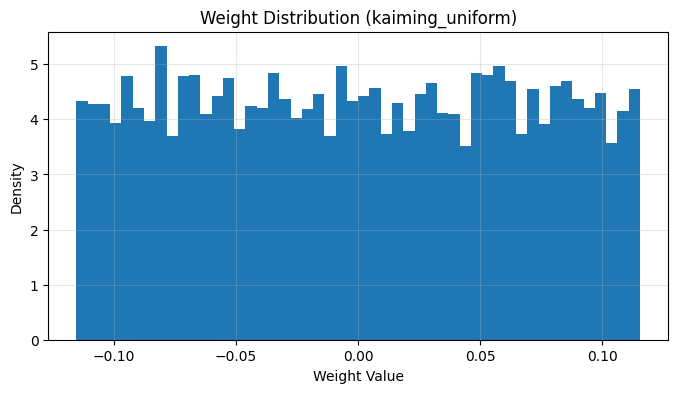

In [33]:
hebb_param = get_hebbian_config(version="reconstruction_hebbian")

model = Net_Hebbian(
    hebb_params=hebb_param,
    version="one_layer"
).to(device)

In [34]:
print(hebb_param)

{'mode': 'reconstruction_hebbian', 'w_nrm': False, 'act': Identity(), 'use_cosine_similarity': False, 'use_lateral_inhibition': False, 'top_k': 1, 'init_method': 'kaiming_uniform', 'patchwise': True, 'contrast': 1.0, 'uniformity': False, 'use_presynaptic_competition': False, 'presynaptic_competition_type': 'lp_norm', 'competition_type': 'hard', 'temporal_window': 500, 'competition_k': 2, 'dale': False, 'use_homeostasis': False}


In [35]:
print(model)

Net_Hebbian(
  (bn1): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
  (conv1): HebbianConv2d(
    (act): Identity()
  )
  (pool1): MaxPool2d(kernel_size=4, stride=2, padding=1, dilation=1, ceil_mode=False)
  (activ1): Triangle()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=24576, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [36]:
seeds=[0]
all_histories={}

RUN 1/ 1 | SEED = 0
Building 1-layer Hebbian model


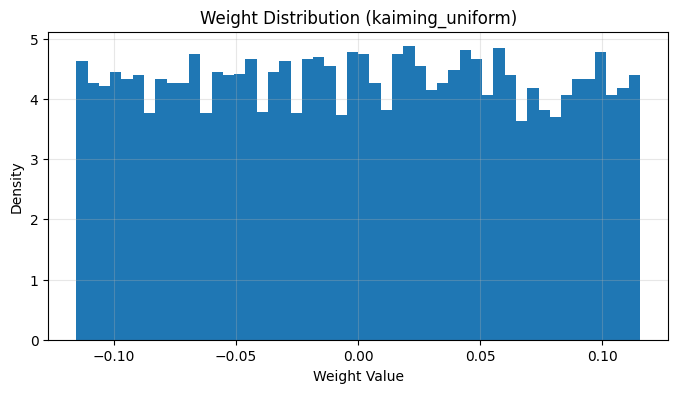

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 12.2840 | Train Acc: 21.70% | Test Loss: 9.3978 | Test Acc: 25.35% | LR: 0.001000
Epoch [2/20] | Train Loss: 10.4087 | Train Acc: 26.48% | Test Loss: 11.3147 | Test Acc: 29.97% | LR: 0.001000
Epoch [3/20] | Train Loss: 9.5485 | Train Acc: 28.48% | Test Loss: 7.9900 | Test Acc: 32.73% | LR: 0.001000
Epoch [4/20] | Train Loss: 9.5129 | Train Acc: 29.78% | Test Loss: 6.7830 | Test Acc: 38.63% | LR: 0.001000
Epoch [5/20] | Train Loss: 8.9982 | Train Acc: 31.34% | Test Loss: 5.6048 | Test Acc: 41.14% | LR: 0.001000
Epoch [6/20] | Train Loss: 8.8729 | Train Acc: 31.76% | Test Loss: 4.2479 | Test Acc: 41.73% | LR: 0.001000
Epoch [7/20] | Train Loss: 8.5988 | Train Acc: 32.41% | Test Loss: 6.0739 | Test Acc: 39.93% | LR: 0.001000
Epoch [8/20] | Train Loss: 8.4643 | Train Acc: 32.75% | Test Loss: 4.7187 | Test Acc: 40.36% | LR: 0.001000
Epoch [

In [38]:
zca.mean = zca.mean.to(device)
zca.std = zca.std.to(device)
zca.zca_matrix = zca.zca_matrix.to(device)



for seed in seeds:

    print(f"RUN {seed + 1}/ {len(seeds)} | SEED = {seed}")

    set_seed(seed)
    
    # Generator specifically for this run
    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=64,
        shuffle=True,
        num_workers=2,
        worker_init_fn=seed_worker,
        generator=g
    )

    #use the valid test dataset (no augmentation other than scaling using zca stats from training data)
    test_loader = DataLoader(
    valid_test_dataset,
    batch_size=64,
    shuffle=False, 
    num_workers=2,
    worker_init_fn=seed_worker,
    generator=g
)


    #fresh model
    
    hebb_param = get_hebbian_config(version="reconstruction_hebbian")

    model = Net_Hebbian(
        hebb_params=hebb_param,
        version="one_layer"
    ).to(device)


    # hebbian feature learning ('Unsupervised Feature Learning Phase' trained for 1 epoch)
    model.train()

    for epoch in range(1):

        print(f"Hebbian epoch {epoch + 1}")

        for i, (inputs, _) in enumerate(train_loader):

            inputs = inputs.to(device)

            inputs = zca.transform(inputs)

            
            with torch.no_grad():
                model(inputs)

            #for layer in [model.conv1]:
                #layer.local_update()
            model.conv1.local_update()

            if i % 100 == 0:
                print(f"Batch {i}/{len(train_loader)}")
                

    # freeze the hebbian feature extractor as now to train classifier

    for module in [
        model.conv1,
        model.bn1,
      
    ]:

        for param in module.parameters():
            param.requires_grad = False

        module.eval()

    #optimiser and schedular as defined in experiment_hebbian.py
    sup_optimizer = torch.optim.Adam(
        model.fc1.parameters(),
        lr=0.001
    )

    scheduler = torch.optim.lr_scheduler.LambdaLR(
        sup_optimizer,
        lr_lambda=lambda epoch:
            0.5 ** max(0, (epoch - 10) // 2)
    )

    criterion = nn.CrossEntropyLoss()


    classifier_history = {
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": []
    }

    #train classier for 20 epochs

    for epoch in range(20):
        model.conv1.eval()

        model.bn1.eval()


        model.fc1.train()
        model.dropout.train()

        running_loss = 0.0
        correct = 0
        total = 0


        for inputs, labels in train_loader:

            inputs = inputs.to(device)

            inputs = zca.transform(inputs)

            labels = labels.to(device)

            sup_optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            loss.backward()

            sup_optimizer.step()

            running_loss += loss.item() * labels.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_accuracy = 100 * correct / total

        #get the evaluation results on the test set

        model.eval()

        test_running_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():

            for inputs, labels in test_loader:

                inputs = inputs.to(device)
                
                inputs = zca.transform(inputs)

                labels = labels.to(device)

                outputs = model(inputs)

                loss = criterion(outputs, labels)

                test_running_loss += loss.item() * labels.size(0)

                _, predicted = torch.max(outputs, 1)

                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()

        test_loss = test_running_loss / test_total
        test_accuracy = 100 * test_correct / test_total


        classifier_history["train_loss"].append(train_loss)
        classifier_history["train_accuracy"].append(train_accuracy)

        classifier_history["test_loss"].append(test_loss)
        classifier_history["test_accuracy"].append(test_accuracy)

        #update the scheduler
        scheduler.step()

        current_lr = sup_optimizer.param_groups[0]["lr"]

        print(
            f"Epoch [{epoch + 1}/20] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_accuracy:.2f}% | "
            f"LR: {current_lr:.6f}"
        )

    # Save this run's history
    all_histories[seed] = classifier_history

### does an ok job considering it is most likely that there is one distinct feature map

In [ ]:
train_acc= all_histories

In [49]:
train_acc

{'train_loss': [12.283989496459961,
  10.408724118652344,
  9.548480809631348,
  9.512908698120118,
  8.998182770996094,
  8.87290563873291,
  8.598832120361328,
  8.464278179321289,
  8.61410603515625,
  8.486510830078124,
  8.392653141479492,
  8.593828366088868,
  7.037298234558105,
  6.809122794799805,
  5.9292674713134765,
  5.6808799142456055,
  5.187277362976074,
  5.04621882232666,
  4.751621063308716,
  4.685778330688477],
 'train_accuracy': [21.698,
  26.482,
  28.476,
  29.78,
  31.336,
  31.756,
  32.412,
  32.748,
  32.606,
  33.07,
  33.366,
  33.42,
  35.486,
  35.15,
  36.748,
  36.772,
  37.788,
  37.662,
  38.562,
  38.854],
 'test_loss': [9.397768778514862,
  11.314657328414917,
  7.989993797314167,
  6.782967152786255,
  5.604751014709473,
  4.247942242145538,
  6.073934635734558,
  4.718707849311828,
  7.336319141578675,
  5.987169539260864,
  4.38470558347702,
  4.553953762435913,
  3.9869710191726684,
  4.554296751785278,
  2.8421766025543214,
  3.196392549991607

In [51]:
train_acc = np.array([
    all_histories[seed]["train_accuracy"]
    for seed in seeds
])

test_acc = np.array([
    all_histories[seed]["test_accuracy"]
    for seed in seeds
])

In [52]:
train_acc_df=pd.DataFrame(train_acc)

In [53]:
test_acc_df=pd.DataFrame(test_acc)


In [54]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [55]:
train_acc_df.to_csv("/content/drive/MyDrive/research_jobs/reconstruction_hebbian_1_layer_train_acc_.csv",index=False)

In [56]:
test_acc_df.to_csv("/content/drive/MyDrive/research_jobs/reconstruction_hebbian_1_layer_test_acc_.csv",index=False)


In [57]:
#save model (including classifier head)
torch.save(model.state_dict(), "autoencoder_hebbian_model.pth")
#save kernels
kernels = model.conv1.weight.detach().cpu()

torch.save(kernels, "autoencoder_hebbian_conv1_kernels.pt")



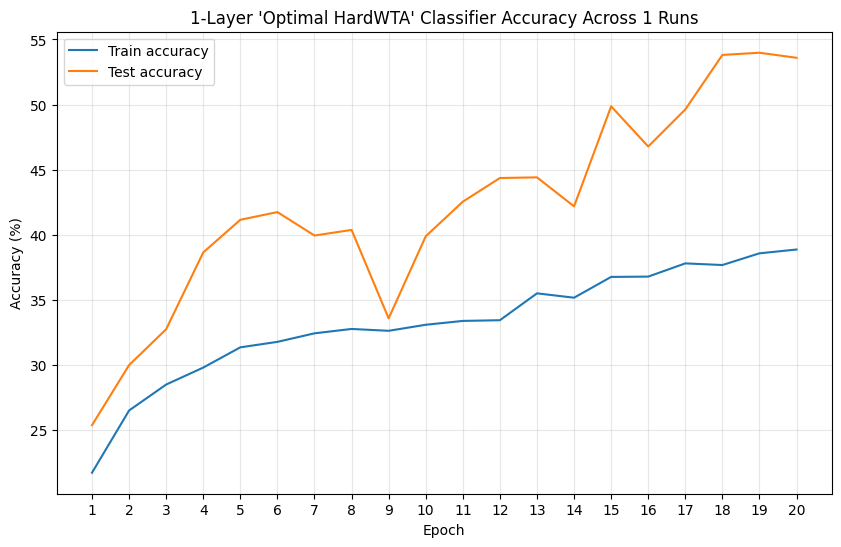

In [59]:
# Mean and standard deviation across the  runs
train_mean = train_acc.mean(axis=0)
train_std = train_acc.std(axis=0)

test_mean = test_acc.mean(axis=0)
test_std = test_acc.std(axis=0)

epochs = np.arange(1, 21)

plt.figure(figsize=(10, 6))

plt.plot(epochs, train_mean, label="Train accuracy")


plt.plot(epochs, test_mean, label="Test accuracy")


plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("1-Layer 'Optimal HardWTA' Classifier Accuracy Across 1 Runs")
plt.xticks(epochs)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# bare in mind the baseline for this model is not that which we just saw, if we care about comparing this model to a baseline, then I should create a bare bones implementation of the 1-layer that uses standard hebbian updating without lateral inhibition, cosine sim, wta etc... but I'm not sure we care about this, I was just interested to see if kernels collapse, and they only do so marginally it would seem, but perhaps hebbian learning requires really distinct specialised kernels for optimality.... therefore look to the kernel similarity of their optimal (74% accuracy achieving model and weigh this up)... this seemingly subtle filter collapse may also be a product of the zca preprocessing??

# Inspecting kernels

In [39]:
import torch.nn.functional as F 

conv_weights = model.conv1.weight.flatten(1)

conv_weights = F.normalize(conv_weights, dim=1)

similarity_matrix = conv_weights @ conv_weights.T

mask = ~torch.eye(96, dtype=torch.bool, device=conv_weights.device)


mean_abs_similarity = similarity_matrix[mask].abs().mean()
mean_similarity = similarity_matrix[mask].mean()

max_similarity = similarity_matrix[mask].max()
min_similarity = similarity_matrix[mask].min()


print(f"Mean abs filter cosine similarity: {mean_abs_similarity:.4f}")
print(f"Mean filter cosine similarity: {mean_similarity:.4f}")

print(f"Maximum filter similarity: {max_similarity:.4f}")
print(f"Minimum filter similarity: {min_similarity:.4f}")


Mean abs filter cosine similarity: 0.2025
Mean filter cosine similarity: -0.0007
Maximum filter similarity: 1.0000
Minimum filter similarity: -1.0000


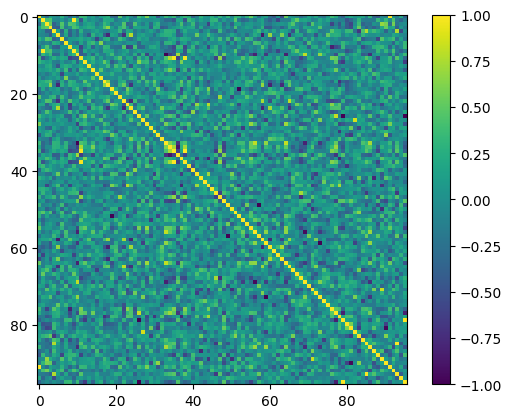

In [40]:
plt.imshow(similarity_matrix.detach().cpu(), vmin=-1, vmax=1)
plt.colorbar()

Text(0, 0.5, 'Number of filter pairs')

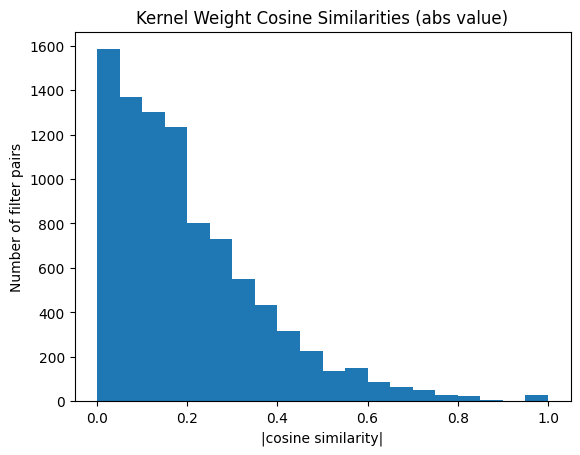

In [41]:
pairwise = similarity_matrix[mask].abs().detach().cpu().numpy()

plt.hist(pairwise, bins=20)
plt.title("Kernel Weight Cosine Similarities (abs value)")
plt.xlabel("|cosine similarity|")
plt.ylabel("Number of filter pairs")

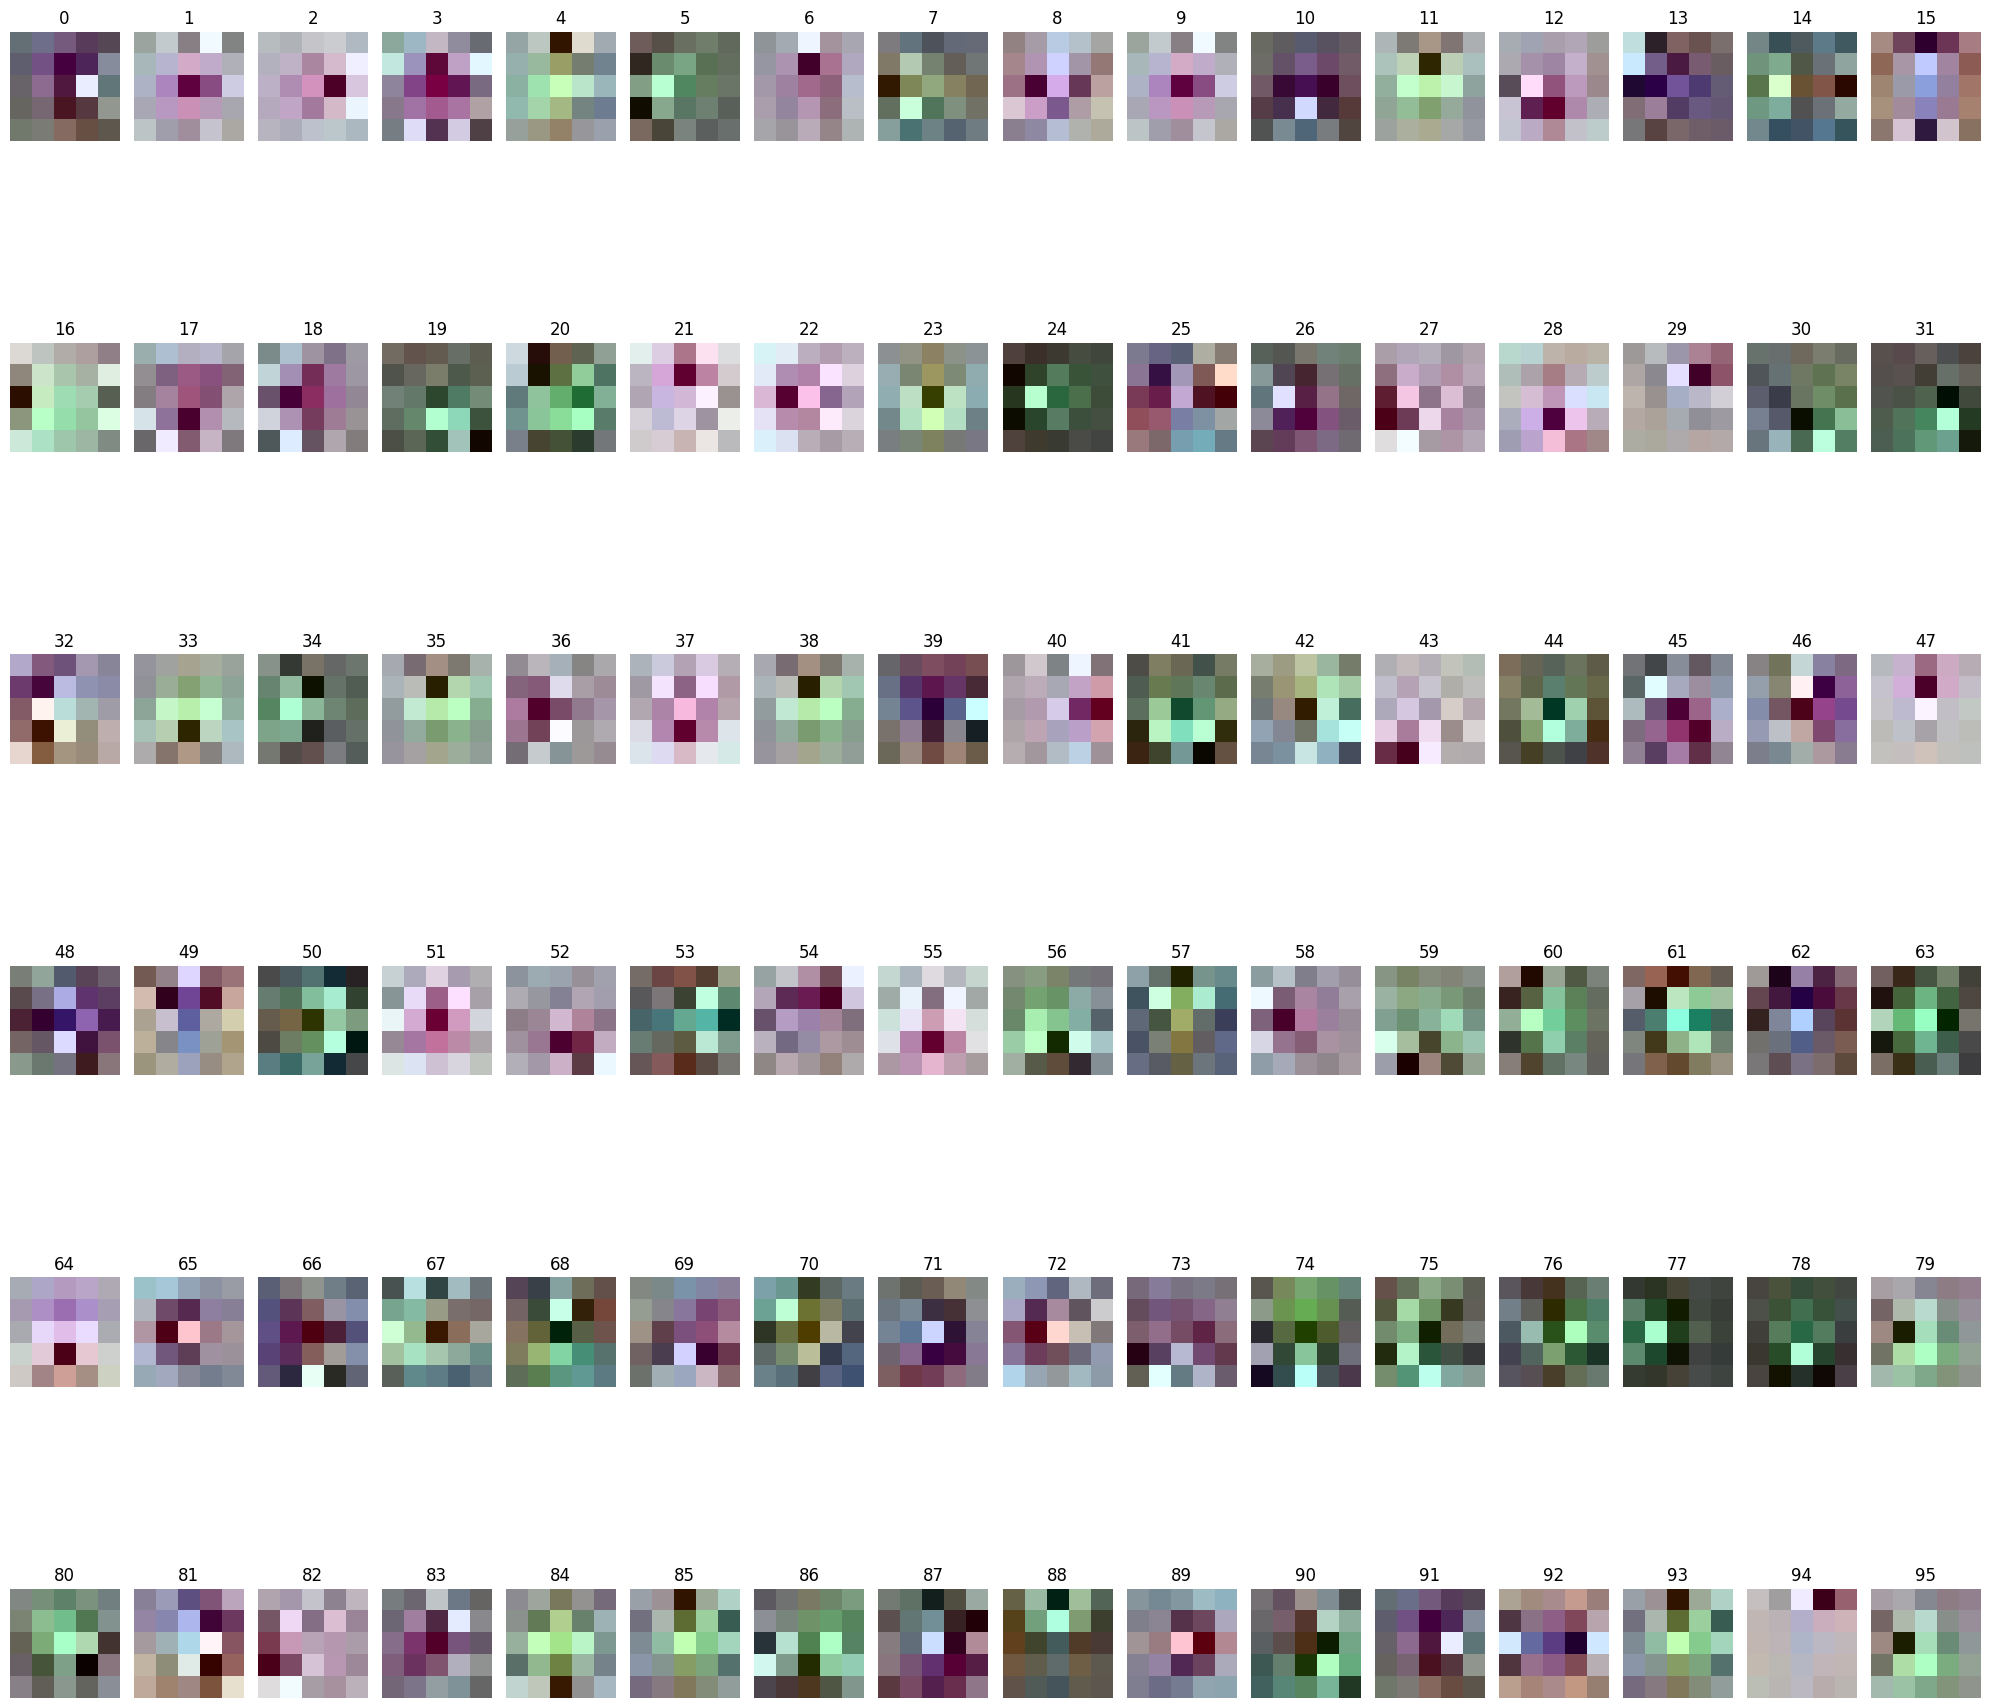

In [46]:
weights = model.conv1.weight.detach().cpu()

fig, axes = plt.subplots(6, 16, figsize=(20, 20))

for i, ax in enumerate(axes.flat):
    kernel = weights[i] 

    # Normalise each kernel for visualisation
    kernel_min = kernel.min()
    kernel_max = kernel.max()

    kernel = (kernel - kernel_min) / (kernel_max - kernel_min + 1e-8)

    ax.imshow(kernel.permute(1, 2, 0))
    ax.set_title(i)
    ax.axis("off")

plt.tight_layout()
plt.show()

# Features

In [60]:
def extract_features(model, dataloader, device):

    features = {}

    def hook_fn(module, input, output):
        features['conv1'] = output.detach().cpu()

    hook = model.conv1.register_forward_hook(hook_fn)

    model.eval()

    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:

            images = images.to(device)

            model(images)

            all_features.append(features['conv1'])
            all_labels.append(labels)

    hook.remove()

    all_features = torch.cat(all_features, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    return all_features, all_labels

In [61]:
features, labels = extract_features(
    model,
    train_loader,
    device
)

torch.save(features, "conv1_features.pt")
torch.save(labels, "labels.pt")

: 

: 

: 

# Adding back a winner takes all strategy

Building 1-layer Hebbian model


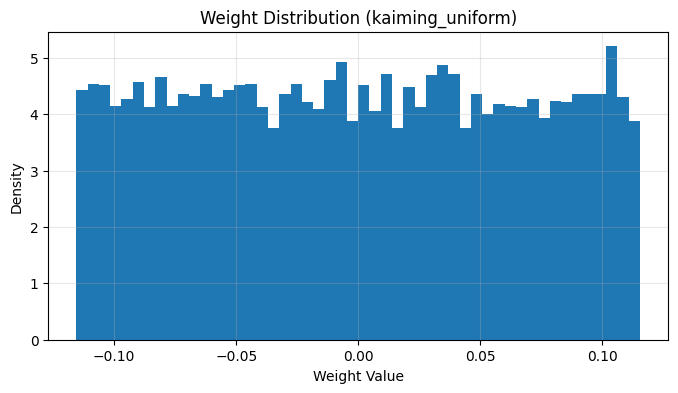

In [30]:
hebb_param = get_hebbian_config(version="reconstruction_hebbian_wta")

model = Net_Hebbian(
    hebb_params=hebb_param,
    version="one_layer"
).to(device)

In [31]:
hebb_param

{'mode': 'reconstruction_hebbian_wta',
 'w_nrm': False,
 'act': Identity(),
 'use_cosine_similarity': False,
 'use_lateral_inhibition': False,
 'top_k': 1,
 'init_method': 'kaiming_uniform',
 'patchwise': True,
 'contrast': 1.0,
 'uniformity': False,
 'use_presynaptic_competition': False,
 'presynaptic_competition_type': 'lp_norm',
 'competition_type': 'hard',
 'temporal_window': 500,
 'competition_k': 2,
 'dale': False,
 'use_homeostasis': False}

In [32]:
# just inspecting the effect on the first seed:
seeds = [0]
all_histories = {}

RUN 1/ 1 | SEED = 0
Building 1-layer Hebbian model


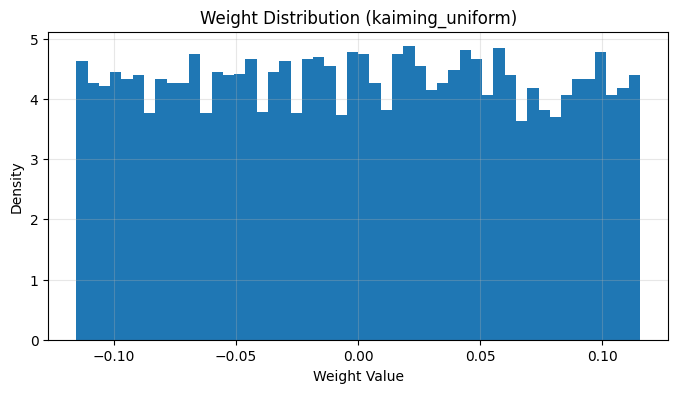

Hebbian epoch 1
Batch 0/782
Batch 100/782
Batch 200/782
Batch 300/782
Batch 400/782
Batch 500/782
Batch 600/782
Batch 700/782
Epoch [1/20] | Train Loss: 9.4219 | Train Acc: 28.38% | Test Loss: 5.4857 | Test Acc: 41.55% | LR: 0.001000
Epoch [2/20] | Train Loss: 7.9426 | Train Acc: 35.85% | Test Loss: 6.9509 | Test Acc: 39.73% | LR: 0.001000
Epoch [3/20] | Train Loss: 7.7330 | Train Acc: 37.51% | Test Loss: 4.2768 | Test Acc: 49.51% | LR: 0.001000
Epoch [4/20] | Train Loss: 7.5765 | Train Acc: 38.84% | Test Loss: 4.5763 | Test Acc: 47.67% | LR: 0.001000
Epoch [5/20] | Train Loss: 7.4817 | Train Acc: 39.80% | Test Loss: 5.4842 | Test Acc: 45.61% | LR: 0.001000
Epoch [6/20] | Train Loss: 7.1725 | Train Acc: 41.04% | Test Loss: 5.9657 | Test Acc: 47.26% | LR: 0.001000
Epoch [7/20] | Train Loss: 7.0857 | Train Acc: 41.12% | Test Loss: 6.1155 | Test Acc: 48.35% | LR: 0.001000
Epoch [8/20] | Train Loss: 7.0930 | Train Acc: 41.55% | Test Loss: 5.8309 | Test Acc: 43.87% | LR: 0.001000
Epoch [9/2

In [33]:
zca.mean = zca.mean.to(device)
zca.std = zca.std.to(device)
zca.zca_matrix = zca.zca_matrix.to(device)

for seed in seeds:

    print(f"RUN {seed + 1}/ {len(seeds)} | SEED = {seed}")

    set_seed(seed)
    
    # Generator specifically for this run
    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=64,
        shuffle=True,
        num_workers=2,
        worker_init_fn=seed_worker,
        generator=g
    )

    #use the valid test dataset (no augmentation other than scaling using zca stats from training data)
    test_loader = DataLoader(
    valid_test_dataset,
    batch_size=64,
    shuffle=False, 
    num_workers=2,
    worker_init_fn=seed_worker,
    generator=g
)

    #fresh model
    
    hebb_param = get_hebbian_config(version="reconstruction_hebbian_wta")

    model = Net_Hebbian(
        hebb_params=hebb_param,
        version="one_layer"
    ).to(device)


    # hebbian feature learning ('Unsupervised Feature Learning Phase' trained for 1 epoch)
    model.train()

    for epoch in range(1):

        print(f"Hebbian epoch {epoch + 1}")

        for i, (inputs, _) in enumerate(train_loader):

            inputs = inputs.to(device)

            inputs = zca.transform(inputs)

            
            with torch.no_grad():
                model(inputs)

            #for layer in [model.conv1]:
                #layer.local_update()
            model.conv1.local_update()

            if i % 100 == 0:
                print(f"Batch {i}/{len(train_loader)}")
                

    # freeze the hebbian feature extractor as now to train classifier

    for module in [
        model.conv1,
        model.bn1,
      
    ]:

        for param in module.parameters():
            param.requires_grad = False

        module.eval()

    #optimiser and schedular as defined in experiment_hebbian.py
    sup_optimizer = torch.optim.Adam(
        model.fc1.parameters(),
        lr=0.001
    )

    scheduler = torch.optim.lr_scheduler.LambdaLR(
        sup_optimizer,
        lr_lambda=lambda epoch:
            0.5 ** max(0, (epoch - 10) // 2)
    )

    criterion = nn.CrossEntropyLoss()


    classifier_history = {
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": []
    }

    #train classier for 20 epochs

    for epoch in range(20):
        model.conv1.eval()

        model.bn1.eval()


        model.fc1.train()
        model.dropout.train()

        running_loss = 0.0
        correct = 0
        total = 0


        for inputs, labels in train_loader:

            inputs = inputs.to(device)

            inputs = zca.transform(inputs)

            labels = labels.to(device)

            sup_optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            loss.backward()

            sup_optimizer.step()

            running_loss += loss.item() * labels.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_accuracy = 100 * correct / total

        #get the evaluation results on the test set

        model.eval()

        test_running_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():

            for inputs, labels in test_loader:

                inputs = inputs.to(device)
                
                inputs = zca.transform(inputs)

                labels = labels.to(device)

                outputs = model(inputs)

                loss = criterion(outputs, labels)

                test_running_loss += loss.item() * labels.size(0)

                _, predicted = torch.max(outputs, 1)

                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()

        test_loss = test_running_loss / test_total
        test_accuracy = 100 * test_correct / test_total


        classifier_history["train_loss"].append(train_loss)
        classifier_history["train_accuracy"].append(train_accuracy)

        classifier_history["test_loss"].append(test_loss)
        classifier_history["test_accuracy"].append(test_accuracy)

        #update the scheduler
        scheduler.step()

        current_lr = sup_optimizer.param_groups[0]["lr"]

        print(
            f"Epoch [{epoch + 1}/20] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_accuracy:.2f}% | "
            f"LR: {current_lr:.6f}"
        )

    # Save this run's history
    all_histories[seed] = classifier_history

In [ ]:
# Mean and standard deviation across the 5 runs
train_mean = train_acc.mean(axis=0)
train_std = train_acc.std(axis=0)

test_mean = test_acc.mean(axis=0)
test_std = test_acc.std(axis=0)

epochs = np.arange(1, 21)

plt.figure(figsize=(10, 6))

plt.plot(epochs, train_mean, label="Train accuracy")
plt.fill_between(
    epochs,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.plot(epochs, test_mean, label="Test accuracy")
plt.fill_between(
    epochs,
    test_mean - test_std,
    test_mean + test_std,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("1-Layer 'Optimal HardWTA' Classifier Accuracy Across 5 Runs")
plt.xticks(epochs)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [34]:
weights = model.conv1.weight.detach().cpu()
print(weights.shape)

torch.Size([96, 3, 5, 5])


In [36]:
import torch.nn.functional as F 

conv_weights = model.conv1.weight.flatten(1)

conv_weights = F.normalize(conv_weights, dim=1)

similarity_matrix = conv_weights @ conv_weights.T

mask = ~torch.eye(96, dtype=torch.bool, device=conv_weights.device)


mean_abs_similarity = similarity_matrix[mask].abs().mean()
mean_similarity = similarity_matrix[mask].mean()

max_similarity = similarity_matrix[mask].max()
min_similarity = similarity_matrix[mask].min()


print(f"Mean abs filter cosine similarity: {mean_abs_similarity:.4f}")
print(f"Mean filter cosine similarity: {mean_similarity:.4f}")

print(f"Maximum filter similarity: {max_similarity:.4f}")
print(f"Minimum filter similarity: {min_similarity:.4f}")


Mean abs filter cosine similarity: 0.0496
Mean filter cosine similarity: -0.0095
Maximum filter similarity: 0.3940
Minimum filter similarity: -0.9910


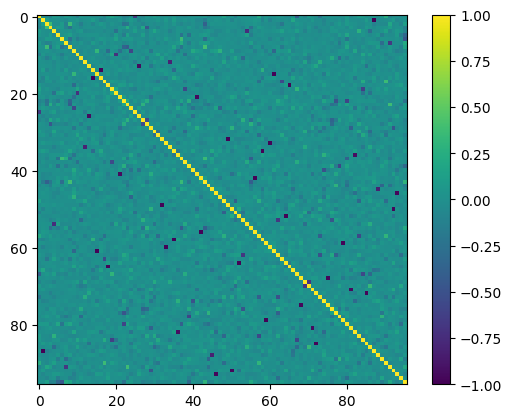

In [37]:
plt.imshow(similarity_matrix.detach().cpu(), vmin=-1, vmax=1)
plt.colorbar()

Text(0, 0.5, 'Number of filter pairs')

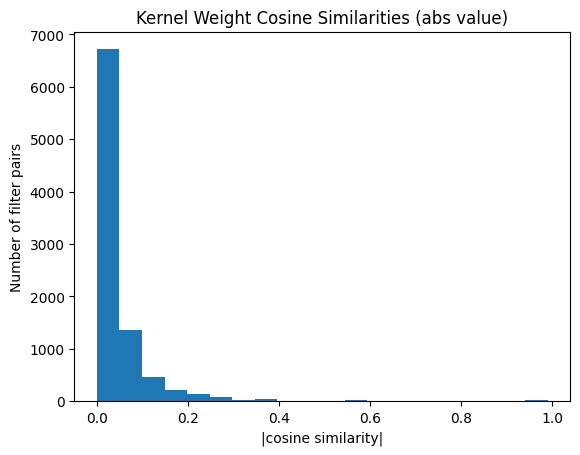

In [38]:
pairwise = similarity_matrix[mask].abs().detach().cpu().numpy()

plt.hist(pairwise, bins=20)
plt.title("Kernel Weight Cosine Similarities (abs value)")
plt.xlabel("|cosine similarity|")
plt.ylabel("Number of filter pairs")

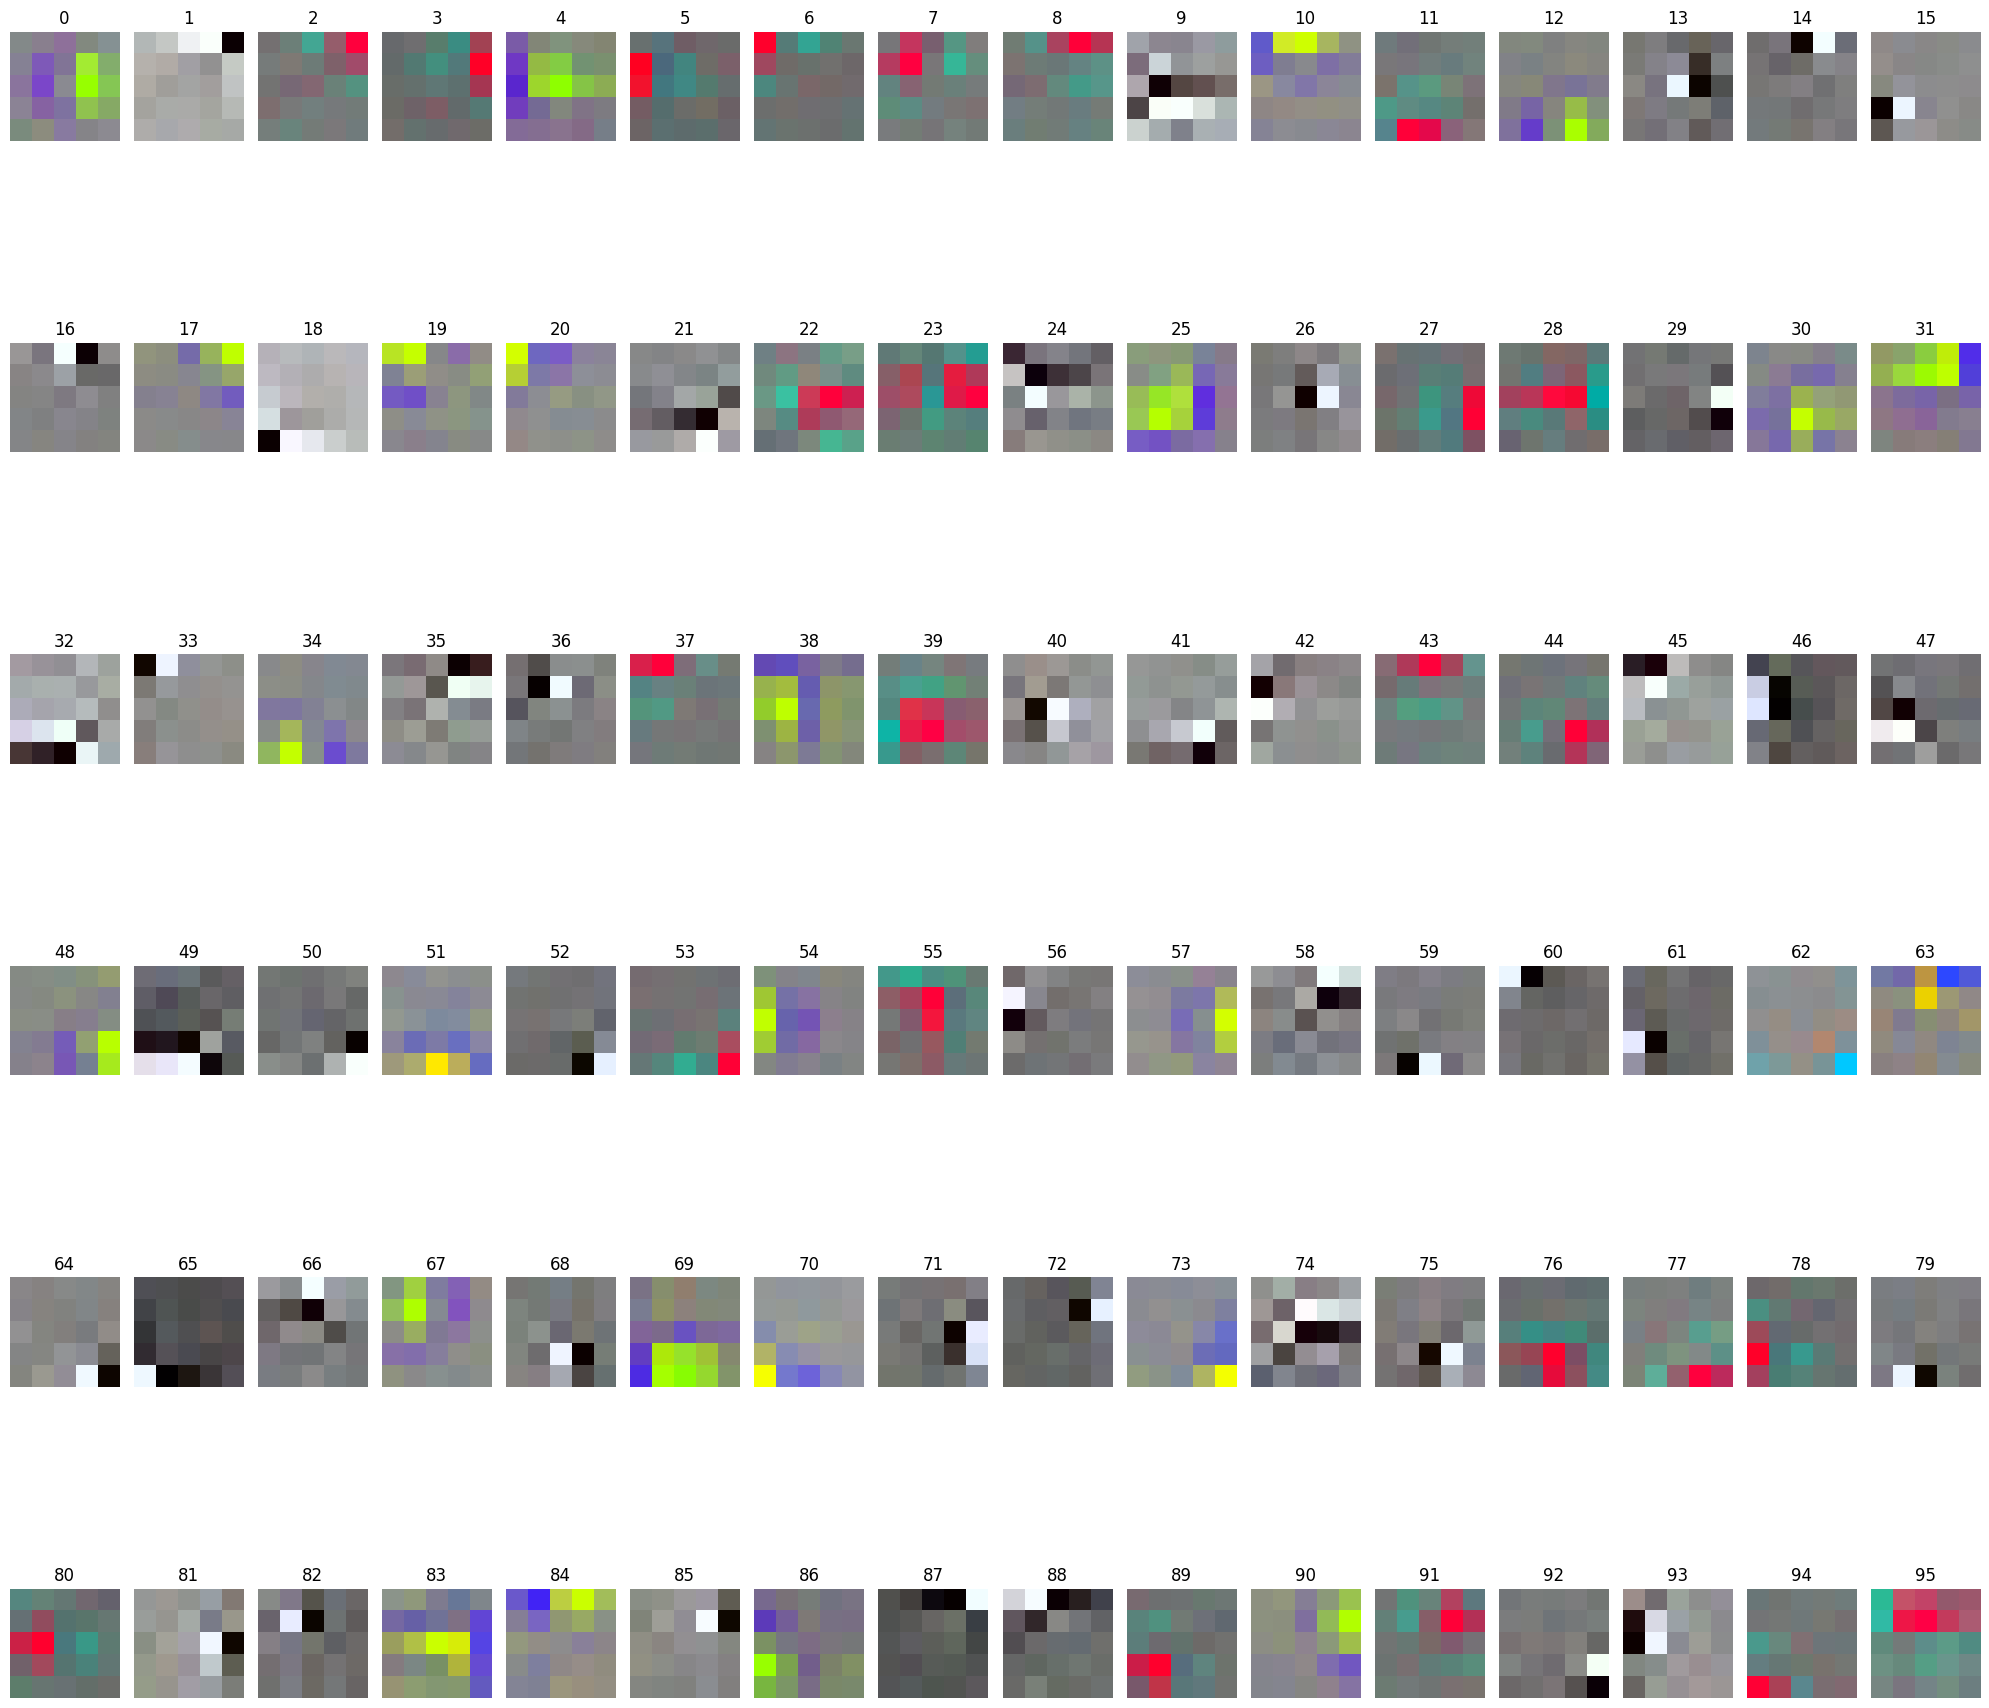

In [51]:
weights = weights.detach().cpu()

fig, axes = plt.subplots(6, 16, figsize=(20, 20))

for i, ax in enumerate(axes.flat):
    kernel = weights[i] 

    # Normalise each kernel for visualisation
    kernel_min = kernel.min()
    kernel_max = kernel.max()

    kernel = (kernel - kernel_min) / (kernel_max - kernel_min + 1e-8)

    ax.imshow(kernel.permute(1, 2, 0))
    ax.set_title(i)
    ax.axis("off")

plt.tight_layout()
plt.show()

# Features (tricky to inspect, since are we looking before or after the winner takes all?)

In [52]:
features = {}

def hook_fn(module, input, output):
    features['conv1'] = output.detach().cpu()

hook = model.conv1.register_forward_hook(hook_fn)

In [54]:
device

device(type='cuda')

In [55]:
model.eval()
images = images.to(device)

with torch.no_grad():
    output = model(images)

hook.remove()

In [56]:
conv1_features = features['conv1']

print(conv1_features.shape)

torch.Size([16, 96, 32, 32])


In [57]:
print(images.shape)
print(images.size(0))

torch.Size([16, 3, 32, 32])
16


In [1]:
print(t)

NameError: name 't' is not defined

In [58]:
print(train_loader.batch_size)
print(test_loader.batch_size)

64
64


In [2]:
images, labels = next(iter(train_loader))

print(images.shape)

NameError: name 'train_loader' is not defined

# also see how using the reconstruction term within the 3-layer model affects performance